In [1]:
import os
from plotnine import *
import pandas as pd
from pandas.api.types import CategoricalDtype
# from globals import *

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 曲线图

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 7 x 4 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: compare/lineplot/AAPL.pdf


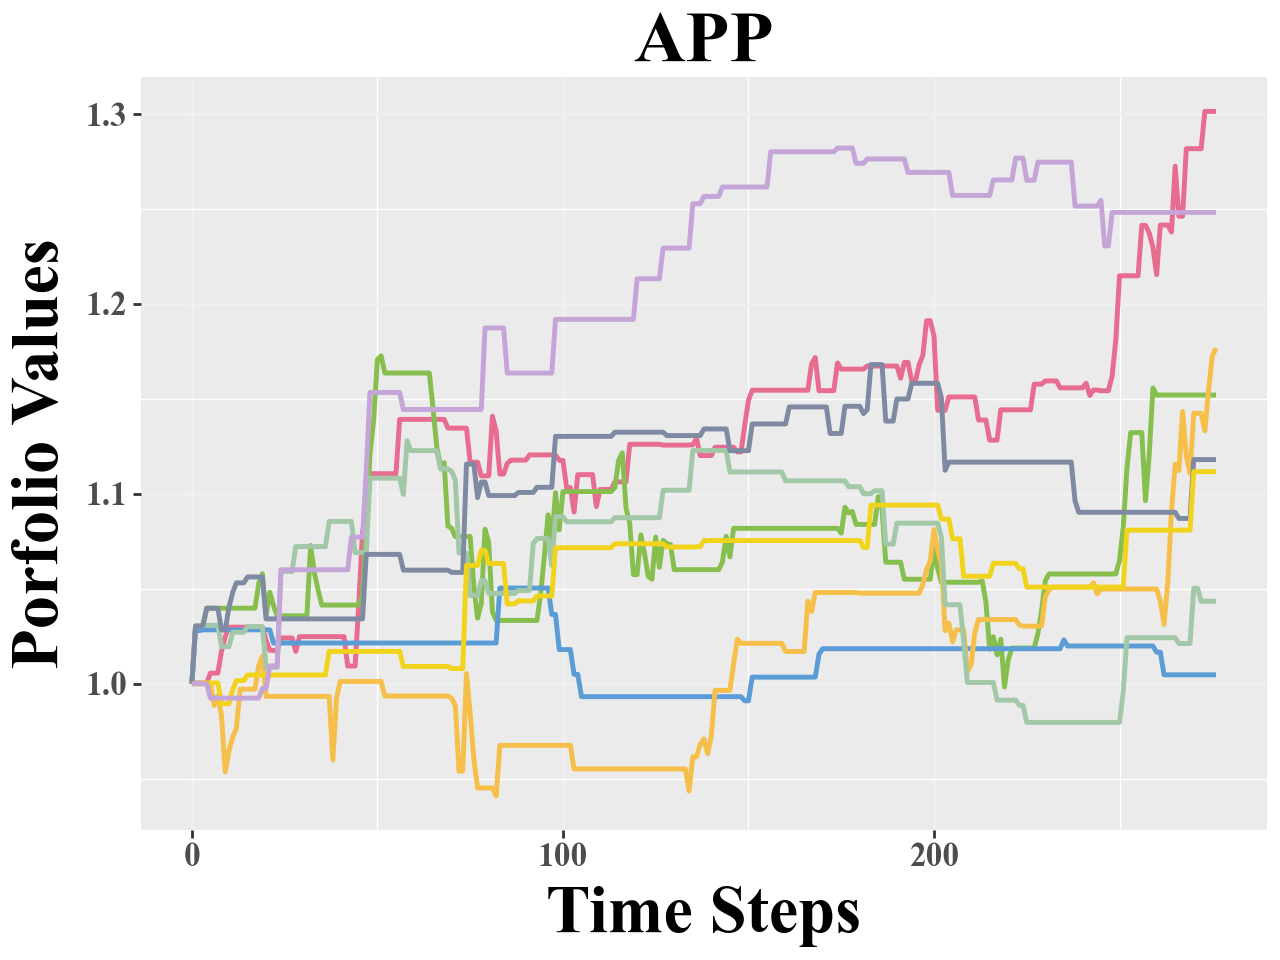

In [53]:
# from generator.generator import concat_events_and_price
from plotnine import scale_x_continuous
import os

# 选择画图的类型
group = 'compare'
# group = 'ablation'
        
muted_colors = ['#E86C90',  # 温暖的粉红色
    '#86BF4E',  # 较深的绿色
    '#5A9CD6',  # 中等深浅的蓝色
    '#F6BF49',  # 较深的橙色
    '#A2C8A8',  # 较浅的绿色，带有灰调
    '#7E8AA2',  # 柔和的紫色
    '#F2D31B',  # 明亮的黄色
    '#C5A4D8',  # 较浅的紫色
    '#85C1E9'   # 明亮的天蓝色
]

# 选择画哪几只股票
# stock_list = os.listdir(f'{group}/table/')
stock_list = ['AAPL.csv']

for stock in stock_list:
    data = pd.read_csv(f'{group}/table/{stock}')
    cut_line = round(len(data)*0.7)
    stock_name = stock[:-4]
    if group =='compare':
        data = data.rename({'dualcl':'Triviews', 
                            'stocknet':'Stocknet', 
                            'alstm':'LSTM', 
                            'atten_lstm':'Attentive-LSTM', 
                            'transam':'Transformer',
                            'bert':'DUAL-DNN', 
                            'bert2':'CE-DNN', 
                            'bert3':'SCL-DNN', 
                            'infonce':'ESPMP'}, axis=1)
        p = (ggplot(data, aes(x=data.index))
                + geom_line(aes(y='Triviews',    color='"Triviews"'), size=1, group=1)  # 
                + geom_line(aes(y='Stocknet',    color='"Stocknet"'), size=1, group=1)  # 
                + geom_line(aes(y='LSTM',        color='"LSTM"'), size=1, group=1)  # 
                + geom_line(aes(y='Transformer', color='"Transformer"'), size=1, group=1) # 
                + geom_line(aes(y='DUAL-DNN',    color='"DUAL-DNN"'), size=1, group=1) # 
                + geom_line(aes(y='CE-DNN',      color='"CE-DNN"'), size=1, group=1) # 
                + geom_line(aes(y='SCL-DNN',     color='"SCL-DNN"'), size=1, group=1) # 
                + geom_line(aes(y='ESPMP',       color='"ESPMP"'), size=1, group=1) # 
                
                # Aesthetic improvements
                + scale_color_manual(values=muted_colors)  # Use the muted color palette
                + theme()
                + theme(axis_text_x=element_text(fontsize=12, face="bold", family="Times New Roman"),
                        axis_text_y=element_text(fontsize=12, face="bold", family="Times New Roman"),
                        panel_grid_major=element_line(color="#f0f0f0"),             # 调整网格线颜色为浅灰
                       )  # rotation=45, hjust=1 Rotate x-axis labels for readability
                
                # + theme(legend_position='right',  # Position the legend on the right
                #         legend_title=element_text(size=10, face="bold"),  # Adjust legend title size
                #         legend_text=element_text(size=9),
                # )  # Adjust legend text size
                + theme(axis_title_x=element_text(size=24, face="bold", family="Times New Roman"),  # X-axis title bold
                        axis_title_y=element_text(size=24, face="bold", family="Times New Roman"),  # Y-axis title bold
                        plot_title=element_text(size=26, face="bold", family="Times New Roman",margin={'b': 0.5}))  # Bold plot title, center alignment
                # + theme(legend_title=element_blank()) 
                # + theme(legend_position='top') 
                + theme(legend_position='none')
                 
                + labs(x="Time Steps", y="Porfolio Values", title= f"APP") # , title= f"Model Performance Comparison in {stock_name}" #, title="Comparison of Different Models in No Short Strategy" 
        )
    save_path = f'{group}/lineplot/{stock_name}.pdf'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
            
    p.save(save_path, width=7, height=4, dpi=1200)
    p.show()


### 原始曲线图

In [9]:
# from generator.generator import concat_events_and_price
from plotnine import scale_x_continuous
import os

# 选择画图的类型
group = 'compare'
# group = 'ablation'
        
muted_colors = ['#E86C90',  # 温暖的粉红色
    '#86BF4E',  # 较深的绿色
    '#5A9CD6',  # 中等深浅的蓝色
    '#F6BF49',  # 较深的橙色
    '#A2C8A8',  # 较浅的绿色，带有灰调
    '#7E8AA2',  # 柔和的紫色
    '#F2D31B',  # 明亮的黄色
    '#C5A4D8',  # 较浅的紫色
    '#85C1E9'   # 明亮的天蓝色
]

# 选择画哪几只股票
# stock_list = os.listdir(f'{group}/table/')
stock_list = ['AAPL.csv']

for stock in stock_list:
    data = pd.read_csv(f'{group}/table/{stock}')
    cut_line = round(len(data)*0.7)
    # raw = pd.read_csv(f'dataset/USStock/price/{stock}')
    # date = raw.iloc[cut_line:]['date'][19:19+len(data)].reset_index().drop(columns=['index'])
    # d = pd.concat([date,data], axis=1).set_index('date')
    stock_name = stock[:-4]
    if group =='compare':
        data = data.rename({'dualcl':'Triviews', 'stocknet':'Stocknet', 'alstm':'LSTM', 
                  'atten_lstm':'Attentive-LSTM', 'transam':'Transformer',
                  'bert':'DUAL-DNN','bert2':'CE-DNN', 'bert3':'SCL-DNN','infonce':'ESPMP'}, axis=1)
        p = (ggplot(data, aes(x=data.index))
                + geom_line(aes(y='Triviews', color='"Triviews"'), size=1, group=1)  # Line for 'dualcl'
                + geom_line(aes(y='Stocknet', color='"Stocknet"'), size=1, group=1)  # Line for 'stocknet'
                + geom_line(aes(y='LSTM', color='"LSTM"'), size=1, group=1)  # Line for 'alstm'
                # + geom_line(aes(y='Attentive-LSTM', color='"Attentive-LSTM"'), size=1, group=1)  # Line for 'atten_lstm'
                # + geom_line(aes(y='Taureau', color='"Taureau"'), size=1, group=1)  # Line for 'atten_lstm'
                + geom_line(aes(y='Transformer', color='"Transformer"'), size=1, group=1)
                + geom_line(aes(y='DUAL-DNN', color='"DUAL-DNN"'), size=1, group=1)
                + geom_line(aes(y='CE-DNN', color='"CE-DNN"'), size=1, group=1)
                + geom_line(aes(y='SCL-DNN', color='"SCL-DNN"'), size=1, group=1)
                + geom_line(aes(y='ESPMP', color='"ESPMP"'), size=1, group=1)# Line for 'transam'
                
                # Aesthetic improvements
                # + scale_x_date(date_breaks='2 month', date_labels='%Y-%m')  # X-axis date formatting
                # + scale_color_manual(values=muted_colors)  # Use the muted color palette
                # + theme()
                # + theme(axis_text_x=element_text(rotation=45, hjust=1))  # Rotate x-axis labels for readability
                # + theme(axis_title_x=element_text(size=12, face="bold"),  # X-axis title bold
                #         axis_title_y=element_text(size=12, face="bold"),  # Y-axis title bold
                #         plot_title=element_text(size=14, face="bold", hjust=0.5))  # Bold plot title, center alignment
                # + theme(legend_title=element_blank()) 
                # + theme(legend_position='top') 
                # + theme(legend_direction='horizontal') 
                + labs(x="Time Steps", y="Porfolio Values") # , title= f"Model Performance Comparison in {stock_name}" #, title="Comparison of Different Models in No Short Strategy" 
        )
    elif group == 'ablation':
        data = data.rename({'dualcl':'Triviews', 'scl':'Triviews(supcon-cl)', 'ce':'Triviews(no-cl)', 'bert':'Triviews(no-translated)'}, axis=1)
        
        p = (ggplot(data, aes(x=data.index))
        + geom_line(aes(y='Triviews', color='"Triviews"'), size=1, group=1)  # Line for 'dualcl'
        + geom_line(aes(y='Triviews(supcon-cl)', color='"Triviews(supcon-cl)"'), size=1, group=1)  # Line for 'stocknet'
        + geom_line(aes(y='Triviews(no-cl)', color='"Triviews(no-cl)"'), size=1, group=1)  # Line for 'alstm'
        + geom_line(aes(y='Triviews(no-translated)', color='"Triviews(no-translated)"'), size=1, group=1)  # Line for 'atten_lstm'
        # + scale_x_date(date_breaks='2 month', date_labels='%Y-%m')  # X-axis date formatting
        + scale_color_manual(values=muted_colors)  # Use the muted color palette
        + theme()
        + theme(axis_text_x=element_text(rotation=45, hjust=1))  # Rotate x-axis labels for readability
        + theme(axis_title_x=element_text(size=12, face="bold"),  # X-axis title bold
                axis_title_y=element_text(size=12, face="bold"),  # Y-axis title bold
                plot_title=element_text(size=14, face="bold", hjust=0.5))  # Bold plot title, center alignment
        + theme(legend_title=element_blank()) 
        + theme(legend_position='top')
                
        + labs(x="Time Steps", y="Porfolio Values") # , title= f"Model Performance Comparison in {stock_name}"  #, title="Comparison of Different Models in No Short Strategy" 
        )
    save_path = f'{group}/lineplot/{stock_name}.pdf'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
            
    p.save(f'{group}/lineplot/{stock_name}.pdf')


/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: compare/lineplot/AAPL.pdf


## 柱状图

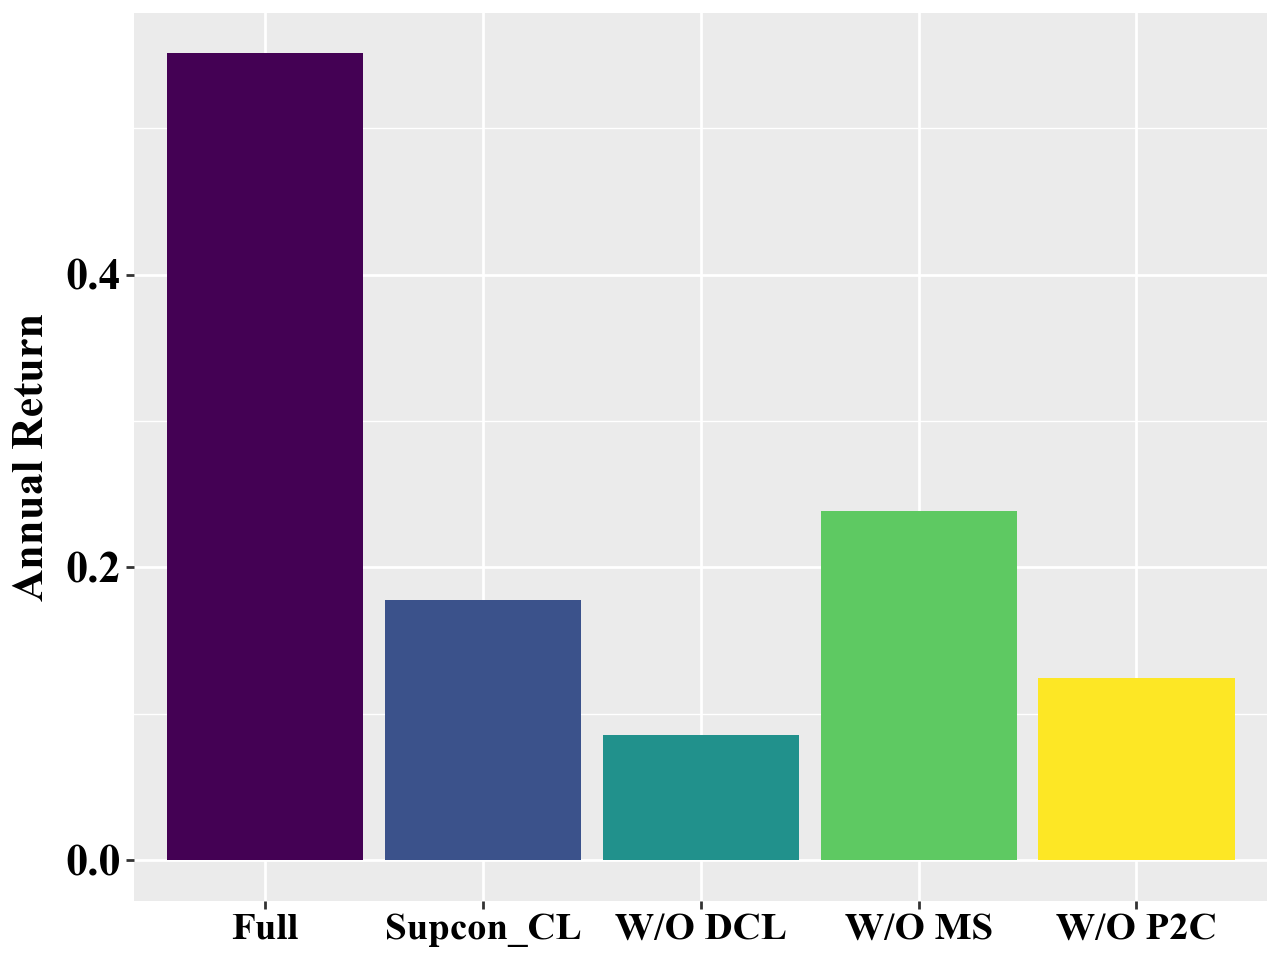

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 2.5 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ablation/barplot/Annual Return/Annual Return_barplot.pdf


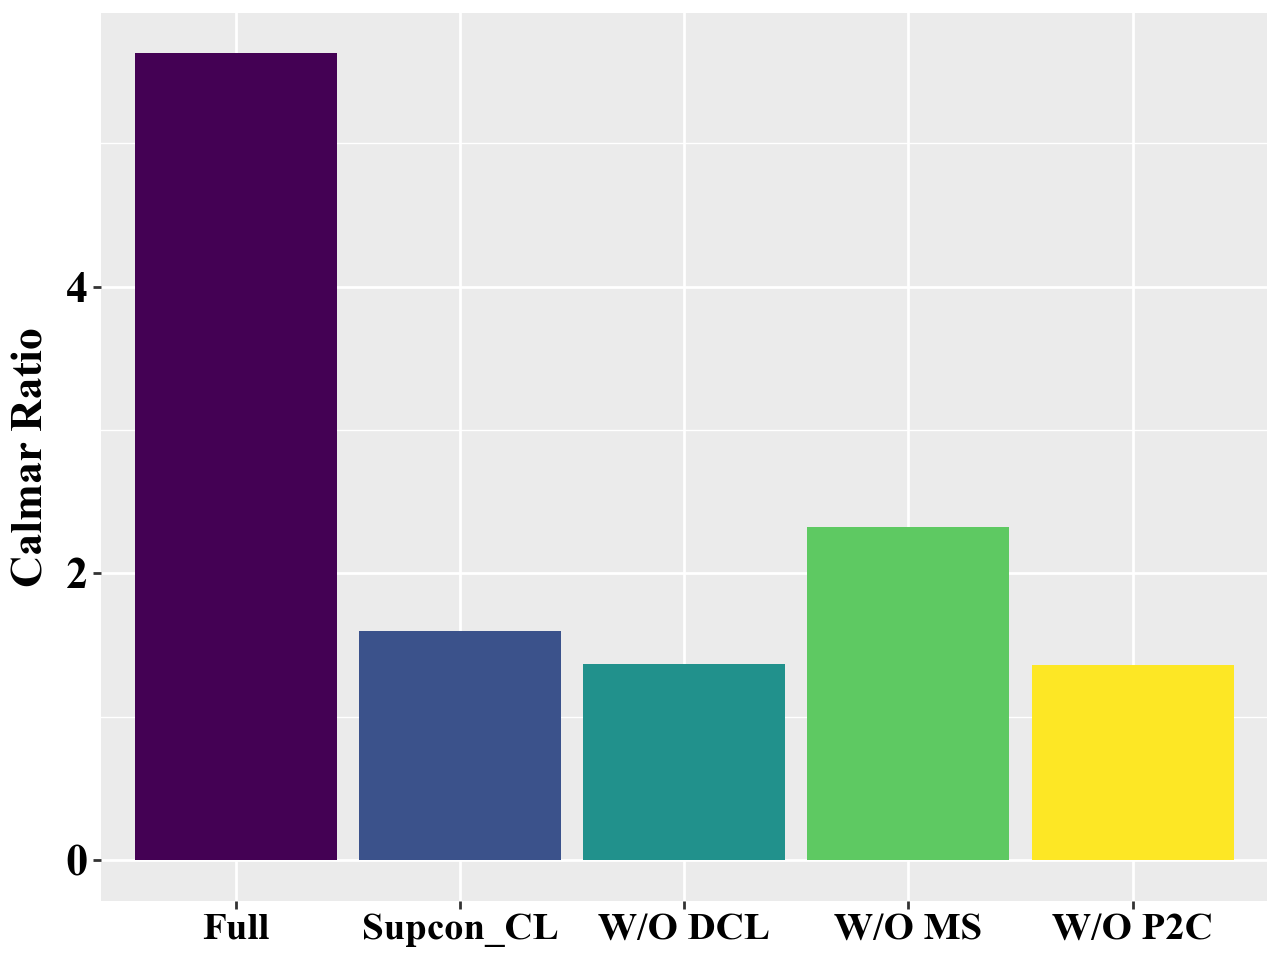

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 2.5 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ablation/barplot/Calmar Ratio/Calmar Ratio_barplot.pdf


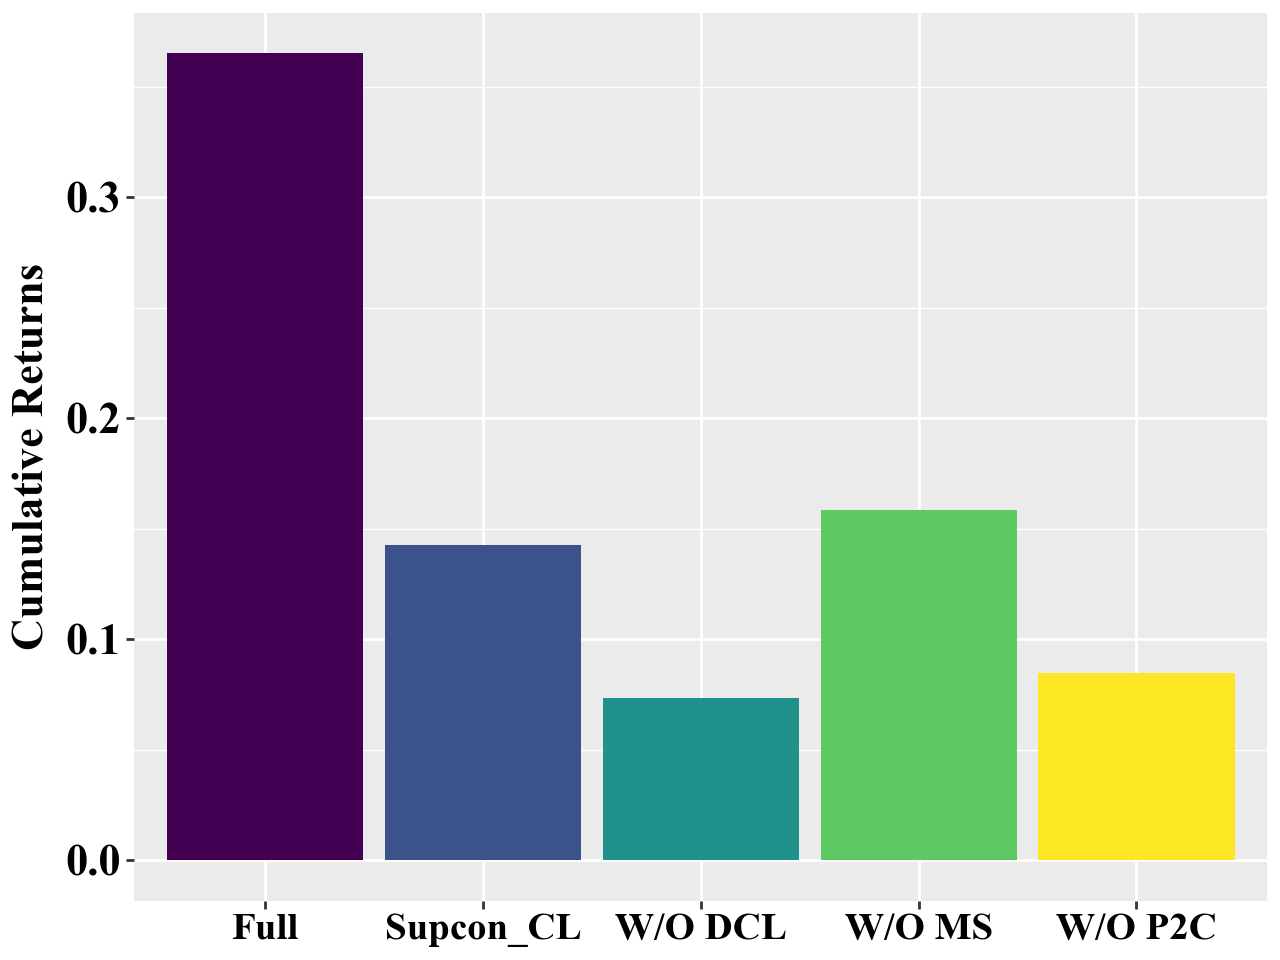

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 2.5 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ablation/barplot/Cumulative Returns/Cumulative Returns_barplot.pdf


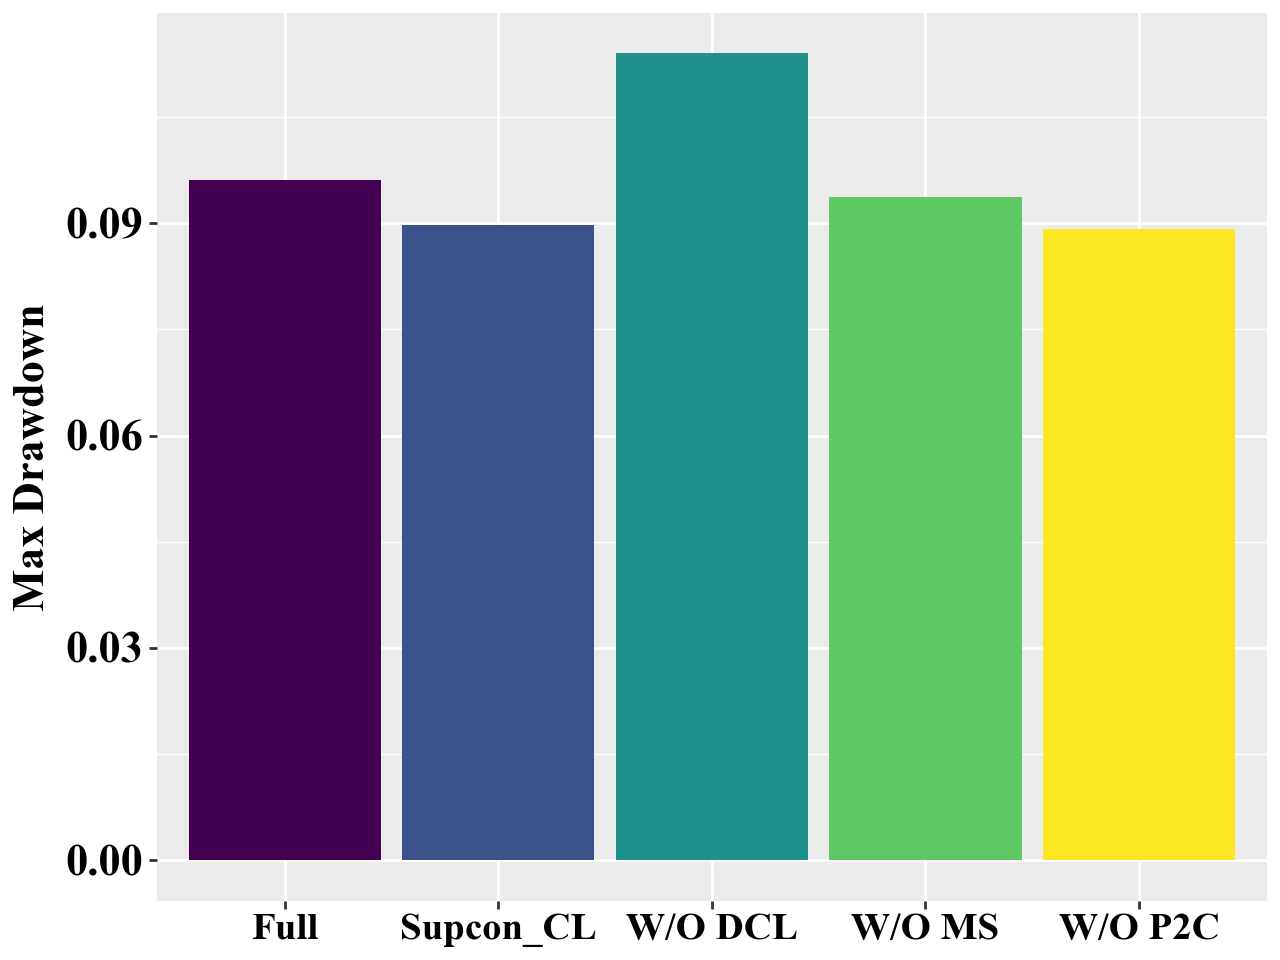

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 2.5 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ablation/barplot/Max Drawdown/Max Drawdown_barplot.pdf


In [59]:
from plotnine import ggsave

dis_pal = 'Set2'
id_vars2 = ['dataset', 'method']
value_vars = ['Annual Return', 'Max Drawdown', 'Cumulative Returns','Calmar Ratio']

def wide_to_long2(df):
    result_df = pd.melt(df, id_vars=id_vars2, value_vars=value_vars, \
        var_name='metric', value_name='value')
    result_df = result_df[id_vars2 + ['metric', 'value']]
    result_df = result_df.sort_values(by=id_vars2).reset_index().drop(columns='index')
    return result_df

def barplot(d, metric, xtick, data_name=None, saved_it=True):
    p = (ggplot(d, aes(x = xtick, y = 'value', fill = xtick)) 
        + geom_bar(stat='identity')
        # + geom_point(size=6, color="k")    
        + scale_color_cmap_d(name= dis_pal)     # plt.cm.ListedCmap
        + scale_fill_cmap_d(name= dis_pal)     # plt.cm.ListedCmap
        # + theme_prism()
        + ylab(metric)
        + xlab('')  # 去掉 X 轴标题
        + theme(legend_position='none') 
        # + theme(legend_text = element_text(size = 15))
        # + theme(axis_text_x = element_text(size=15))
        # + theme(axis_title_x = element_text(size=15))
        # + theme(axis_title_y = element_text(size=15))
        + theme(axis_title_x=element_text(rotation=0, size=16, face="bold", family="Times New Roman"),  # X-axis title bold
                axis_title_y=element_text(size=16, face="bold", family="Times New Roman"),  # Y-axis title bold
                plot_title=element_text(size=16, face="bold", hjust=0.5, family="Times New Roman"))
         
        + theme(axis_text_x=element_text(rotation=0, size=14, face="bold", hjust=0.5, color="#000000", family="Times New Roman"), 
                axis_text_y=element_text(size=16, face="bold", color="#000000", family="Times New Roman"),
                panel_grid_major=element_line(color="#ffffff"),             # 调整网格线颜色为浅灰
                )
        )
    all_or_each = 'all' if data_name == 'all' else 'each'
    save_path = f'ablation/barplot/{metric}/{xtick}_{data_name}_barplot.pdf'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    p.show()
    
    return p.save(f'ablation/barplot/{metric}/{metric}_barplot.pdf', width=5, height=2.5) if saved_it else p

df = pd.read_csv('final-ablation.csv').rename(columns={'stock':'dataset', 
                                                       'max_drawdown':'Max Drawdown',
                                                       'annual_return': 'Annual Return', 
                                                       'sharpe_1x_no_short':'Sharpe Ratio', 
                                                       'alpha_ratio':'Alpha Ratio',
                                                       'annual_volatility':'Annual Volatility', 
                                                       'accuracy':'Accuracy', 
                                                       'omega_ratio':'Omega Ratio',
                                                       'sortino_ratio':'Sortino Ratio', 
                                                       'skew':'Skew', 
                                                       'kurtosis':'Kurtosis',
                                                       'cumulative_returns':'Cumulative Returns',
                                                       'calmar_ratio':'Calmar Ratio'})

df = df.replace({'Triviews(no_cl)':'W/O DCL', 
                 'Triviews(supcon_cl)':'Supcon_CL',
                 'Triviews(dual_cl)':'Full',
                 'Triviews(not_translated)':'W/O P2C',
                 'Triviews(no_pull)':'W/O MS'}) # MometumSpan

df = wide_to_long2(df[['dataset', 
                       'method', 
                       'Cumulative Returns', 
                       'Annual Return', 
                       'Max Drawdown', 
                       'Calmar Ratio']])

metric_ordered = ['Cumulative Returns', 
                  'Annual Return', 
                  'Max Drawdown', 
                  'Calmar Ratio']

df['metric'] = df['metric'].astype(str).astype(CategoricalDtype(metric_ordered, ordered=True))
# df['metric'] = df['metric'].str.replace(r'\(.*?\)', '', regex=True)
df['metric'] = df['metric'].str.replace(r'[\(\)]', '', regex=True)

# all stock
for dx in df.groupby(['metric']): 
    dx1 = dx[1].groupby(['method']).value.median().reset_index()
    # print(dx[0][0])
    # dx[0] = dx[0].str.replace(r'\(.*?\)', '', regex=True)
    barplot(dx1, metric=dx[0][0],xtick='method', data_name='all') 

## 箱型图

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.


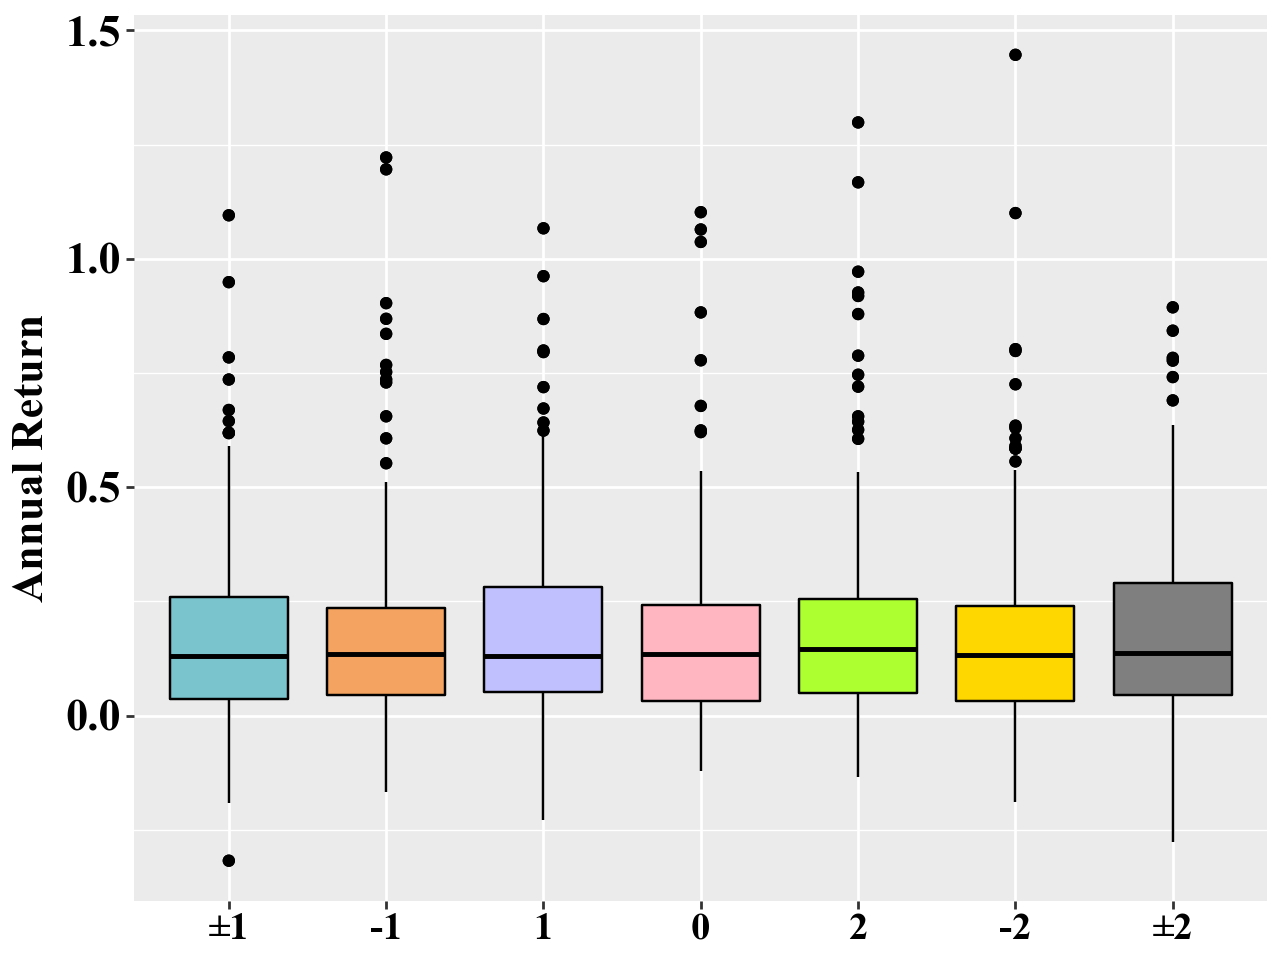

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/boxplot_allstock/Annual Return/MometumSpan_all_boxplot.pdf
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.


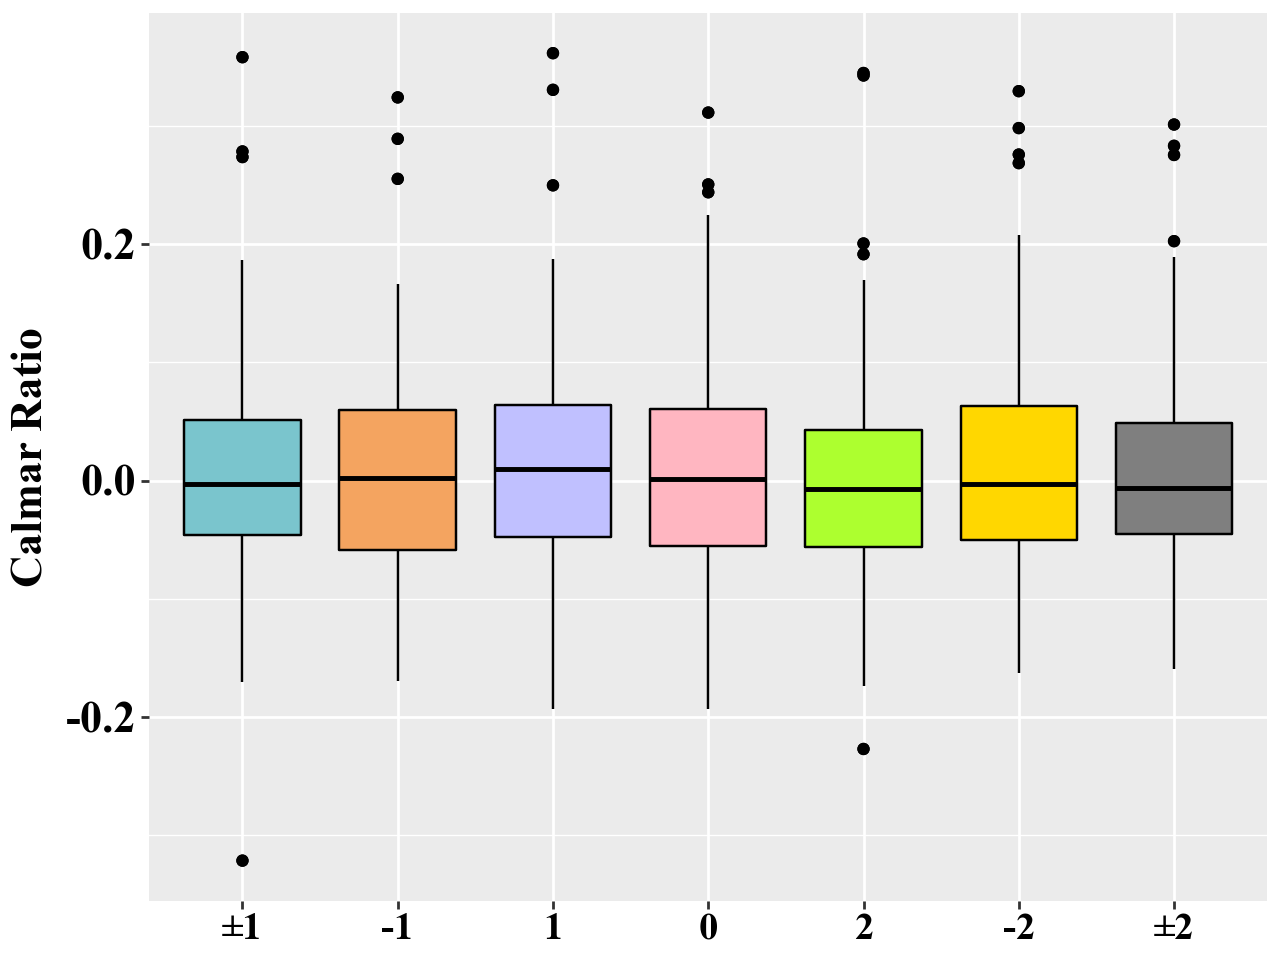

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/boxplot_allstock/Calmar Ratio/MometumSpan_all_boxplot.pdf
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.


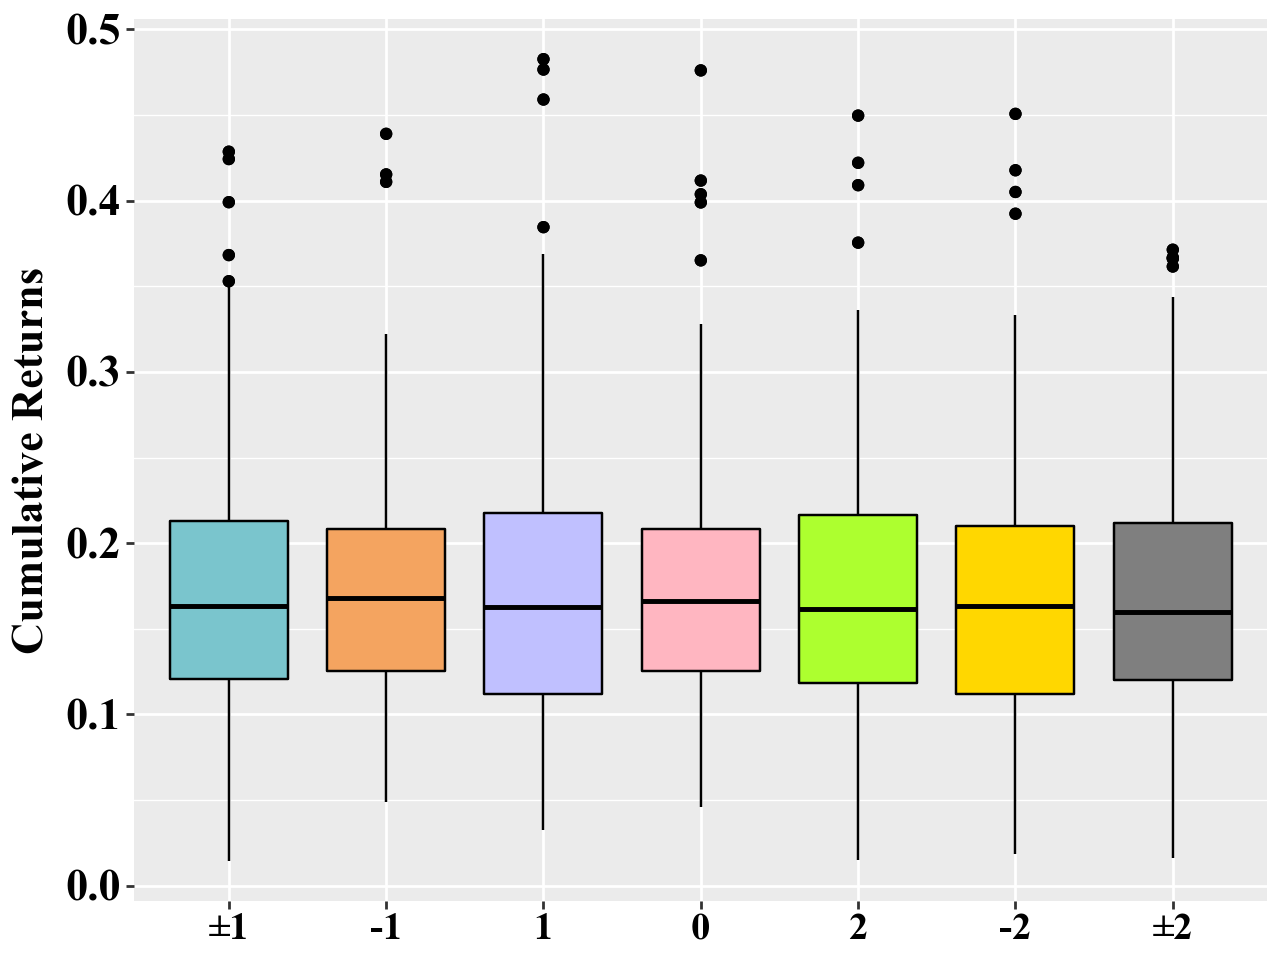

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/boxplot_allstock/Cumulative Returns/MometumSpan_all_boxplot.pdf
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.


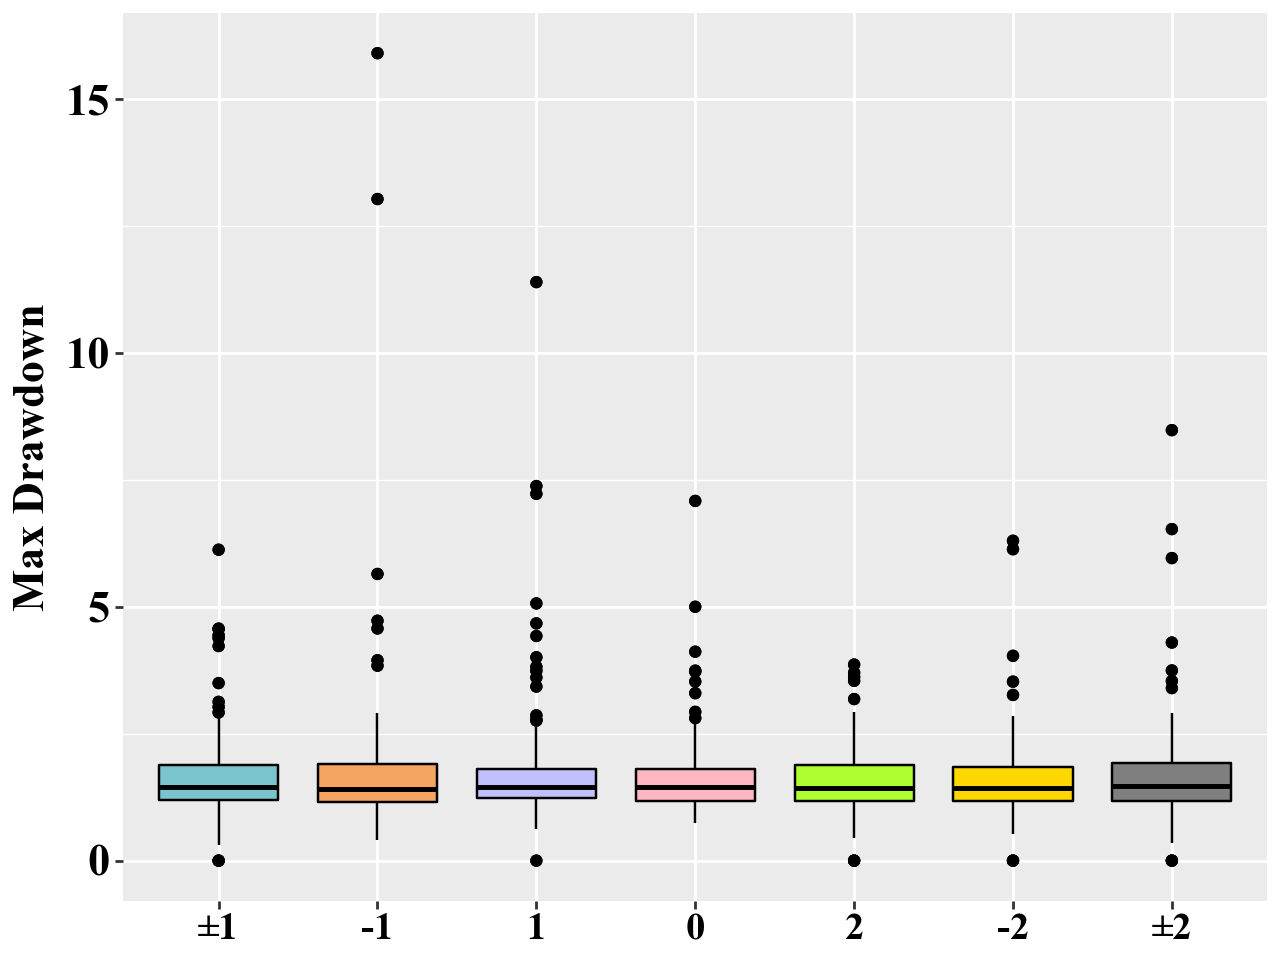

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/boxplot_allstock/Max Drawdown/MometumSpan_all_boxplot.pdf
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 6 values. 7 were requested from it.


In [67]:
dis_pal = 'Set2'
id_vars = ['dataset', 'method', 'Alpha', 'MometumSpan' ] # 
# value_vars = ['Annual Return', 'Sharpe Ratio', 'Alpha Ratio', 'Max Drawdown','Annual Volatility','Accuracy',\
#     'Omega Ratio', 'Sortino Ratio', 'Skew', 'Kurtosis']
value_vars = ['Annual Return', 'Max Drawdown', 'Cumulative Returns','Calmar Ratio']

# 自定义颜色列表
custom_colors = ['#7AC5CD', '#F4A460', '#C0C0FF', '#FFB6C1', '#ADFF2F', '#FFD700']

def wide_to_long(df):
    result_df = pd.melt(df, id_vars=id_vars, value_vars=value_vars, \
        var_name='metric', value_name='value')
    result_df = result_df[id_vars + ['metric', 'value']]
    result_df = result_df.sort_values(by=id_vars).reset_index().drop(columns='index')
    return result_df

def boxplot(d, metric, xtick, data_name='all', saved_it = True):
    # options(repr.plot.width =9, repr.plot.height =9)
    p = (ggplot(d, aes(x=xtick, y="value", fill =xtick)) # 定义映射, fill='alpha'
    + geom_boxplot(color = "k", alpha=1) #, position = position_nudge(x = 0.1, y = 0))#, show_legend=False)
    + scale_fill_manual(values=custom_colors)  # 使用自定义颜色
    # + geom_violin(color = "k", alpha=1, style="right", position = position_nudge(x = -0.1, y = 0))#, show_legend=False)
    # + geom_point(size=1, color = "k", alpha=0.3)
    # + geom_jitter(alpha = 0.3)
    # + stat_summary() # fun_data = mean_se,median_hilow,mean_sdl,mean_cl_boot,mean_cl_normal
    # + geom_tile(aes(width=0.95, height=.95))   # heatmap
    # + geom_text(aes(label='rank'), size=9, color="w") # heatmap上叠加文字
    # + geom_text(aes(label=c),size=6,color="black",nudge_x=.2, nudge_y=df[c].max()/50)
    # + scale_color_brewer(palette='Blues') 
    # + scale_fill_brewer(palette='Blues') 
    # + scale_color_cmap_d(name= dis_pal)     # plt.cm.ListedCmap
    # + scale_fill_cmap_d(name= dis_pal)     # plt.cm.ListedCmap
    + xlab('')  # 去掉 X 轴标题
    # + scale_color_prism('warm_and_sunny') 
    # + scale_fill_prism('warm_and_sunny') 
    # + scale_color_manual(['white', 'black']) # new
    # + theme(legend_position=(-0.3,-0.5))
    # + theme(axis_text_x=element_text(angle=90))
    # + prism_fill_pal("autumn_leaves")
    # + theme_prism()
    + ylab(metric)
    + theme(legend_position='none') 
    + theme(axis_title_x = element_text(rotation=0, size=16, face="bold", family="Times New Roman"),  # X-axis title bold
            axis_title_y = element_text(size=16, face="bold", family="Times New Roman"),  # Y-axis title bold
            plot_title = element_text(size=16, face="bold", hjust=0.5, family="Times New Roman")
           )

    + theme(axis_text_x = element_text(rotation=0, size=14, face="bold", hjust=0.5, color="#000000", family="Times New Roman"), 
            axis_text_y = element_text(size=16, face="bold", color="#000000", family="Times New Roman"),
            panel_grid_major=element_line(color="#ffffff"),             # 调整网格线颜色为浅灰
            )
    # + theme(legend_position=(0.6,0.9), legend_direction='horizontal')
    # + coord_flip() 
    # + facet_grid("dataset~metric", scales="free")
    # + ggsave("test.pdf")
    # + coord_flip()
    )
    
    all_or_each = 'all' if data_name == 'all' else 'each'
    save_path = f'parameters/boxplot_{all_or_each}stock/{metric}/{xtick}_{data_name}_boxplot.pdf'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    p.show()
    
    return p.save(f'parameters/boxplot_{all_or_each}stock/{metric}/{xtick}_{data_name}_boxplot.pdf') if saved_it else p

df = pd.read_csv('param_group.csv').rename(columns={'stock':'dataset', 
                                                    'max_drawdown':'Max Drawdown',
                                                    'annual_return': 'Annual Return', 
                                                    'sharpe_1x_no_short':'Sharpe Ratio', 
                                                    'alpha_ratio':'Alpha Ratio',
                                                    'annual_volatility':'Annual Volatility', 
                                                    'accuracy':'Accuracy', 
                                                    'omega_ratio':'Omega Ratio',
                                                    'sortino_ratio':'Sortino Ratio', 
                                                    'skew':'Skew', 'kurtosis':'Kurtosis', 
                                                    'cumulative_returns':'Cumulative Returns',
                                                    'calmar_ratio':'Calmar Ratio'})

df = wide_to_long(df)
df['Alpha'] = df['Alpha'].astype(str)
MometumSpan_ordered = ['±1','-1','1', '0','2','-2','±2']
df['MometumSpan'] = df['MometumSpan'].astype(str).astype(CategoricalDtype(MometumSpan_ordered, ordered=True))

# 这里选择超参数
xtick = 'MometumSpan'  
# xtick = 'Alpha'

# 选项一：all stock
for dx in df.groupby(['metric']): 
    boxplot(dx[1], dx[0][0], data_name='all', xtick=xtick) 
    
# 选项二：each stock 
# for dx in df.groupby(['metric','dataset']): 
#     boxplot(dx[1], metric=dx[0][0], data_name=dx[0][1], xtick=xtick) 

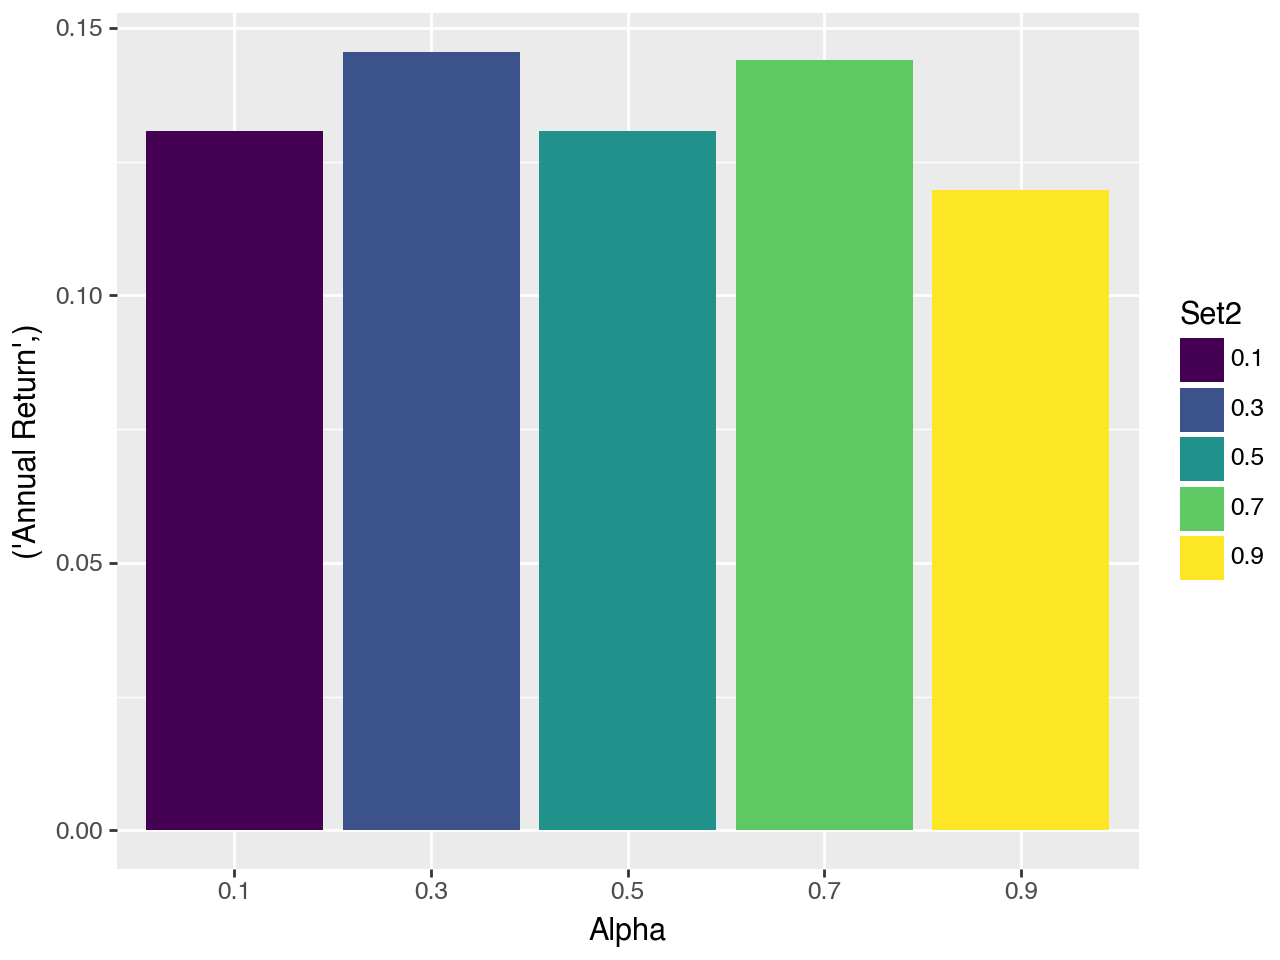

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_allstock/('Annual Return',)/Alpha_all_barplot.pdf


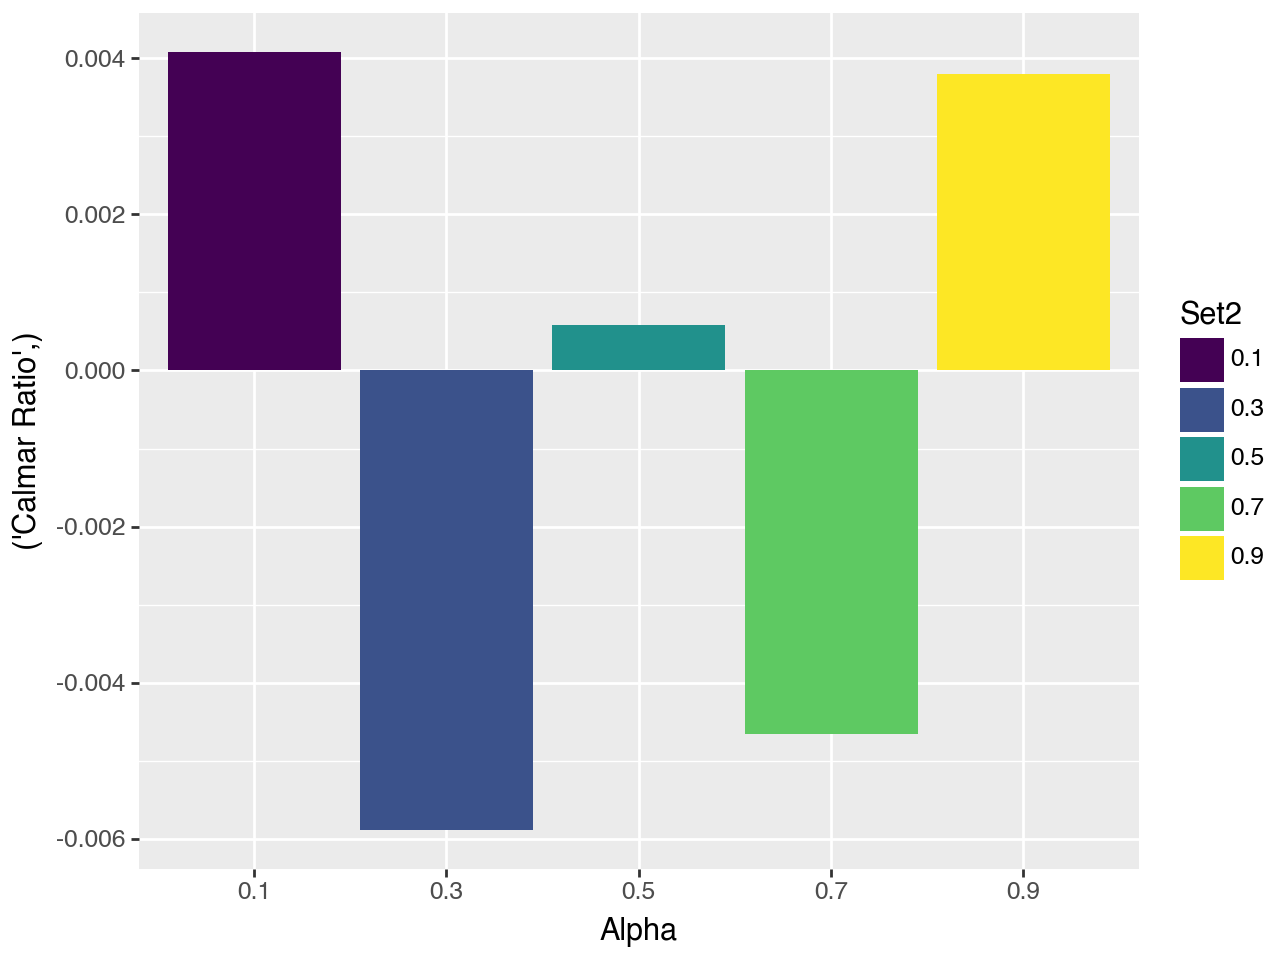

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_allstock/('Calmar Ratio',)/Alpha_all_barplot.pdf


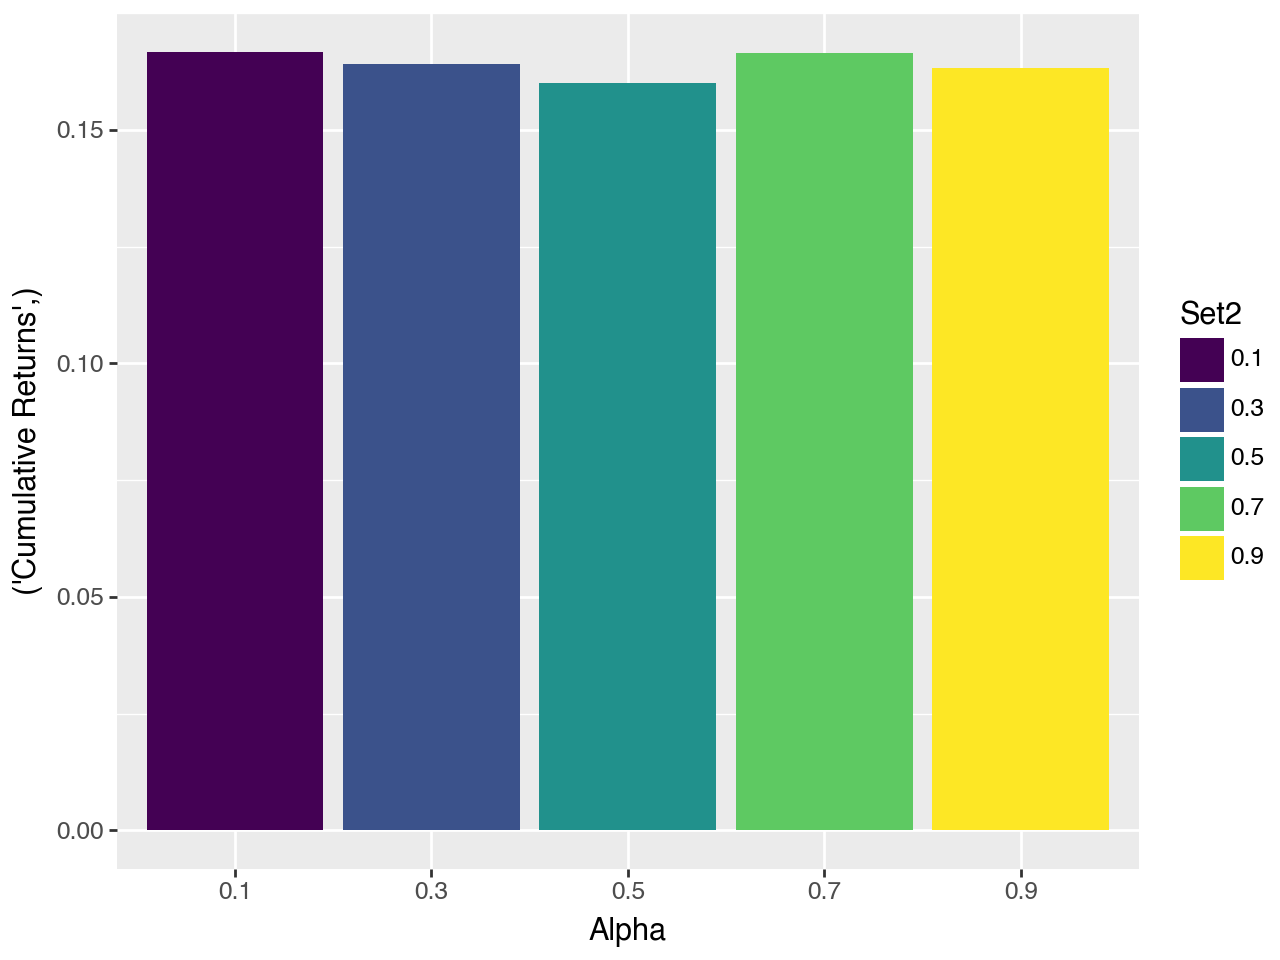

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_allstock/('Cumulative Returns',)/Alpha_all_barplot.pdf


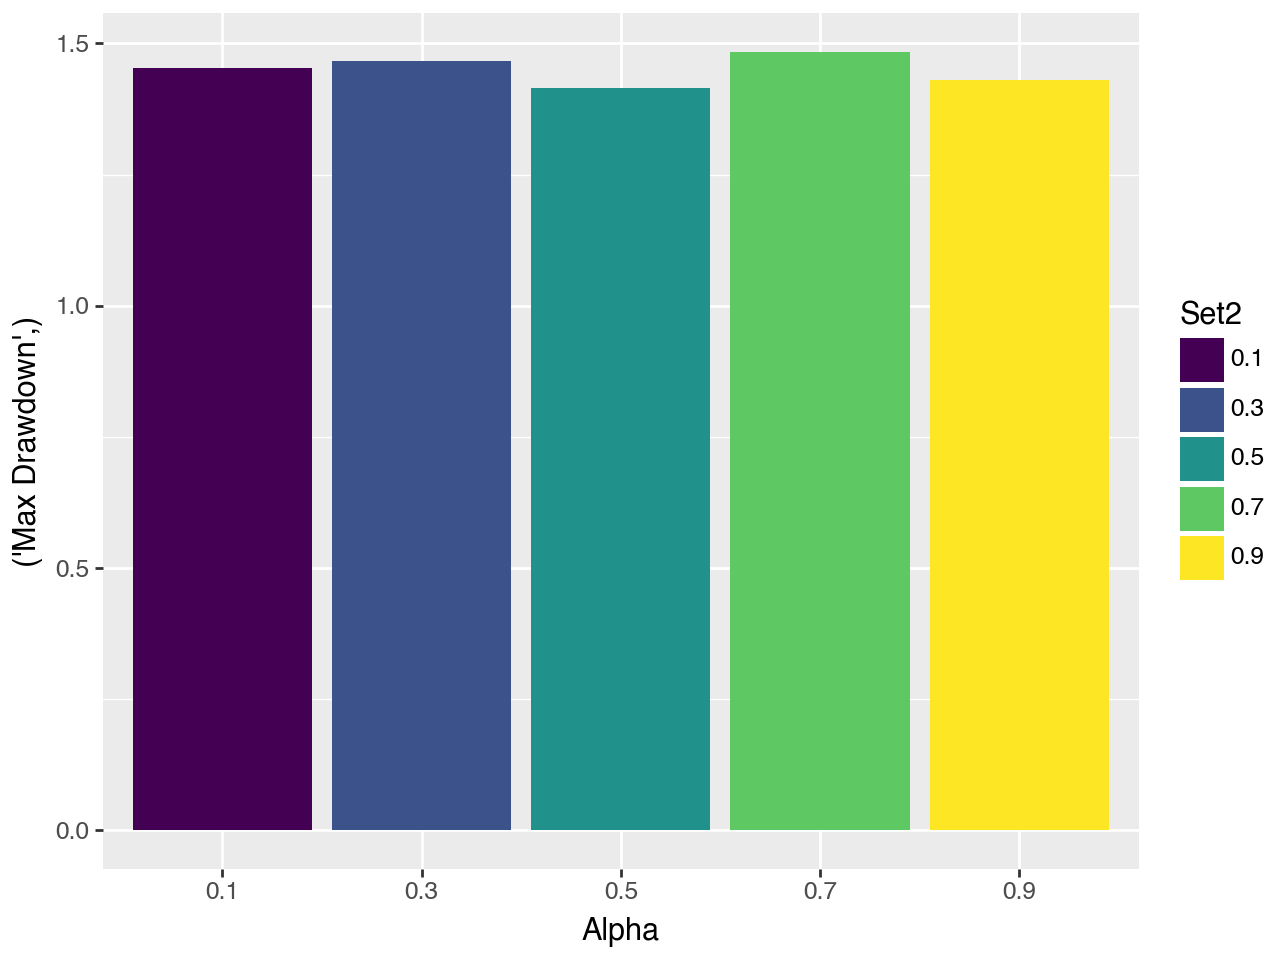

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_allstock/('Max Drawdown',)/Alpha_all_barplot.pdf


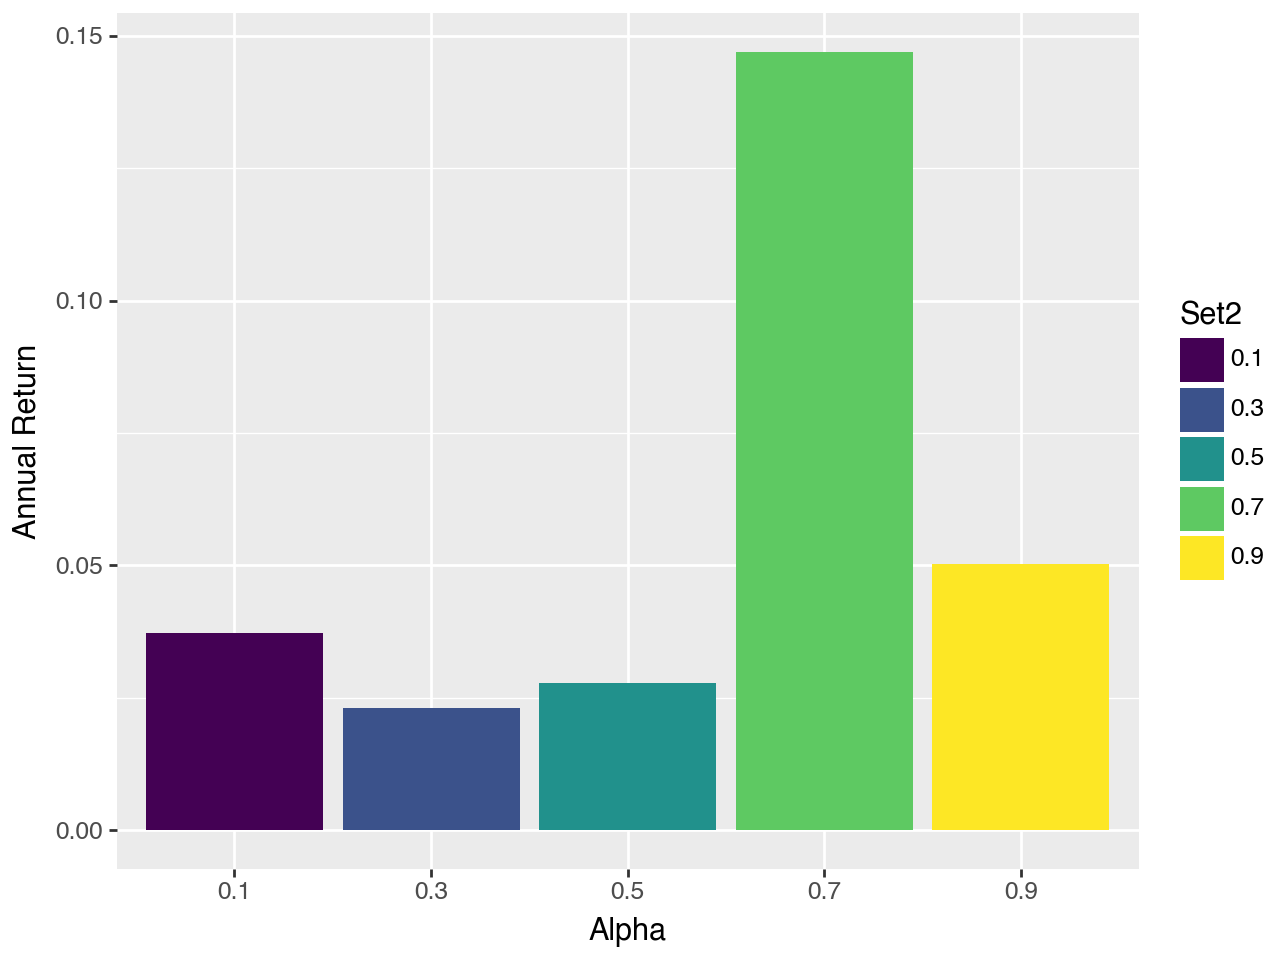

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_AAPL_barplot.pdf


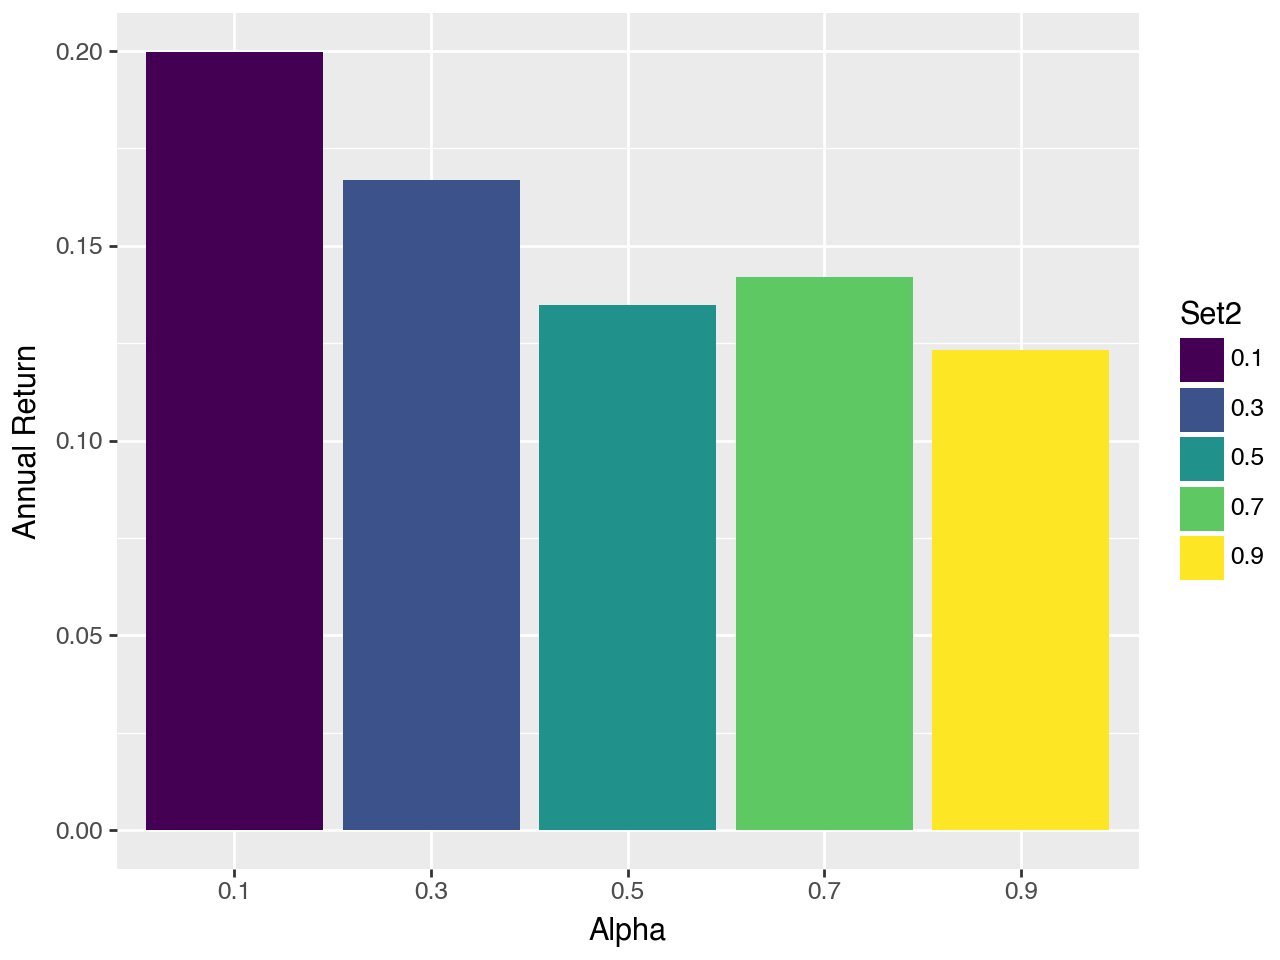

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_ABBV_barplot.pdf


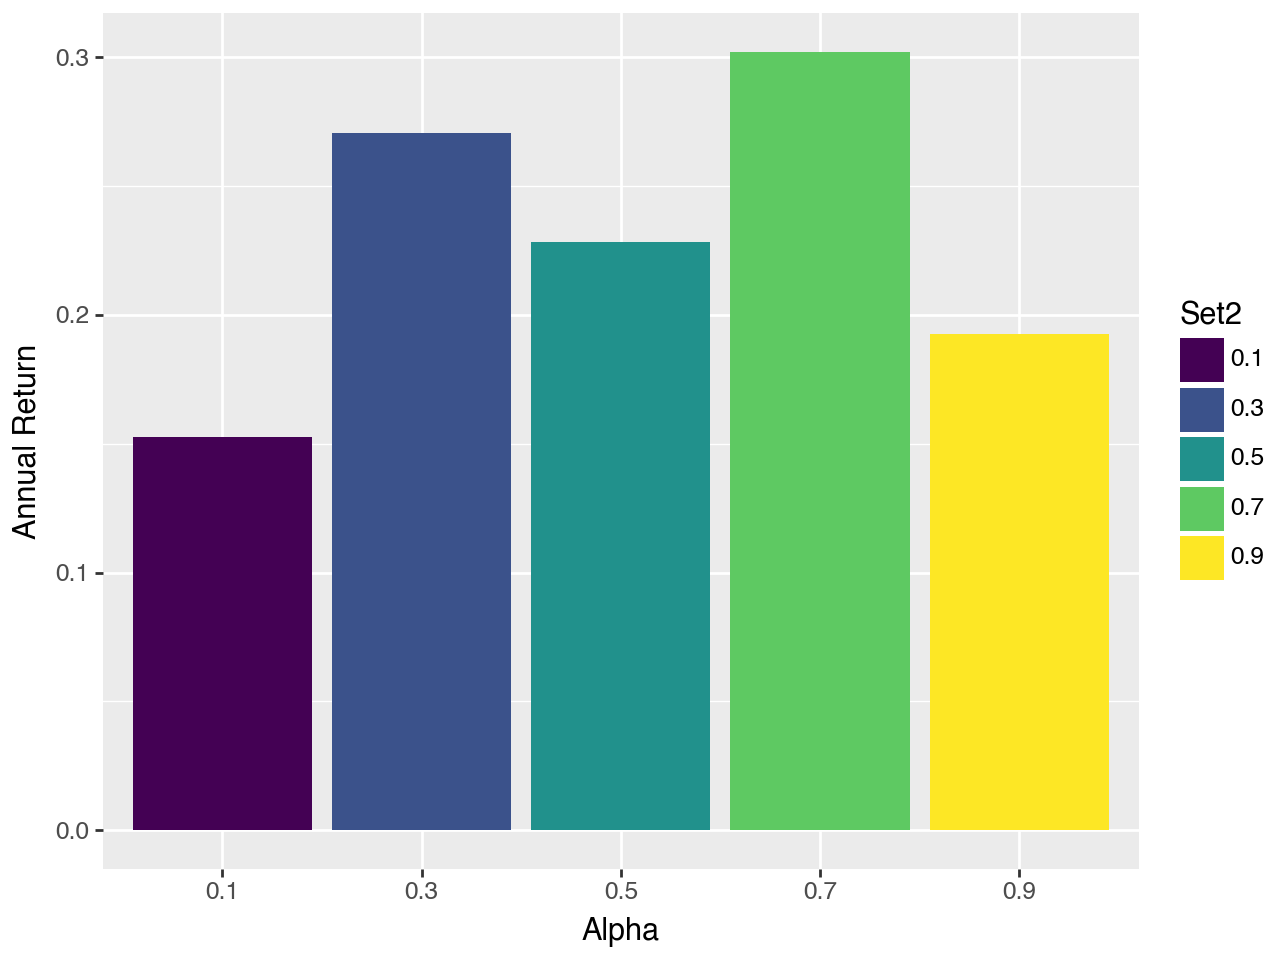

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_ACN_barplot.pdf


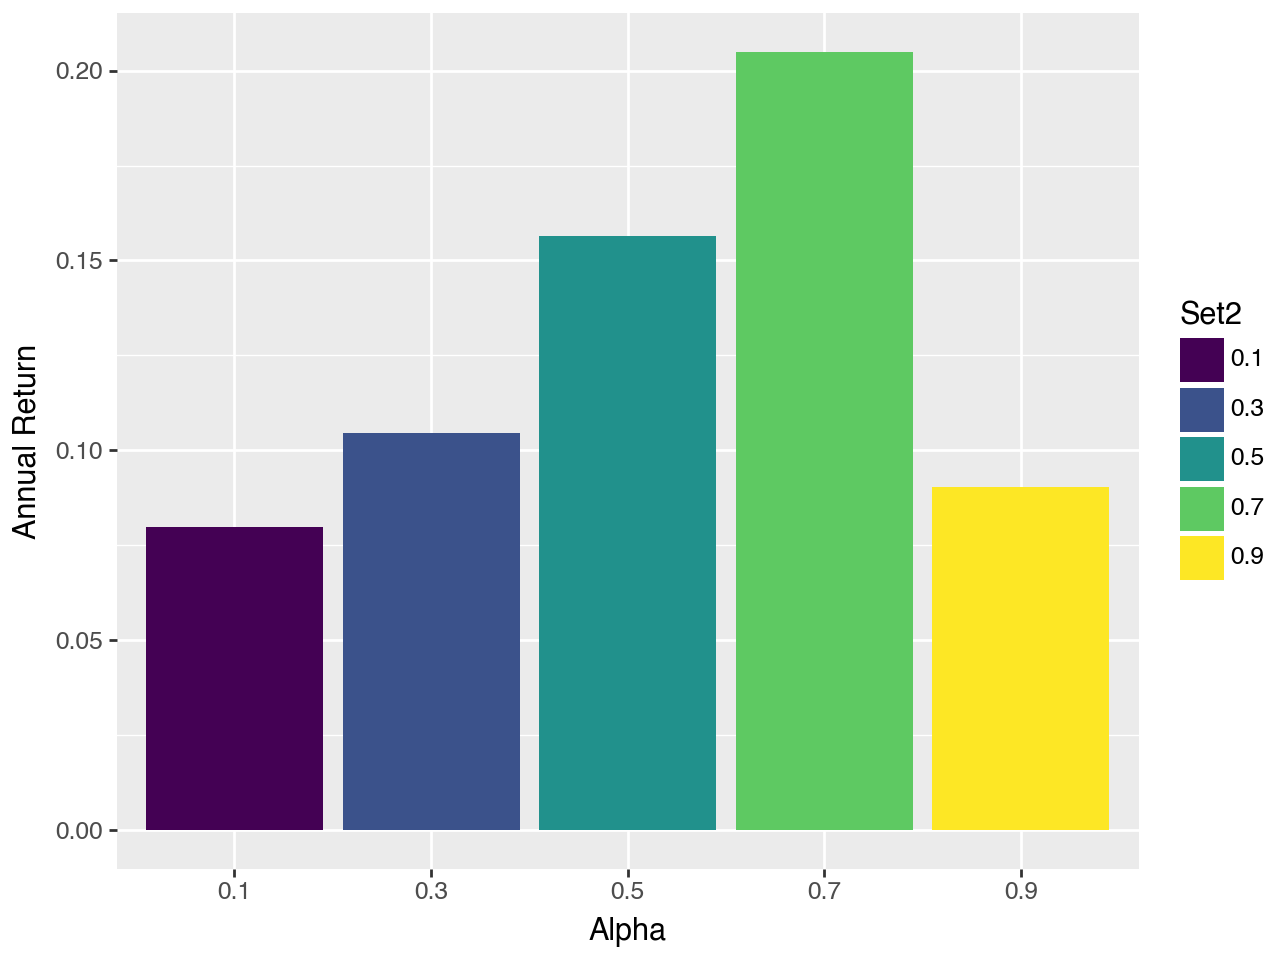

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_ADBE_barplot.pdf


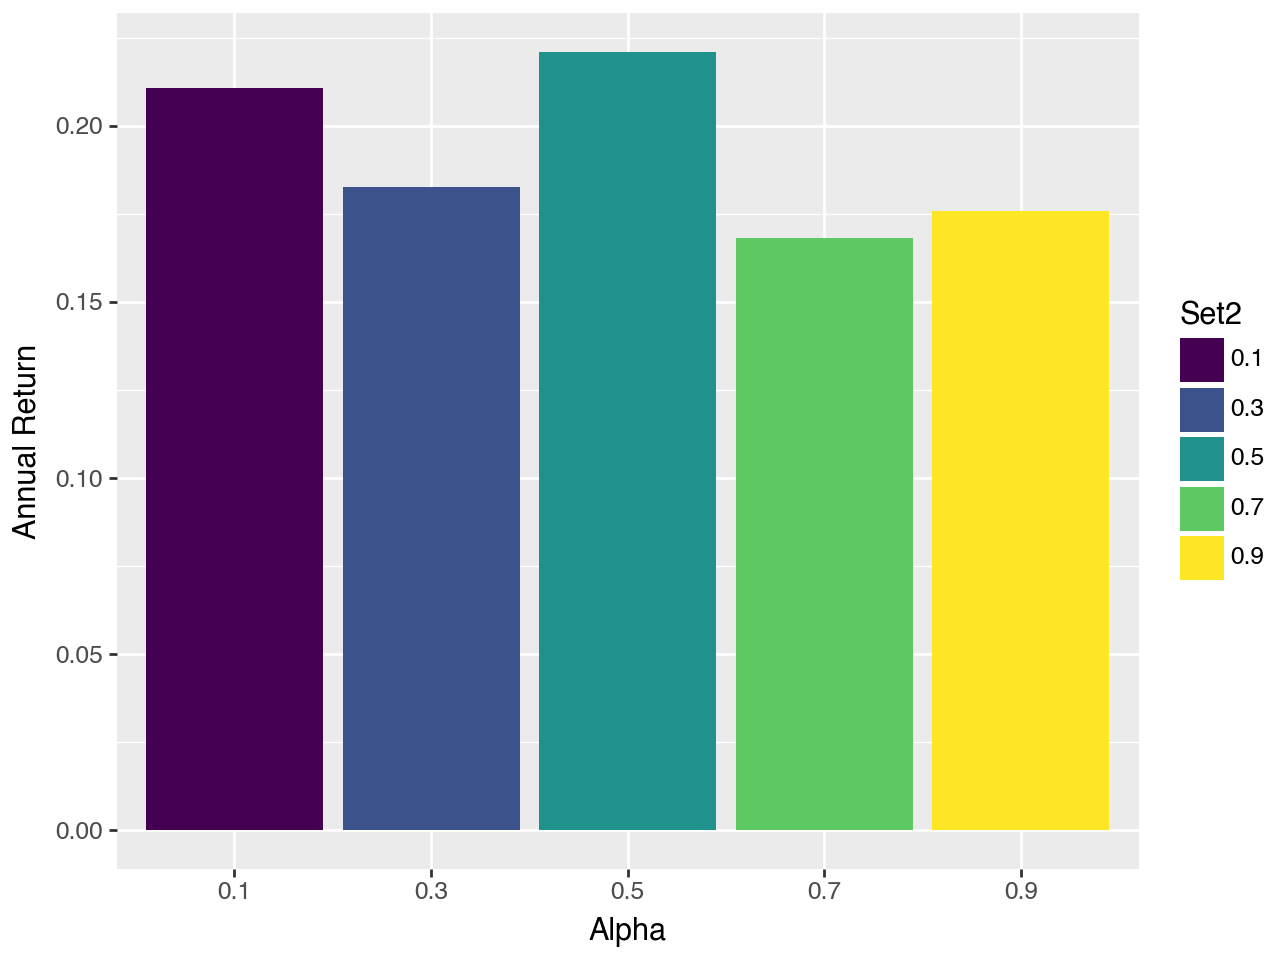

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_ADP_barplot.pdf


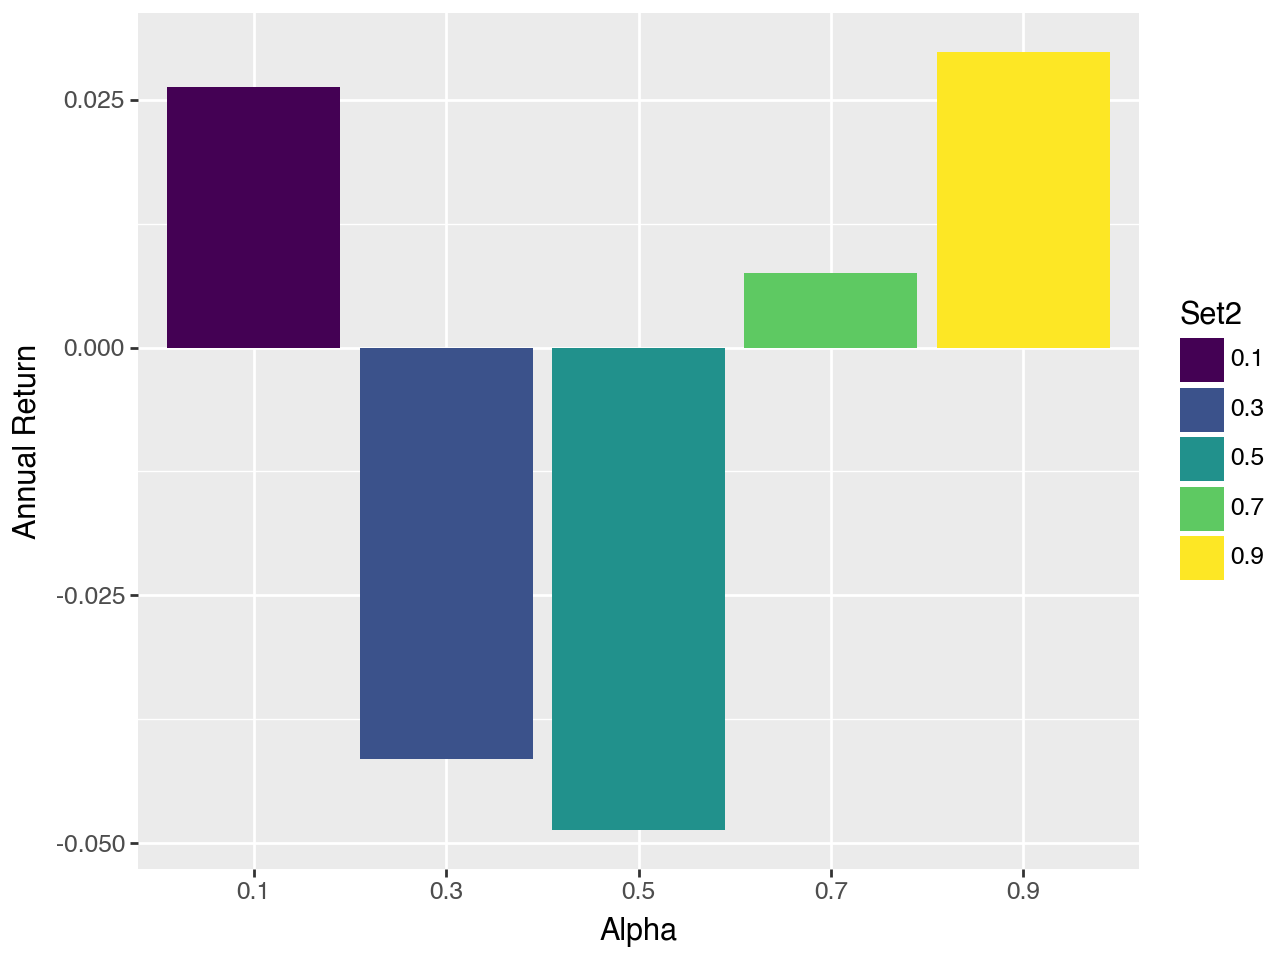

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_AMT_barplot.pdf


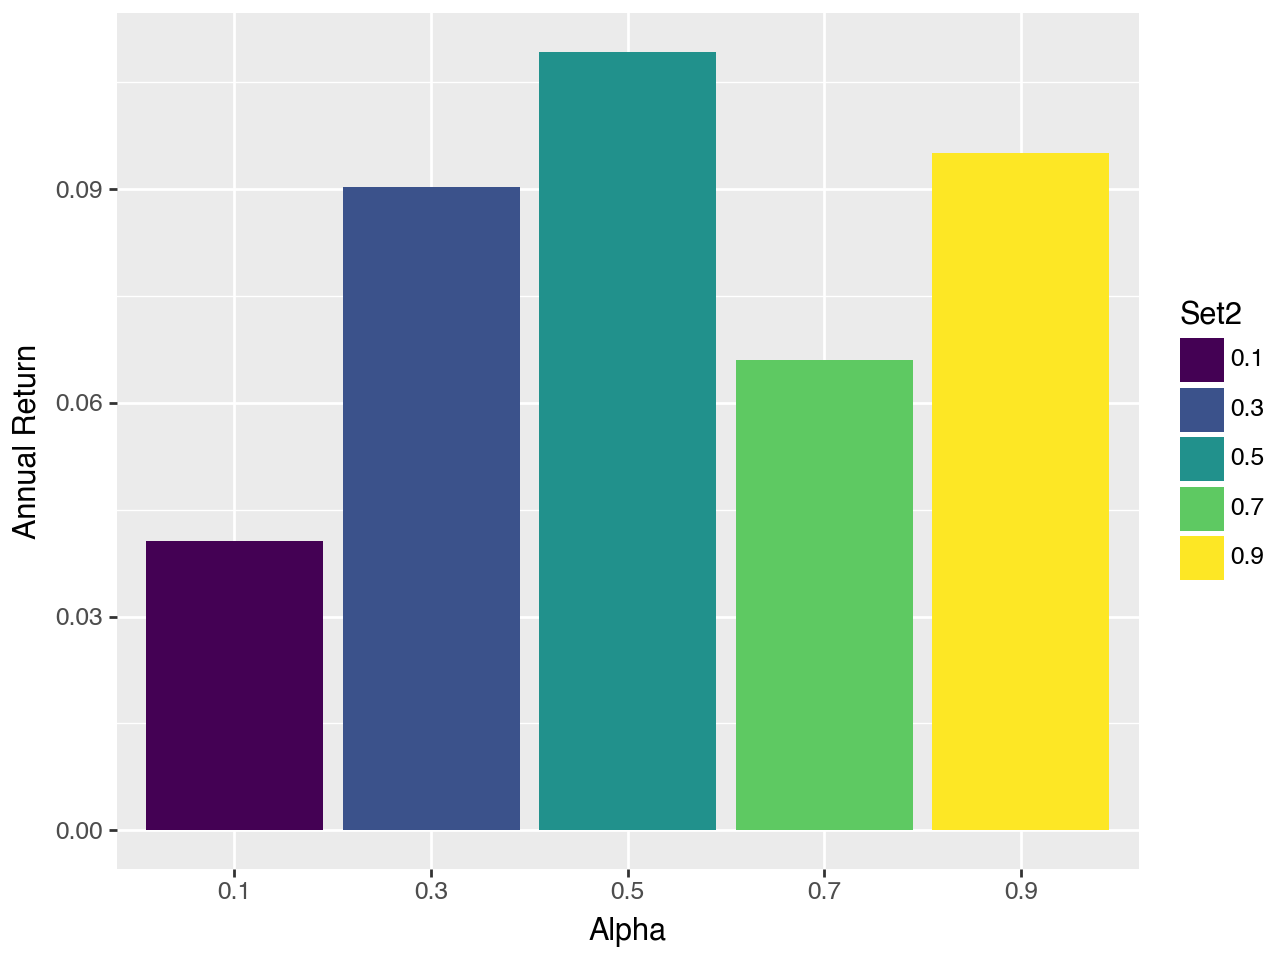

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_APD_barplot.pdf


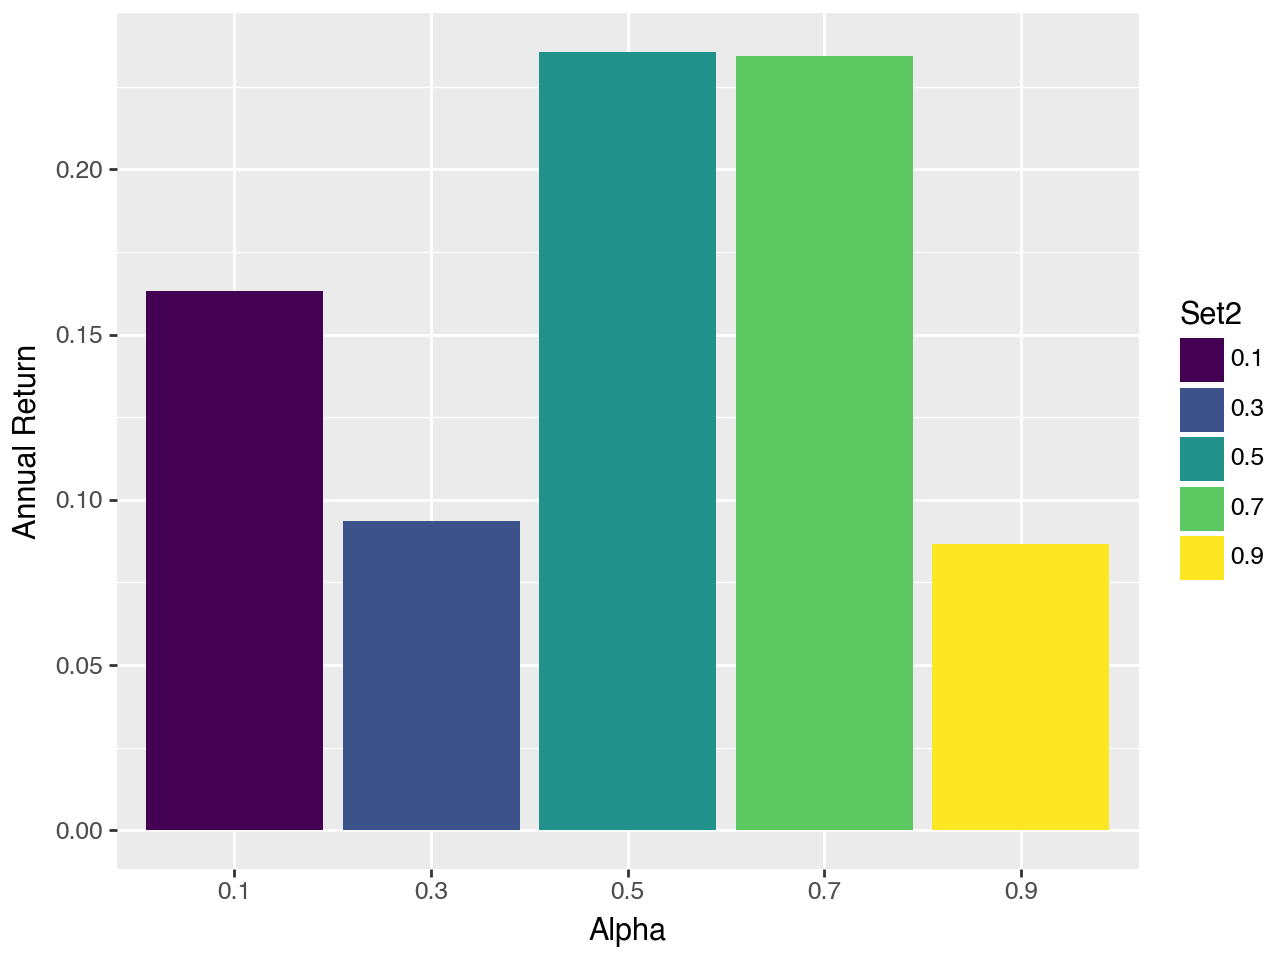

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_AVGO_barplot.pdf


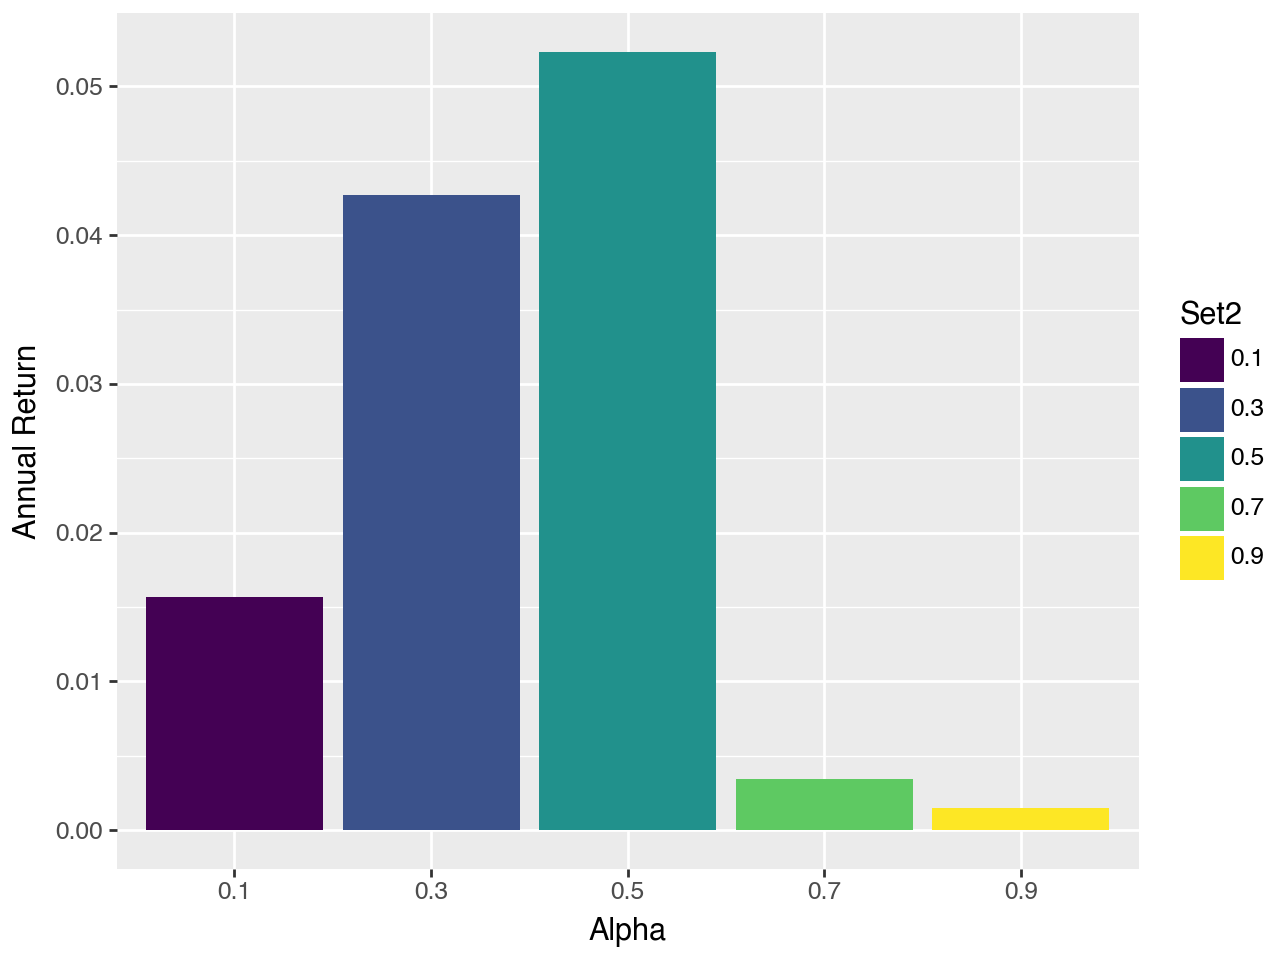

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_AWK_barplot.pdf


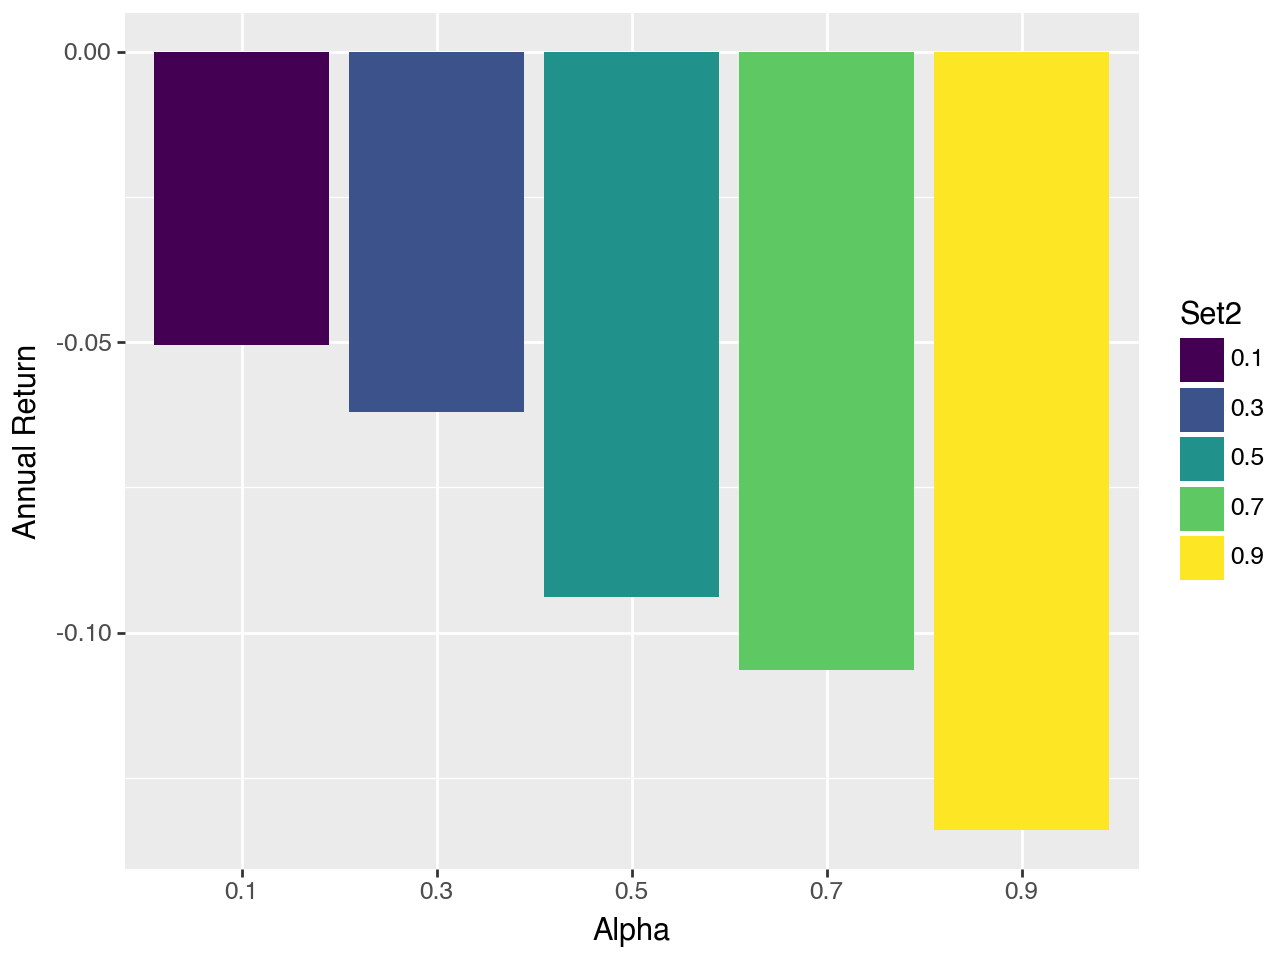

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_BA_barplot.pdf


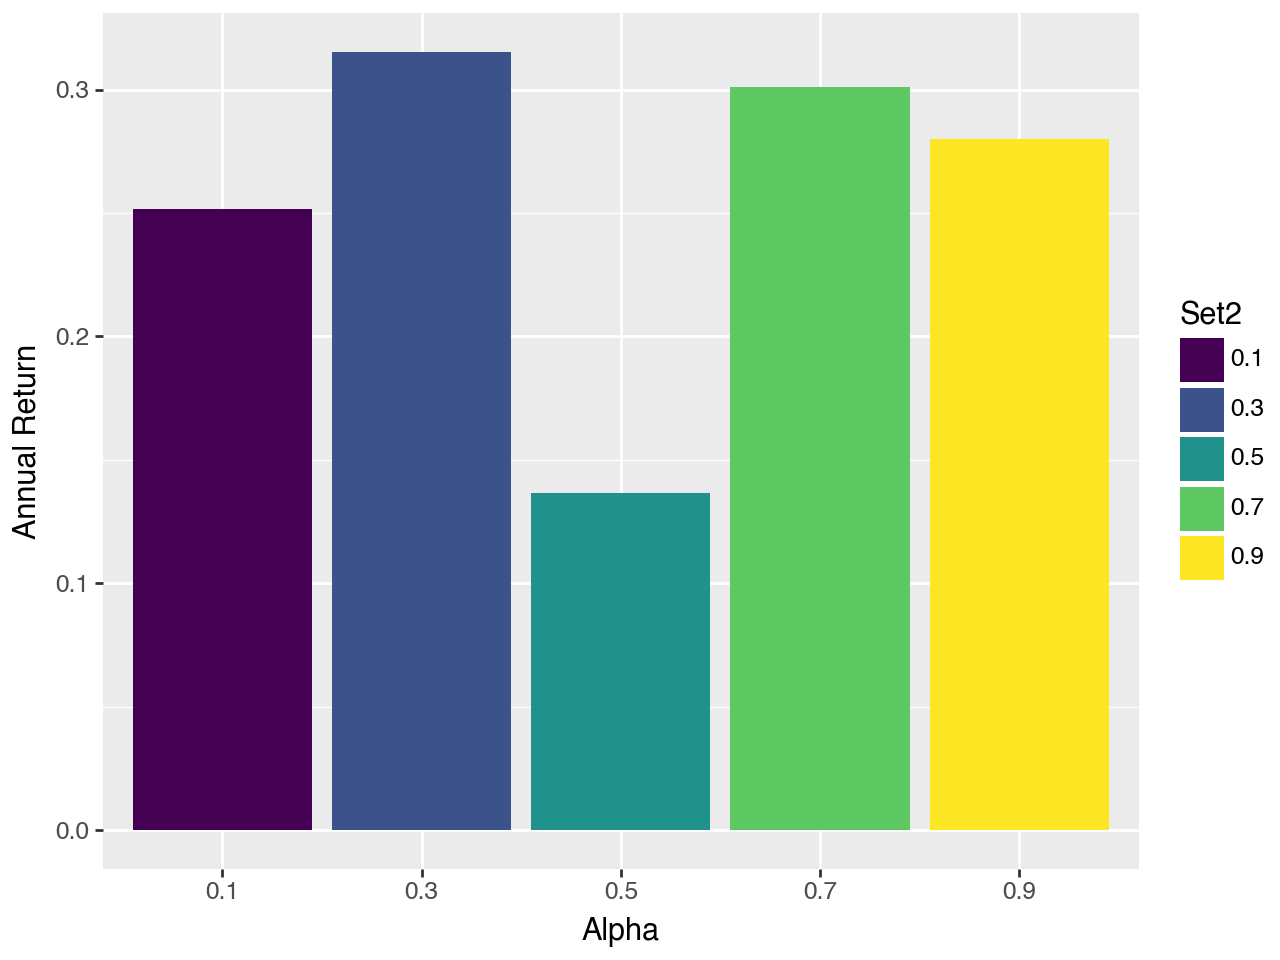

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_BAC_barplot.pdf


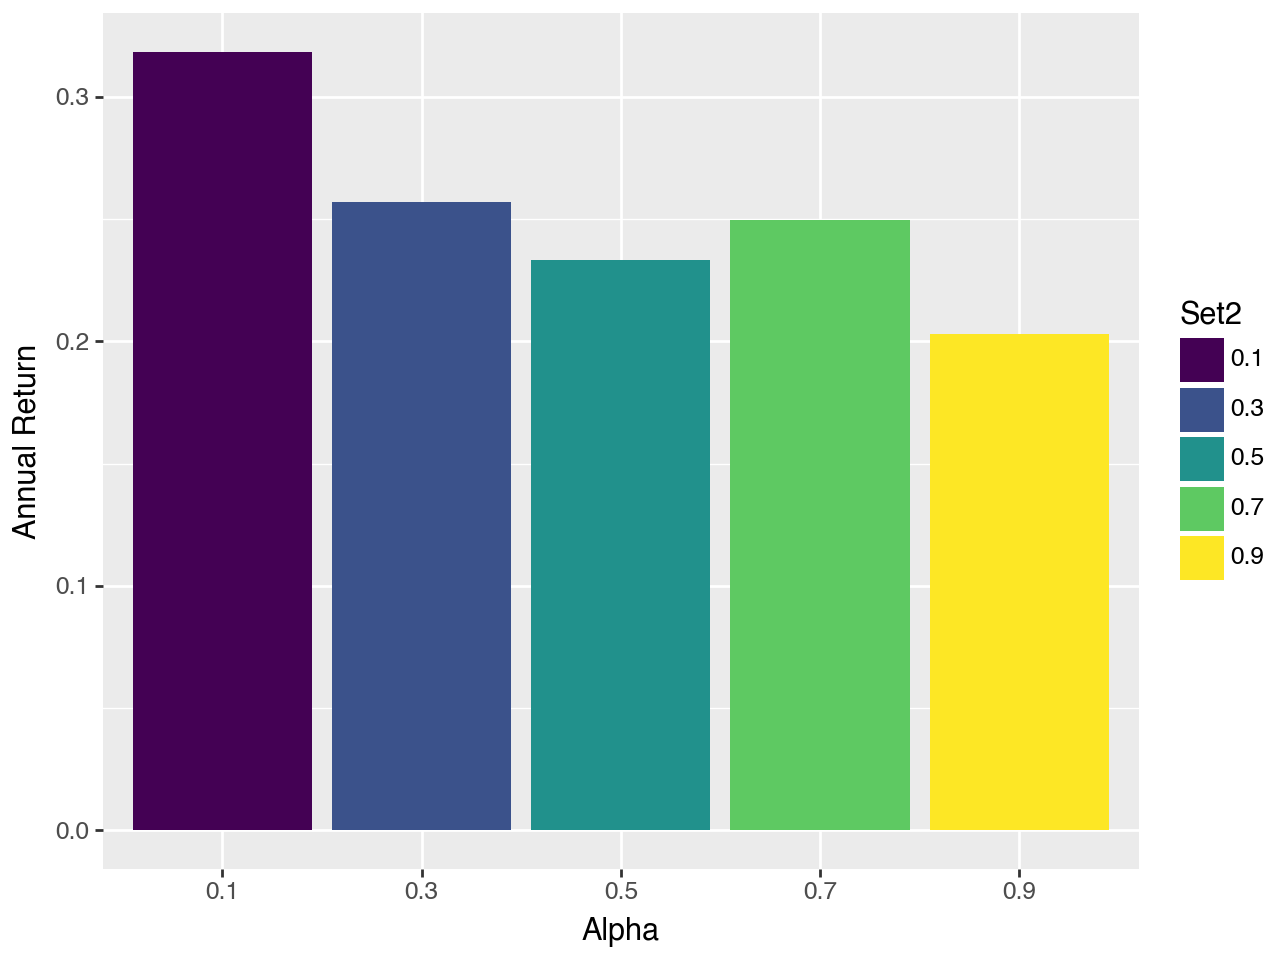

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_BBL_barplot.pdf


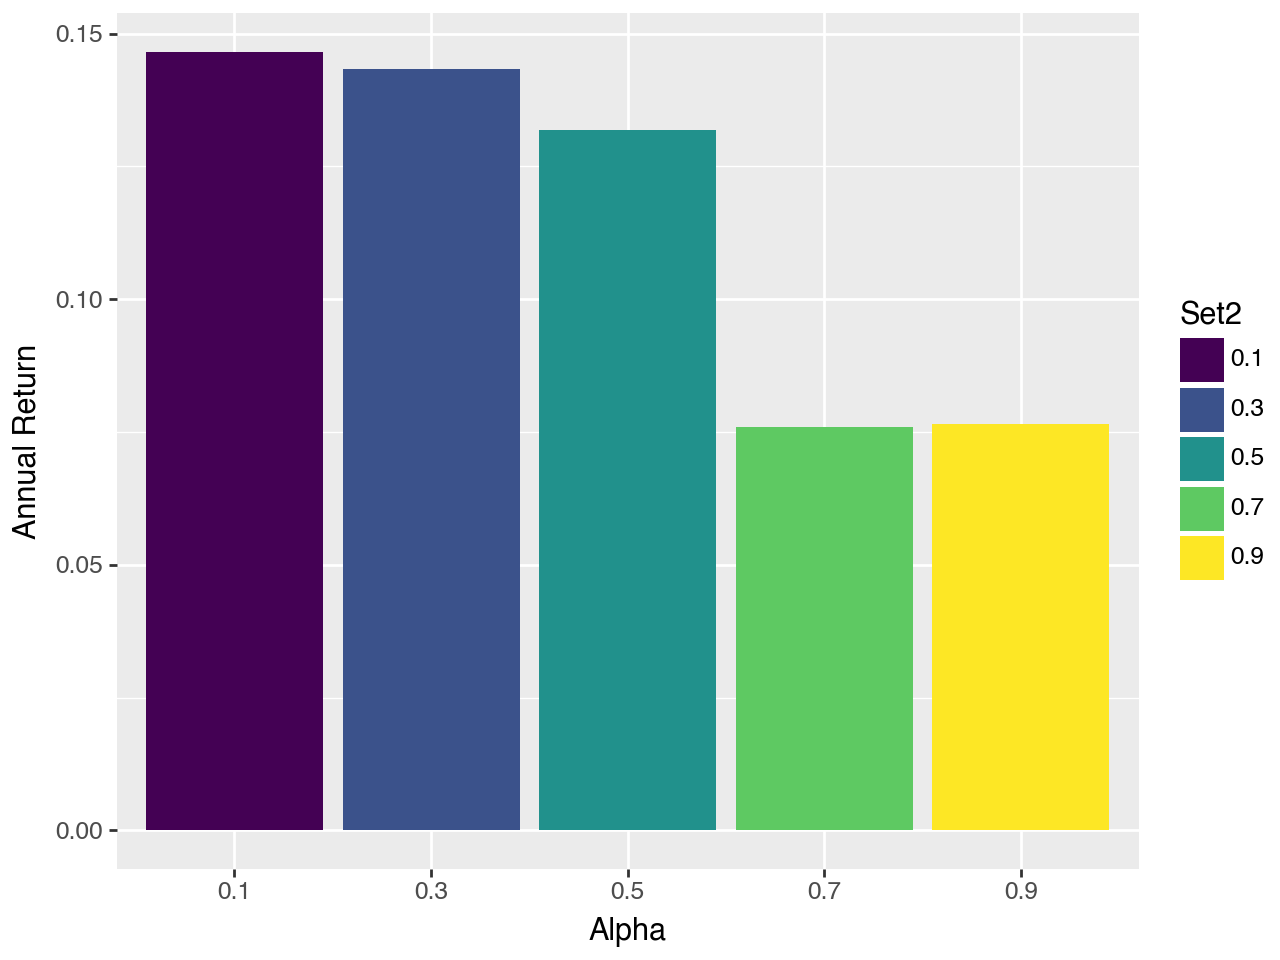

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_BHP_barplot.pdf


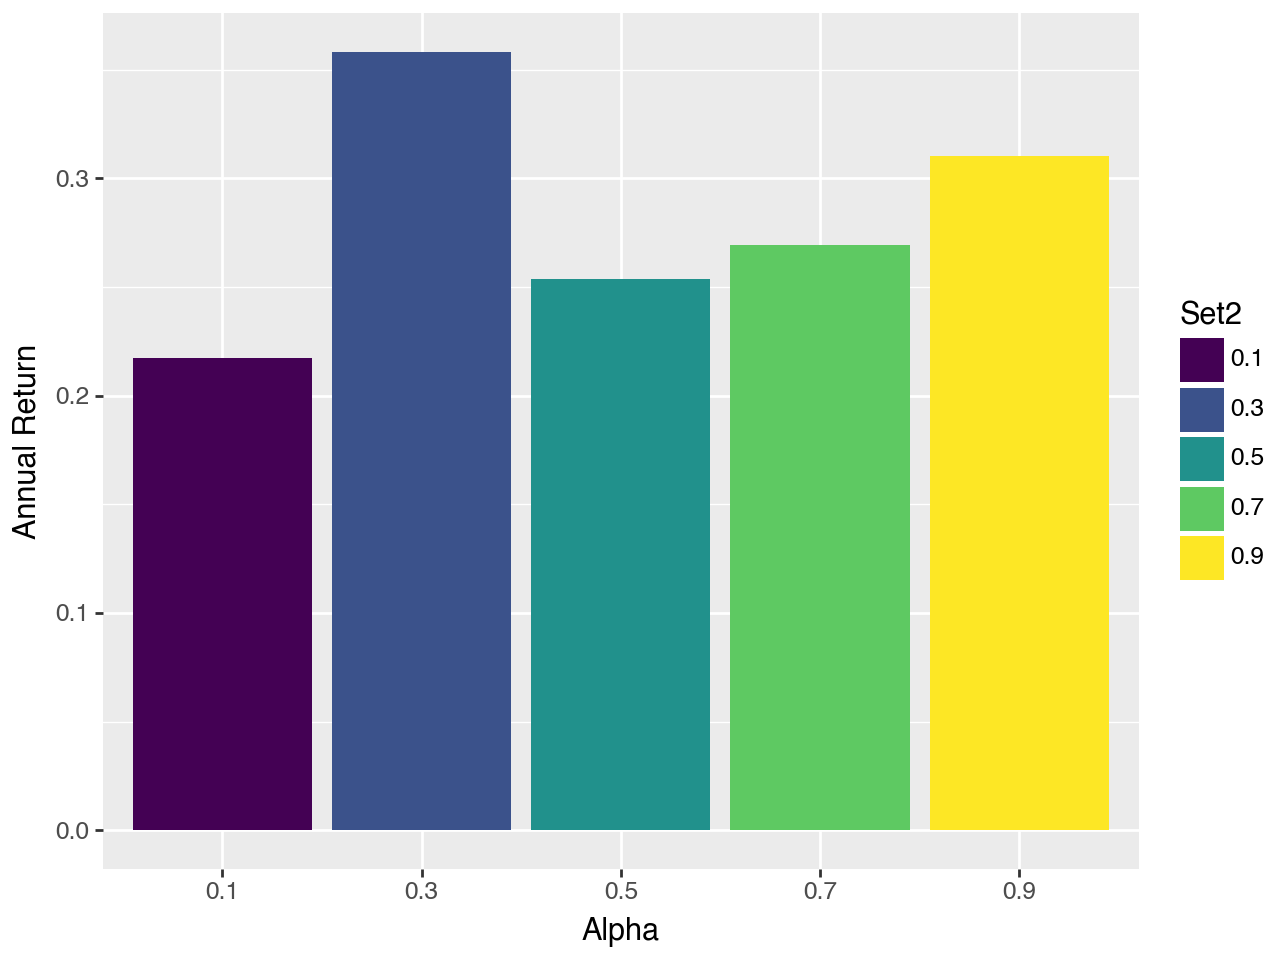

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_BP_barplot.pdf


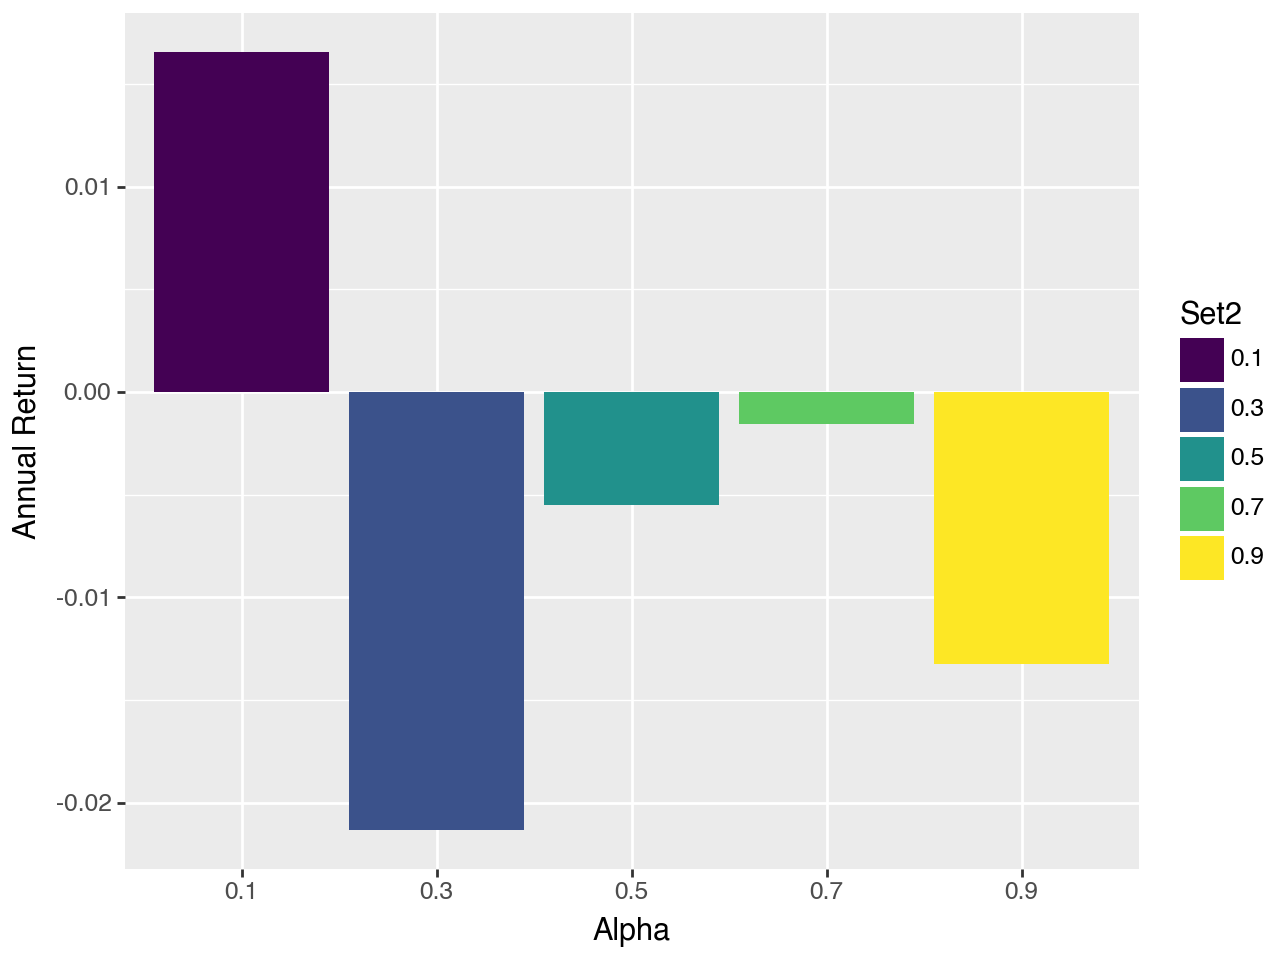

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_BRK-A_barplot.pdf


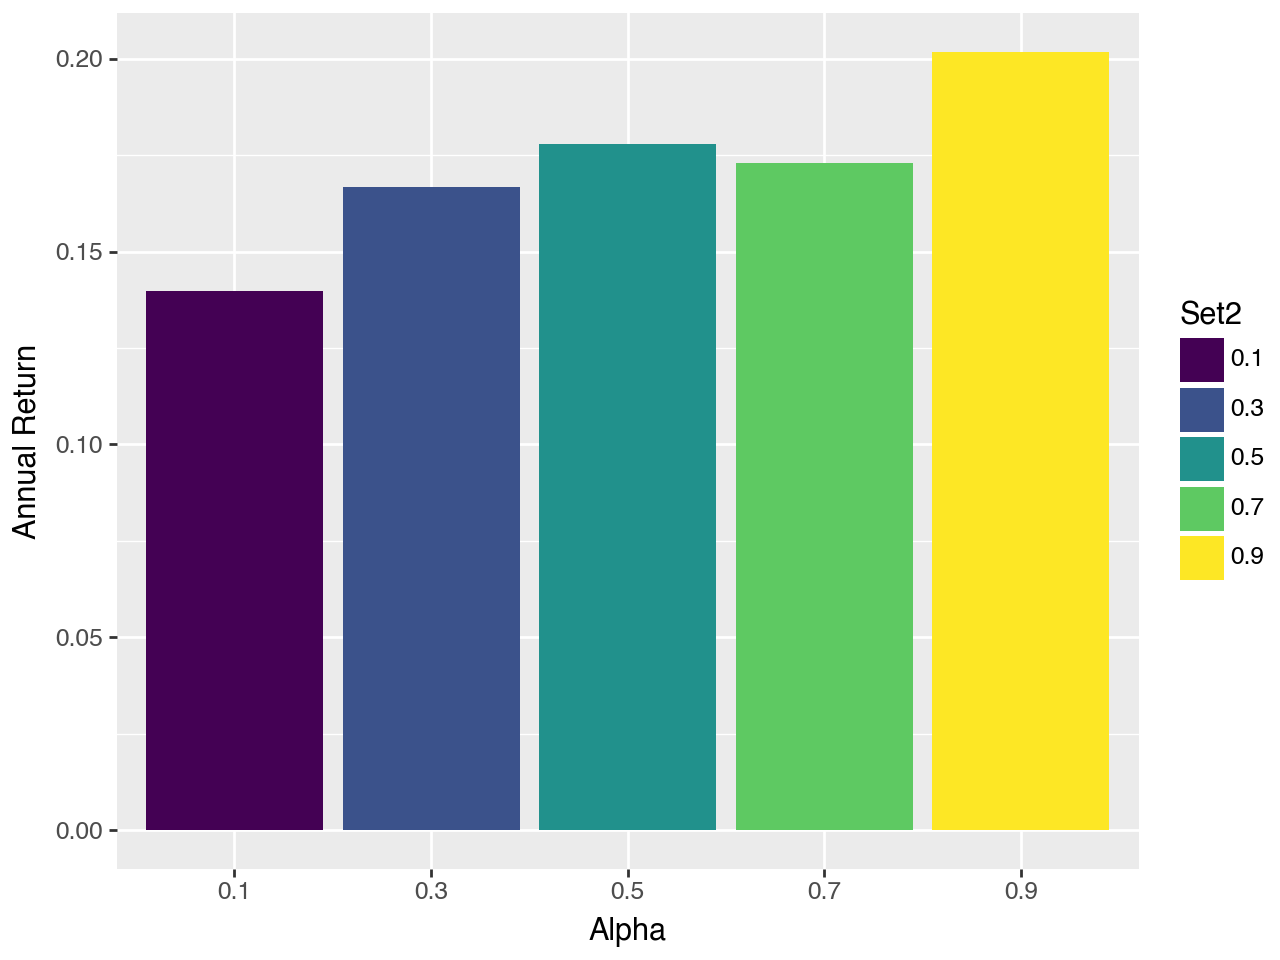

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_CCI_barplot.pdf


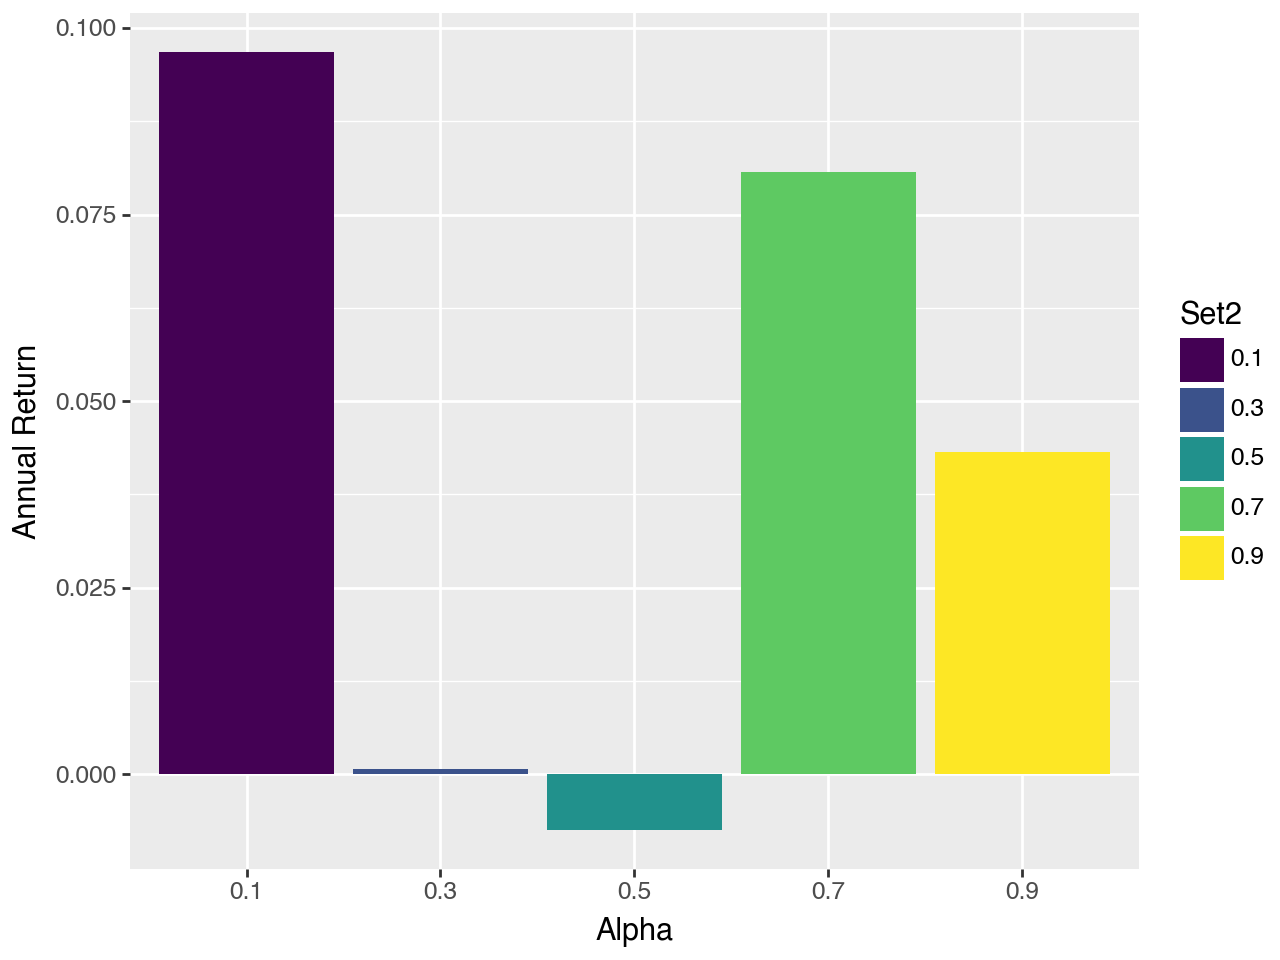

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_CHTR_barplot.pdf


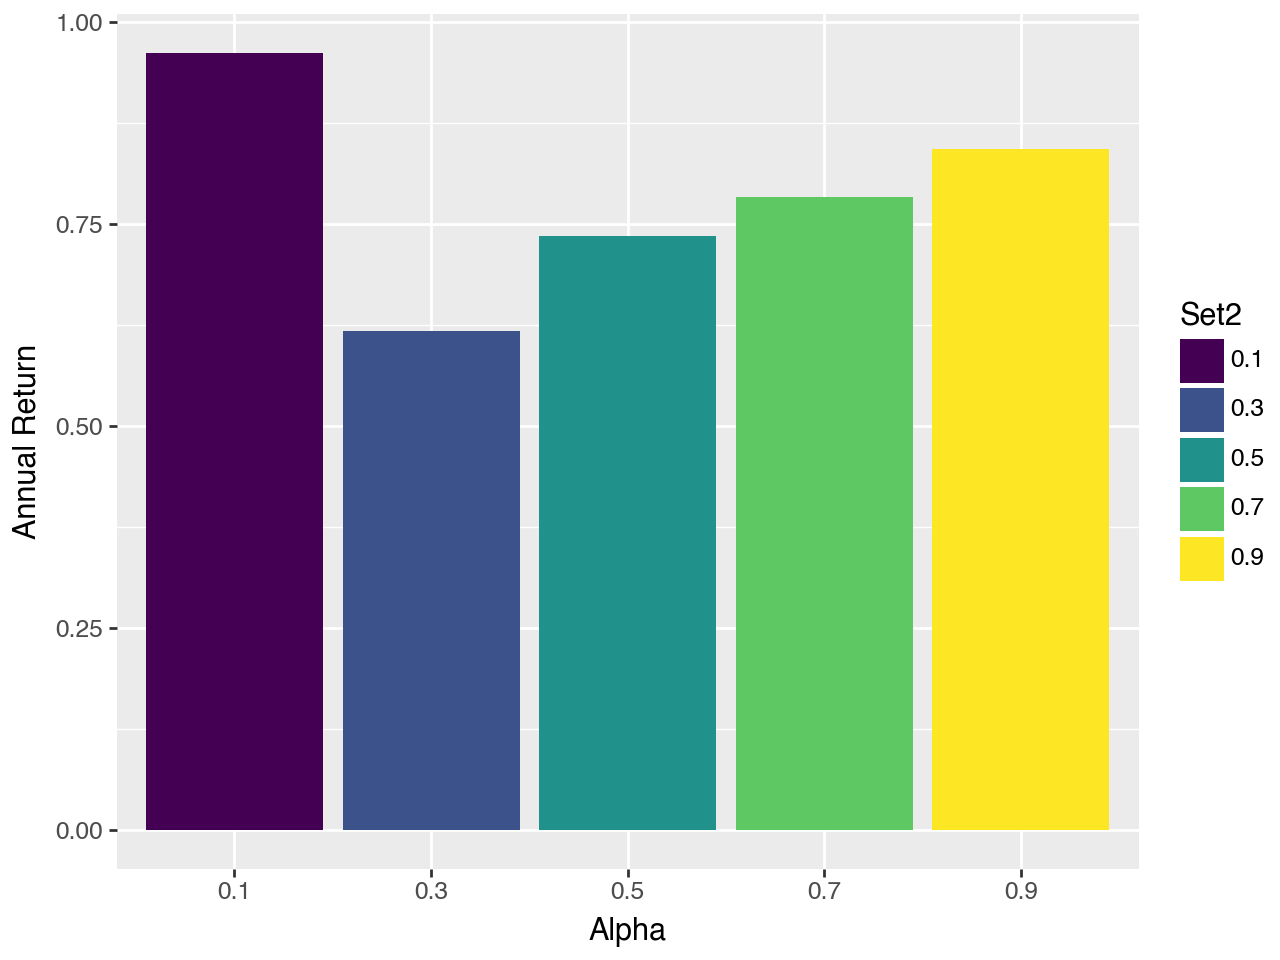

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_COP_barplot.pdf


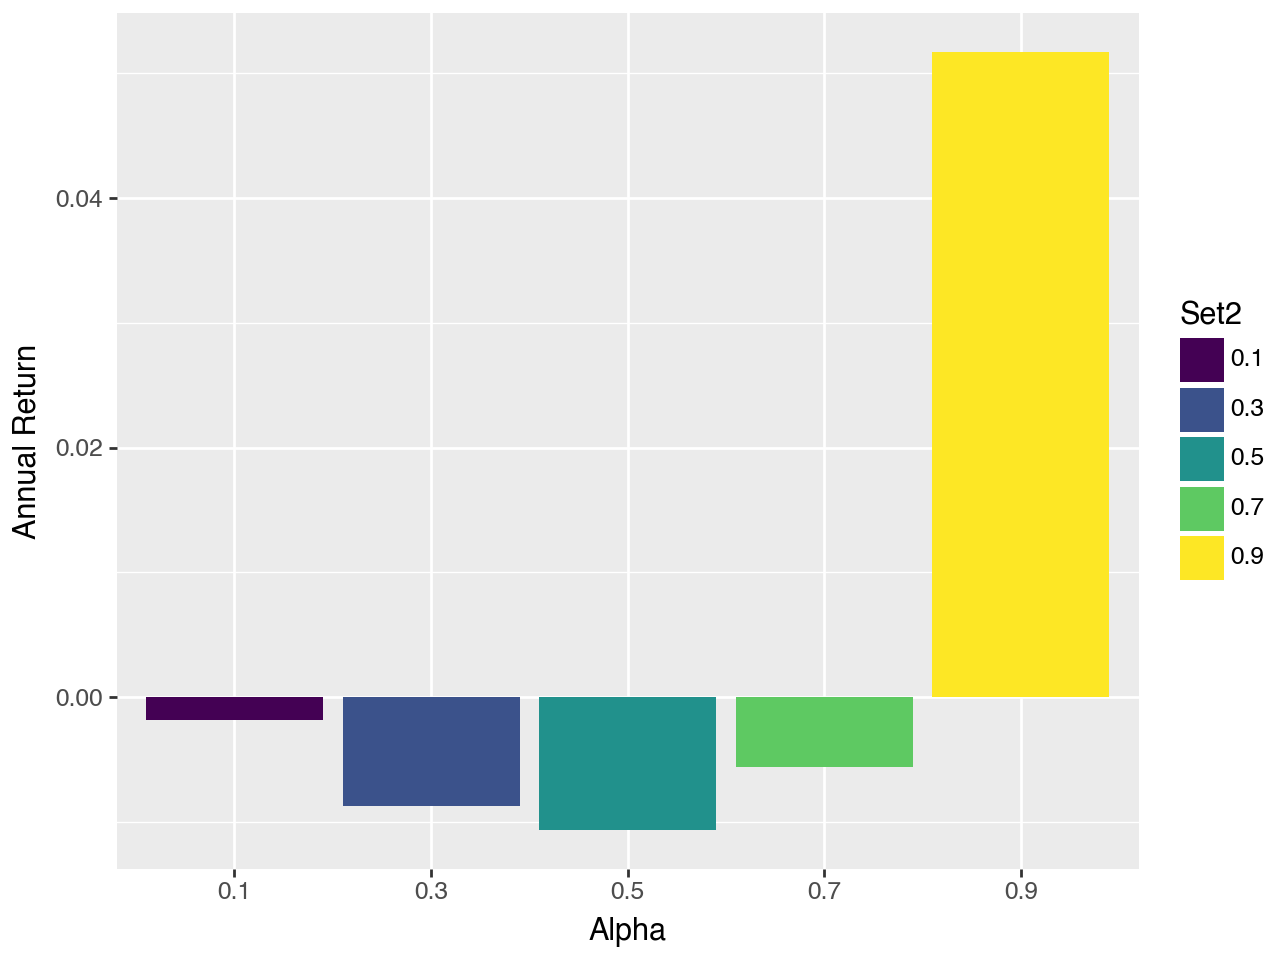

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_COST_barplot.pdf


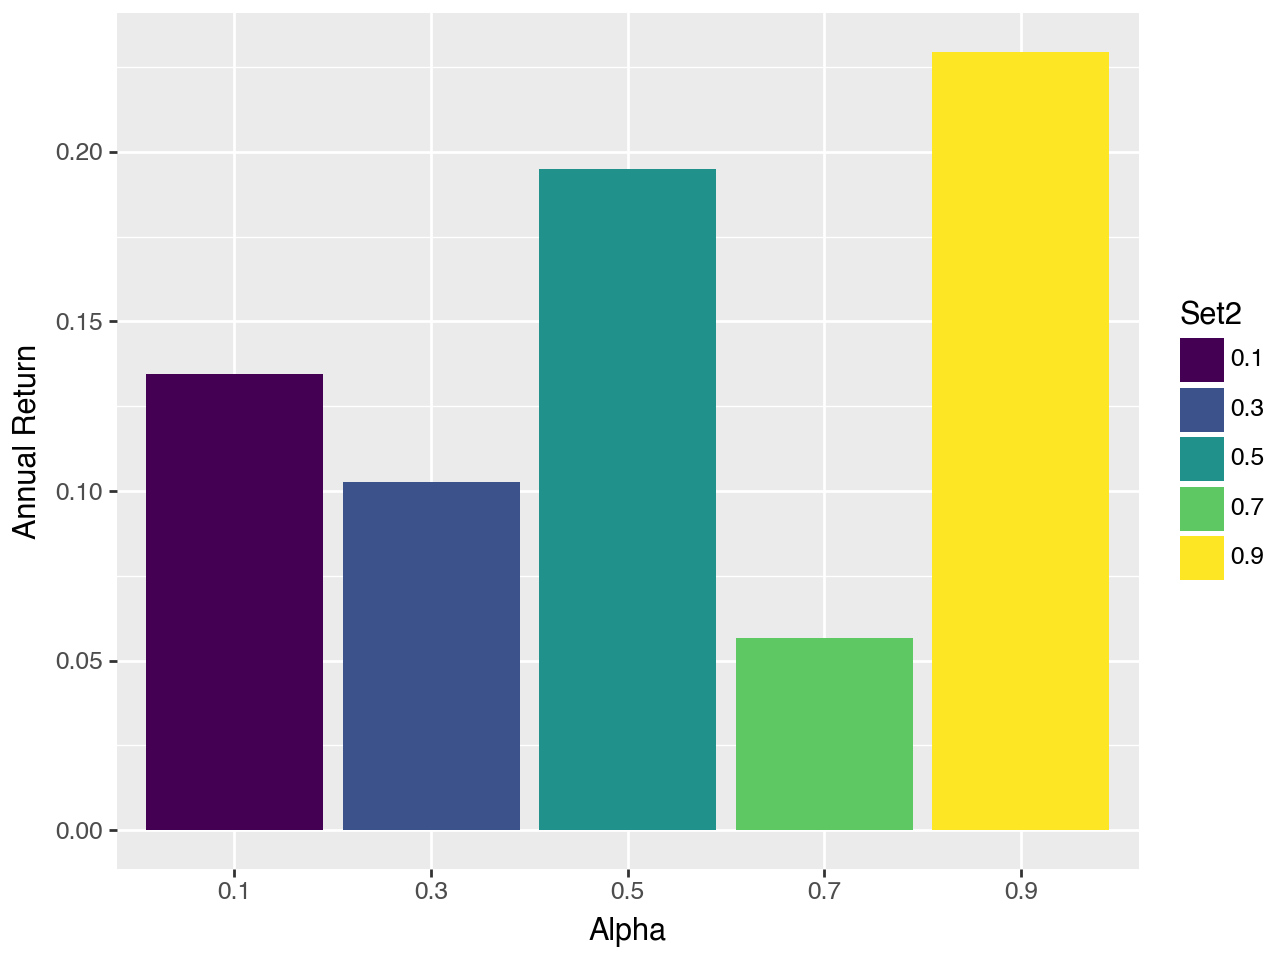

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_CSCO_barplot.pdf


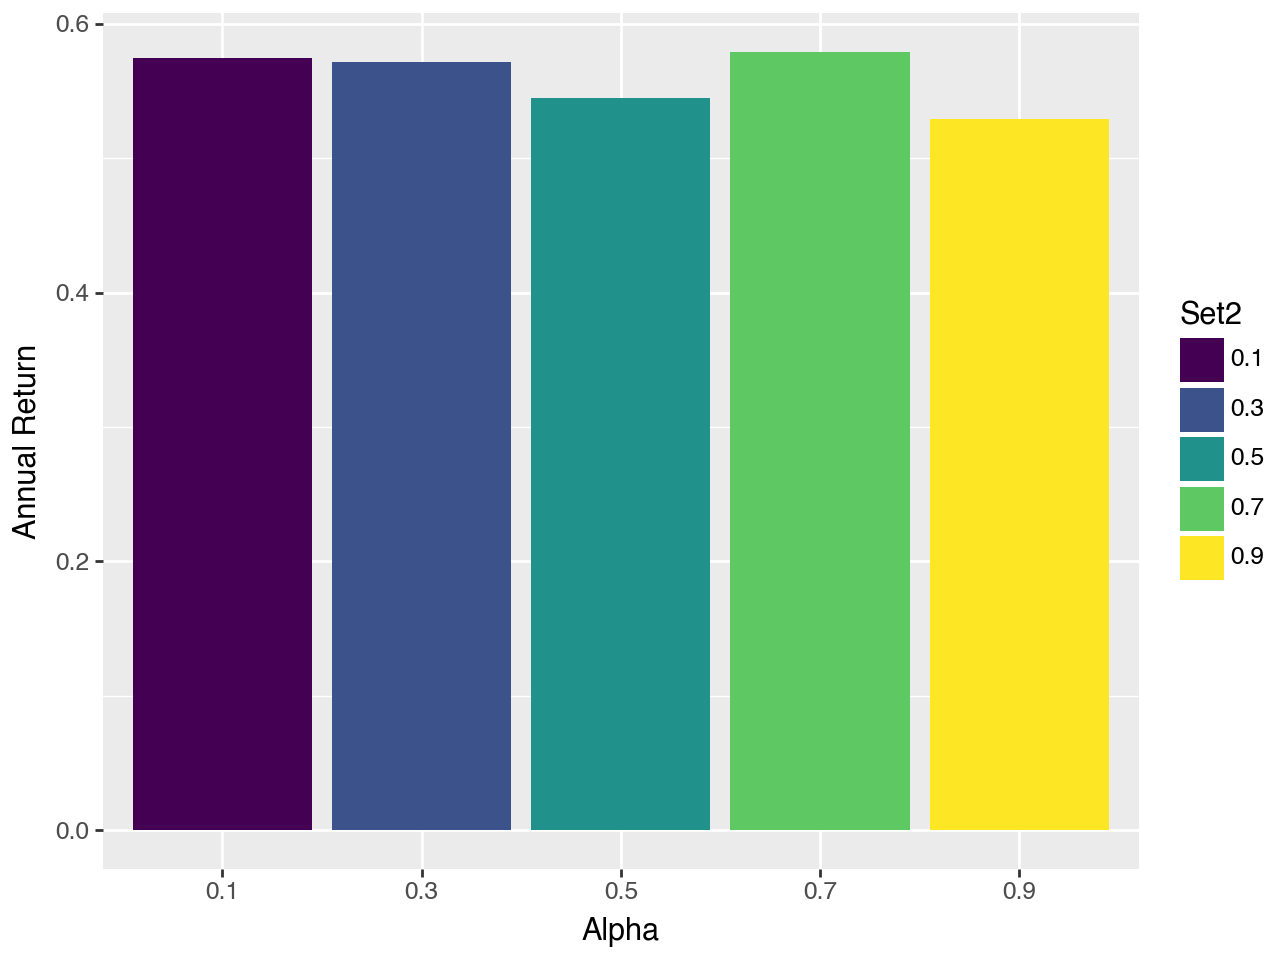

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_CVX_barplot.pdf


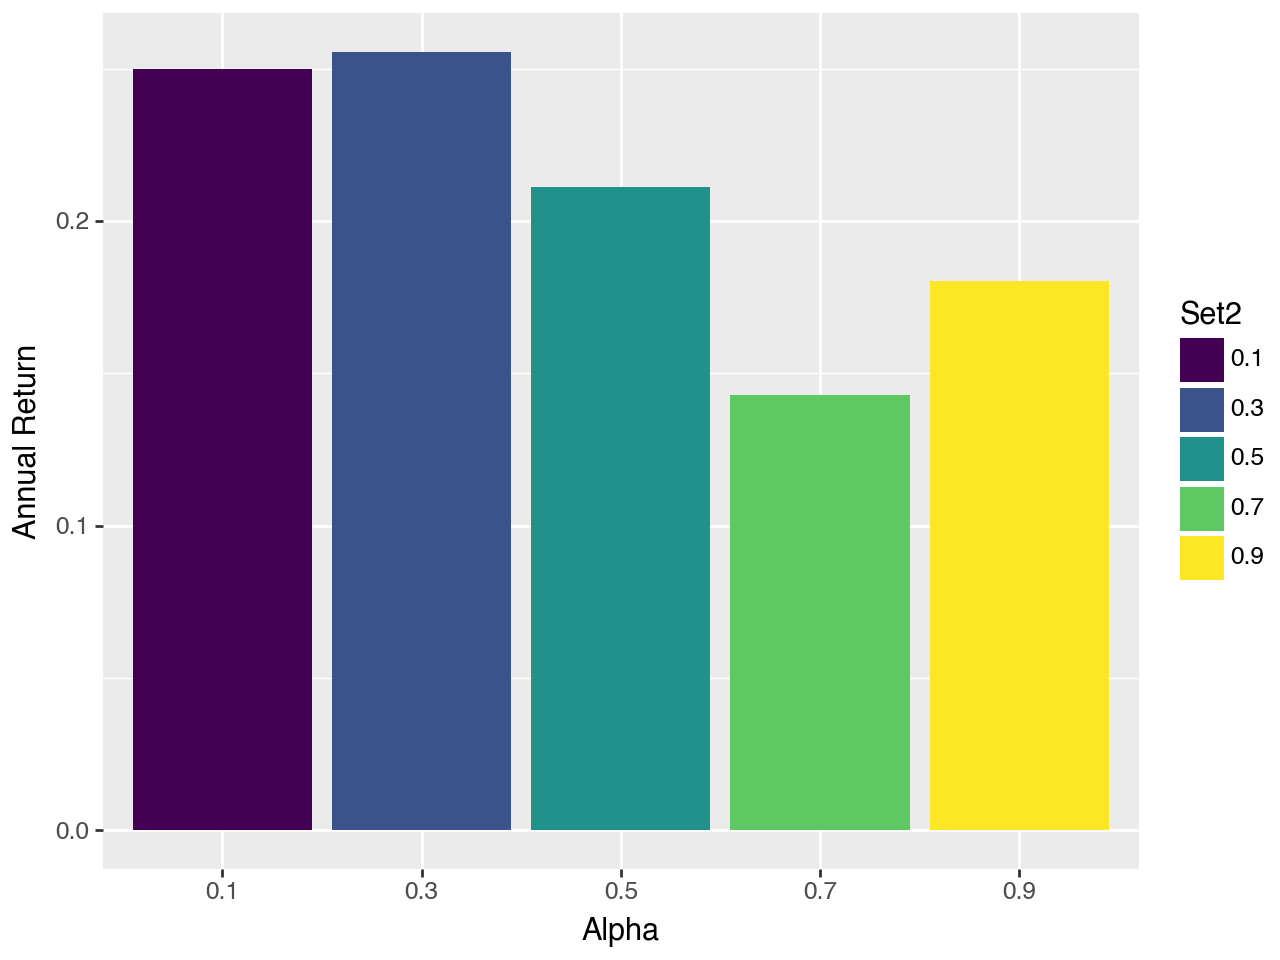

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_DE_barplot.pdf


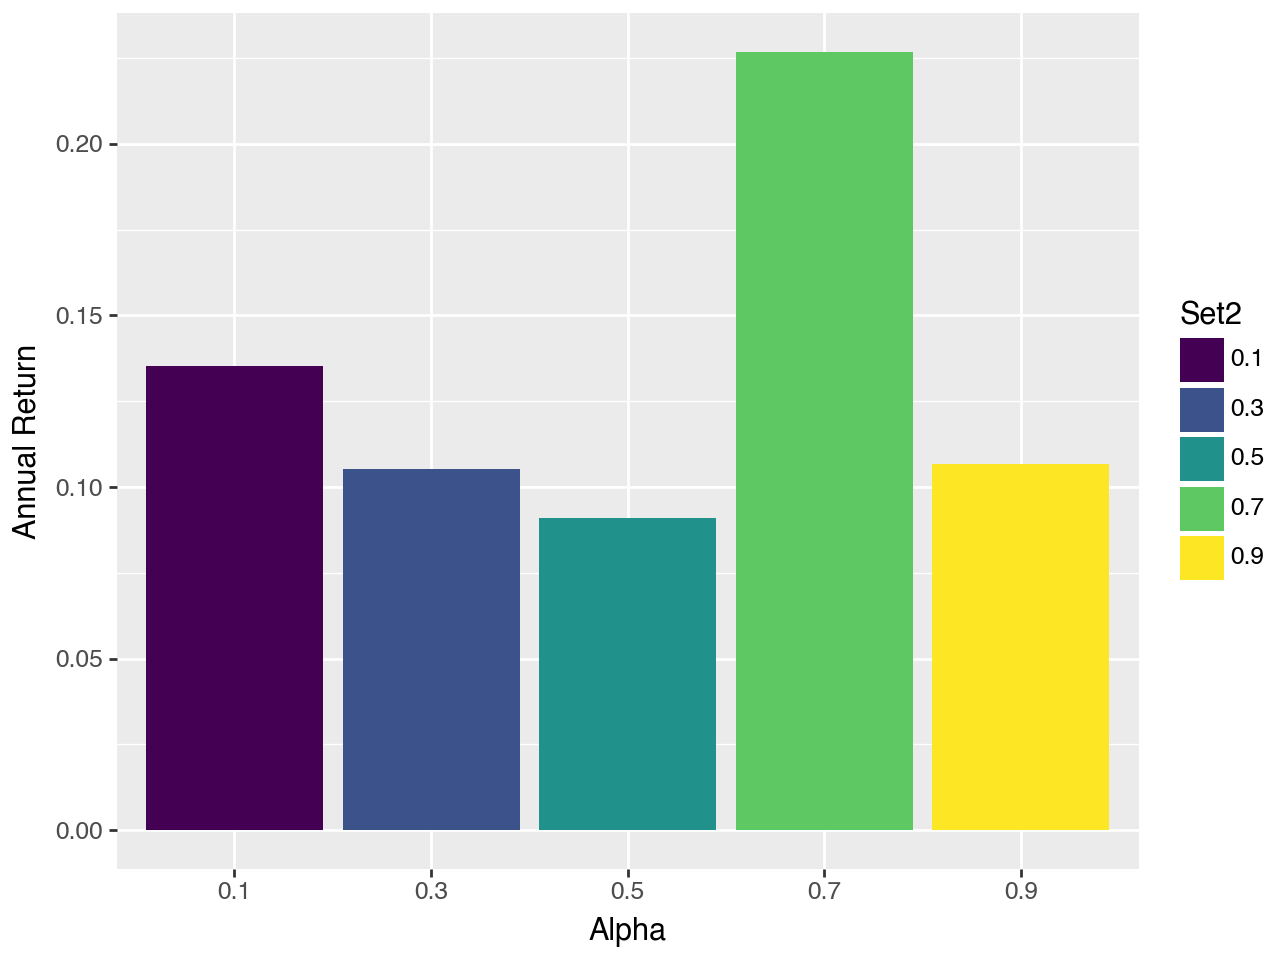

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_DEO_barplot.pdf


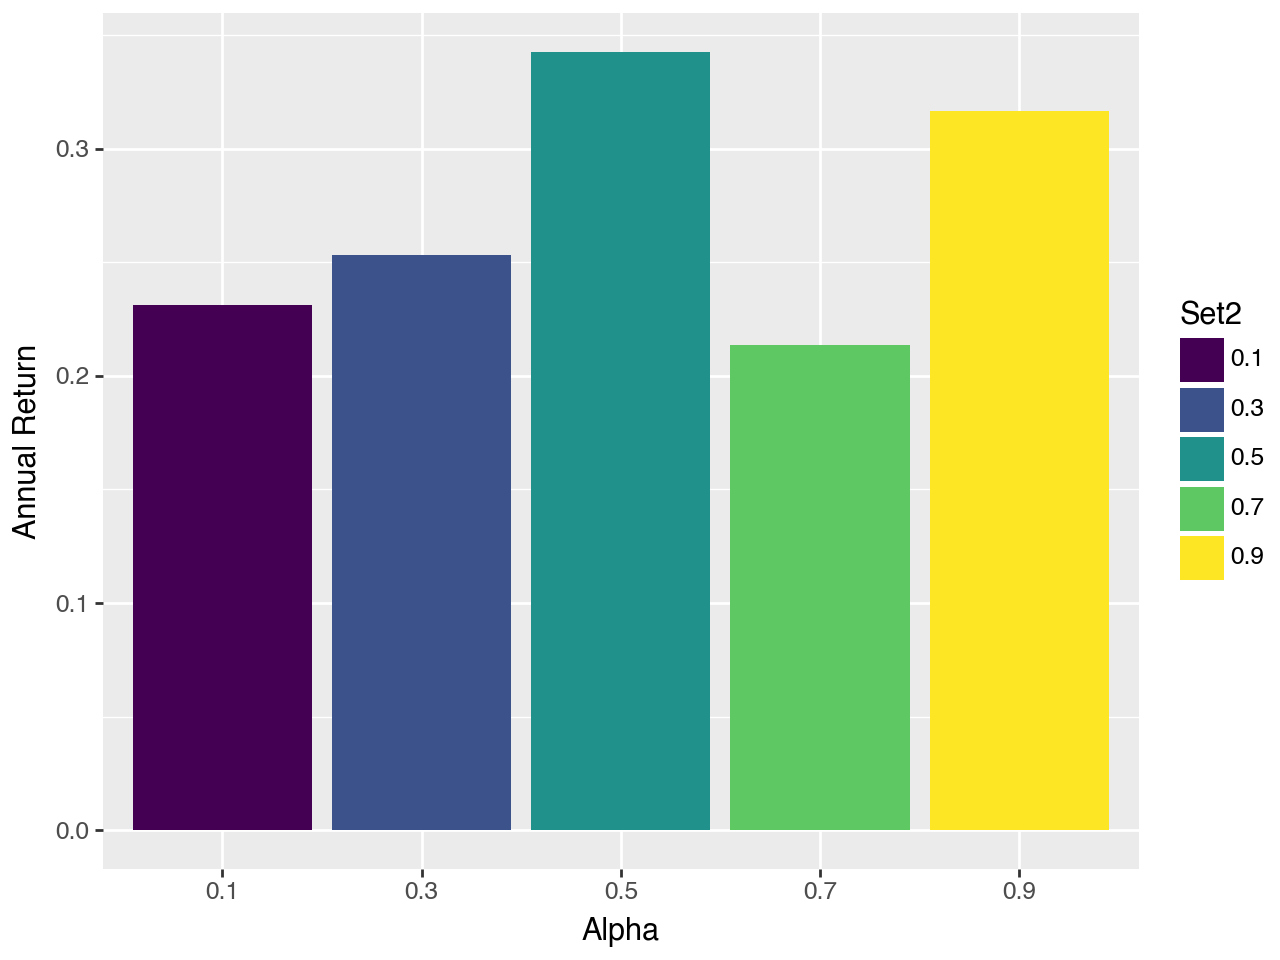

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_DHR_barplot.pdf


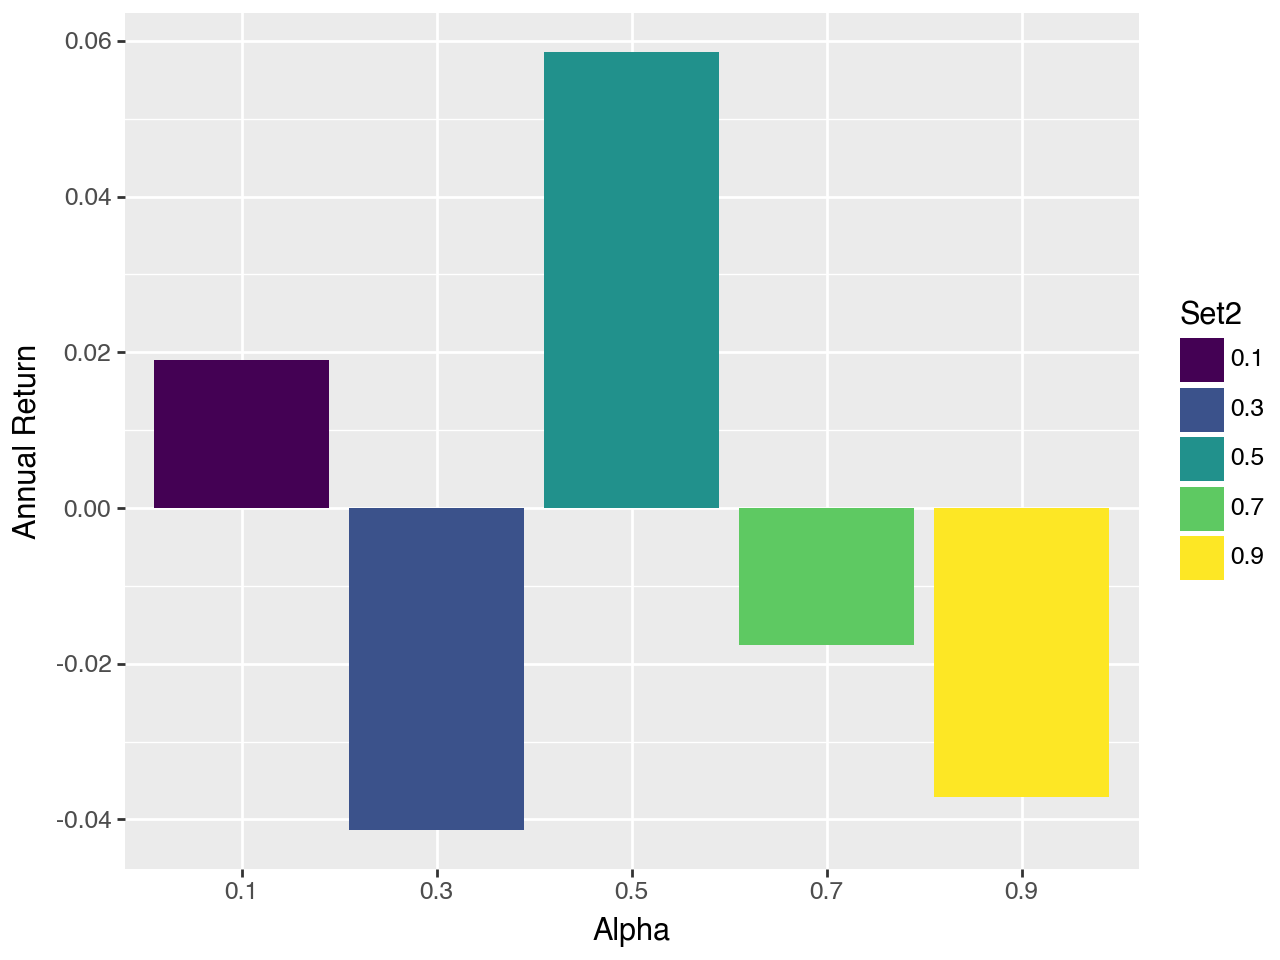

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_DLR_barplot.pdf


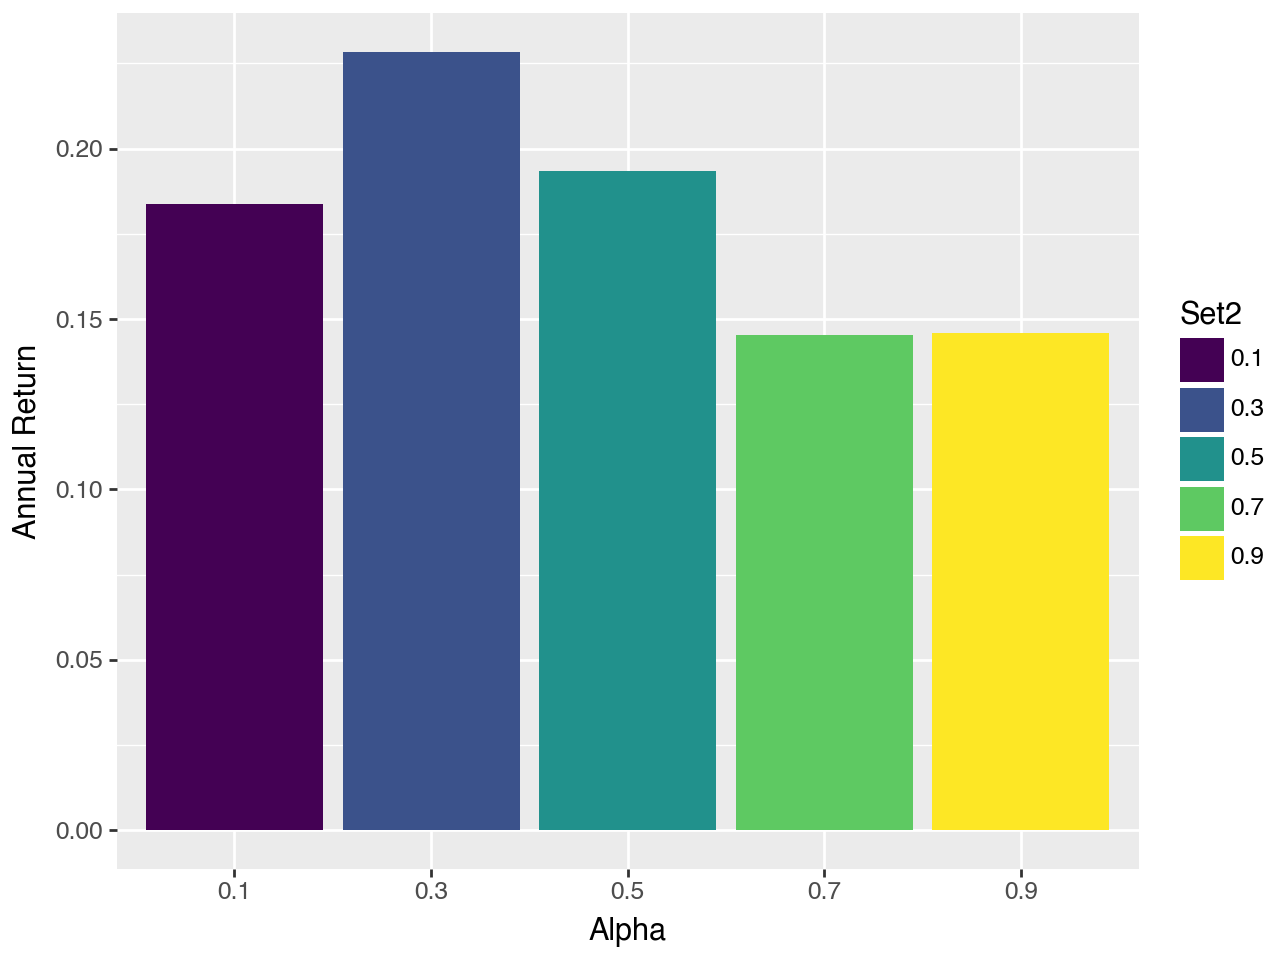

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_DUK_barplot.pdf


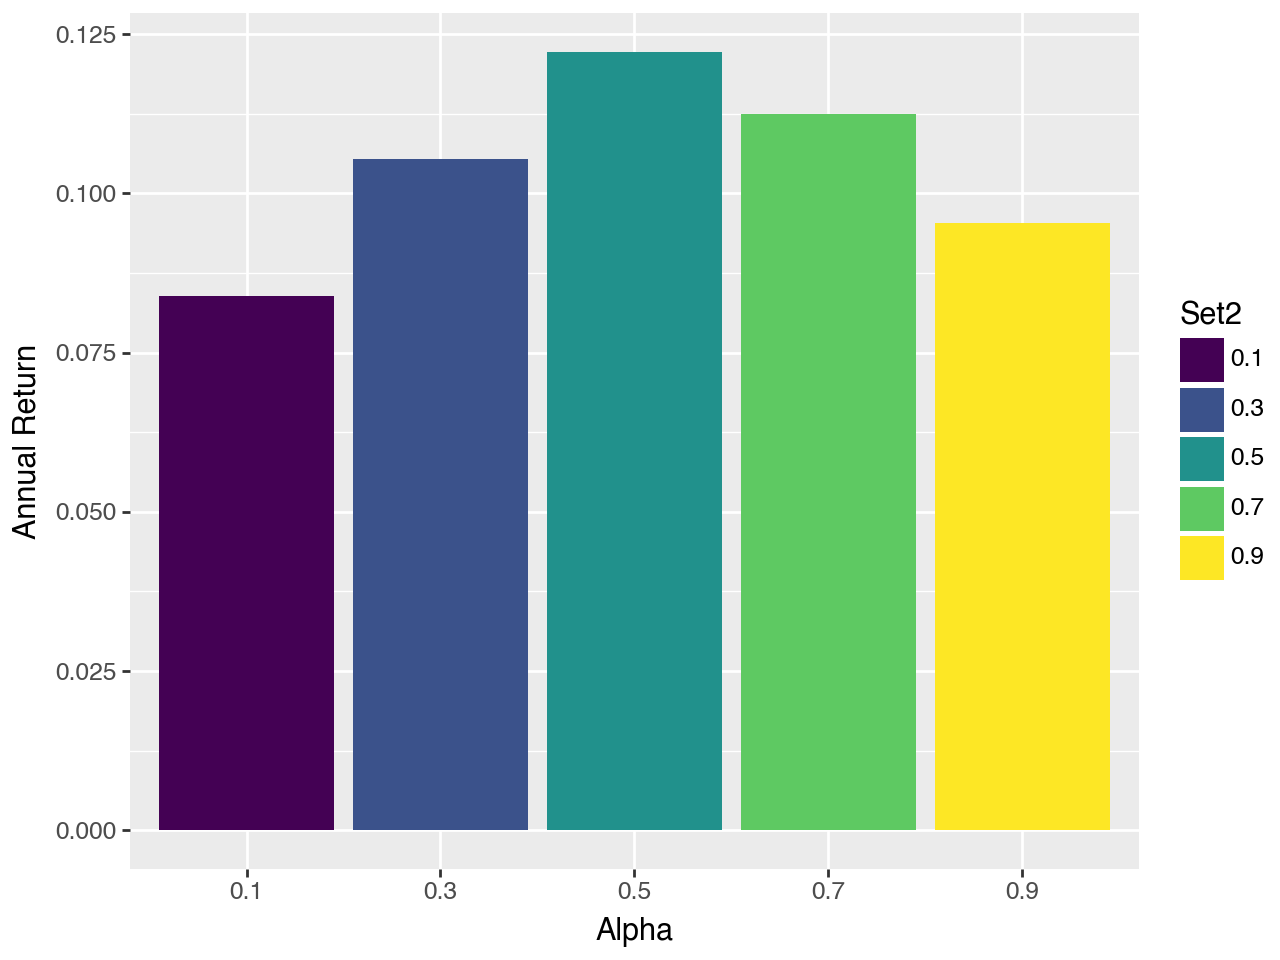

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_ECL_barplot.pdf


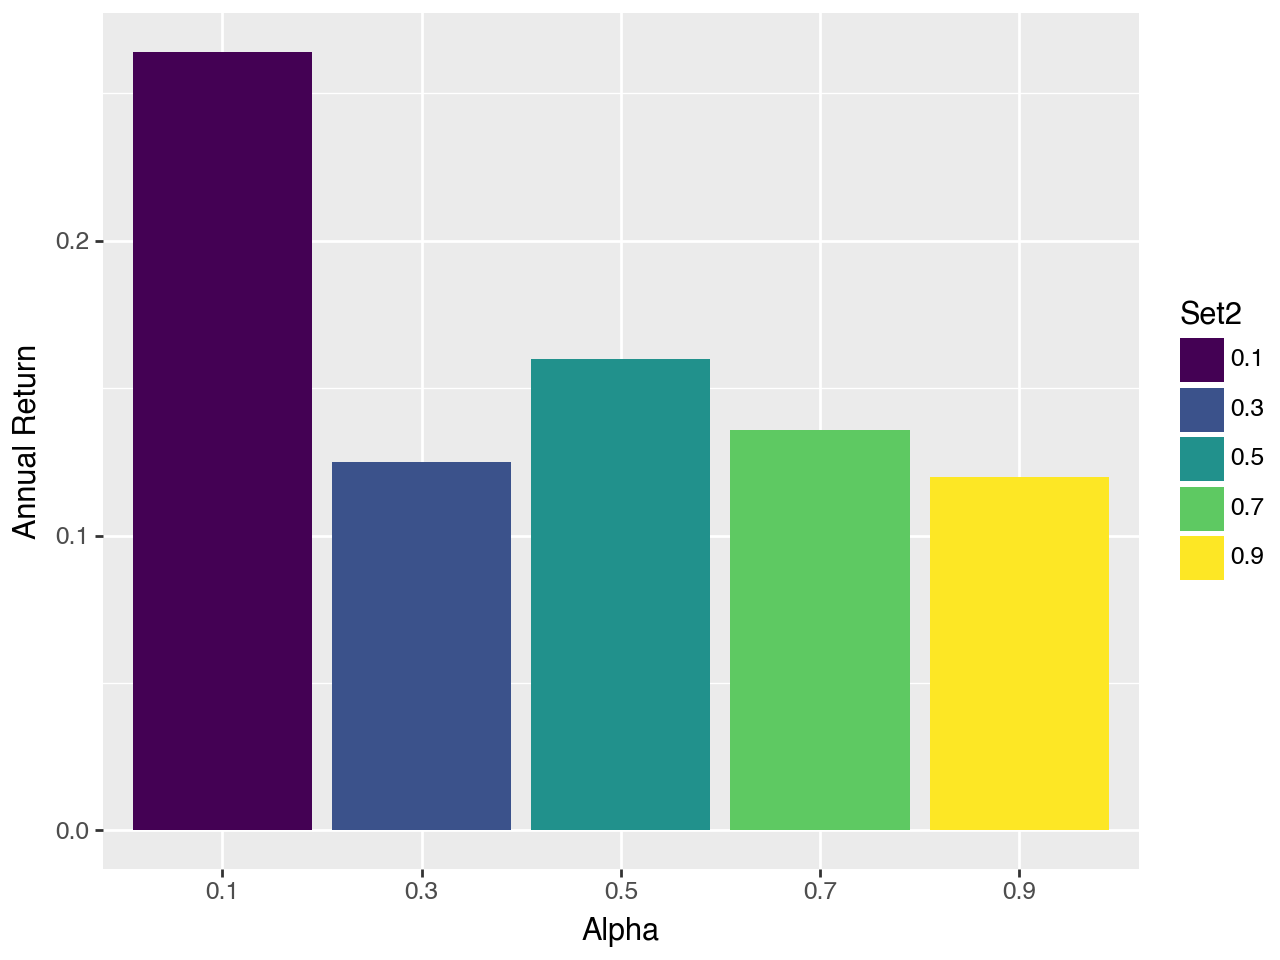

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_EL_barplot.pdf


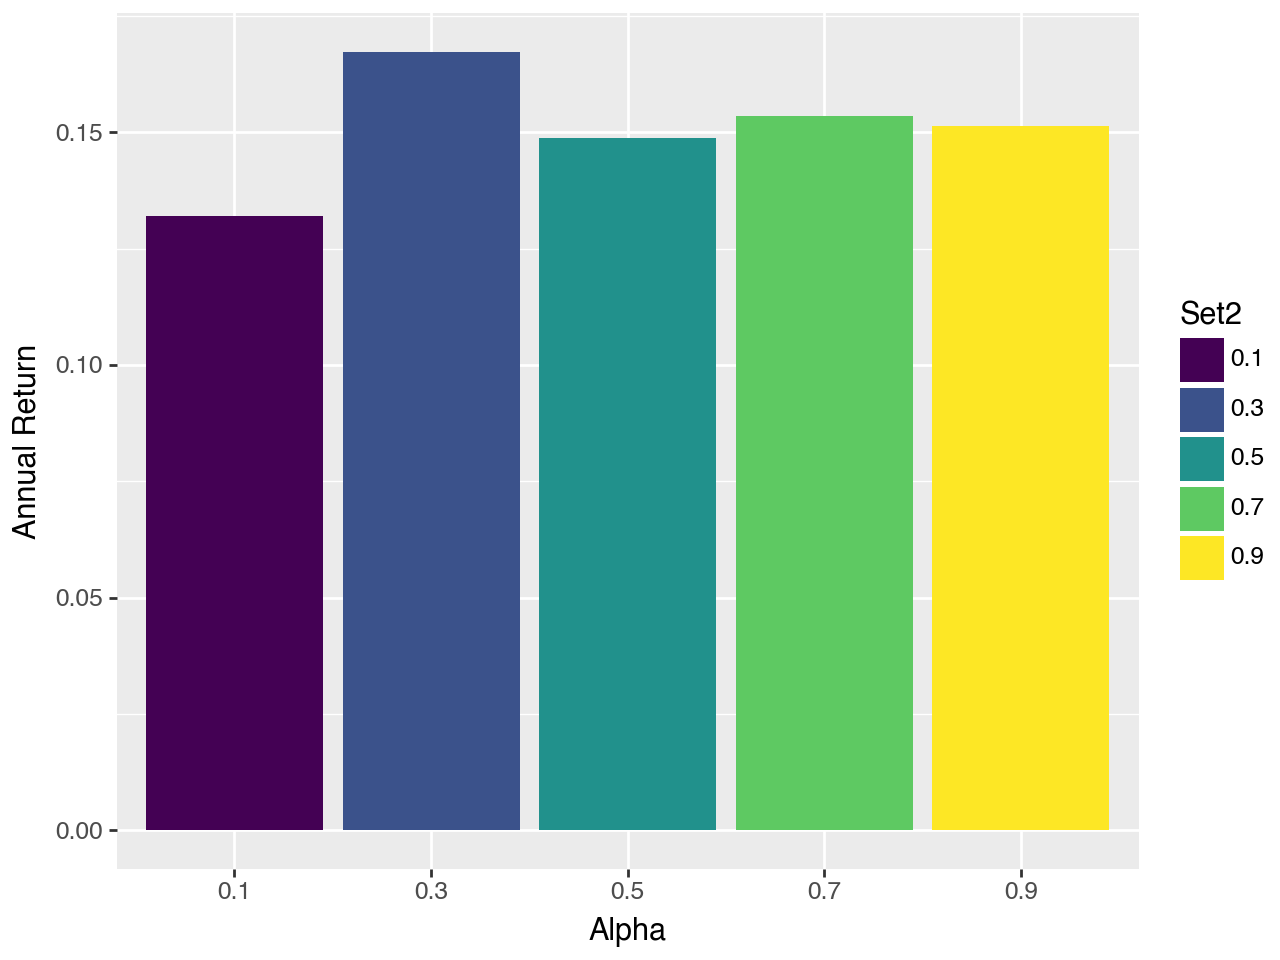

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_EQIX_barplot.pdf


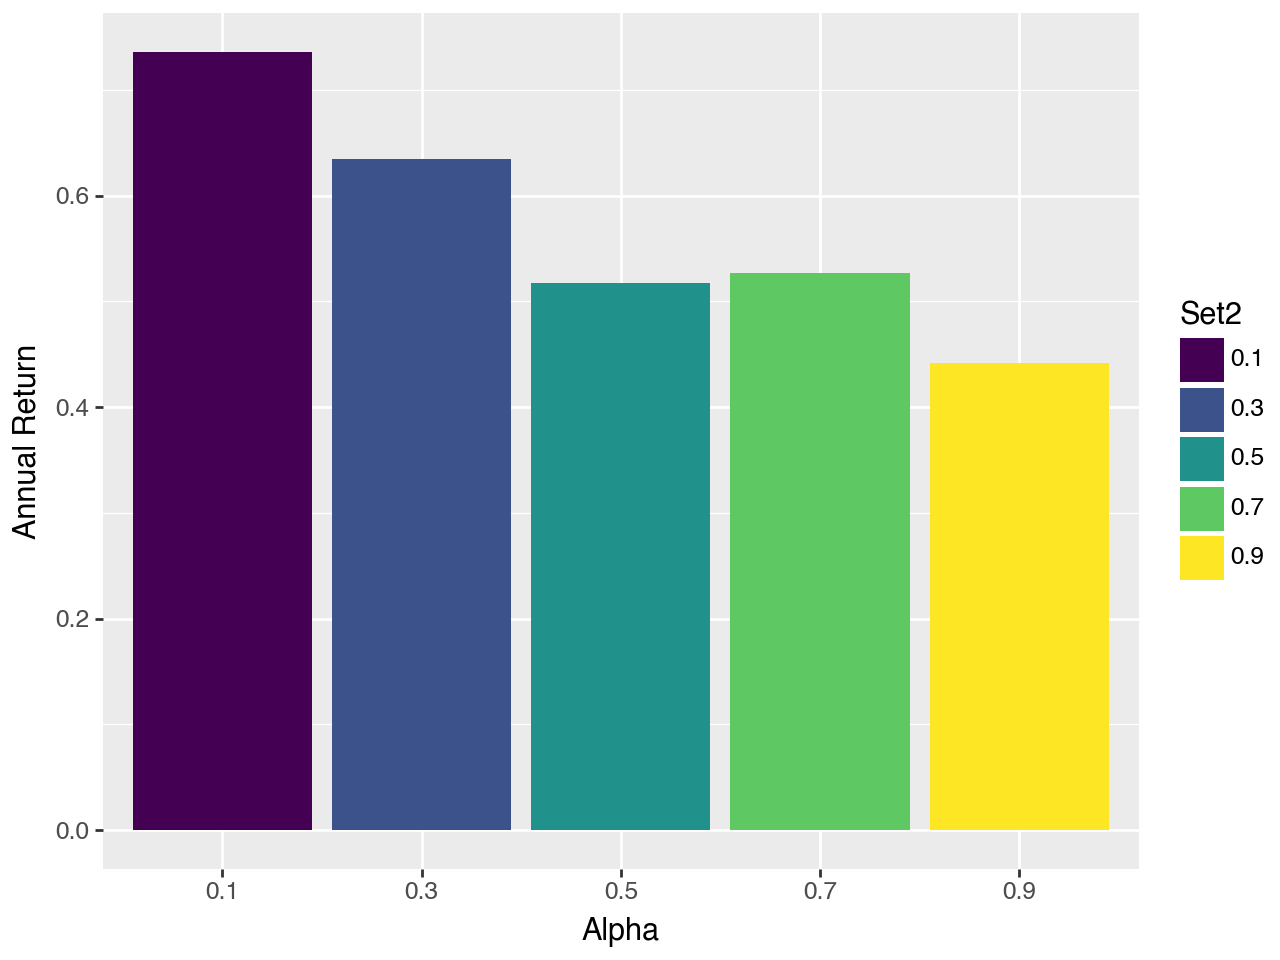

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_EQNR_barplot.pdf


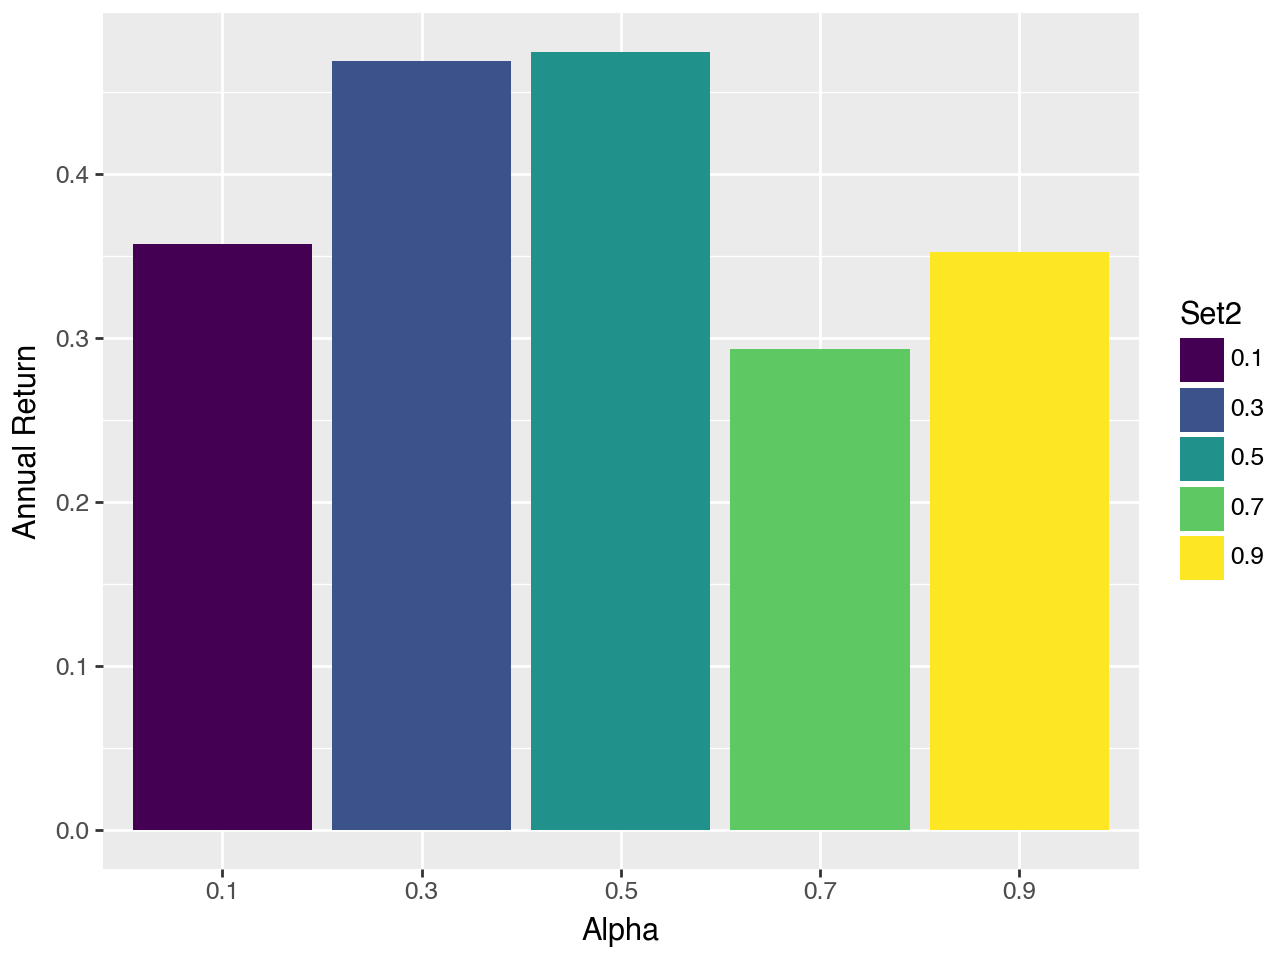

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_FCX_barplot.pdf


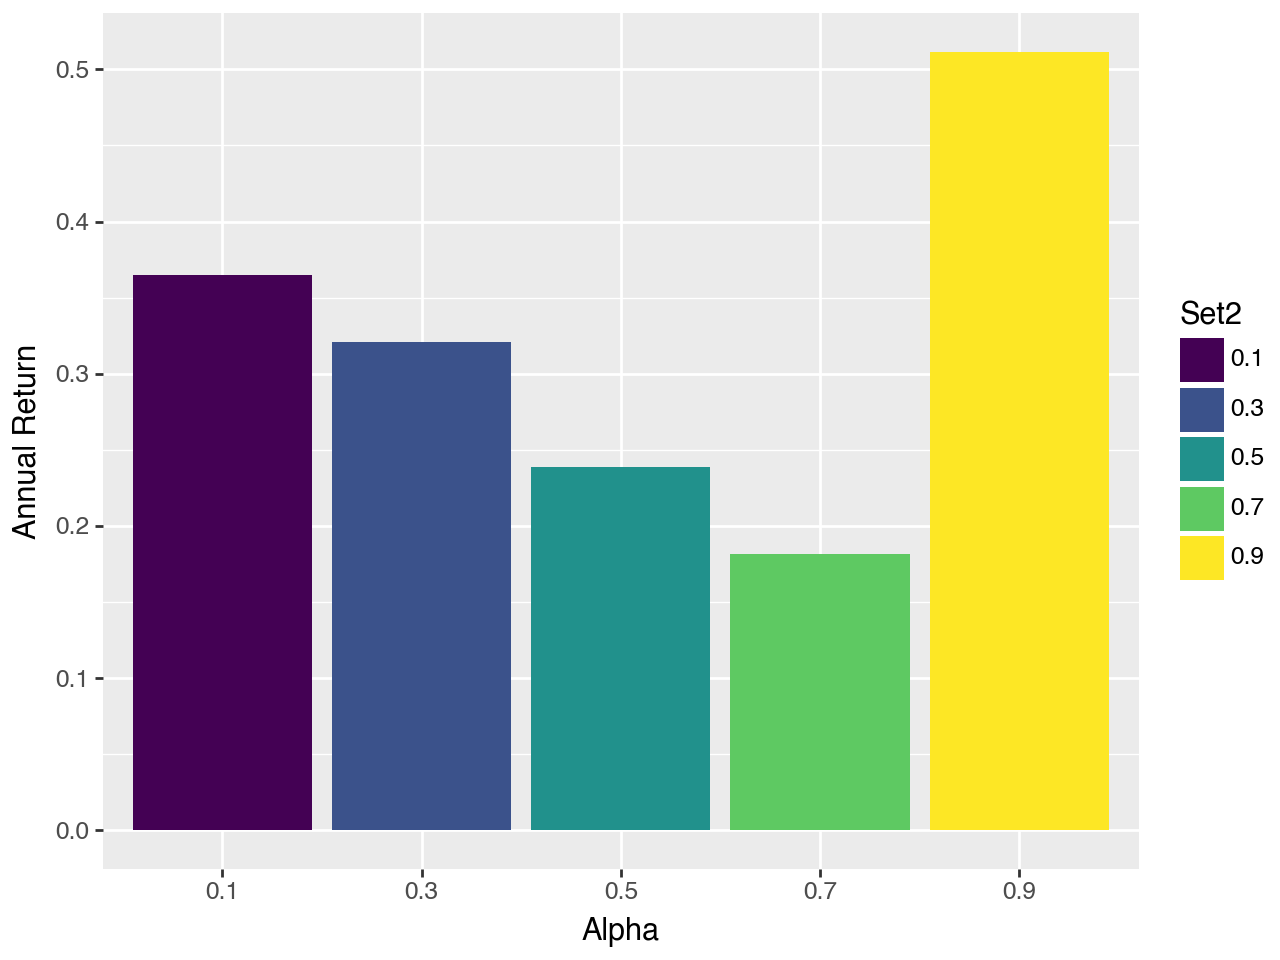

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_GE_barplot.pdf


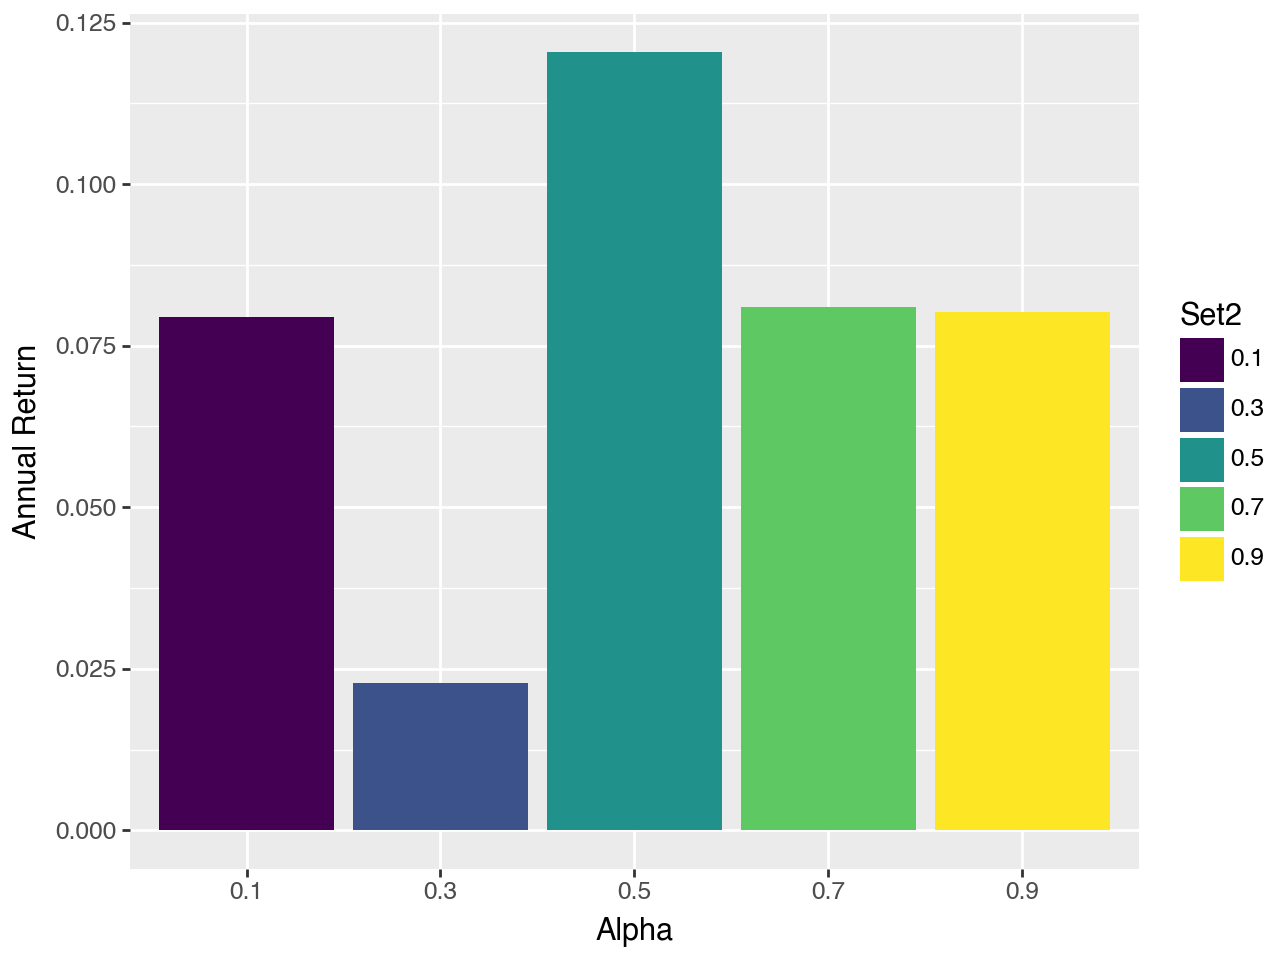

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_GOOG_barplot.pdf


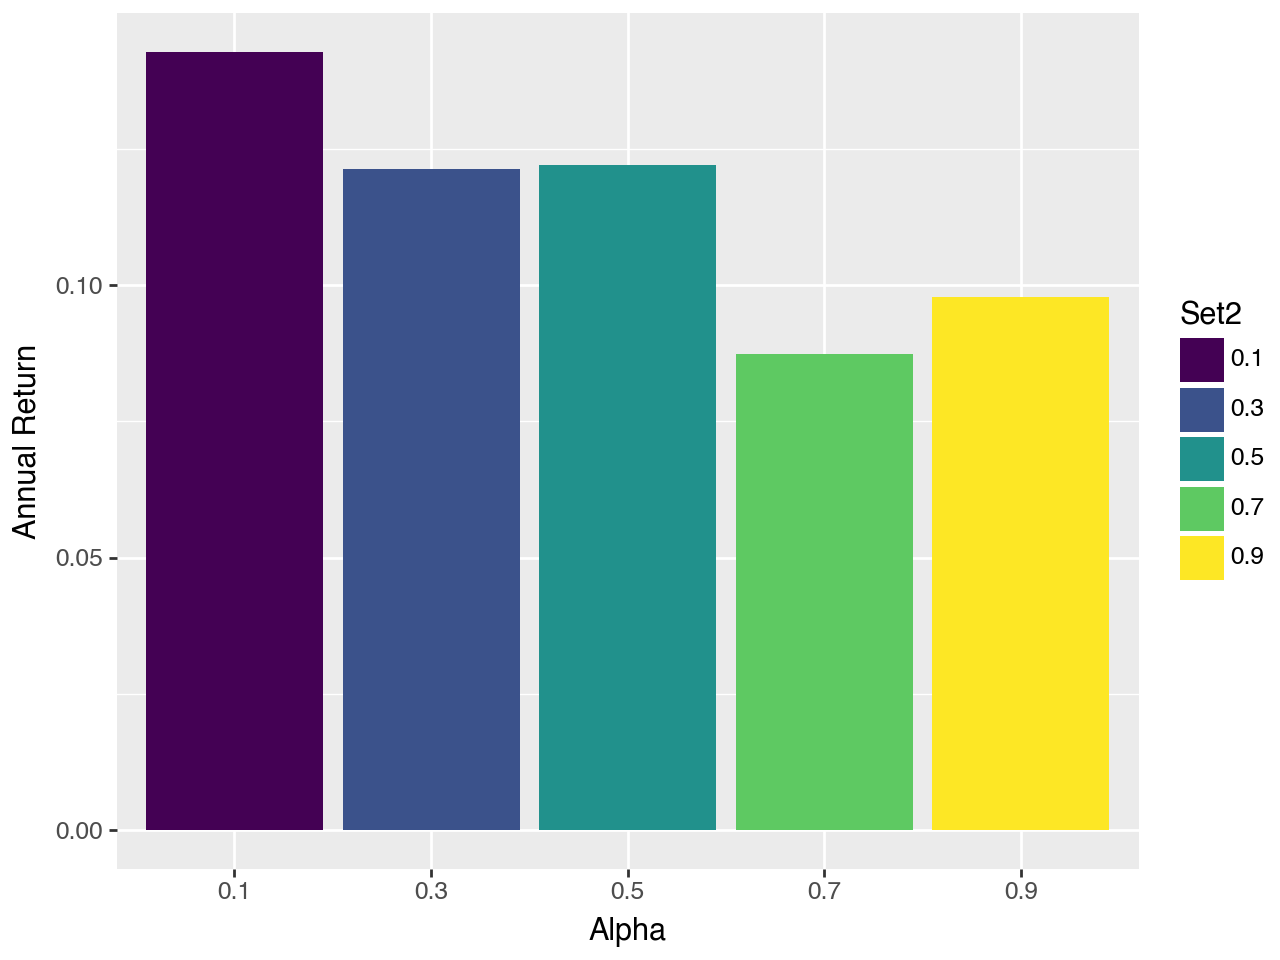

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Annual Return/Alpha_O_barplot.pdf


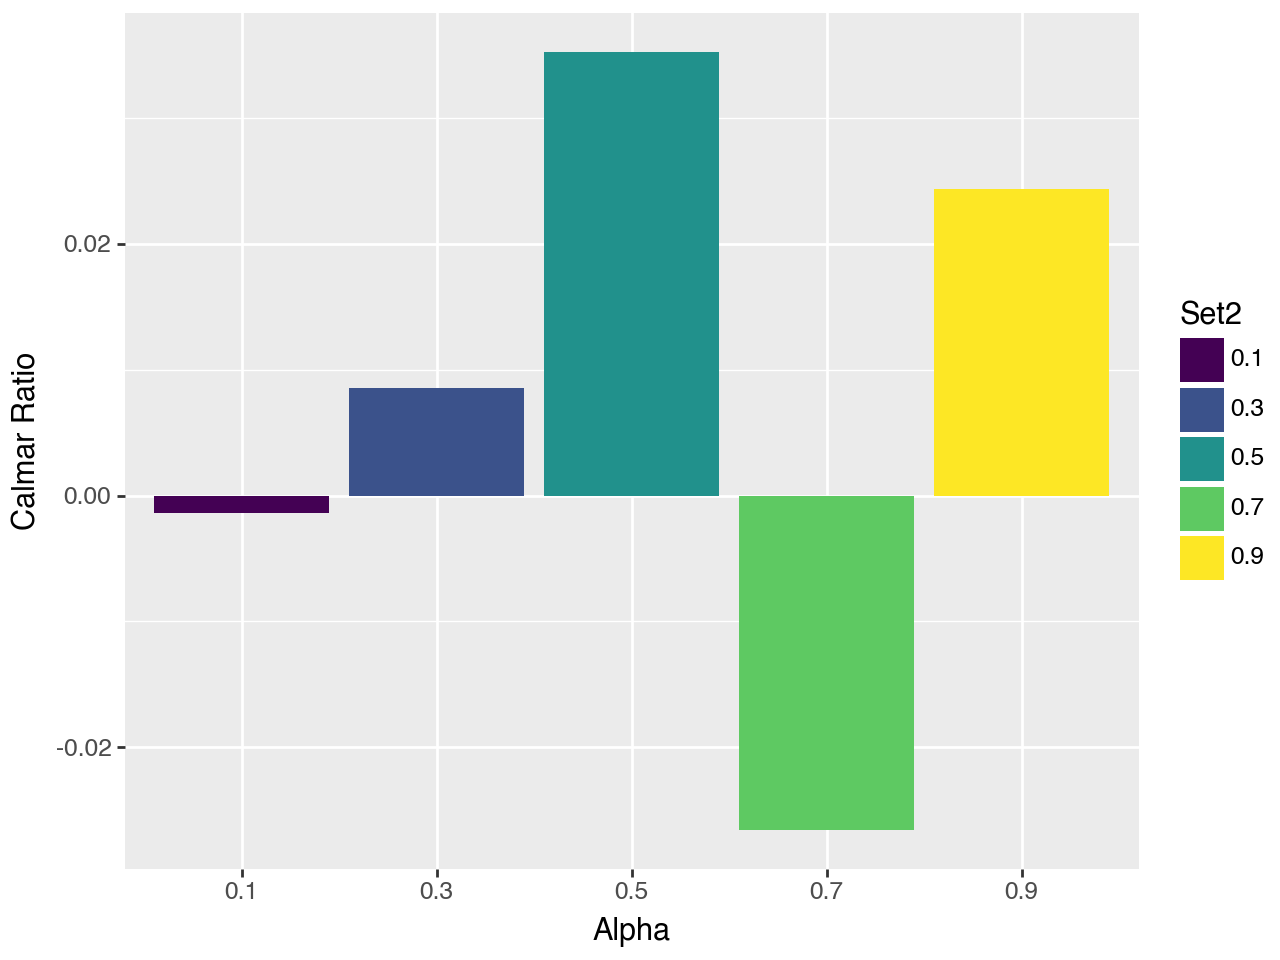

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_AAPL_barplot.pdf


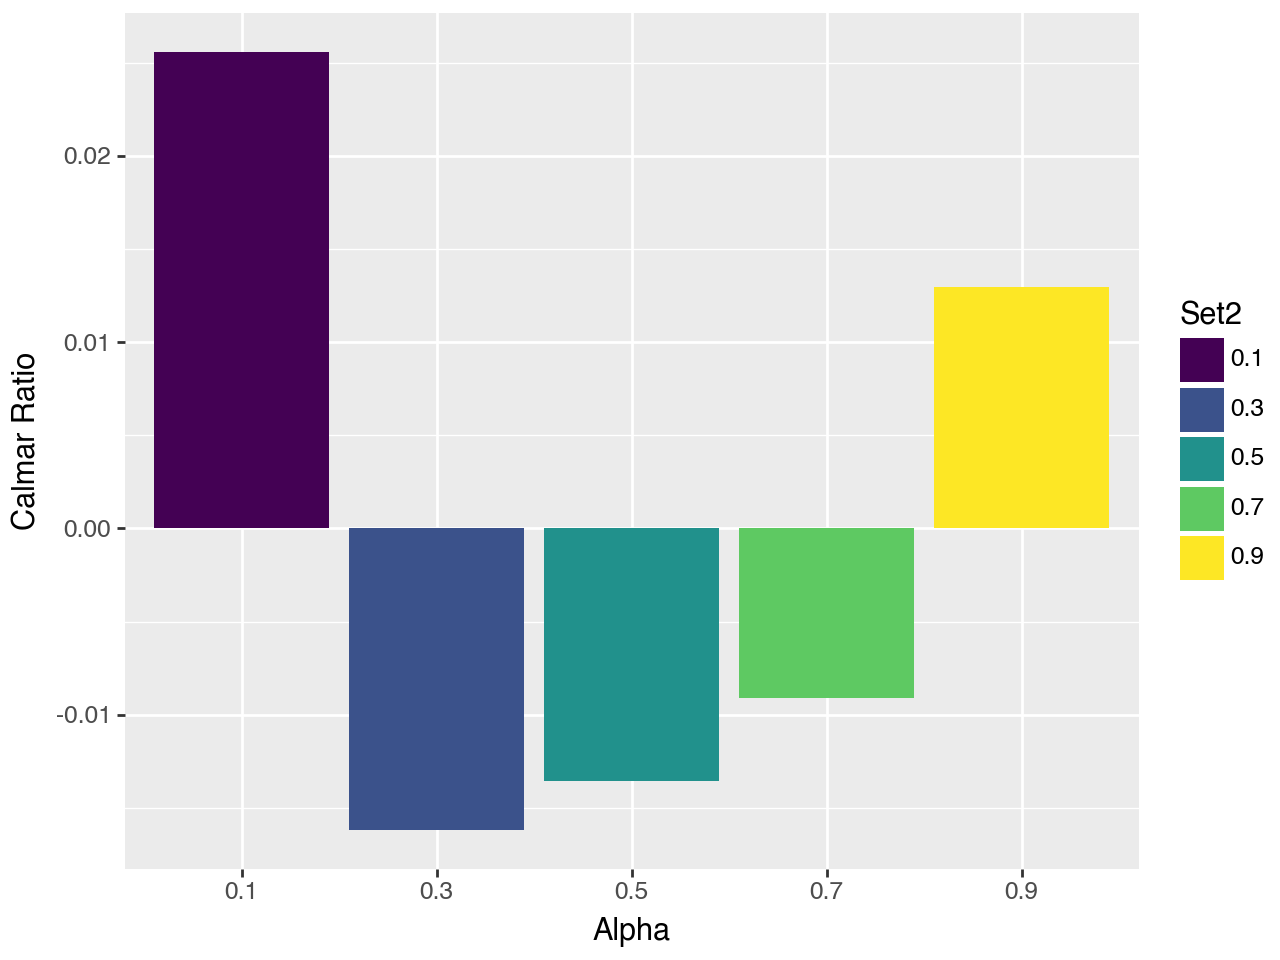

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_ABBV_barplot.pdf


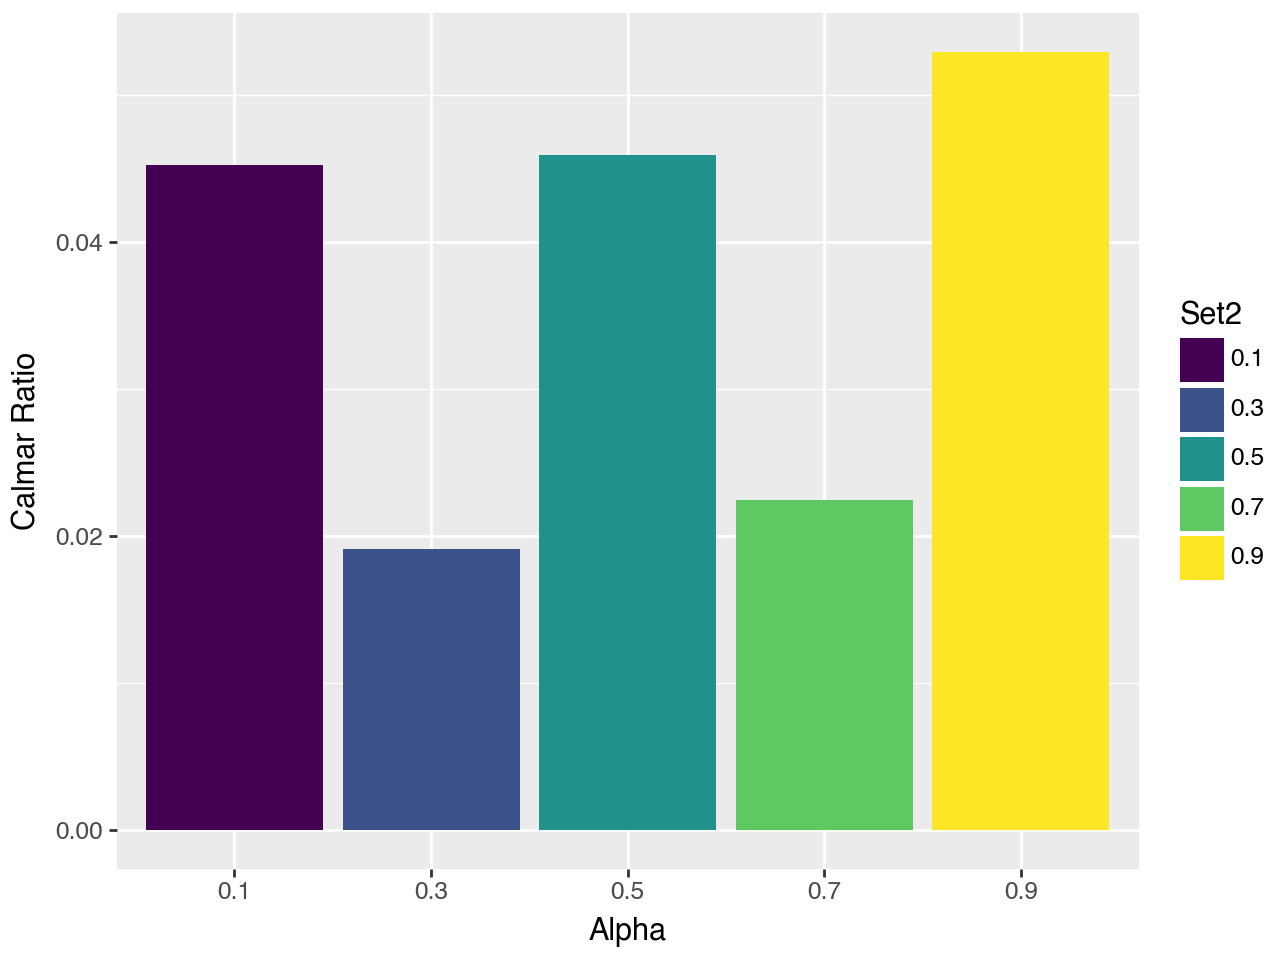

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_ACN_barplot.pdf


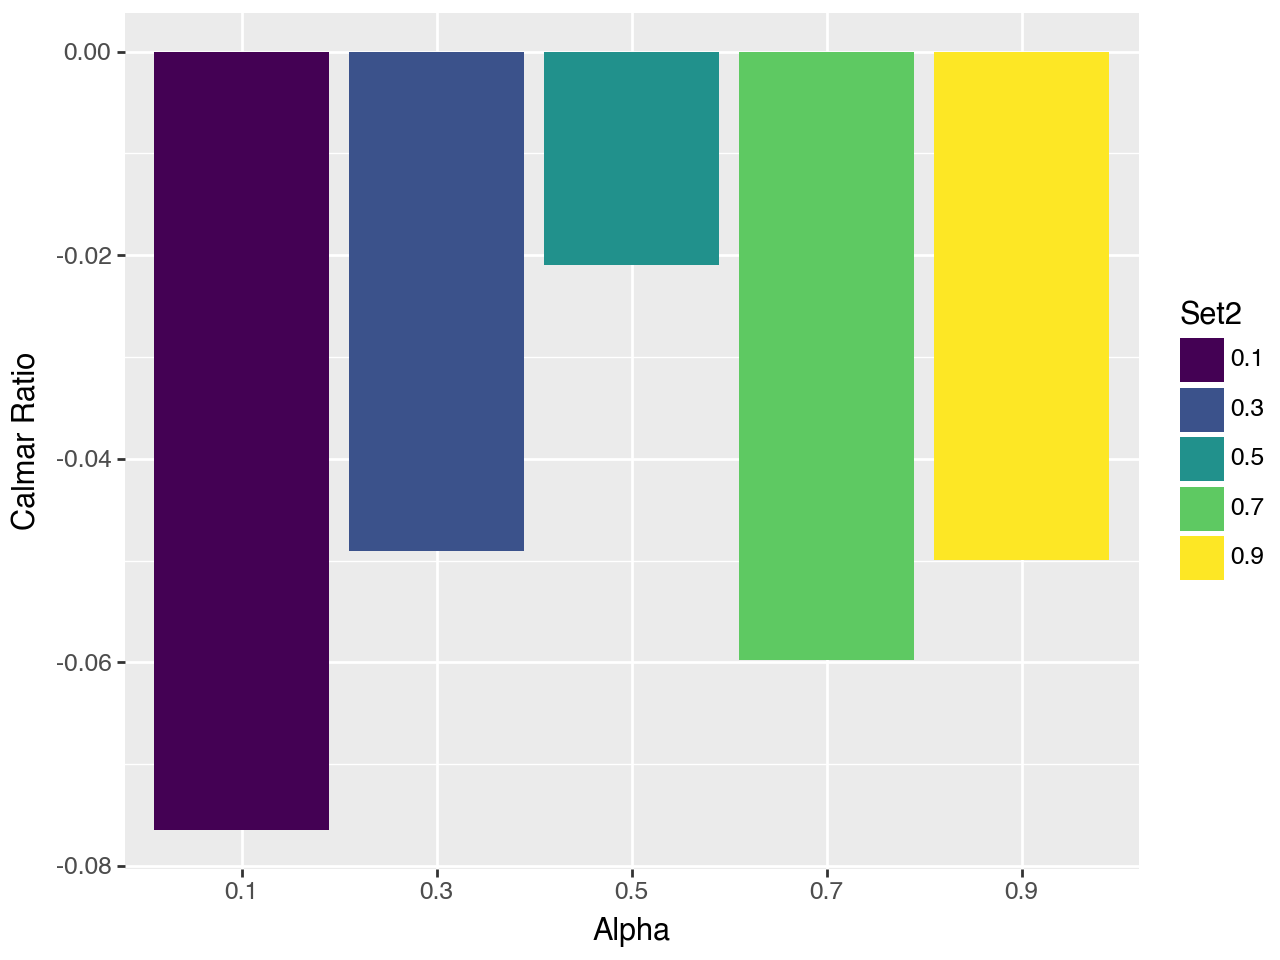

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_ADBE_barplot.pdf


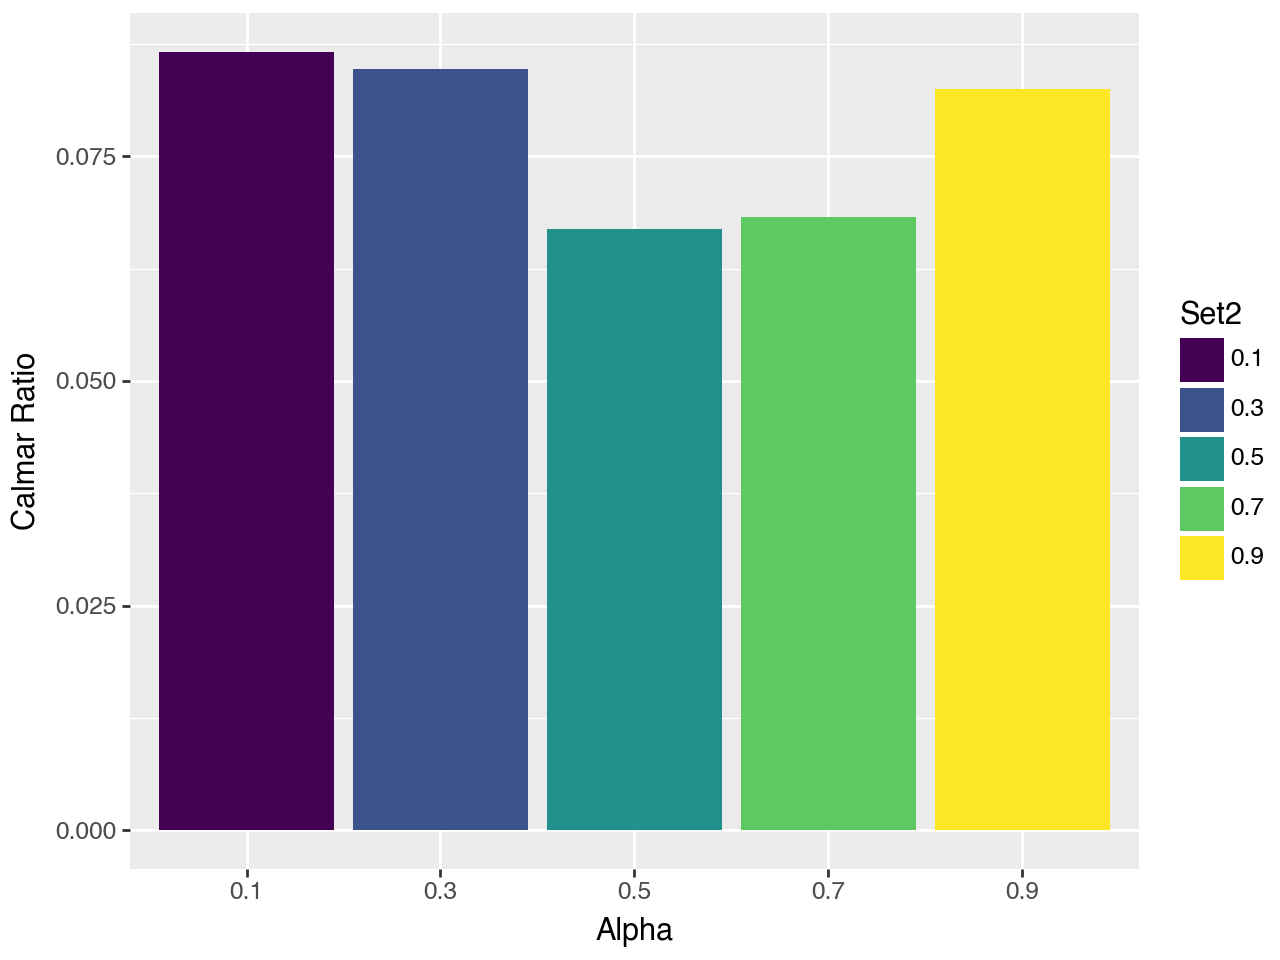

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_ADP_barplot.pdf


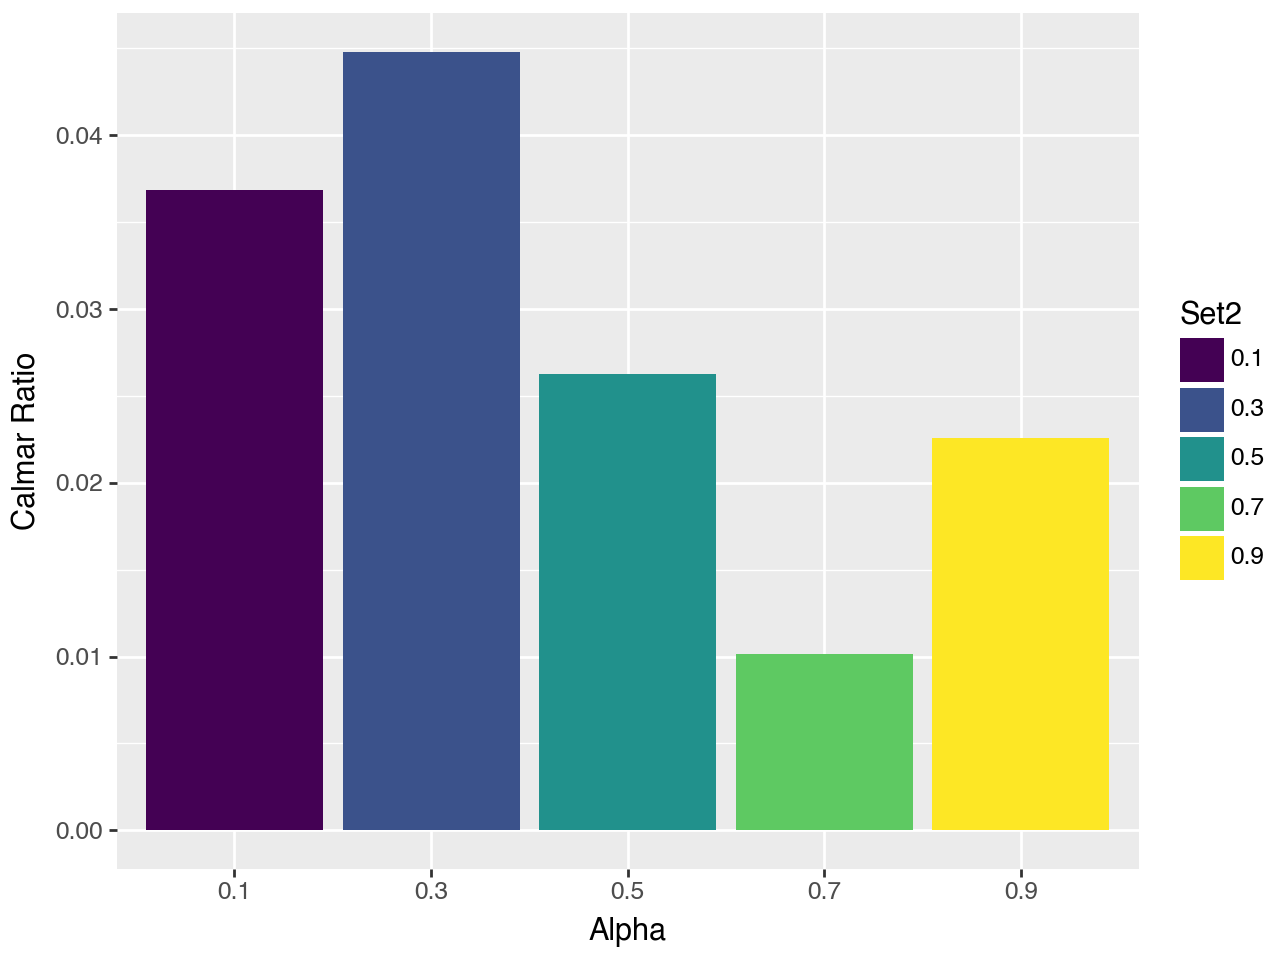

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_AMT_barplot.pdf


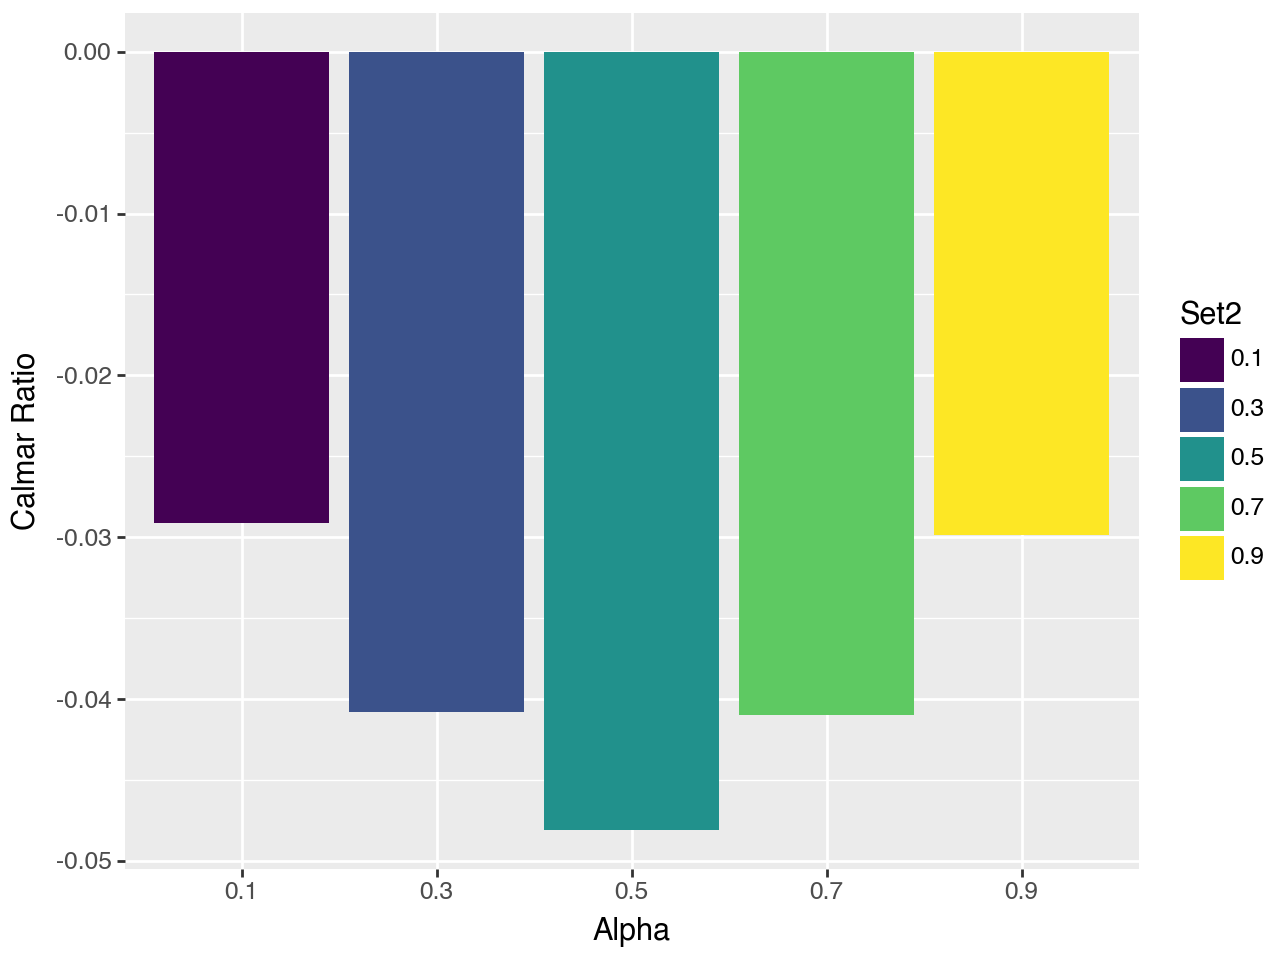

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_APD_barplot.pdf


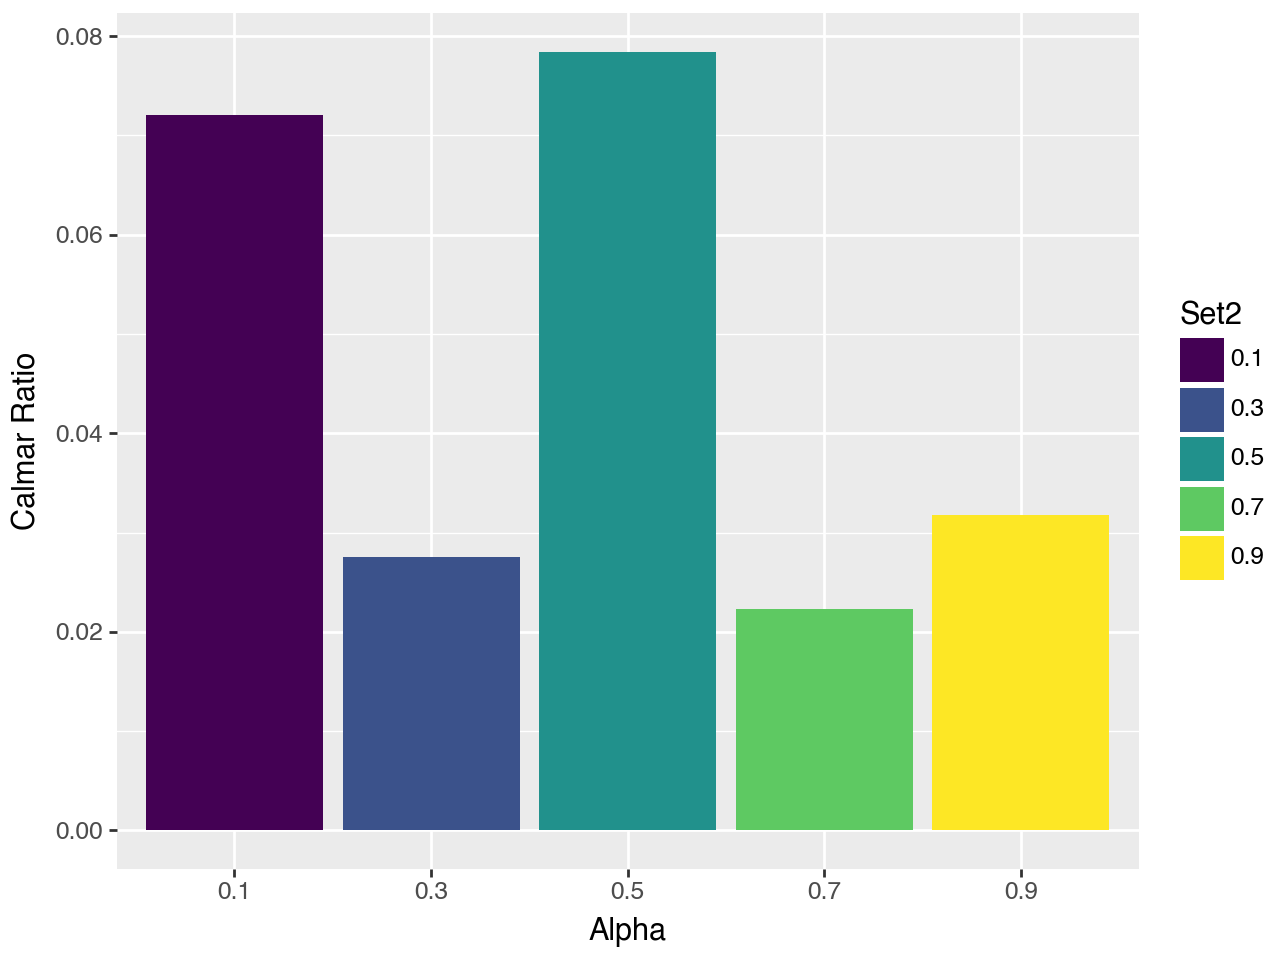

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_AVGO_barplot.pdf


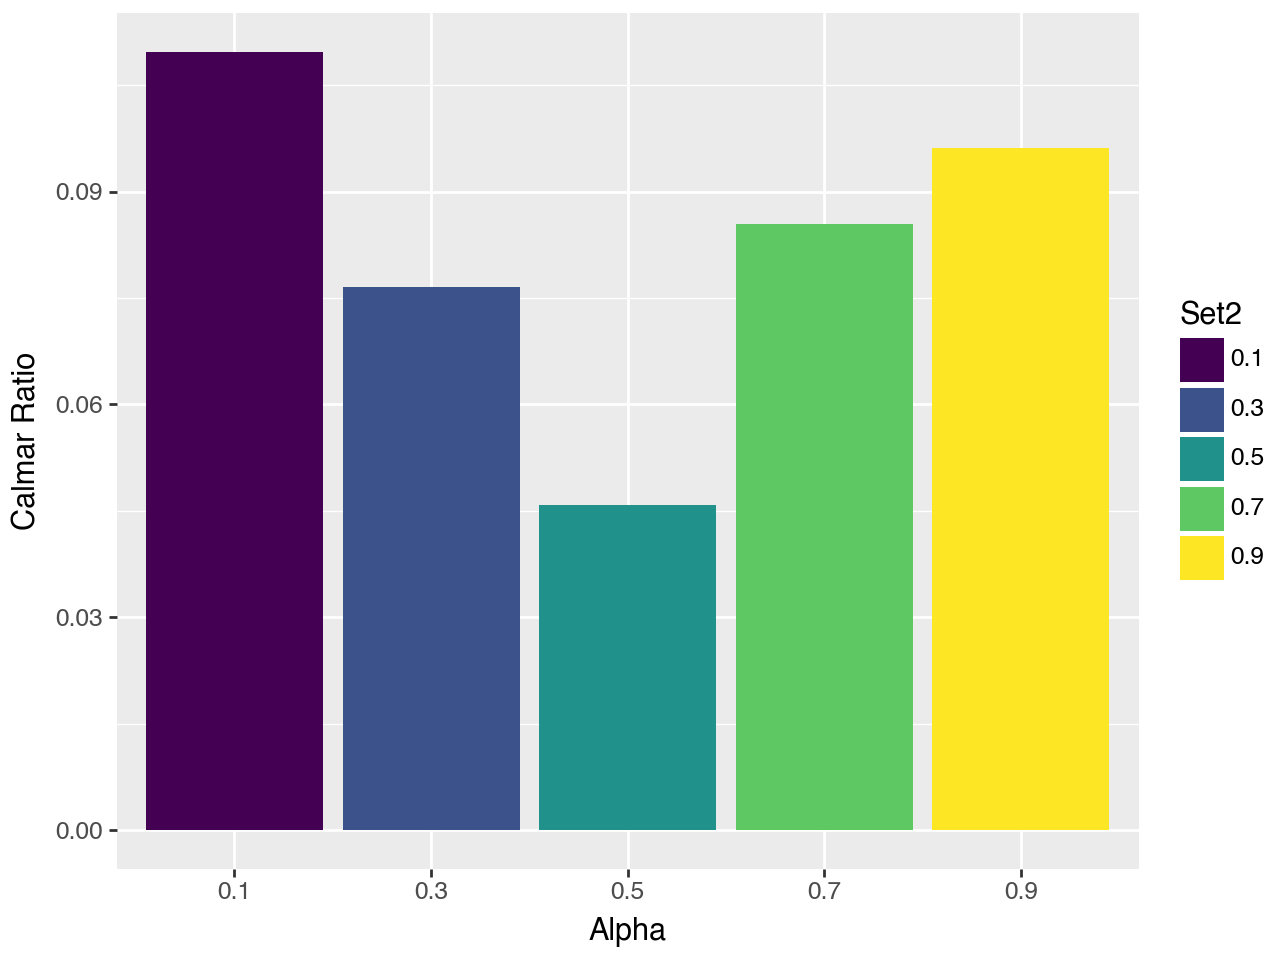

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_AWK_barplot.pdf


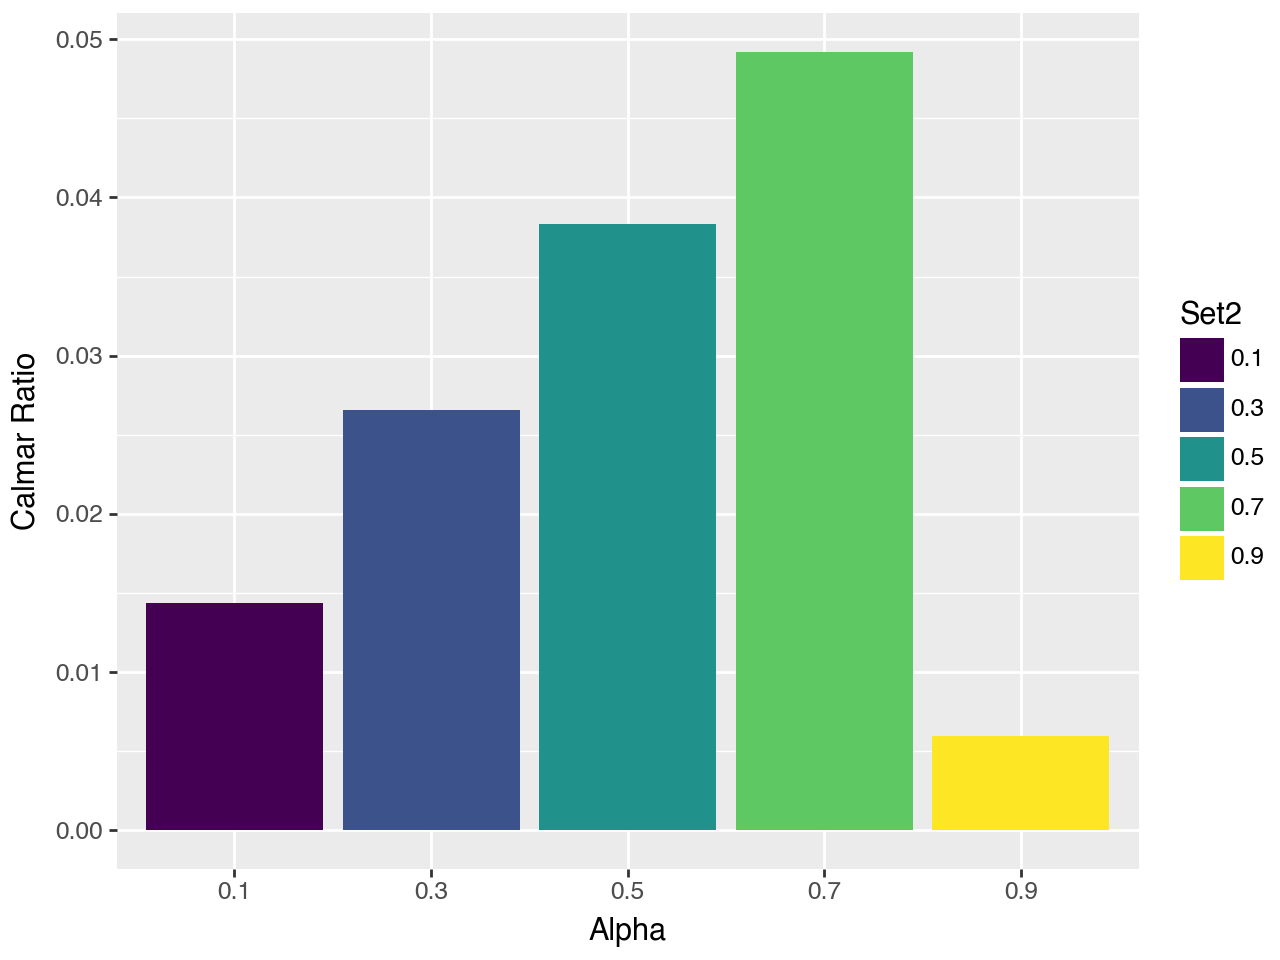

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_BA_barplot.pdf


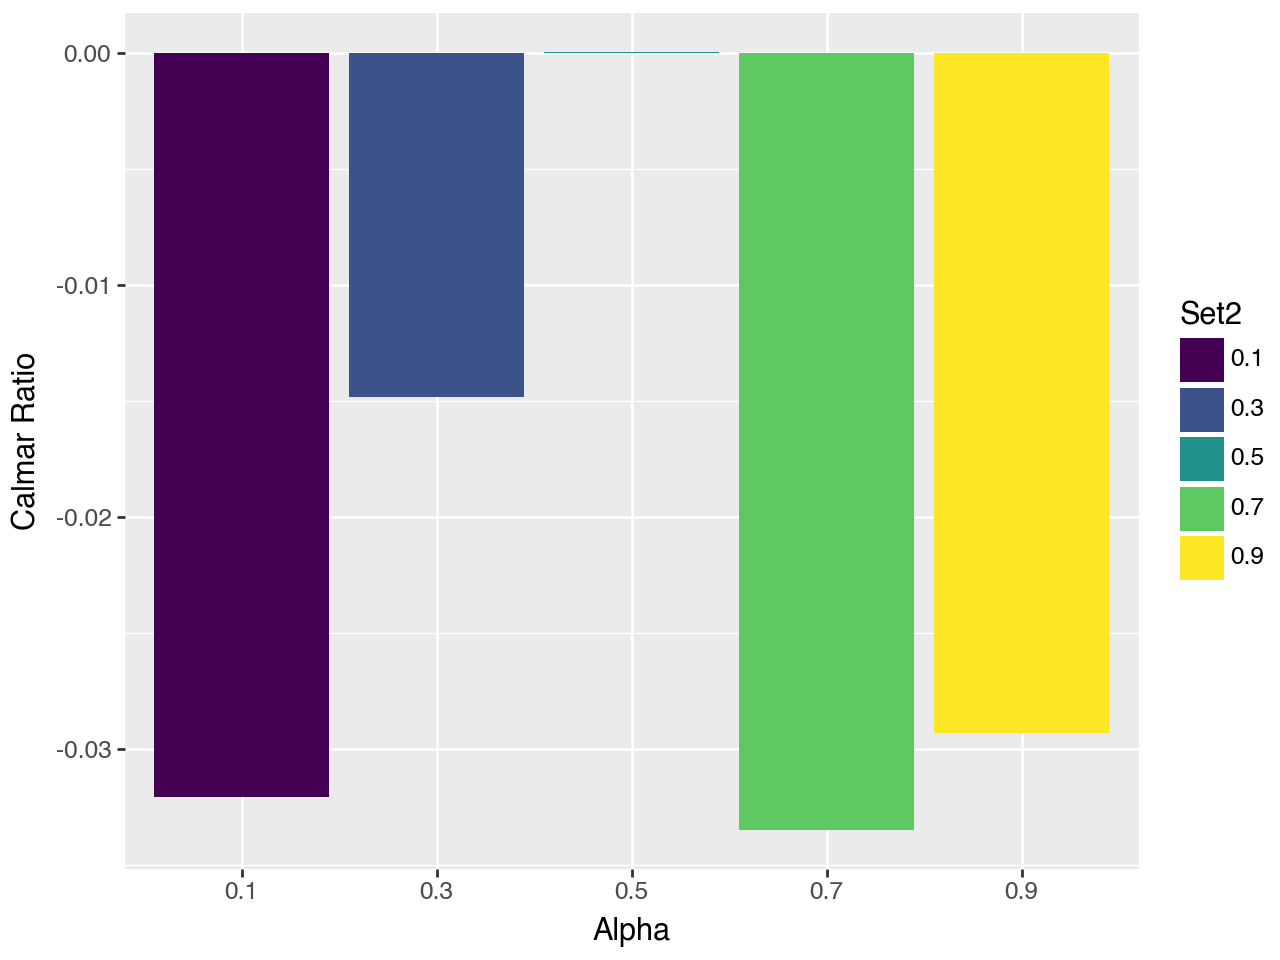

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_BAC_barplot.pdf


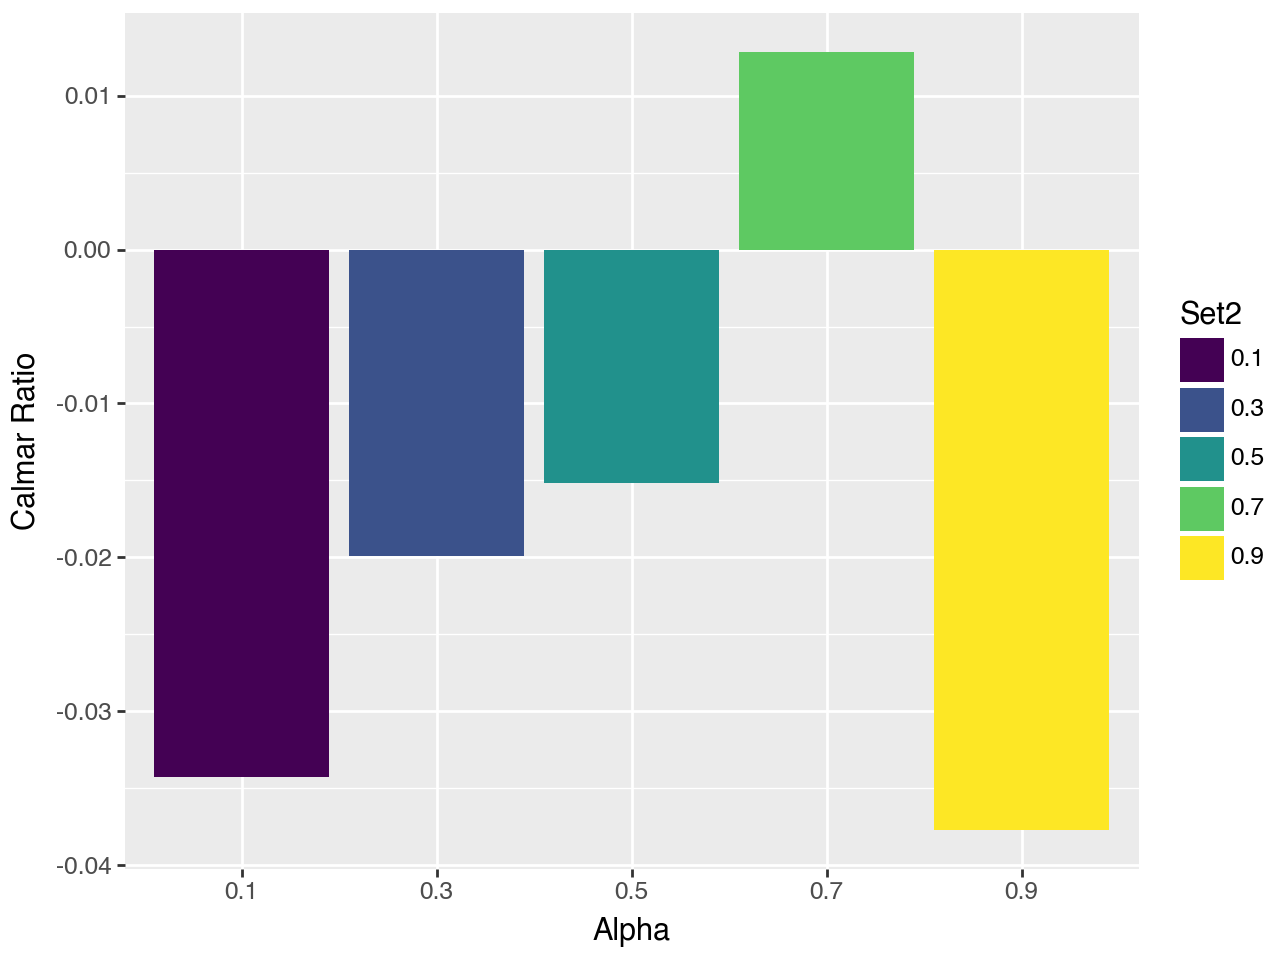

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_BBL_barplot.pdf


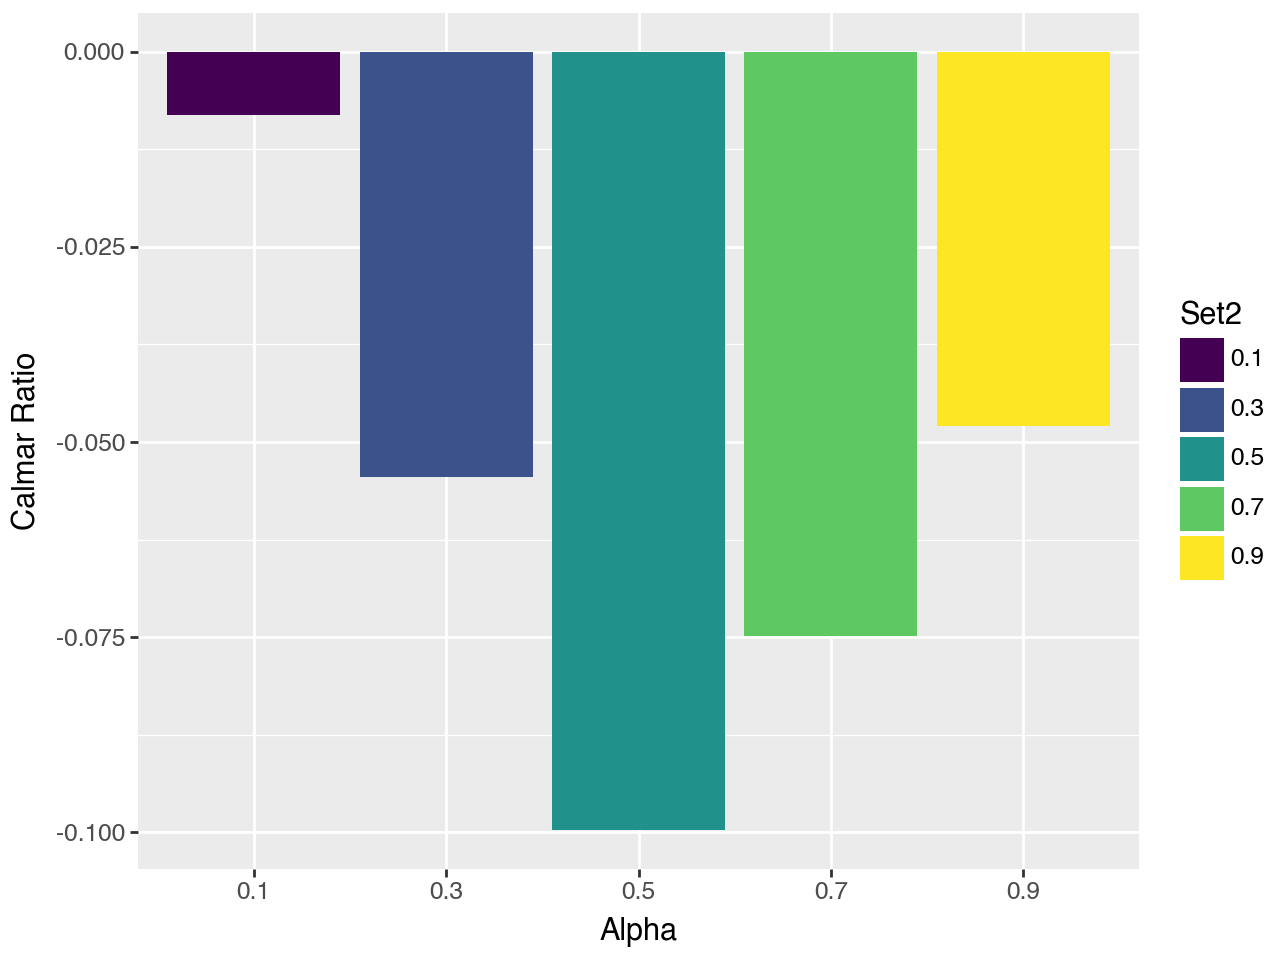

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_BHP_barplot.pdf


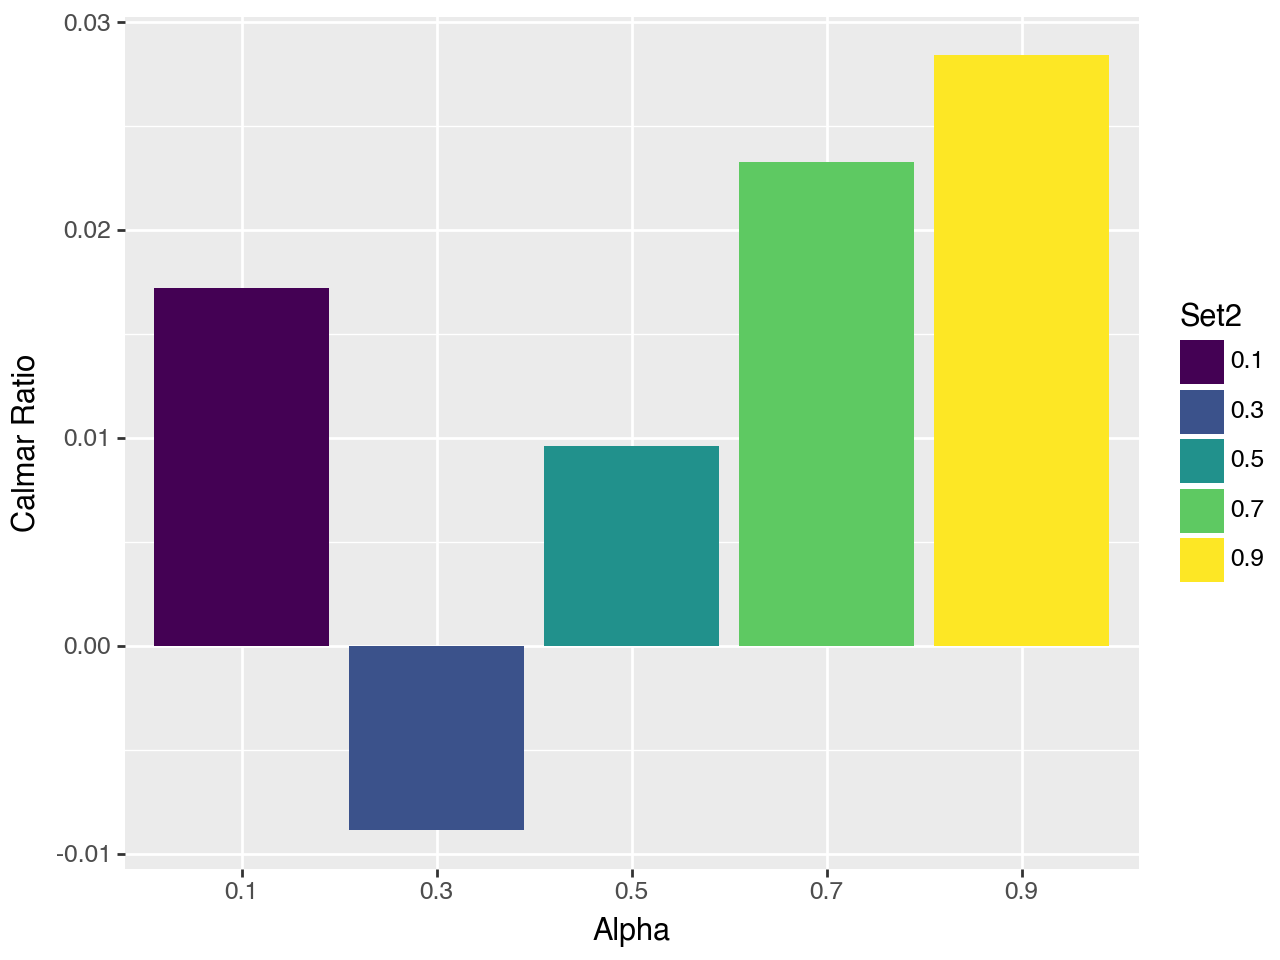

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_BP_barplot.pdf


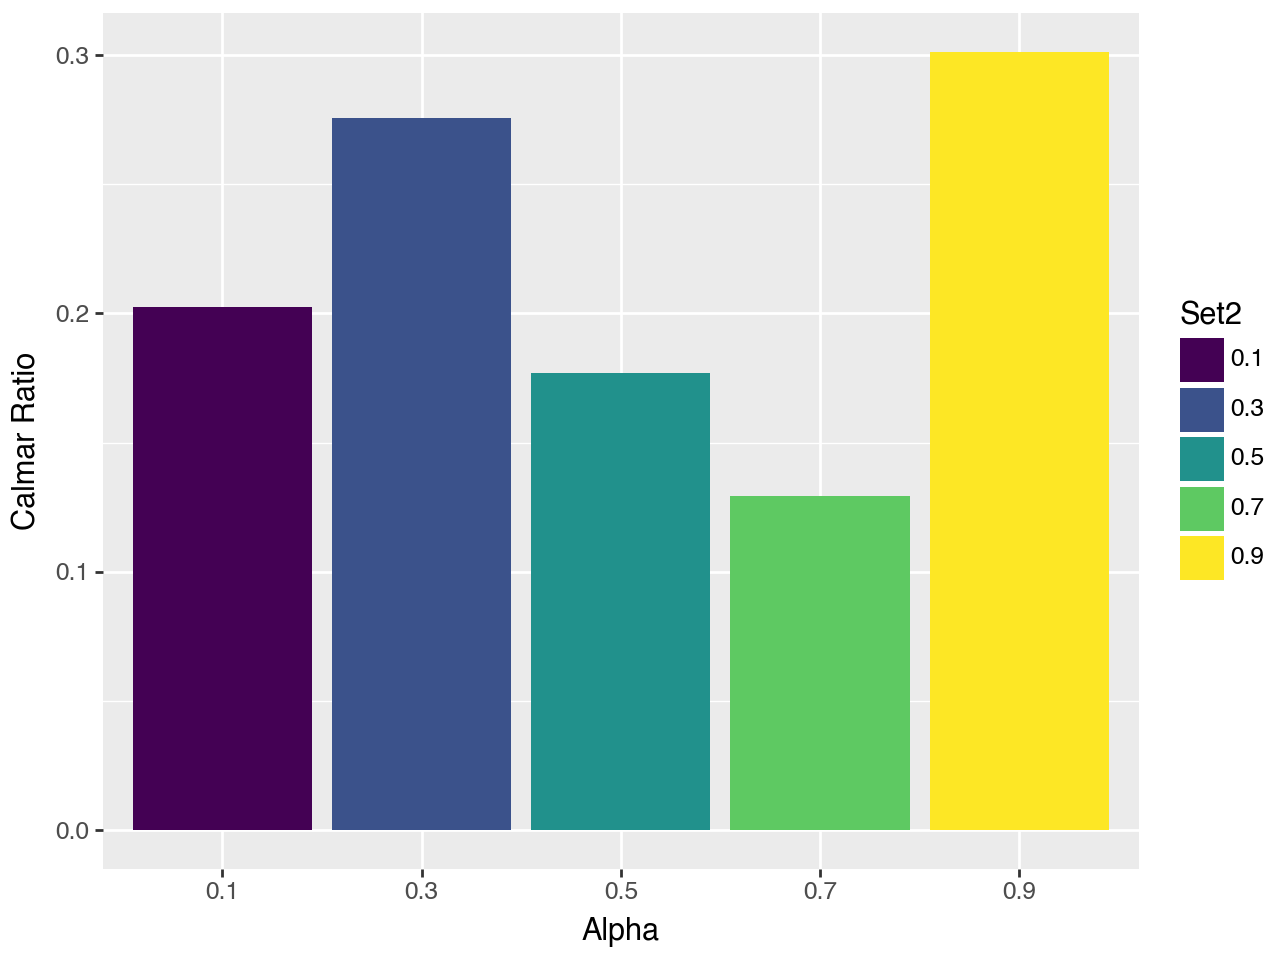

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_BRK-A_barplot.pdf


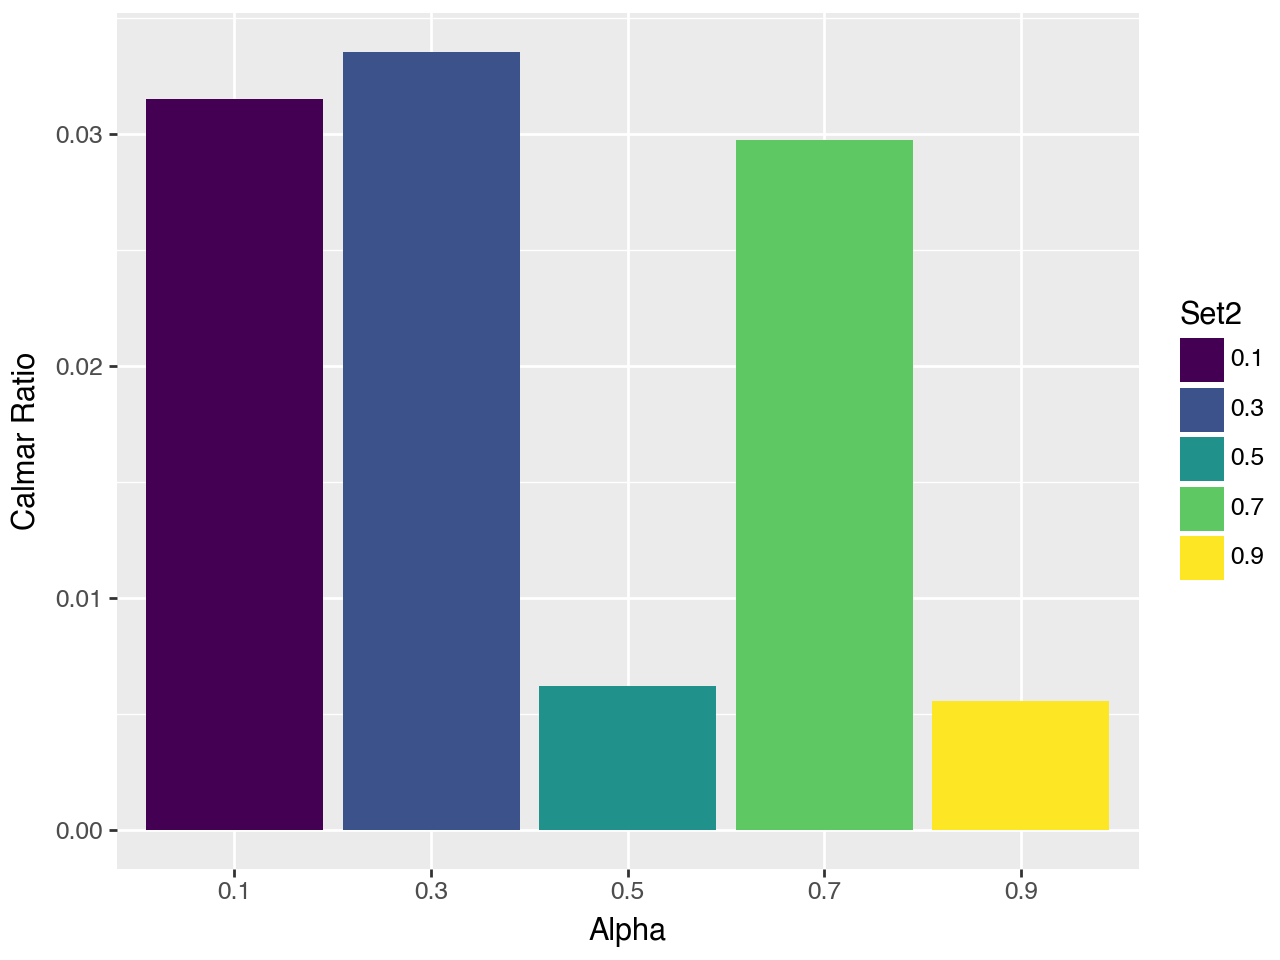

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_CCI_barplot.pdf


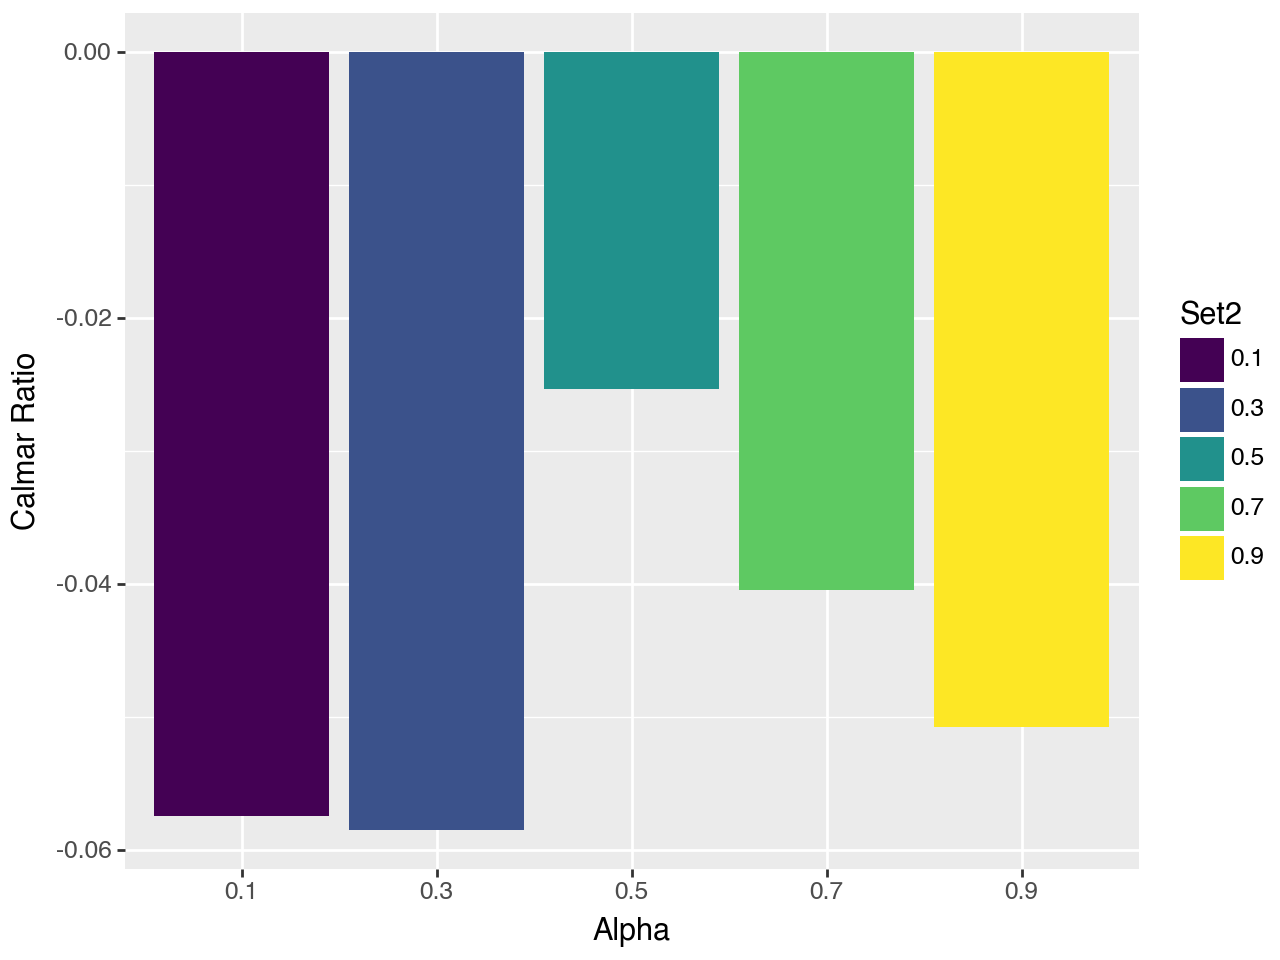

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_CHTR_barplot.pdf


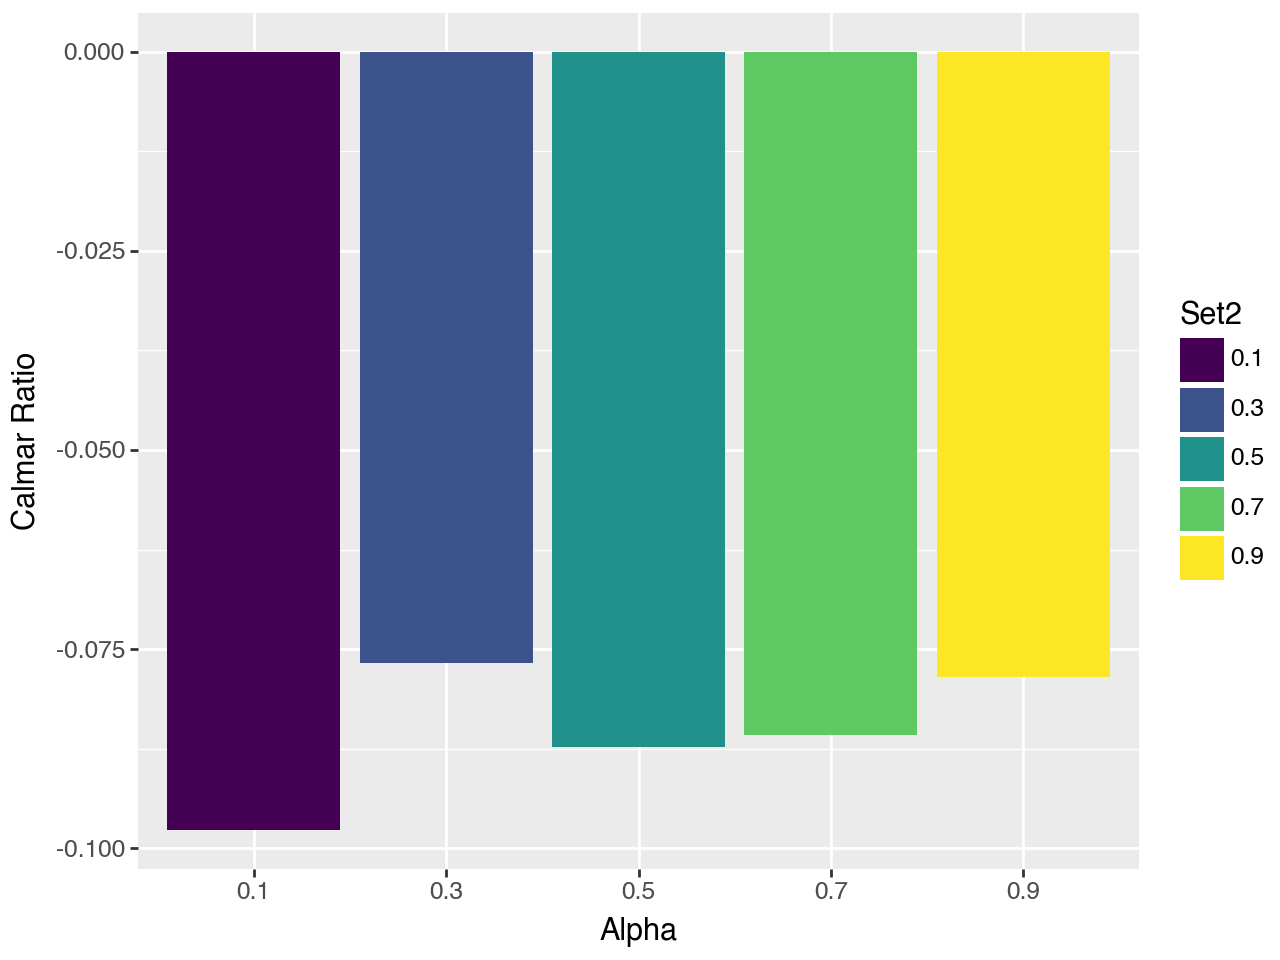

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_COP_barplot.pdf


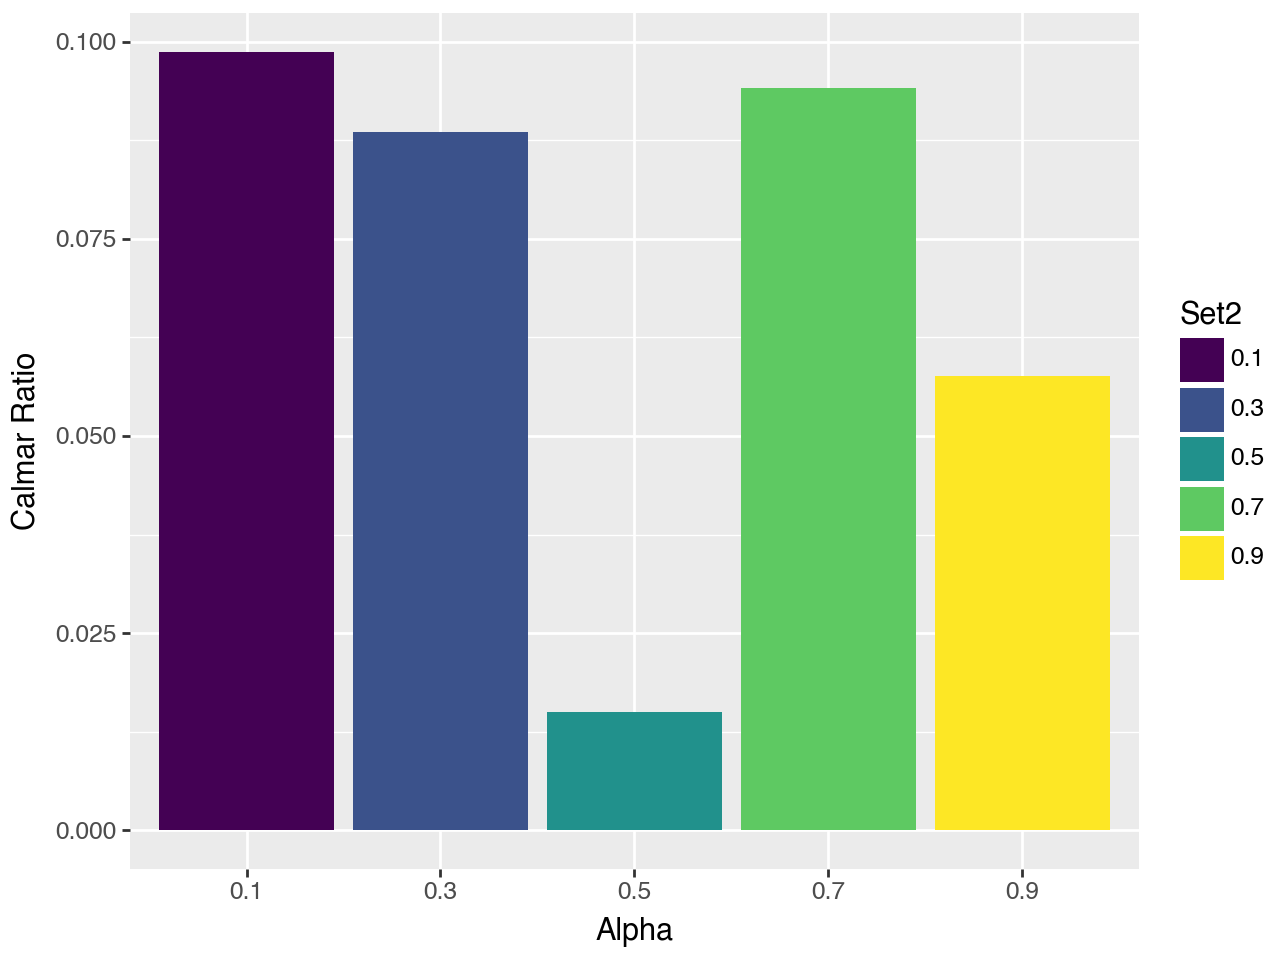

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_COST_barplot.pdf


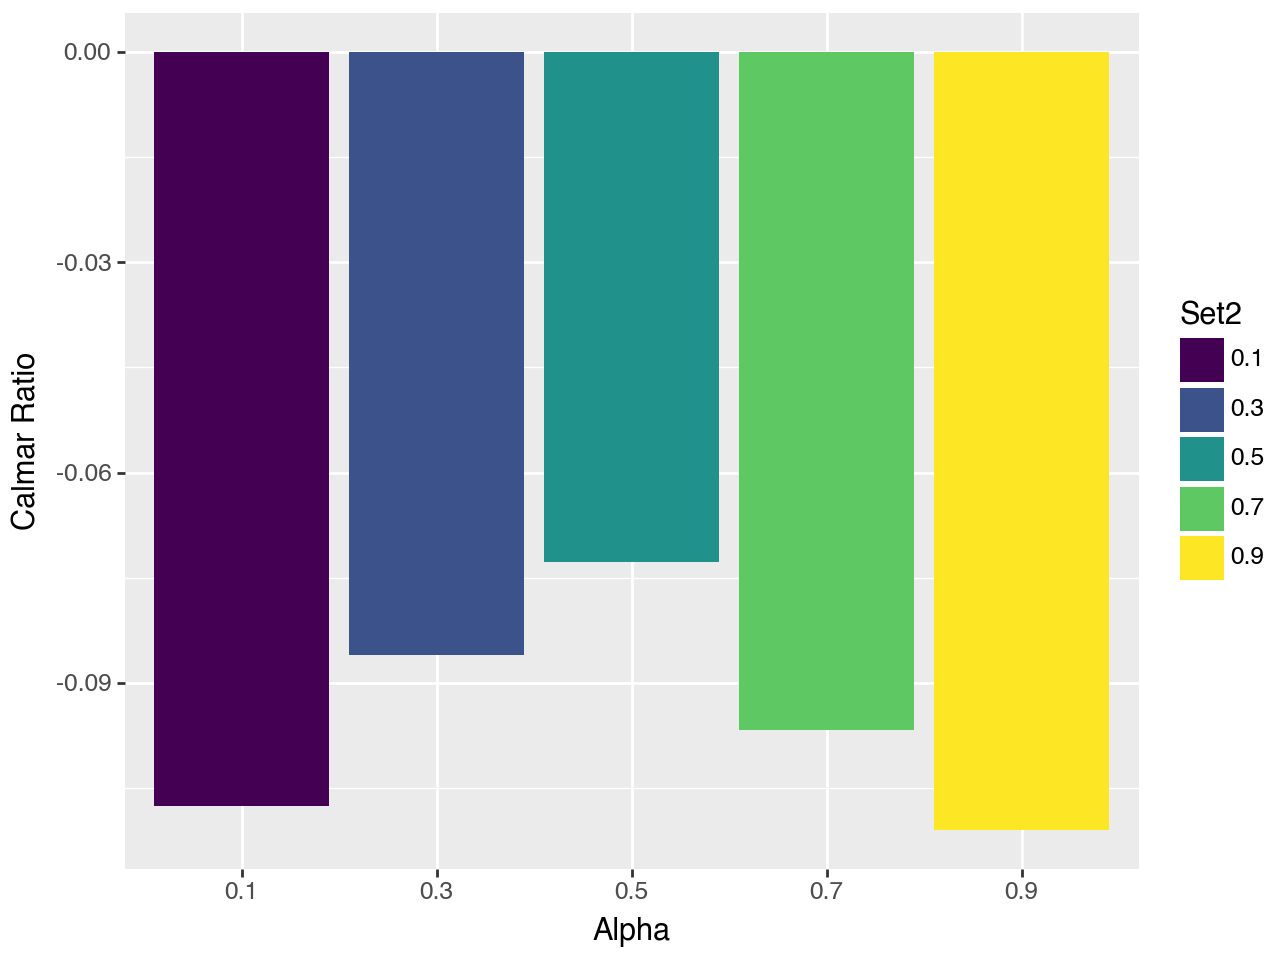

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_CSCO_barplot.pdf


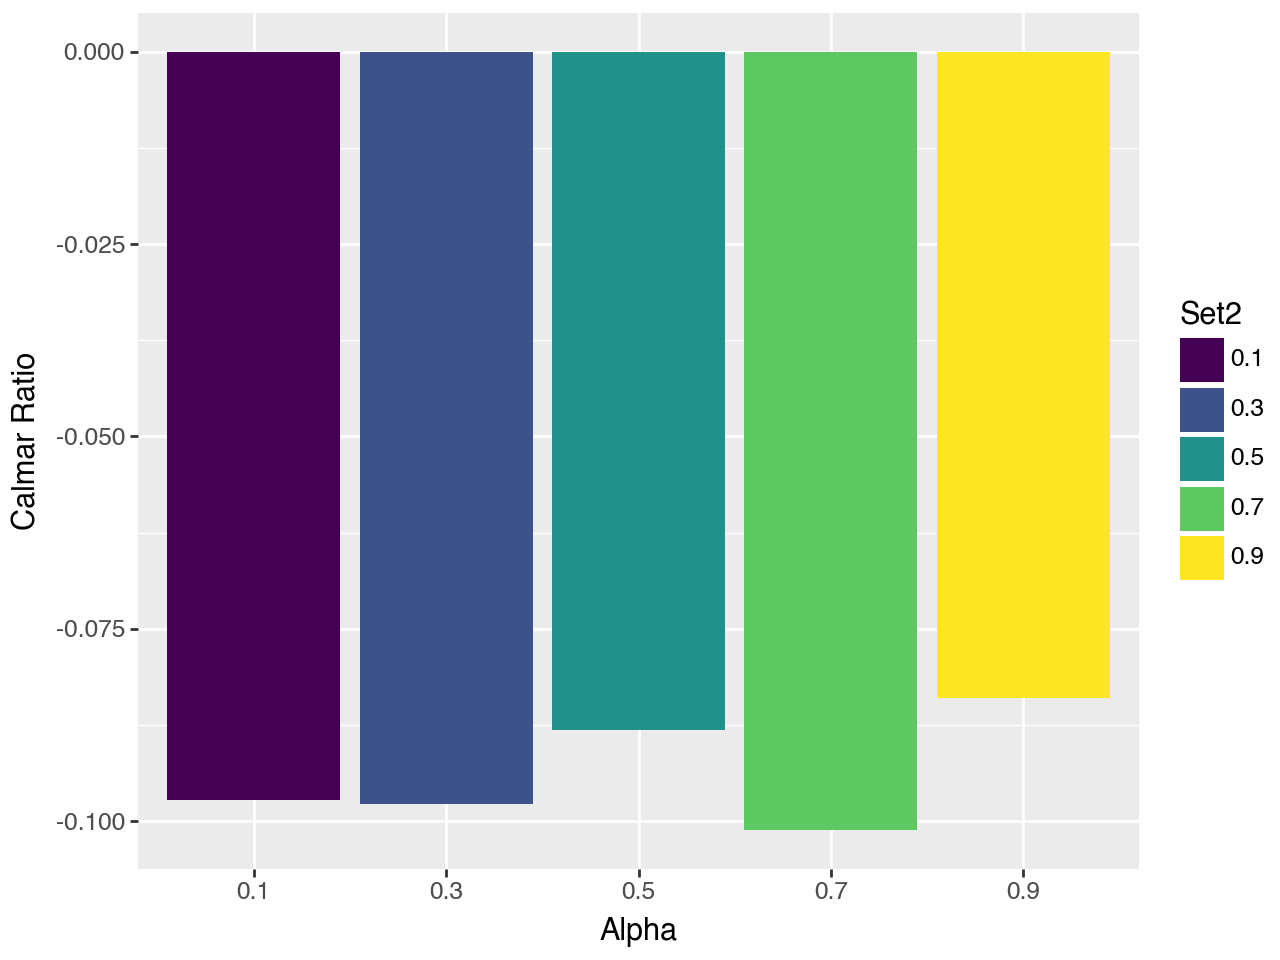

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_CVX_barplot.pdf


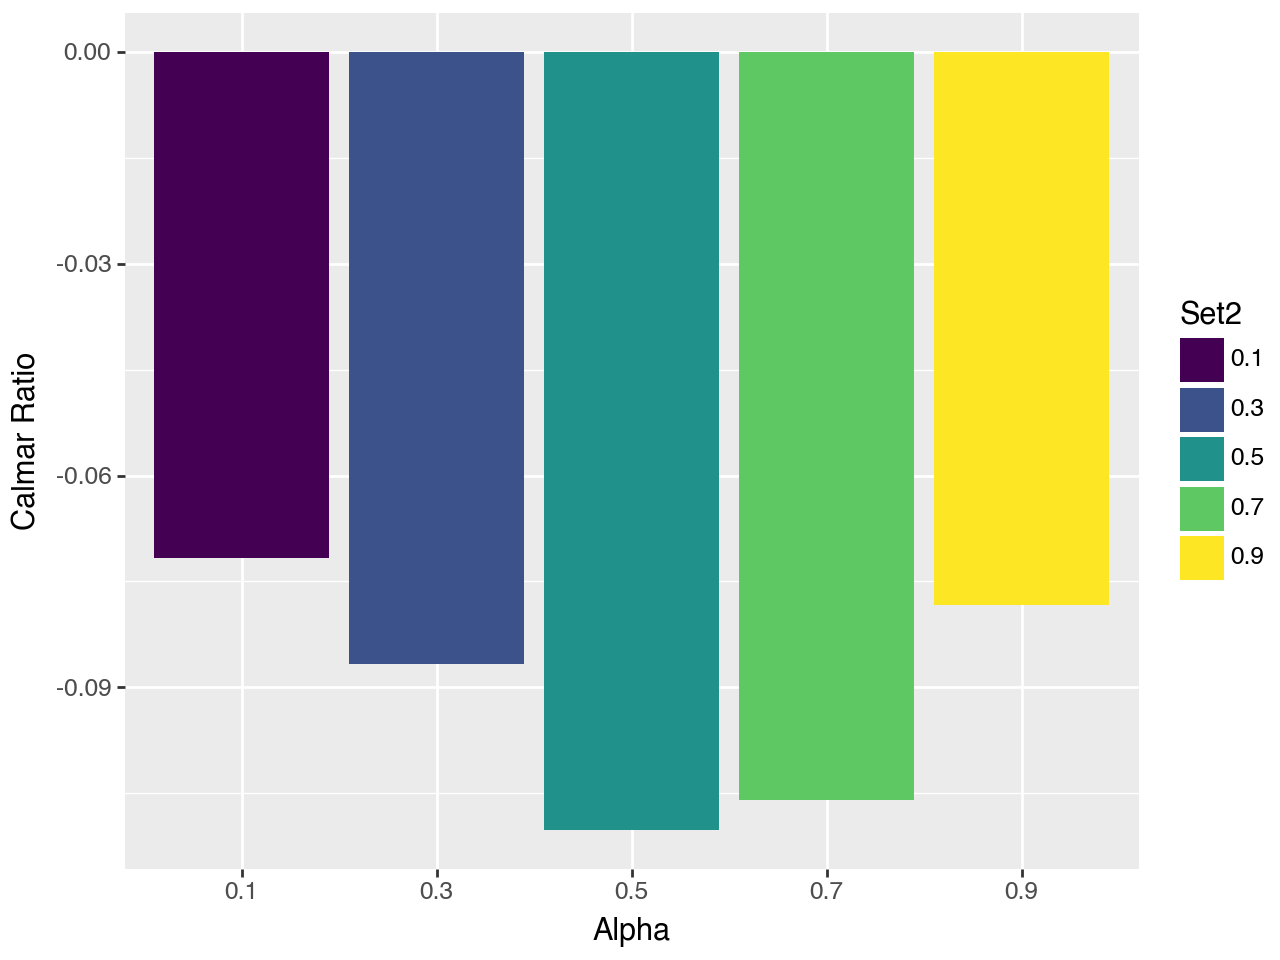

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_DE_barplot.pdf


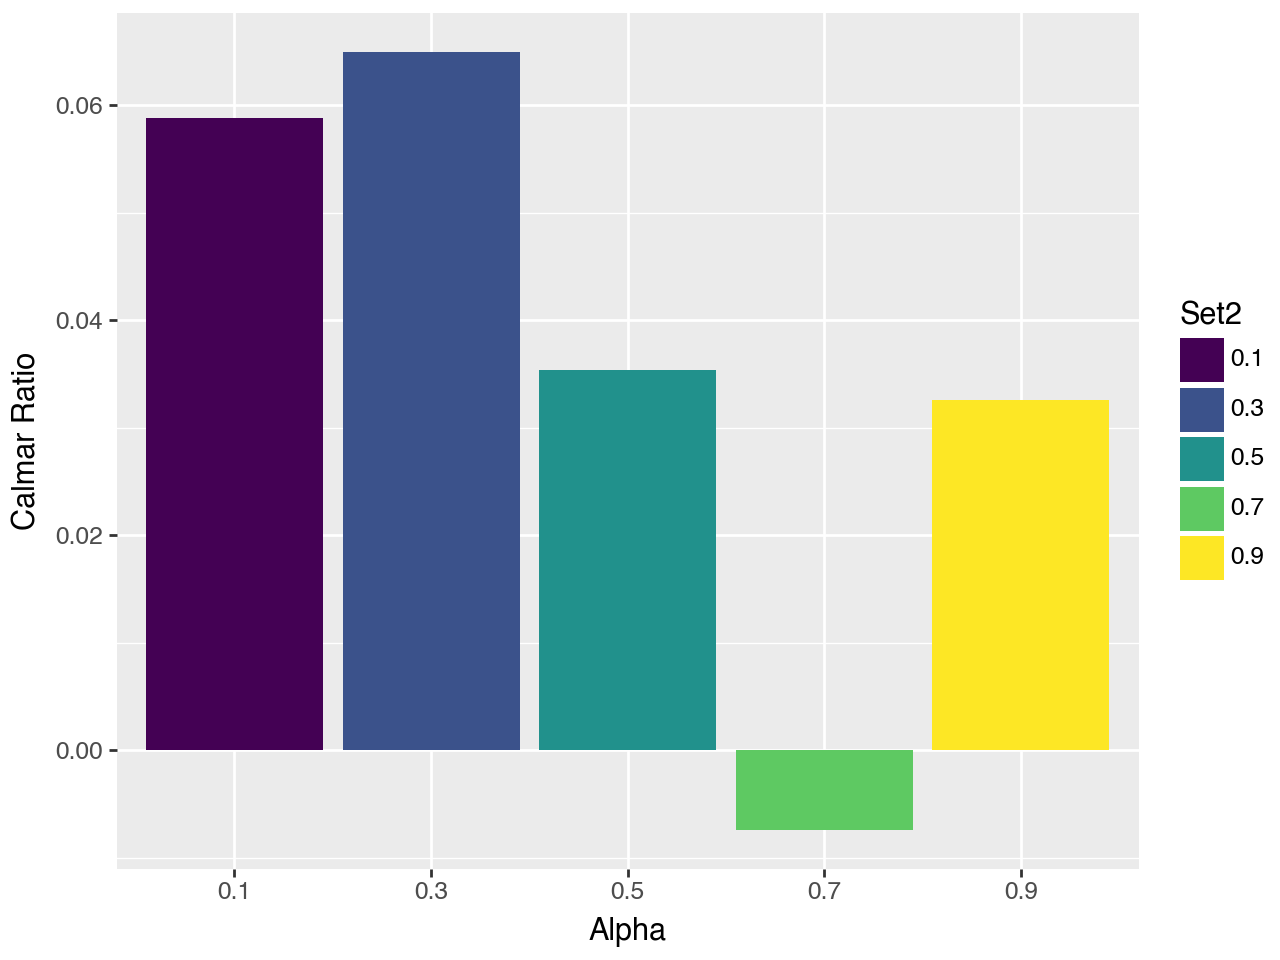

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_DEO_barplot.pdf


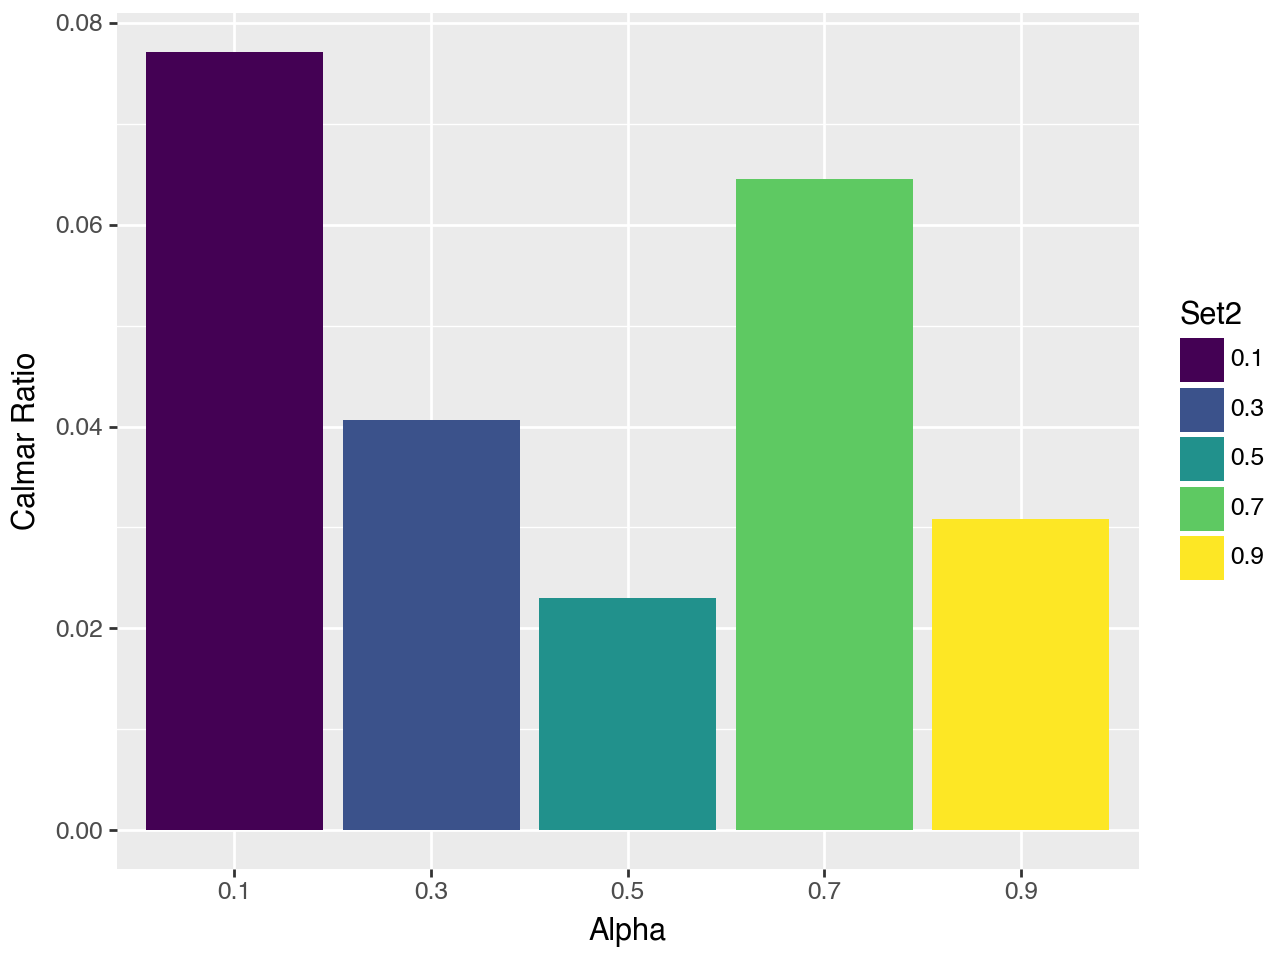

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_DHR_barplot.pdf


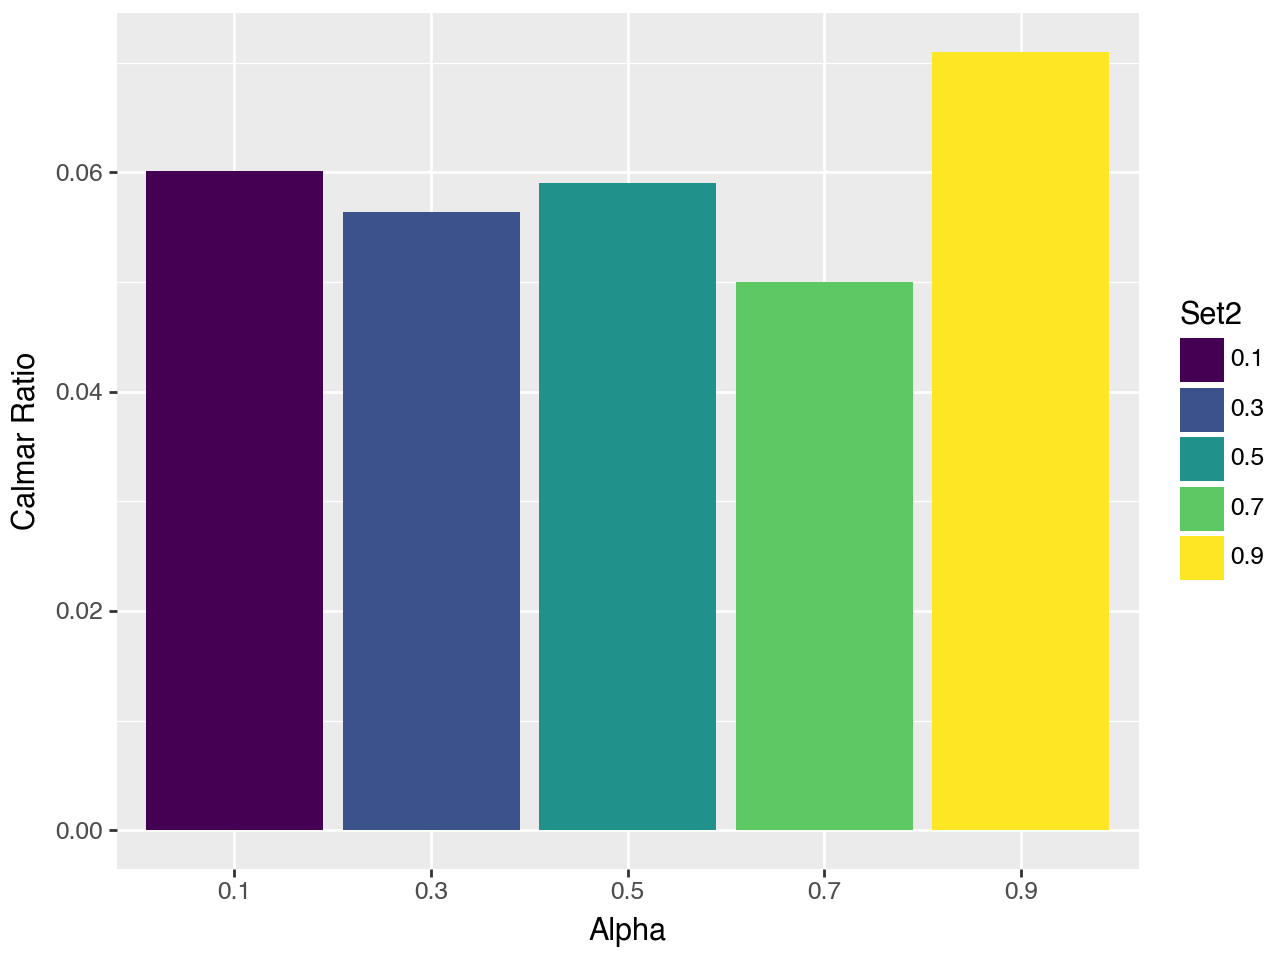

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_DLR_barplot.pdf


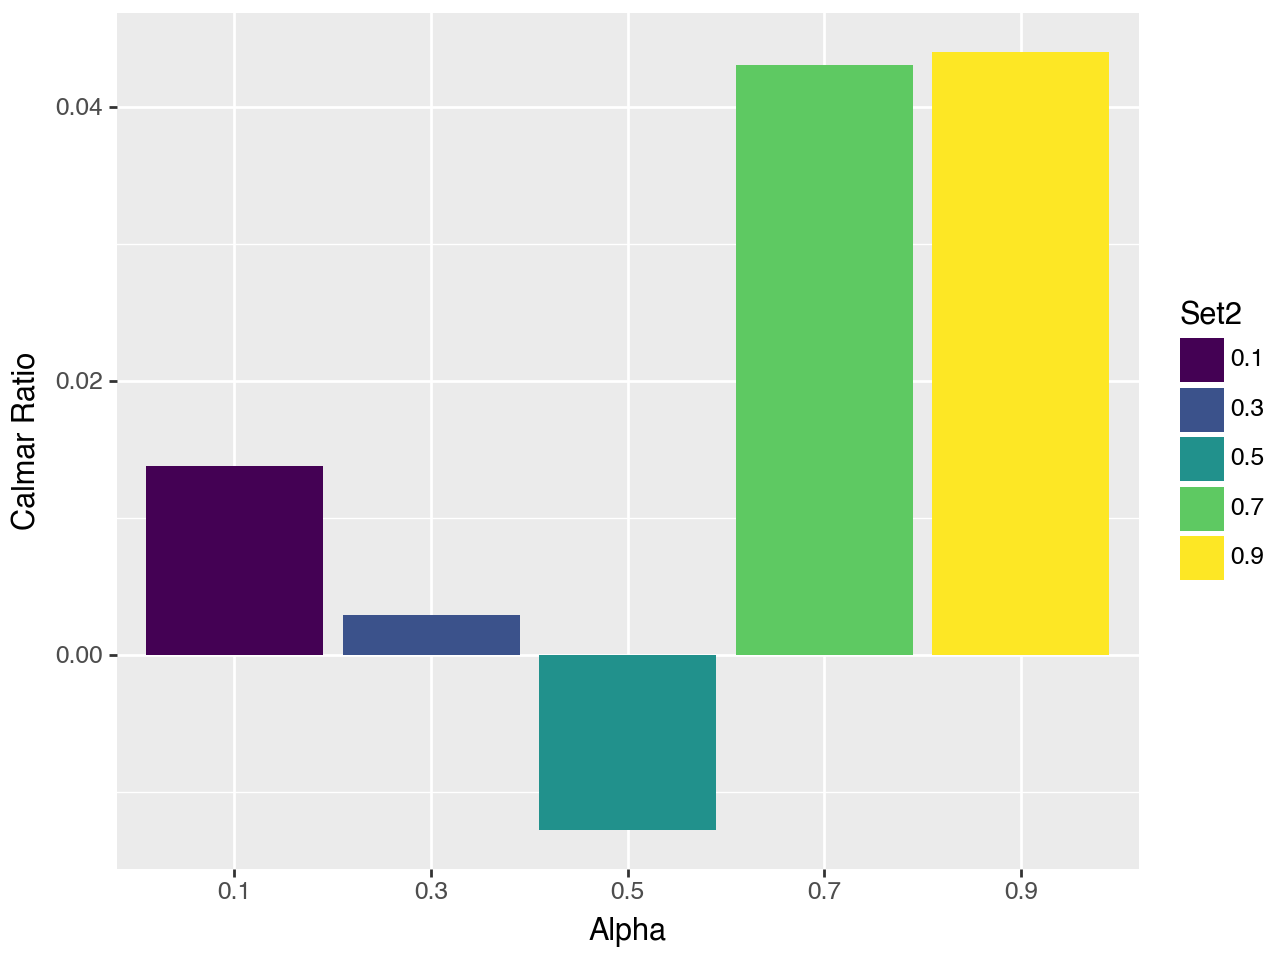

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_DUK_barplot.pdf


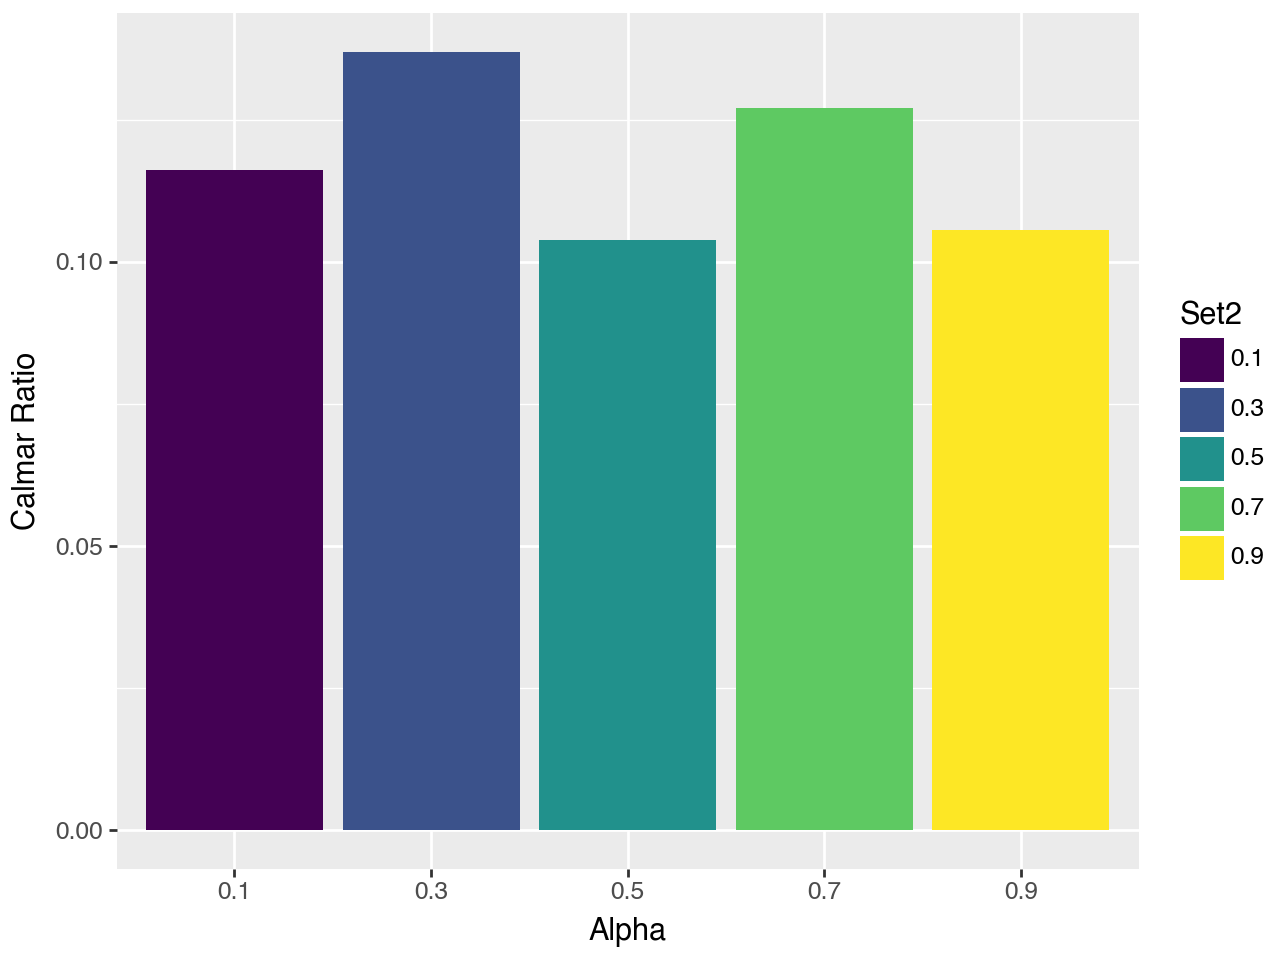

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_ECL_barplot.pdf


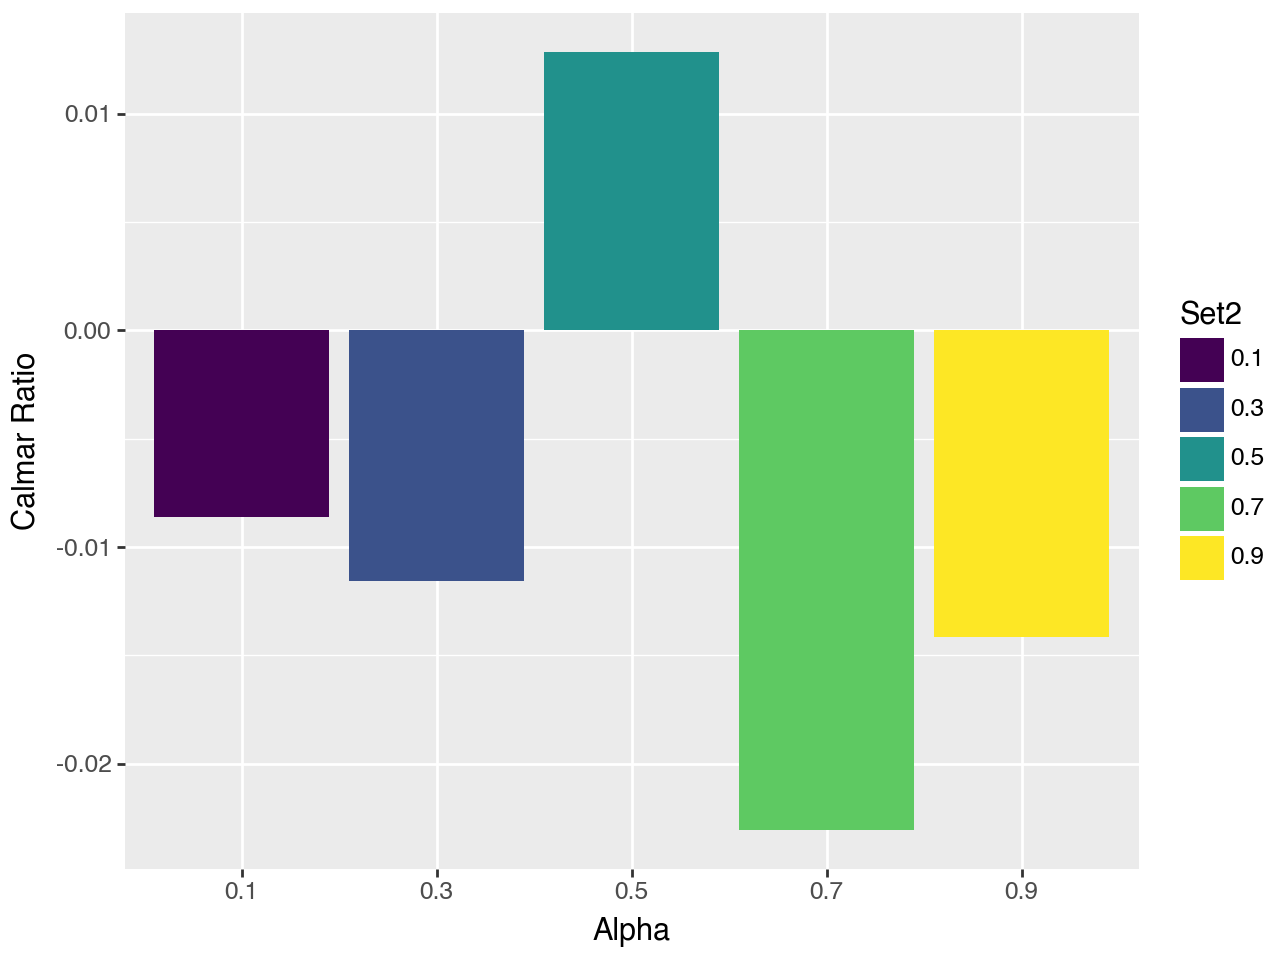

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_EL_barplot.pdf


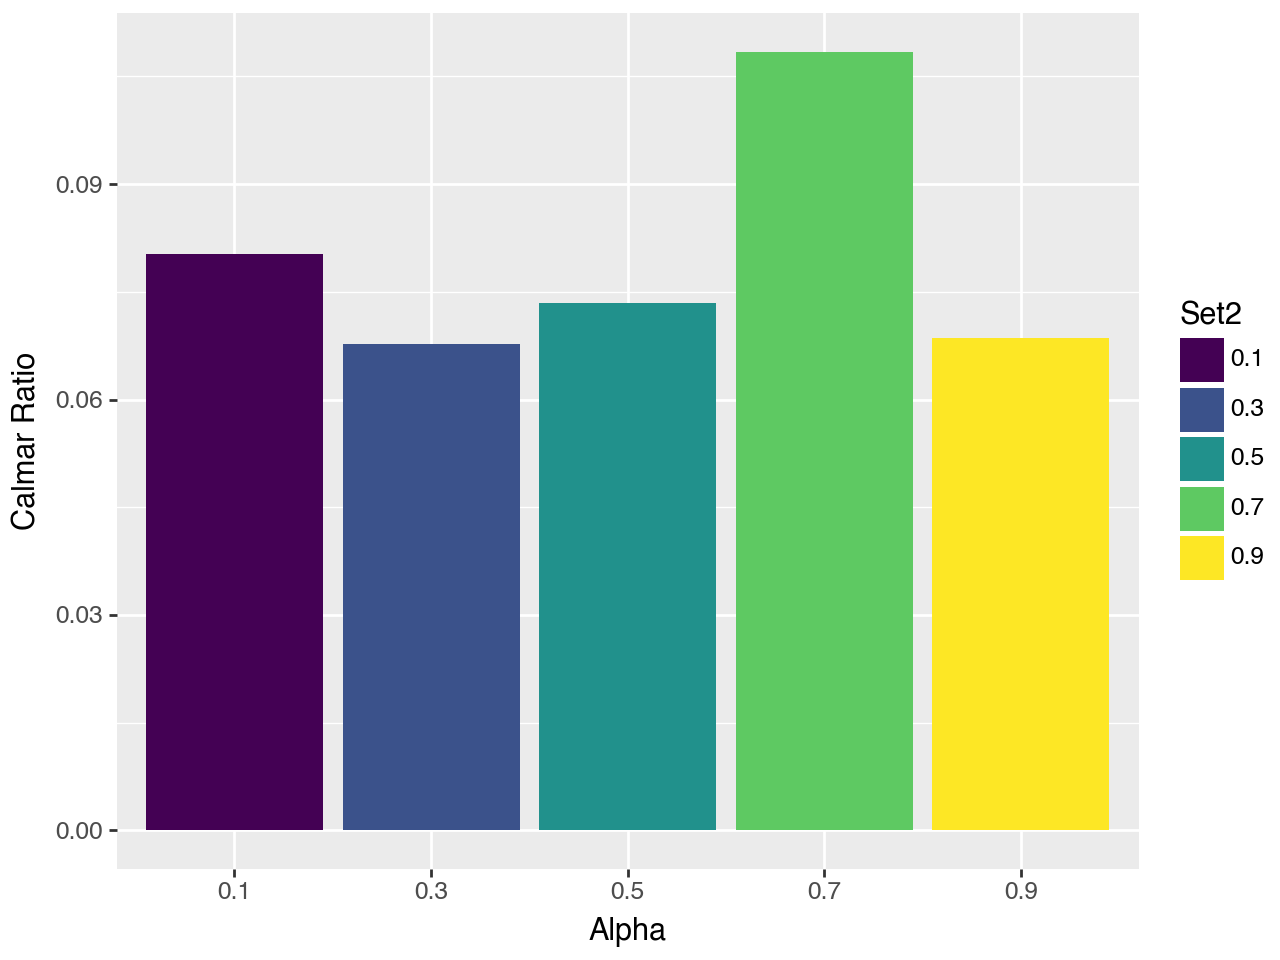

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_EQIX_barplot.pdf


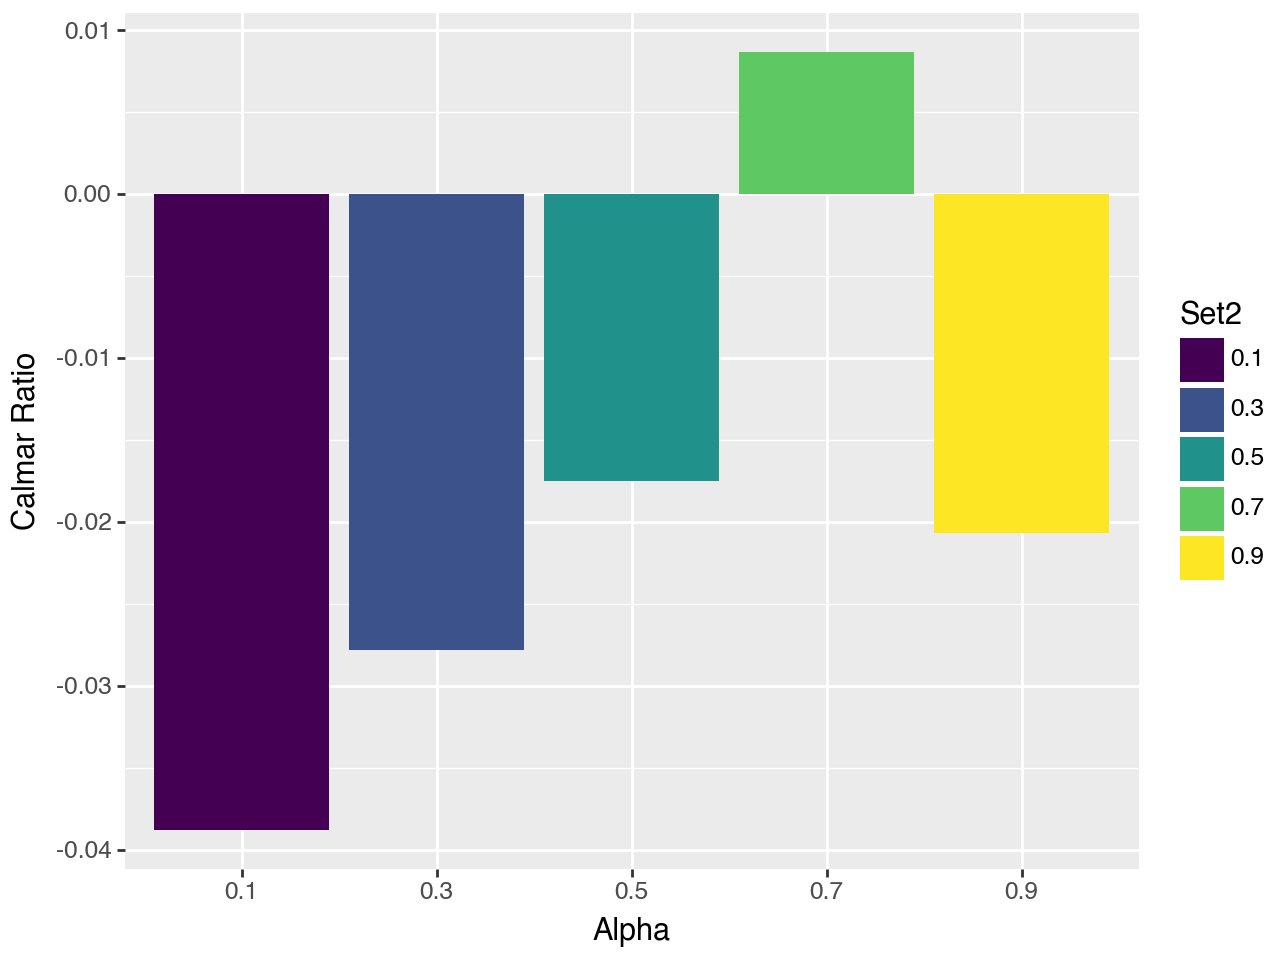

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_EQNR_barplot.pdf


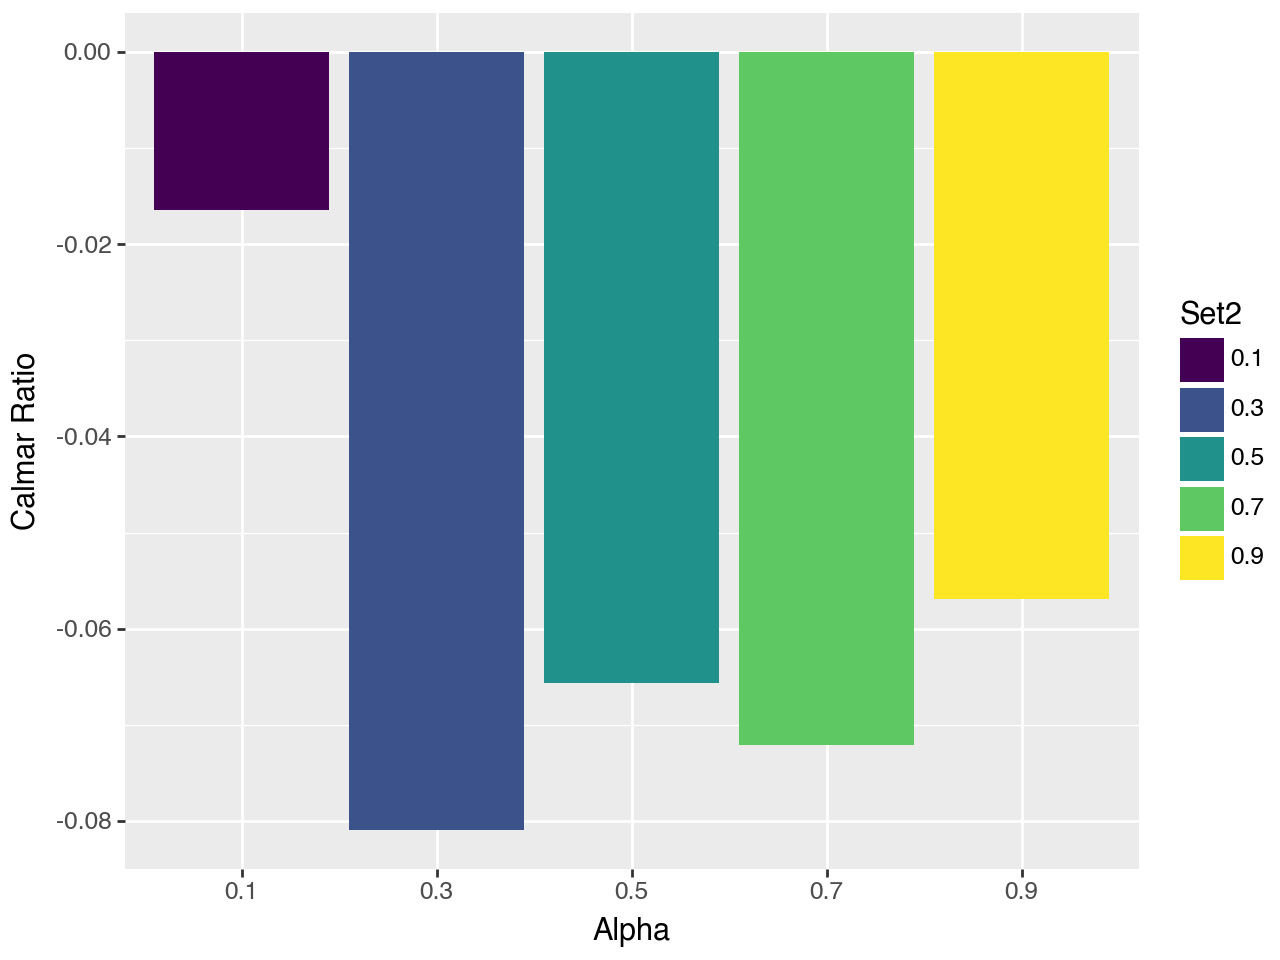

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_FCX_barplot.pdf


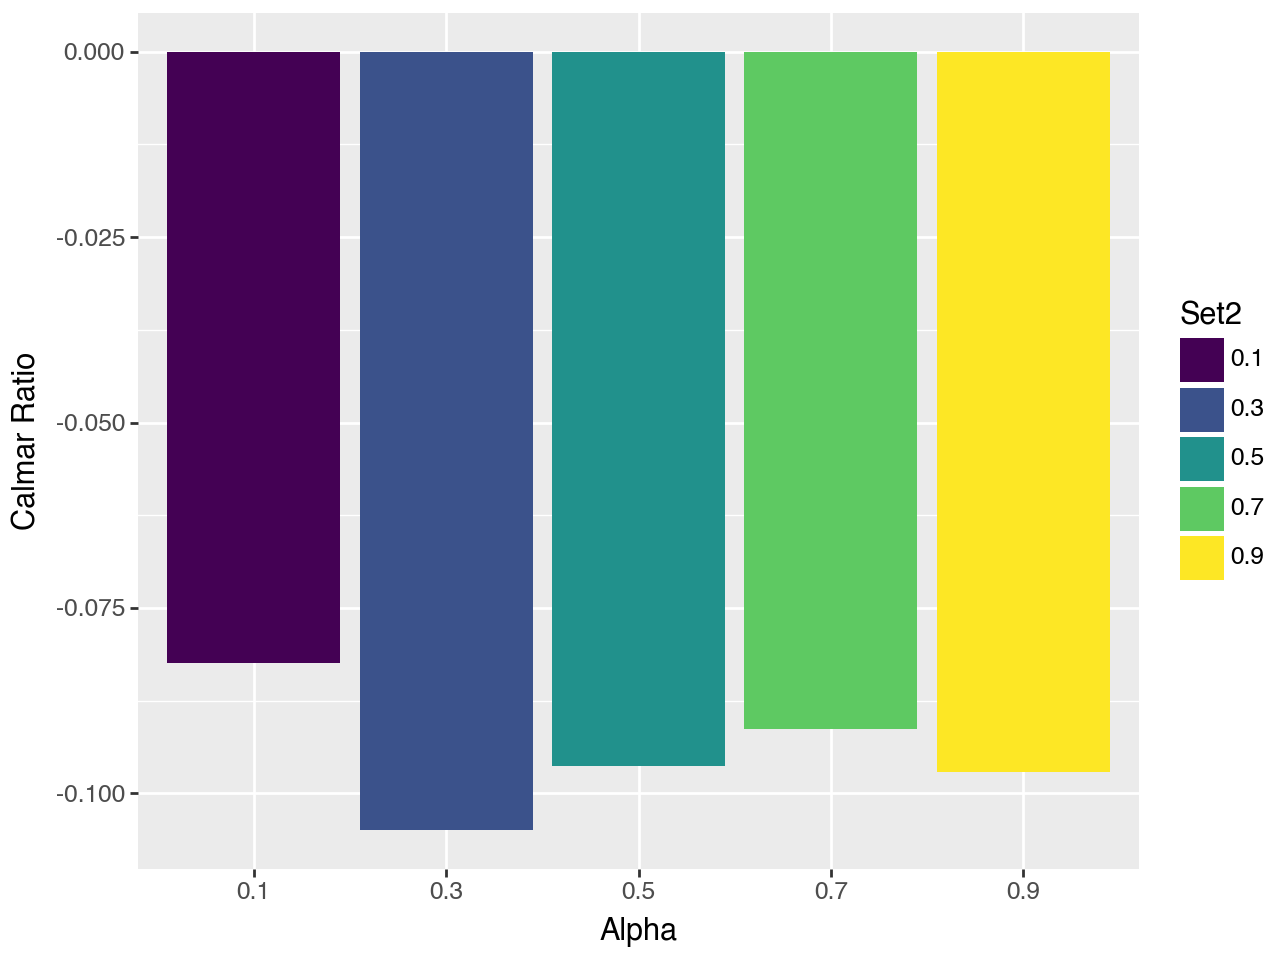

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_GE_barplot.pdf


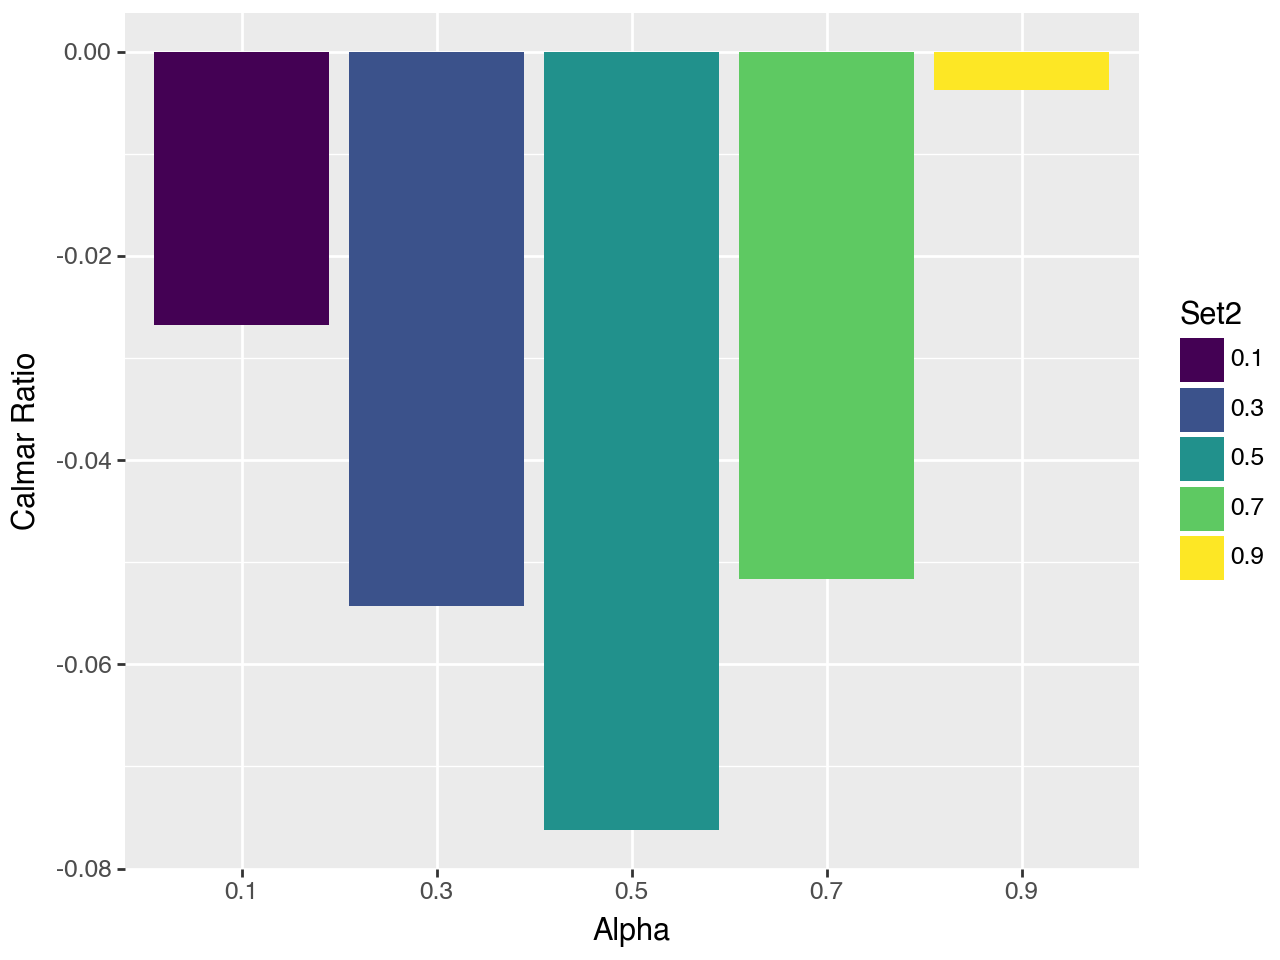

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_GOOG_barplot.pdf


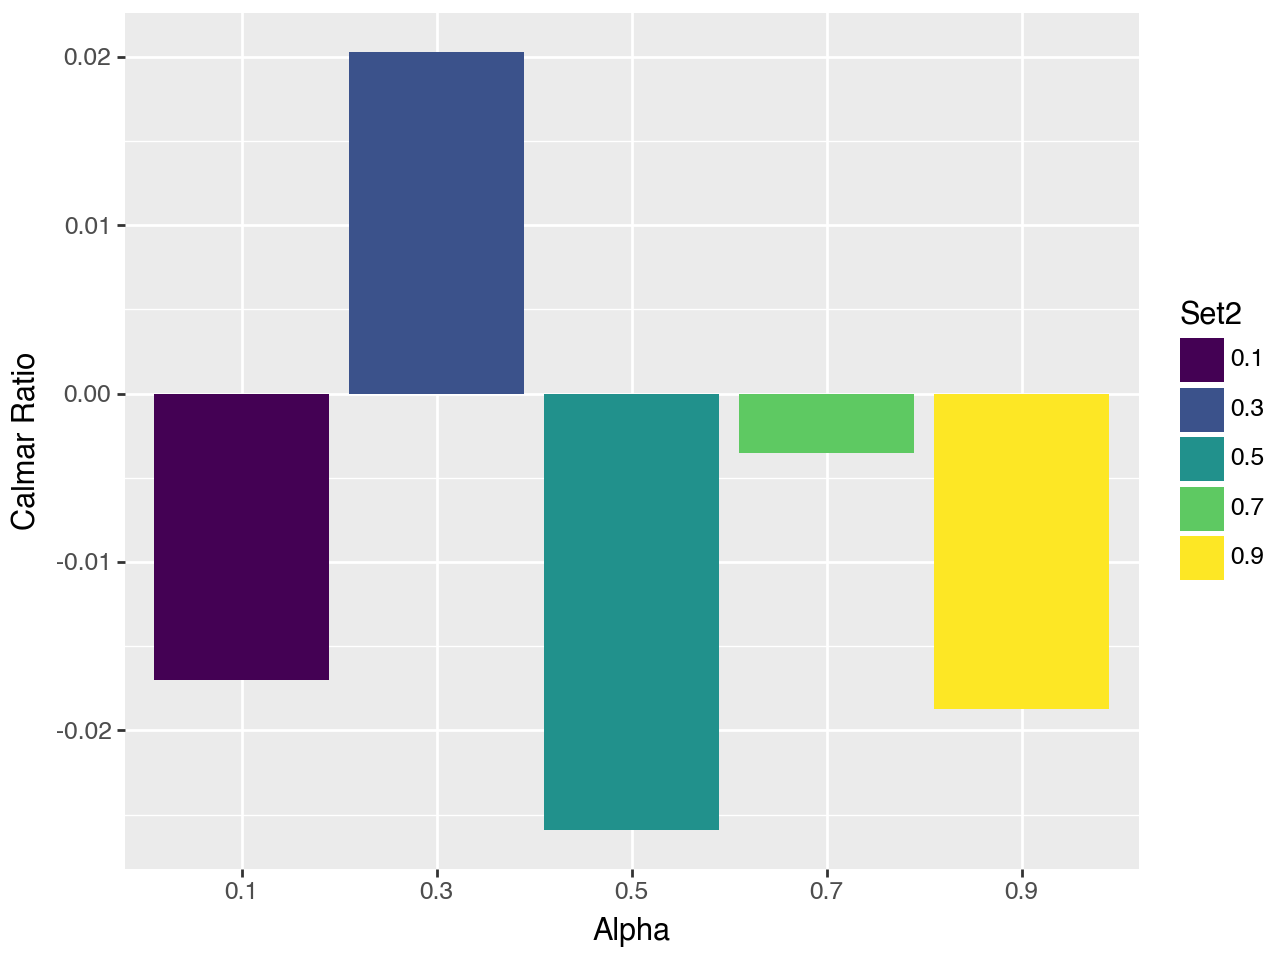

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Calmar Ratio/Alpha_O_barplot.pdf


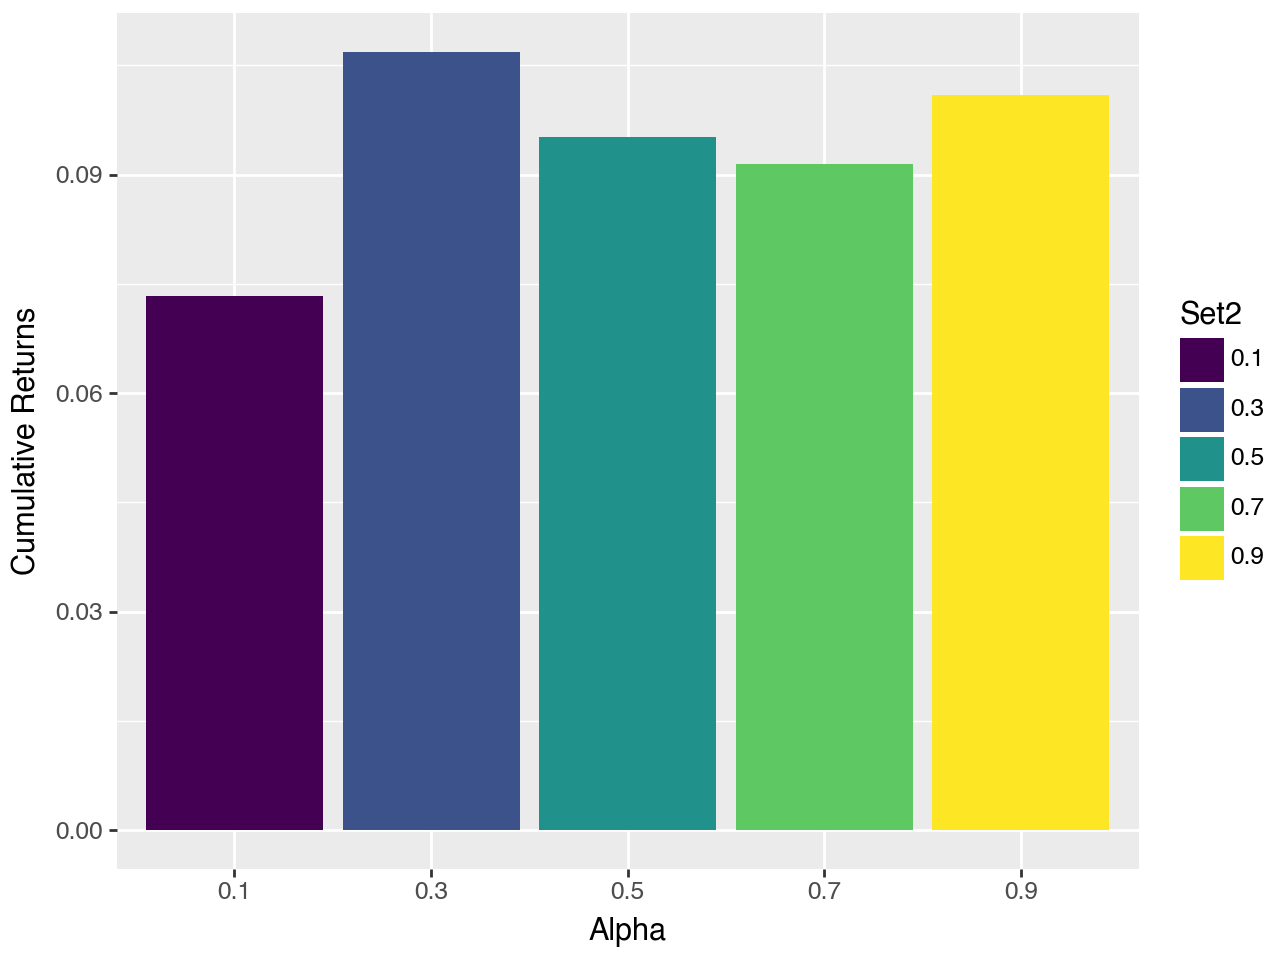

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_AAPL_barplot.pdf


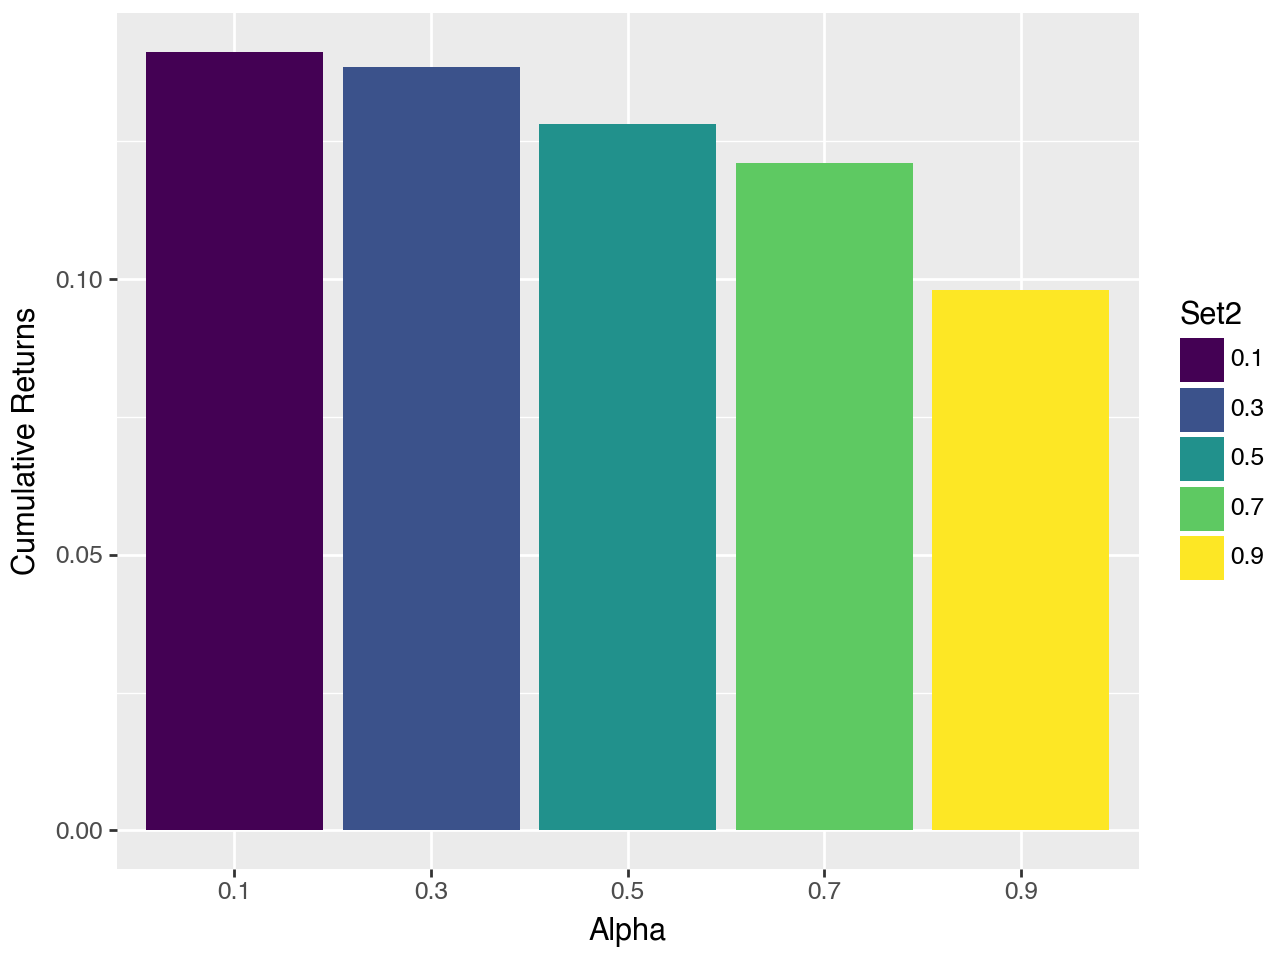

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_ABBV_barplot.pdf


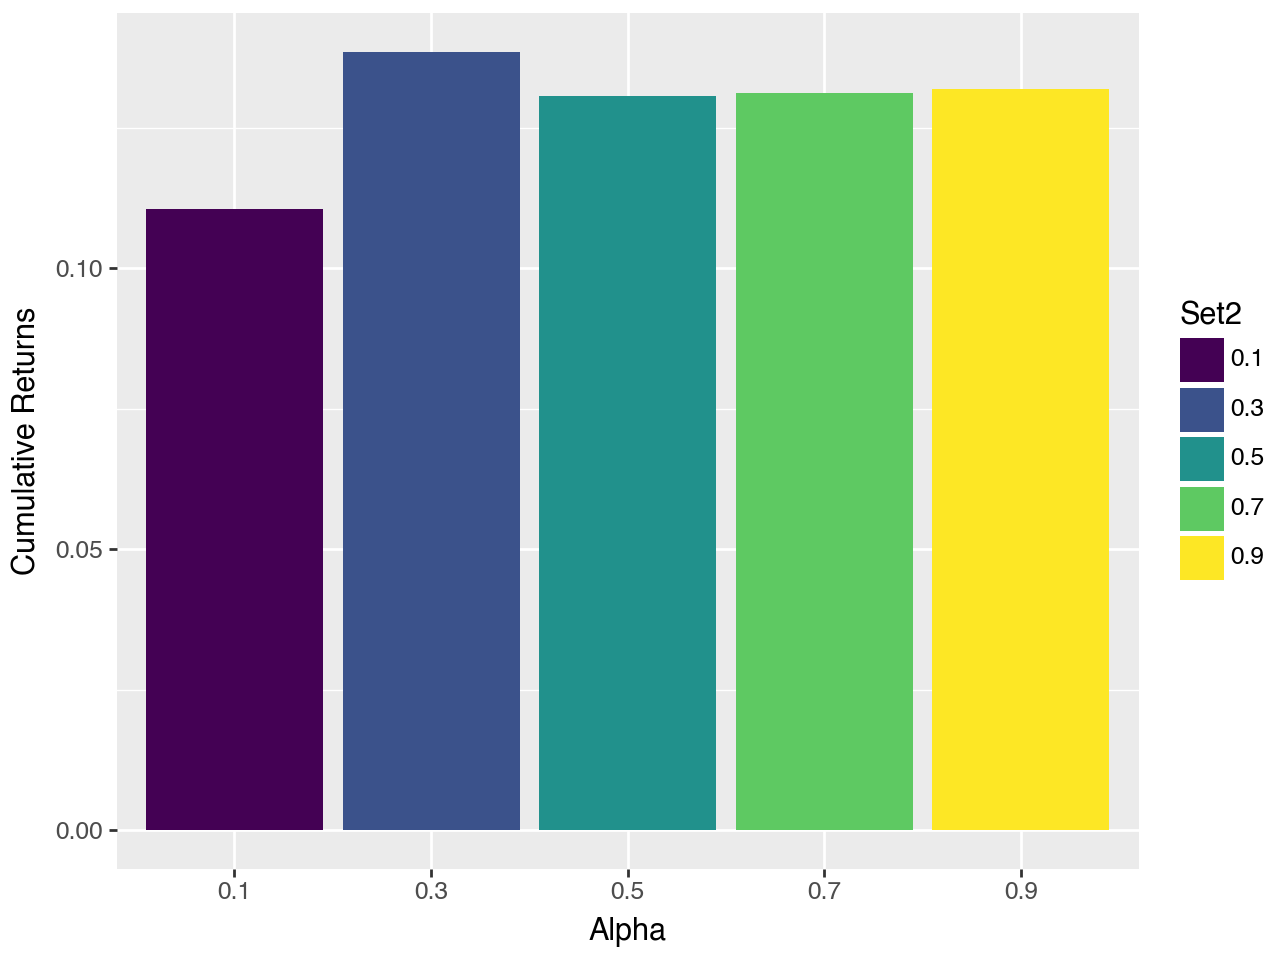

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_ACN_barplot.pdf


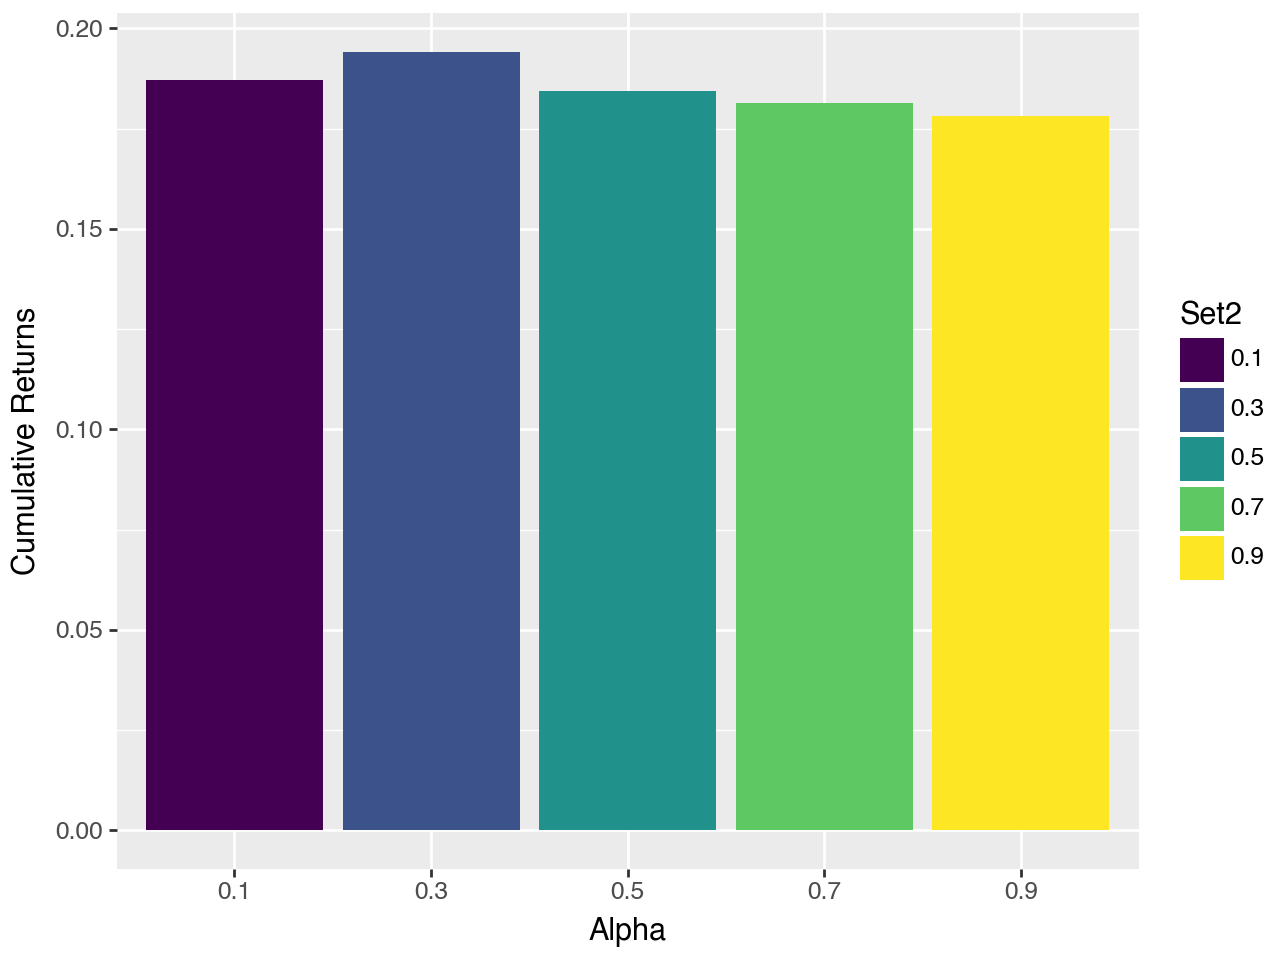

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_ADBE_barplot.pdf


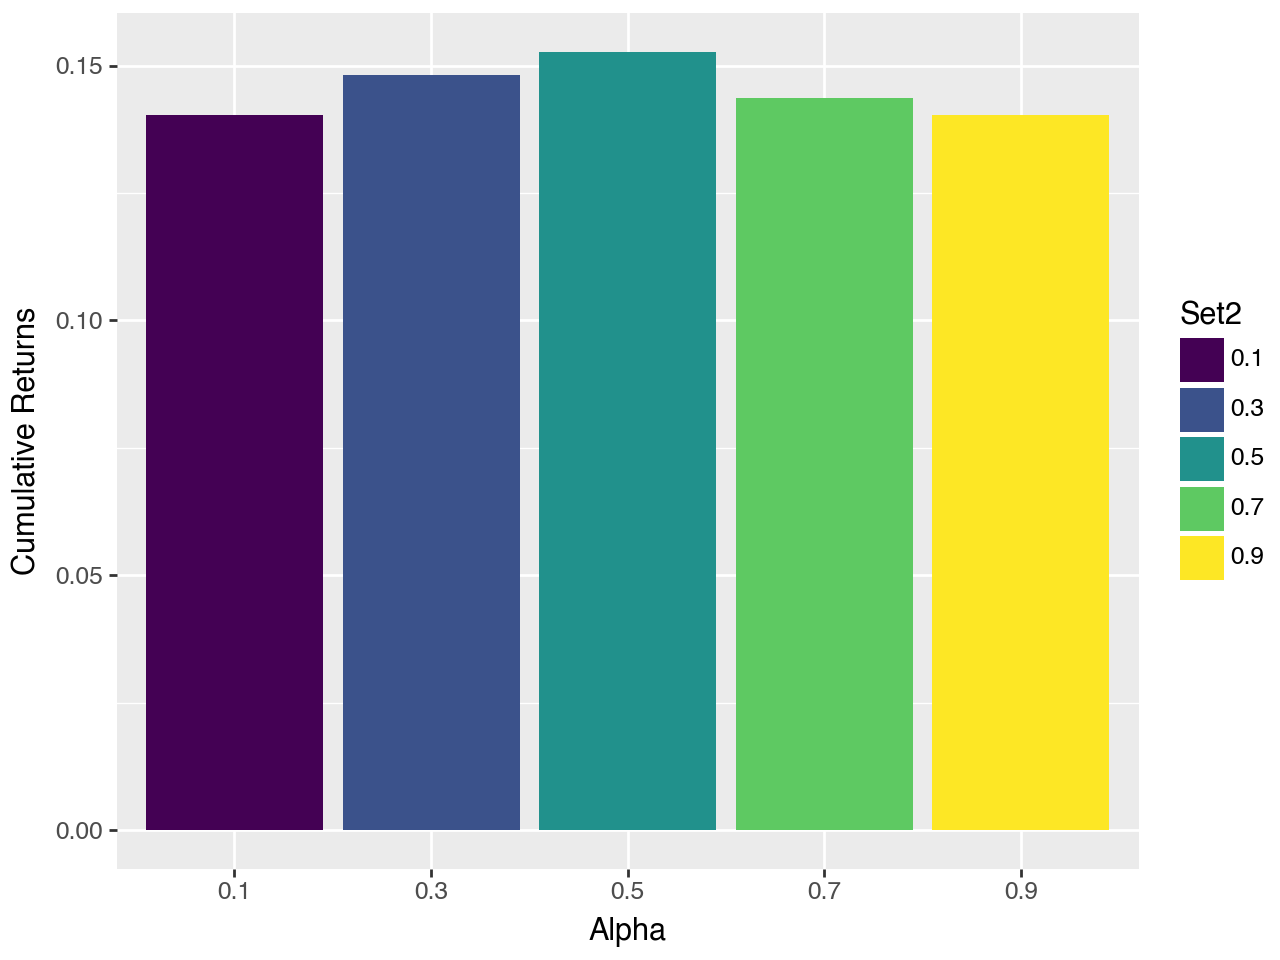

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_ADP_barplot.pdf


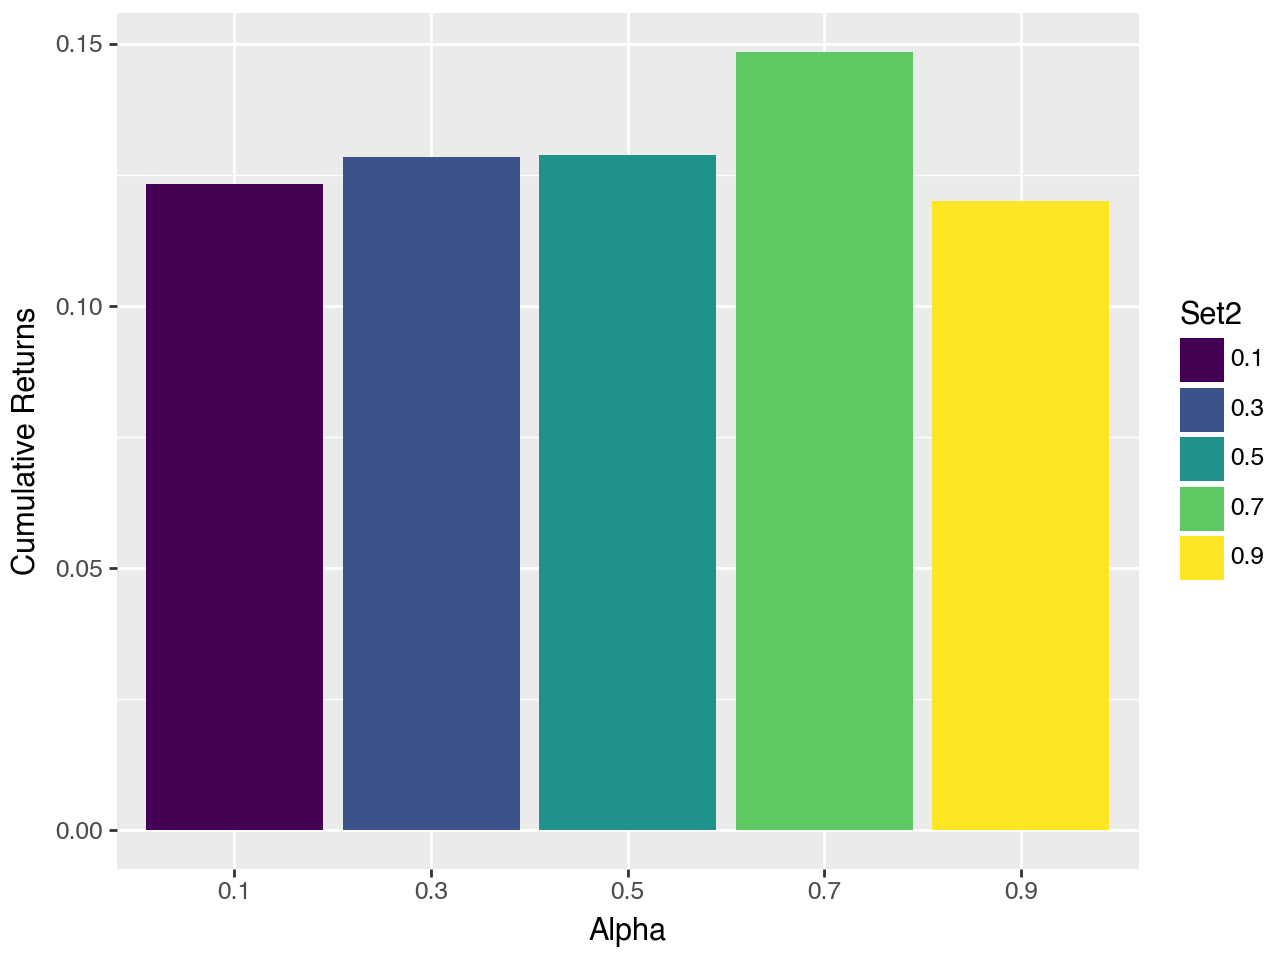

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_AMT_barplot.pdf


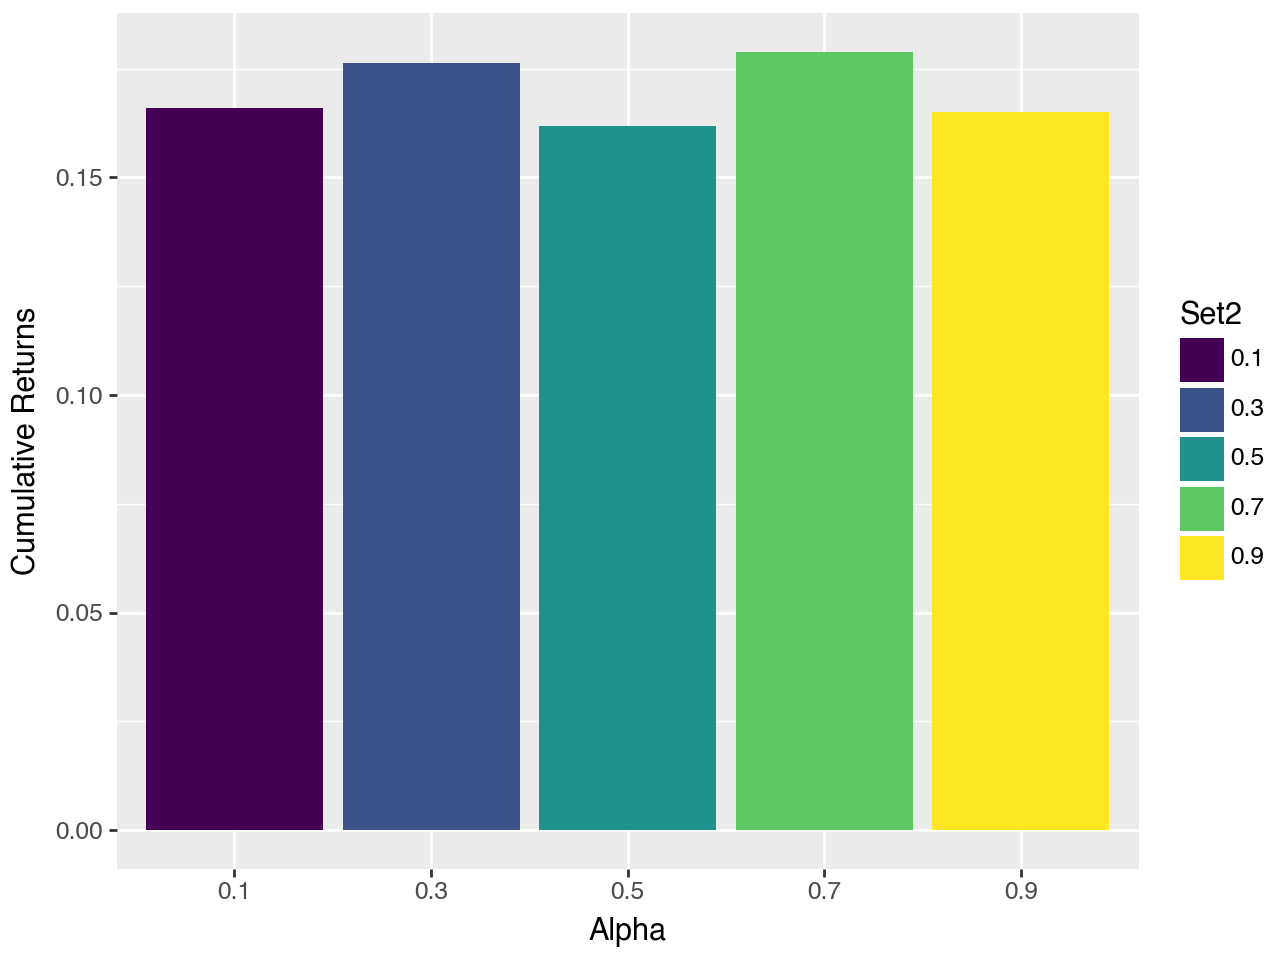

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_APD_barplot.pdf


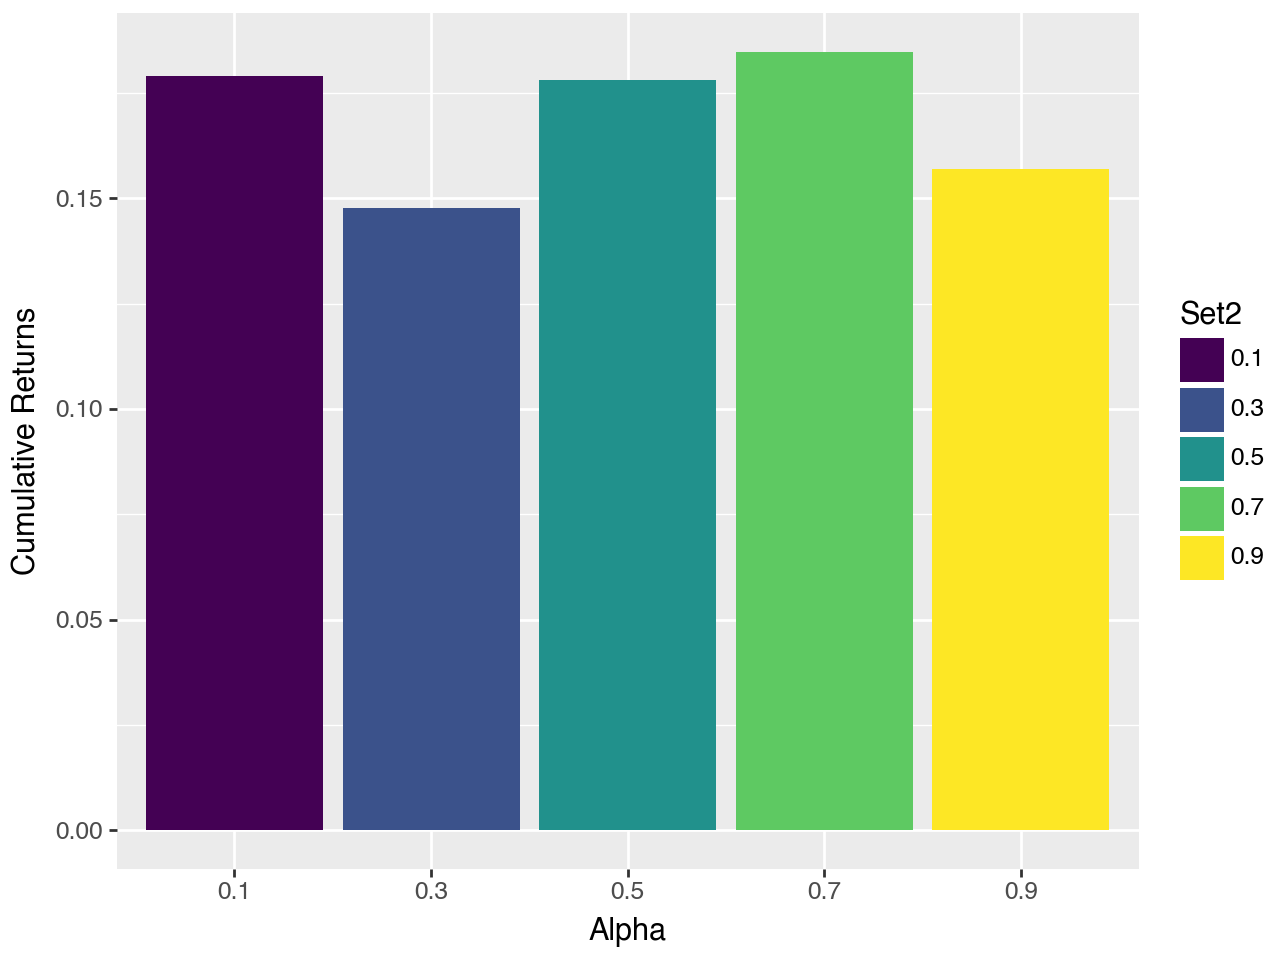

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_AVGO_barplot.pdf


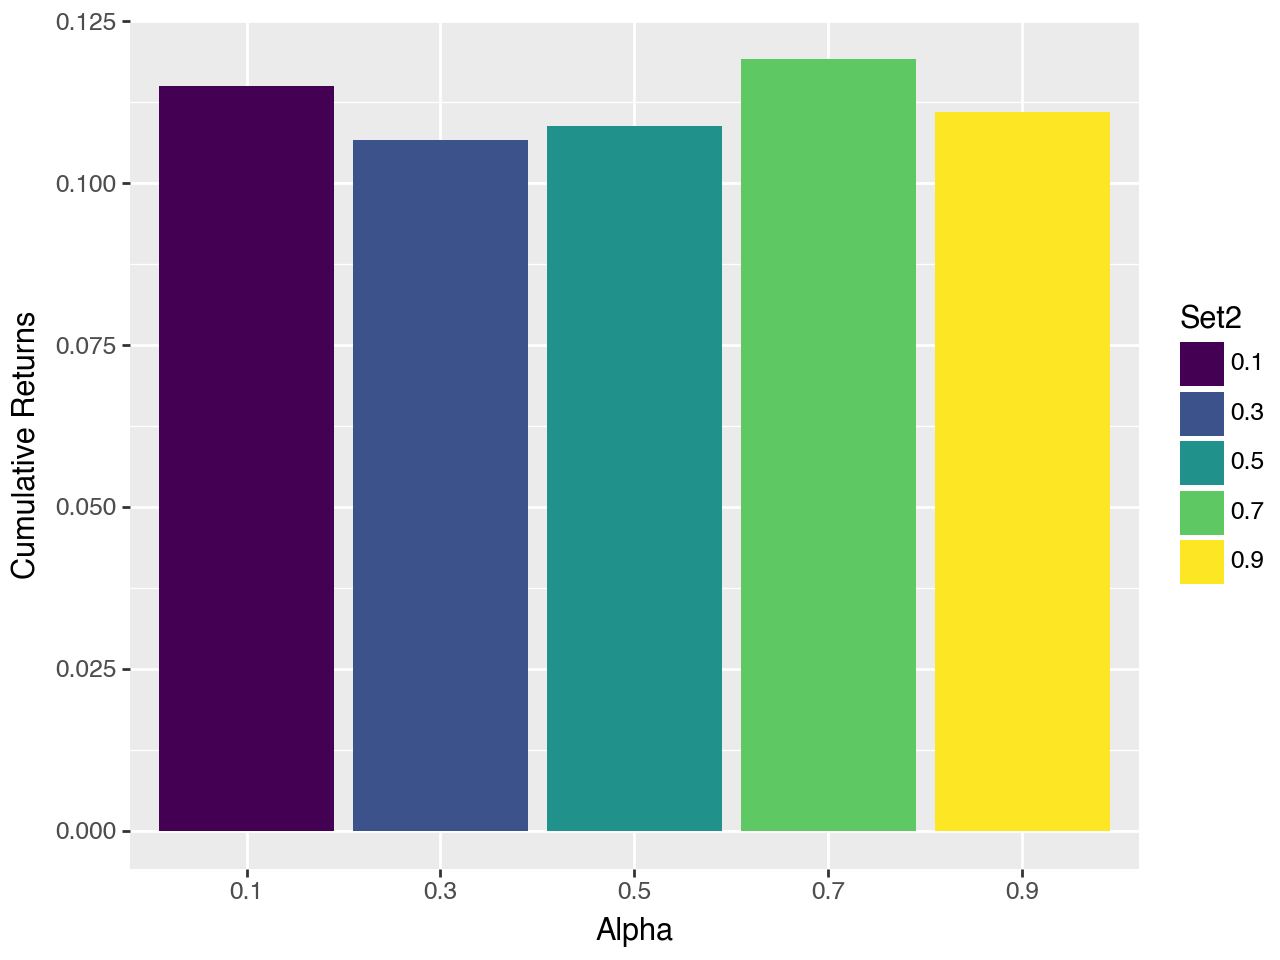

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_AWK_barplot.pdf


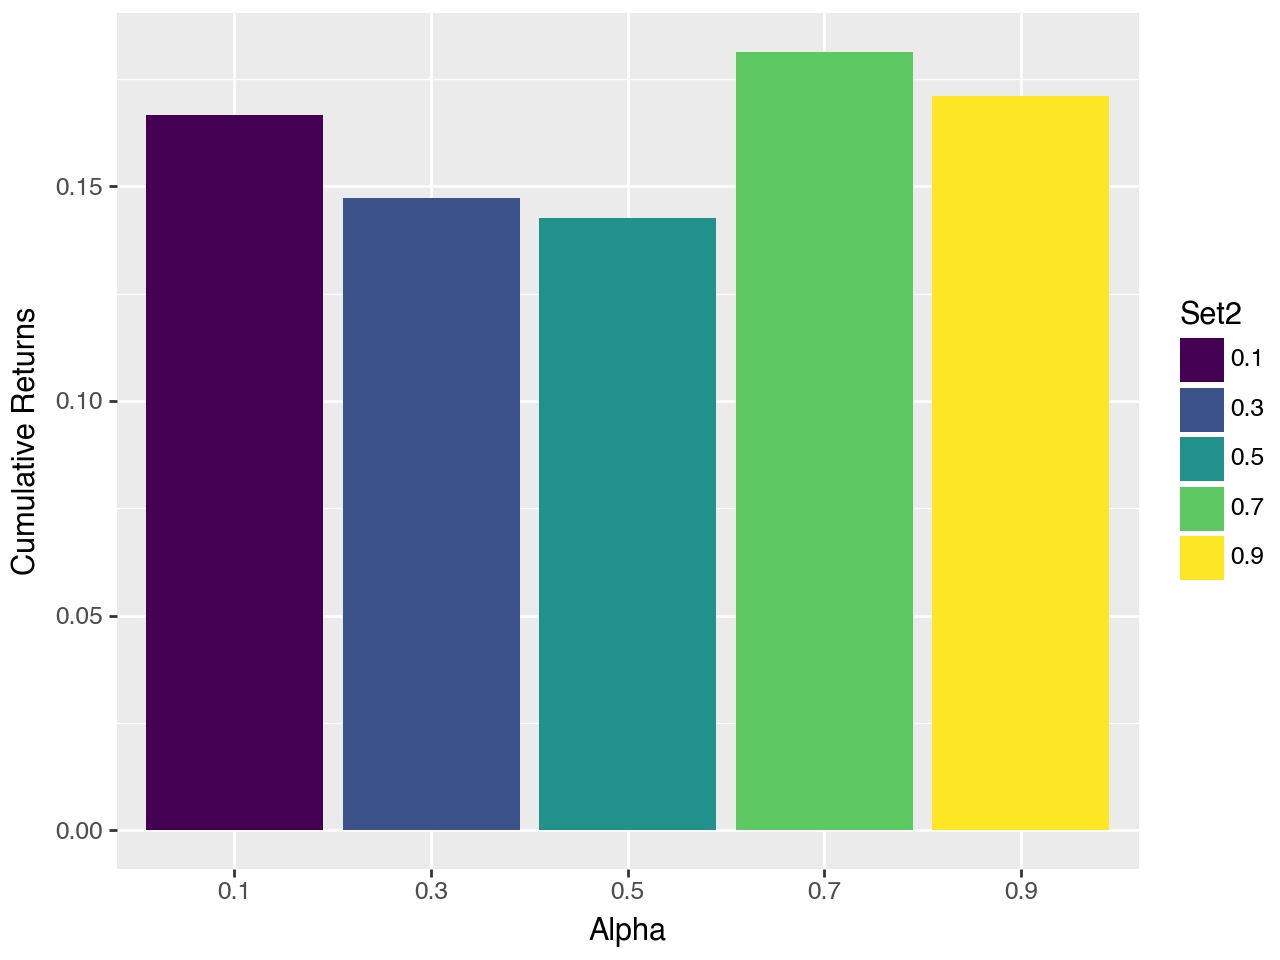

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_BA_barplot.pdf


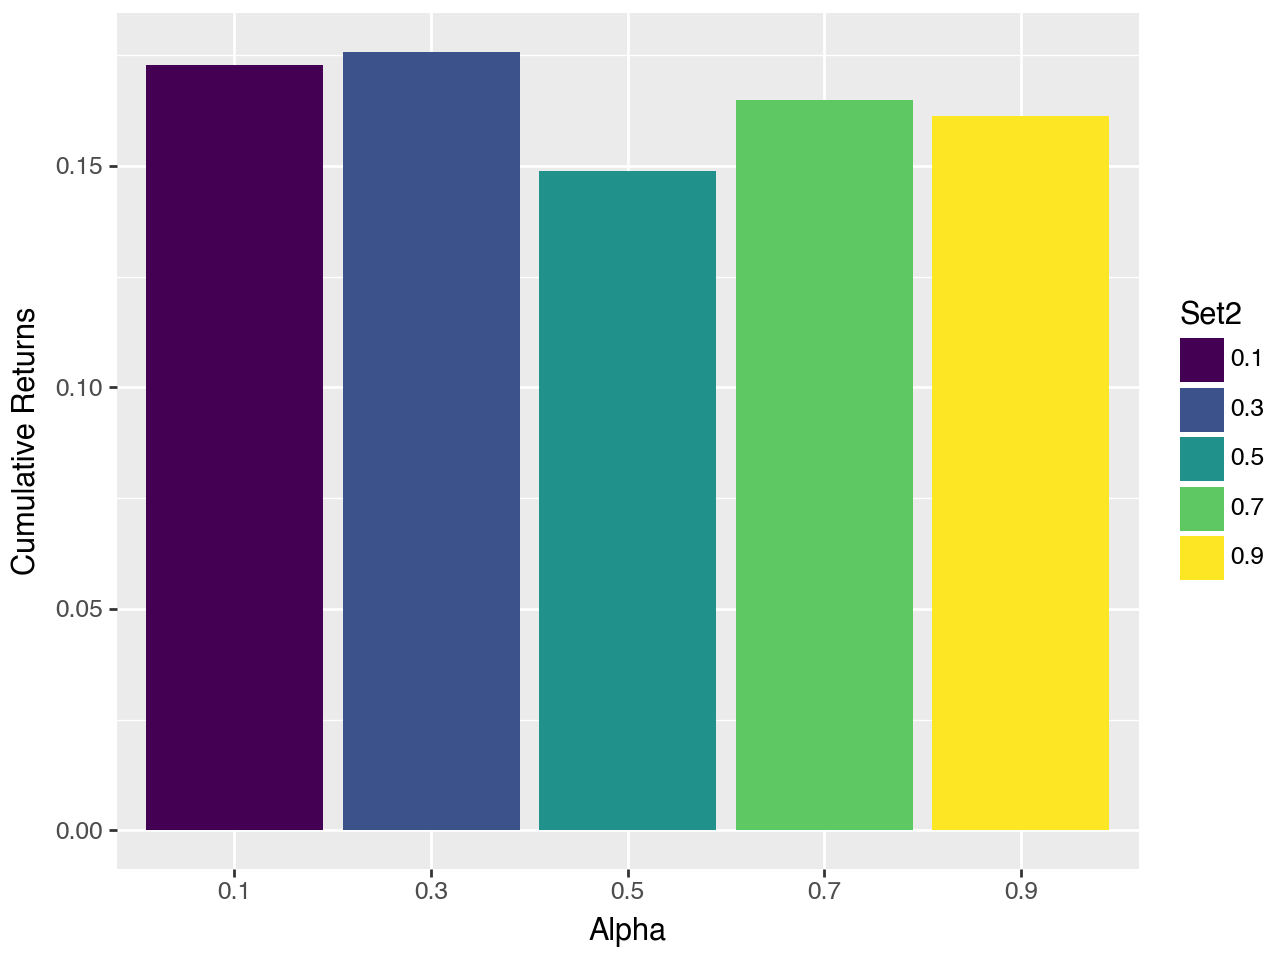

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_BAC_barplot.pdf


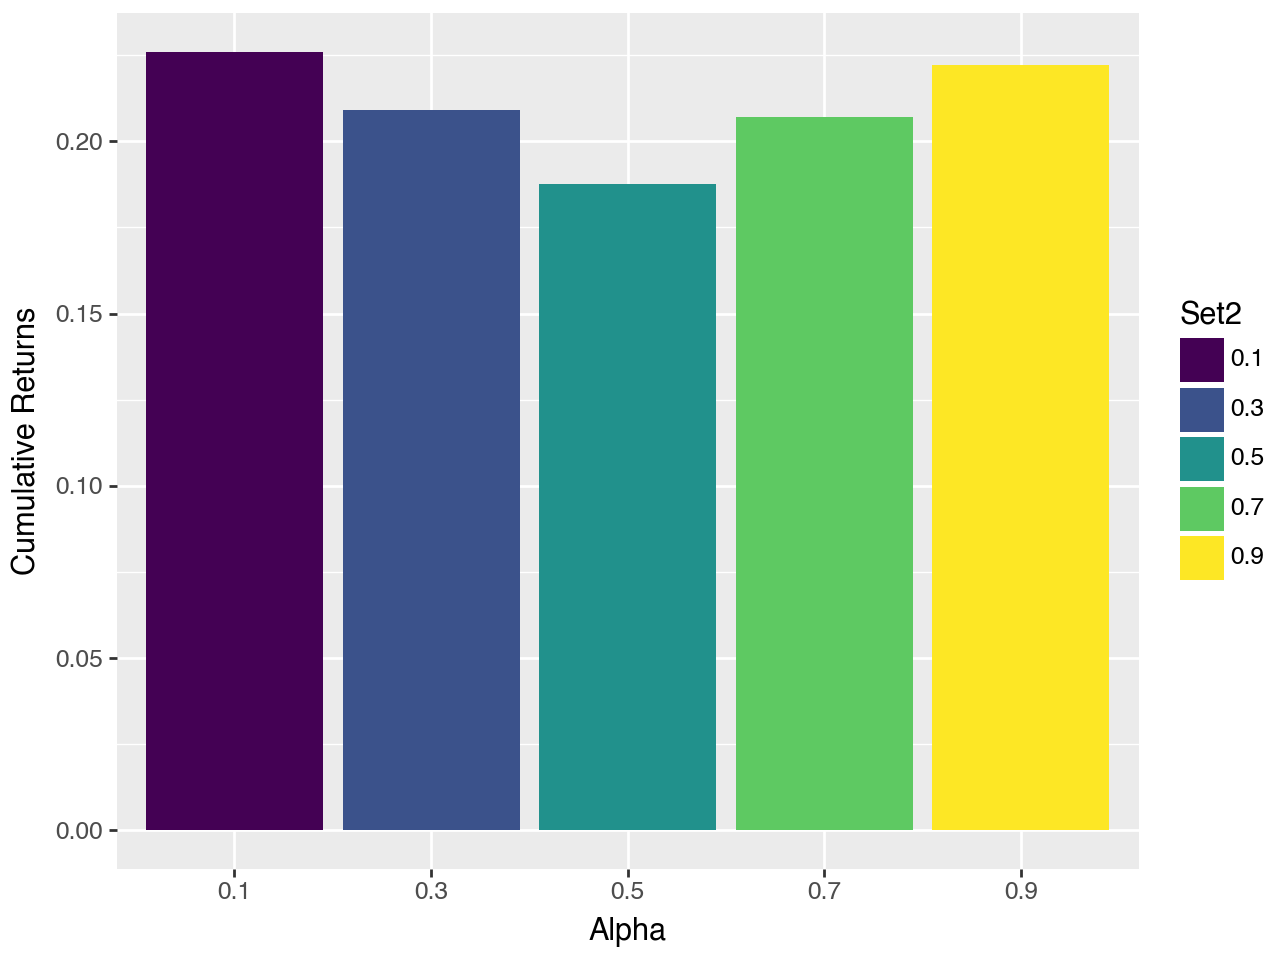

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_BBL_barplot.pdf


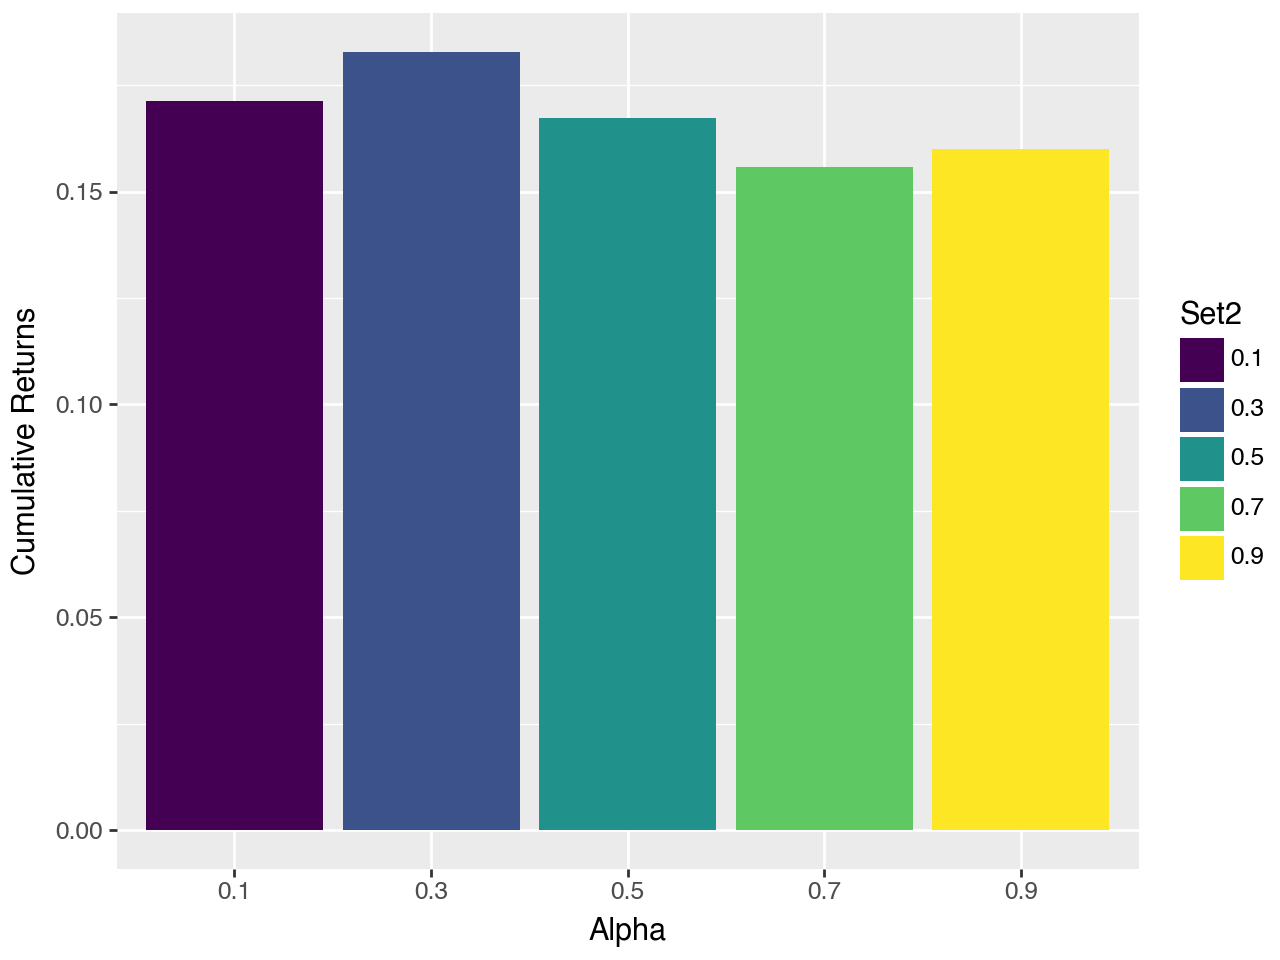

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_BHP_barplot.pdf


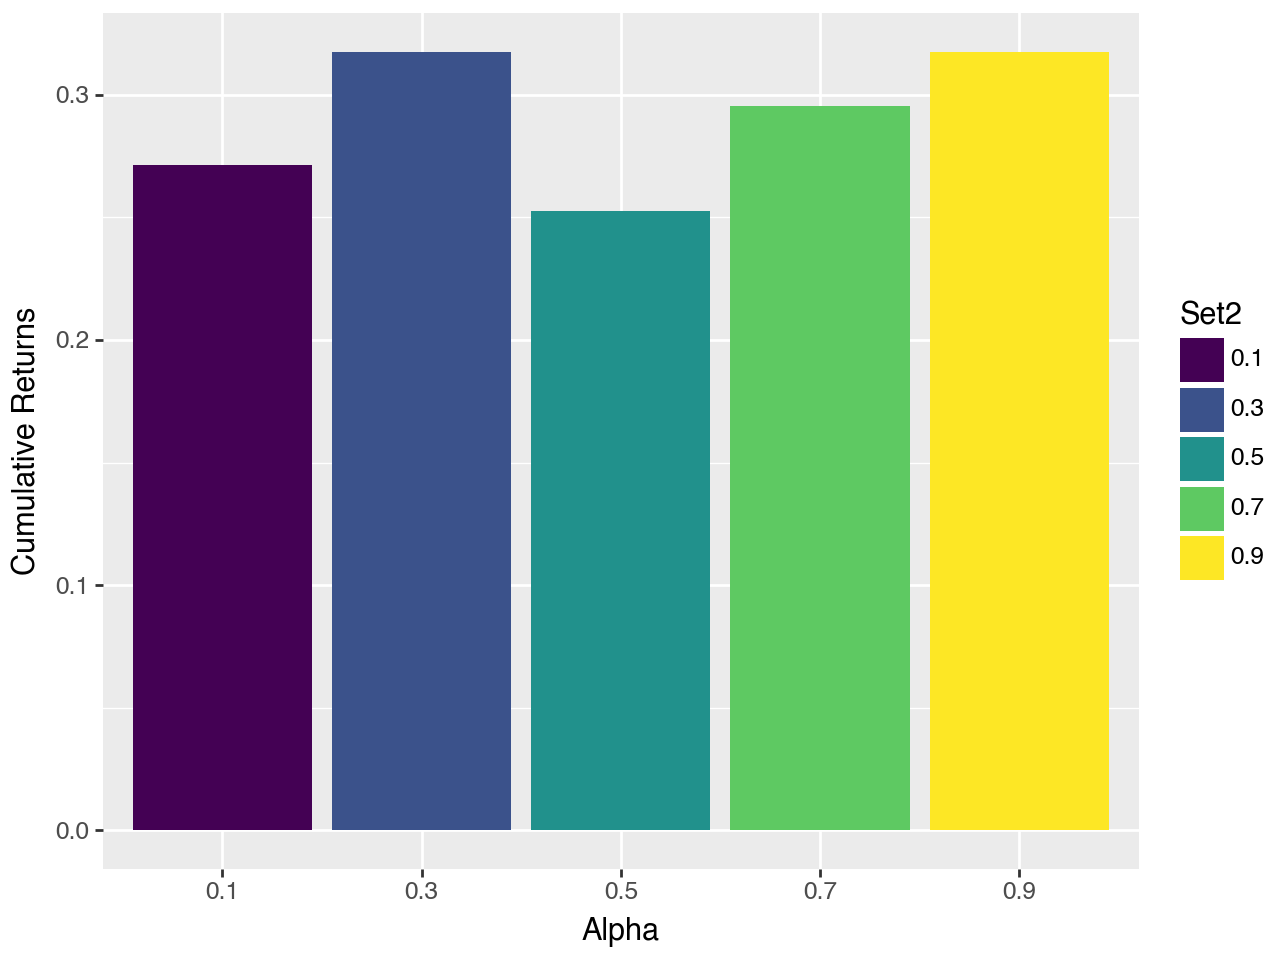

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_BP_barplot.pdf


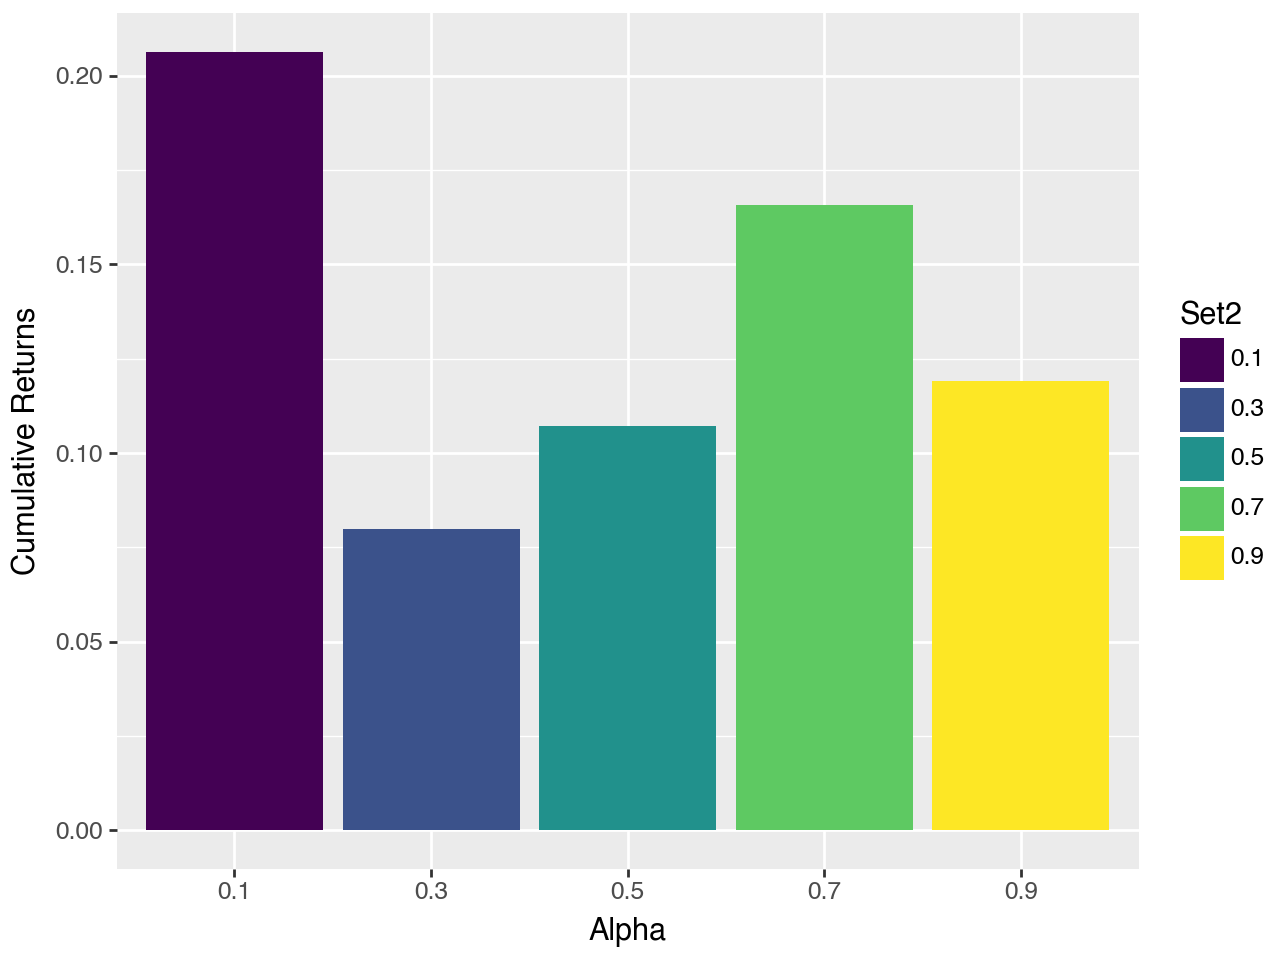

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_BRK-A_barplot.pdf


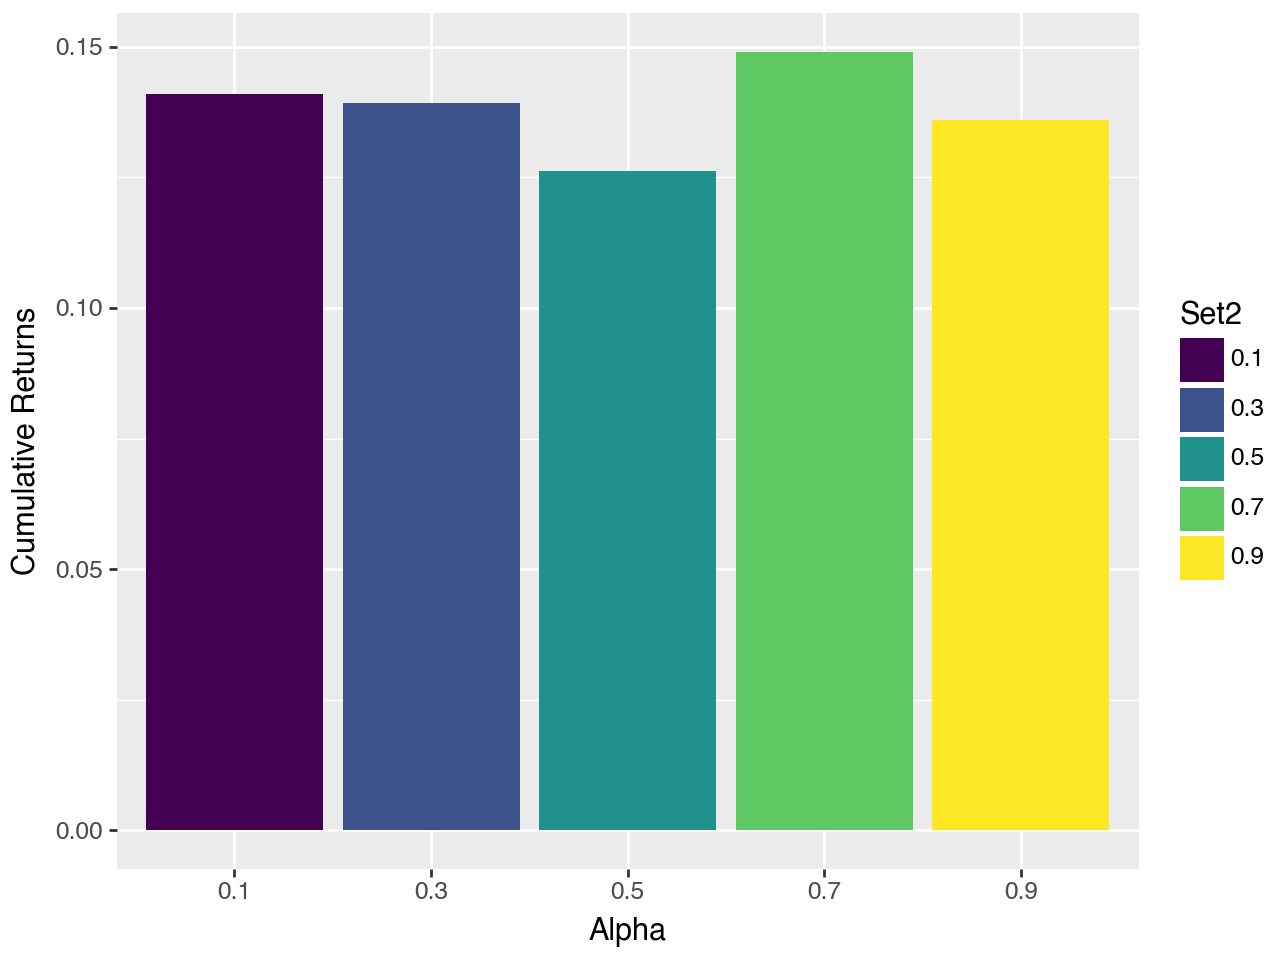

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_CCI_barplot.pdf


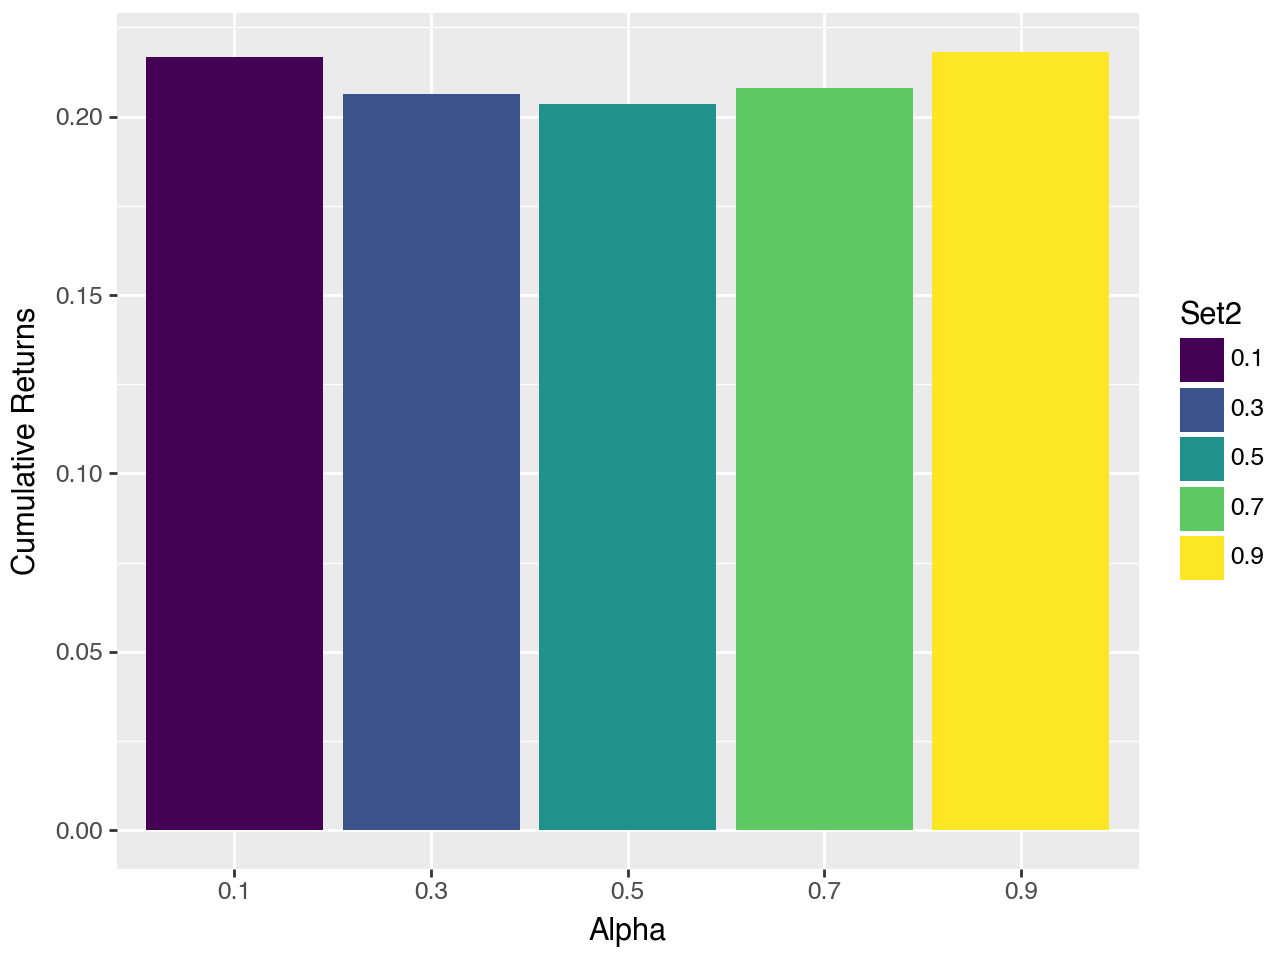

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_CHTR_barplot.pdf


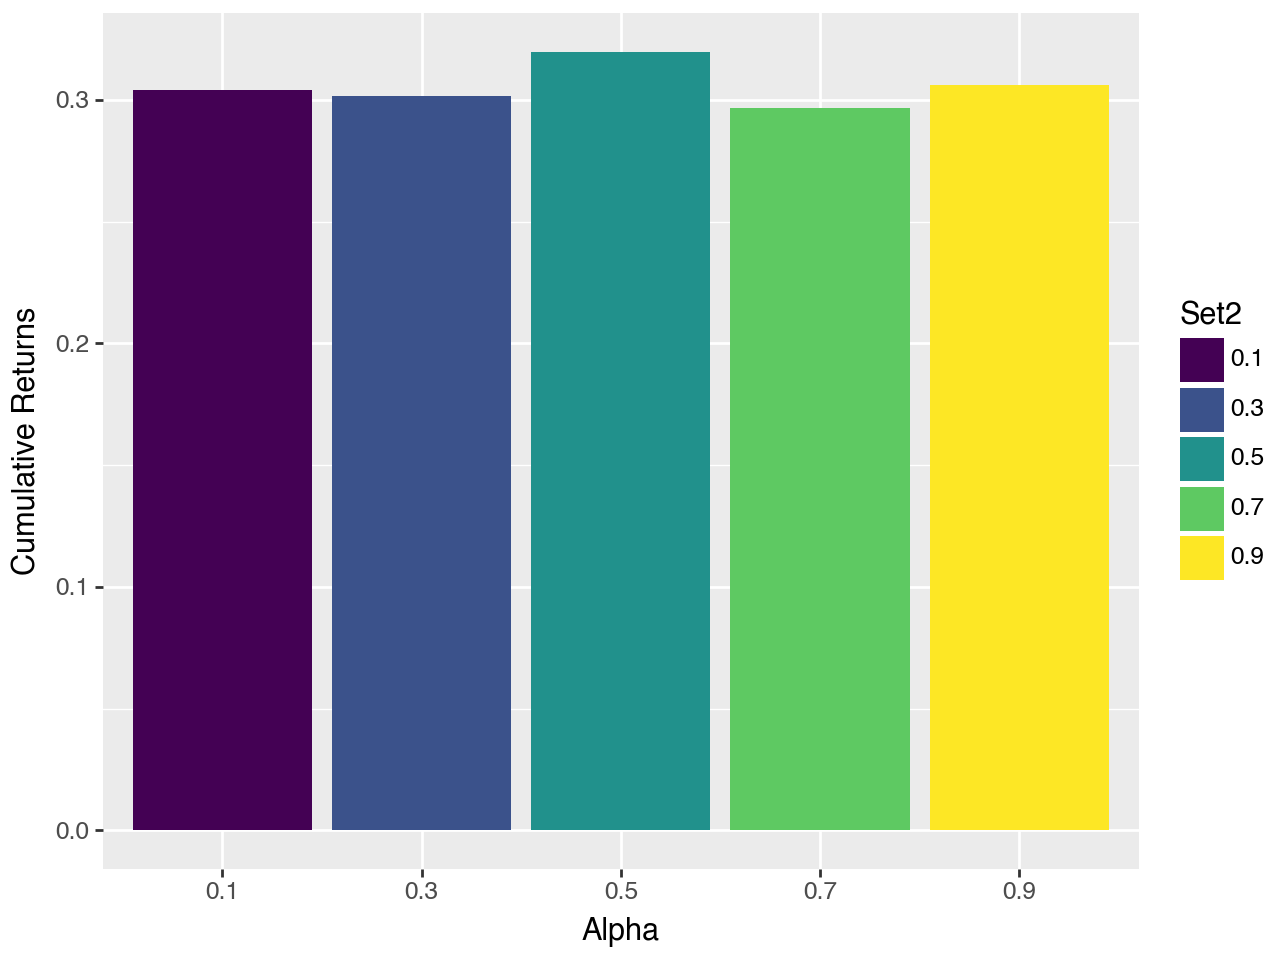

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_COP_barplot.pdf


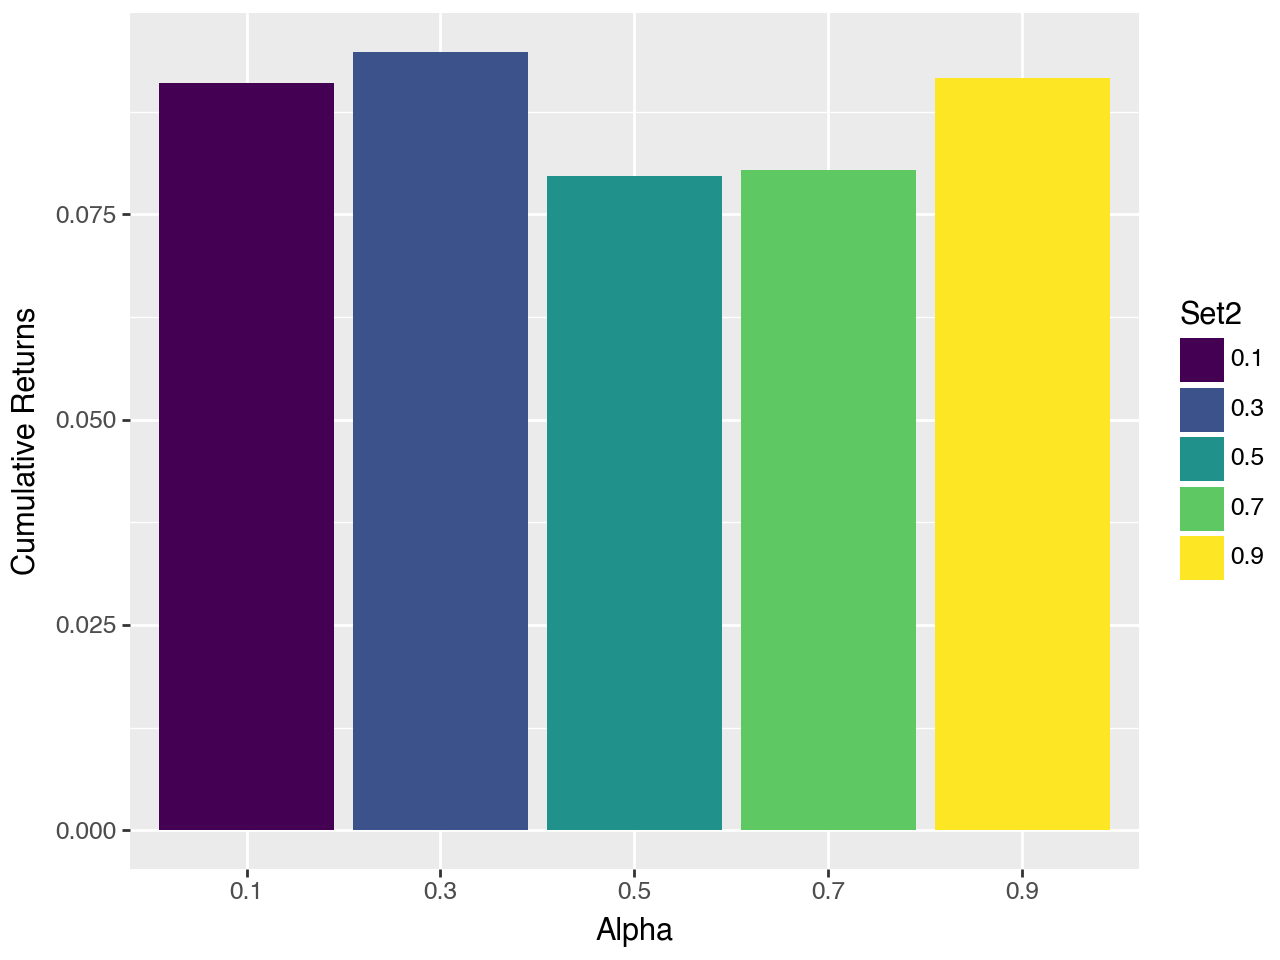

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_COST_barplot.pdf


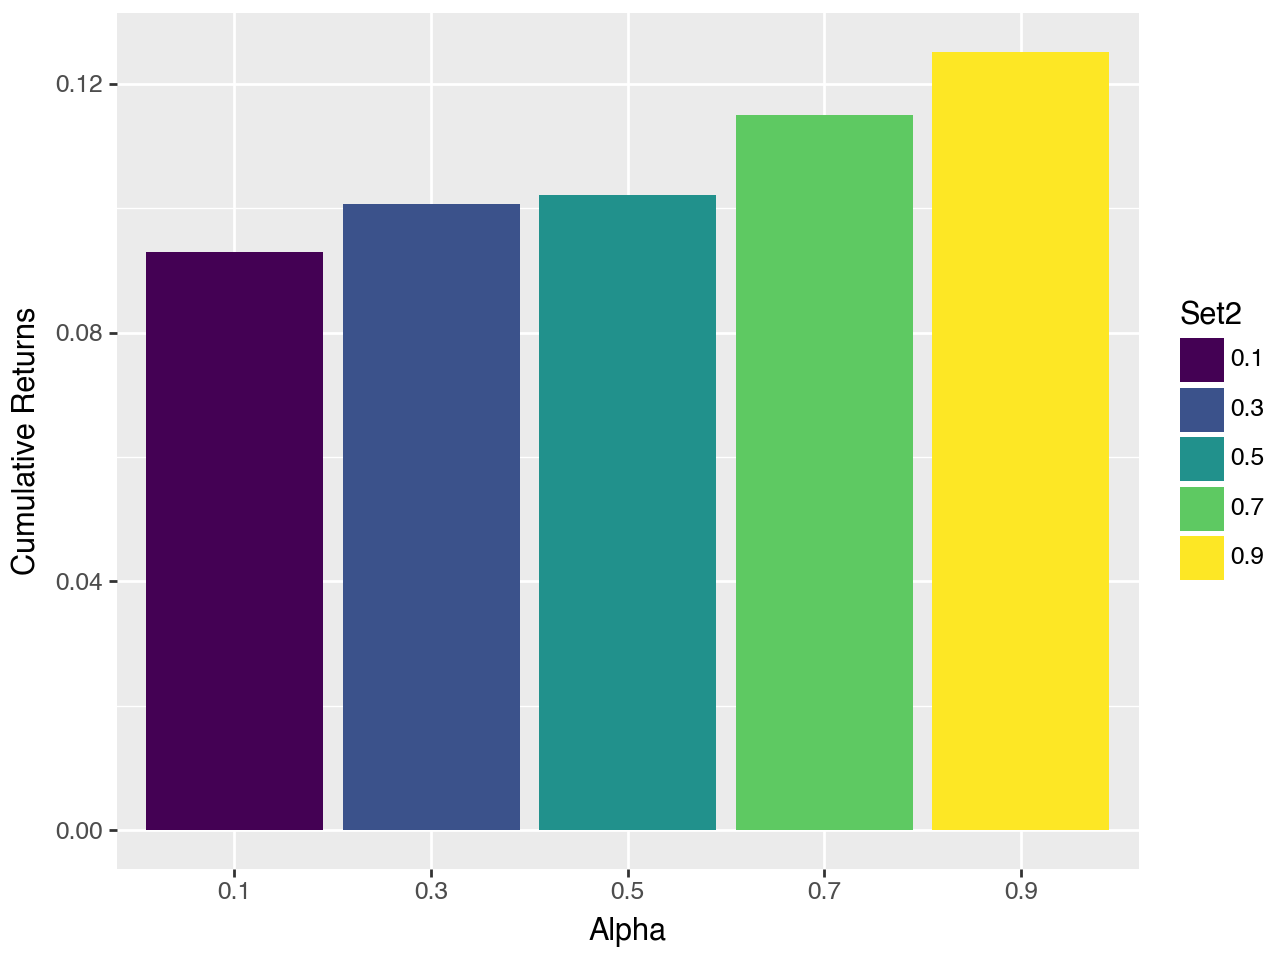

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_CSCO_barplot.pdf


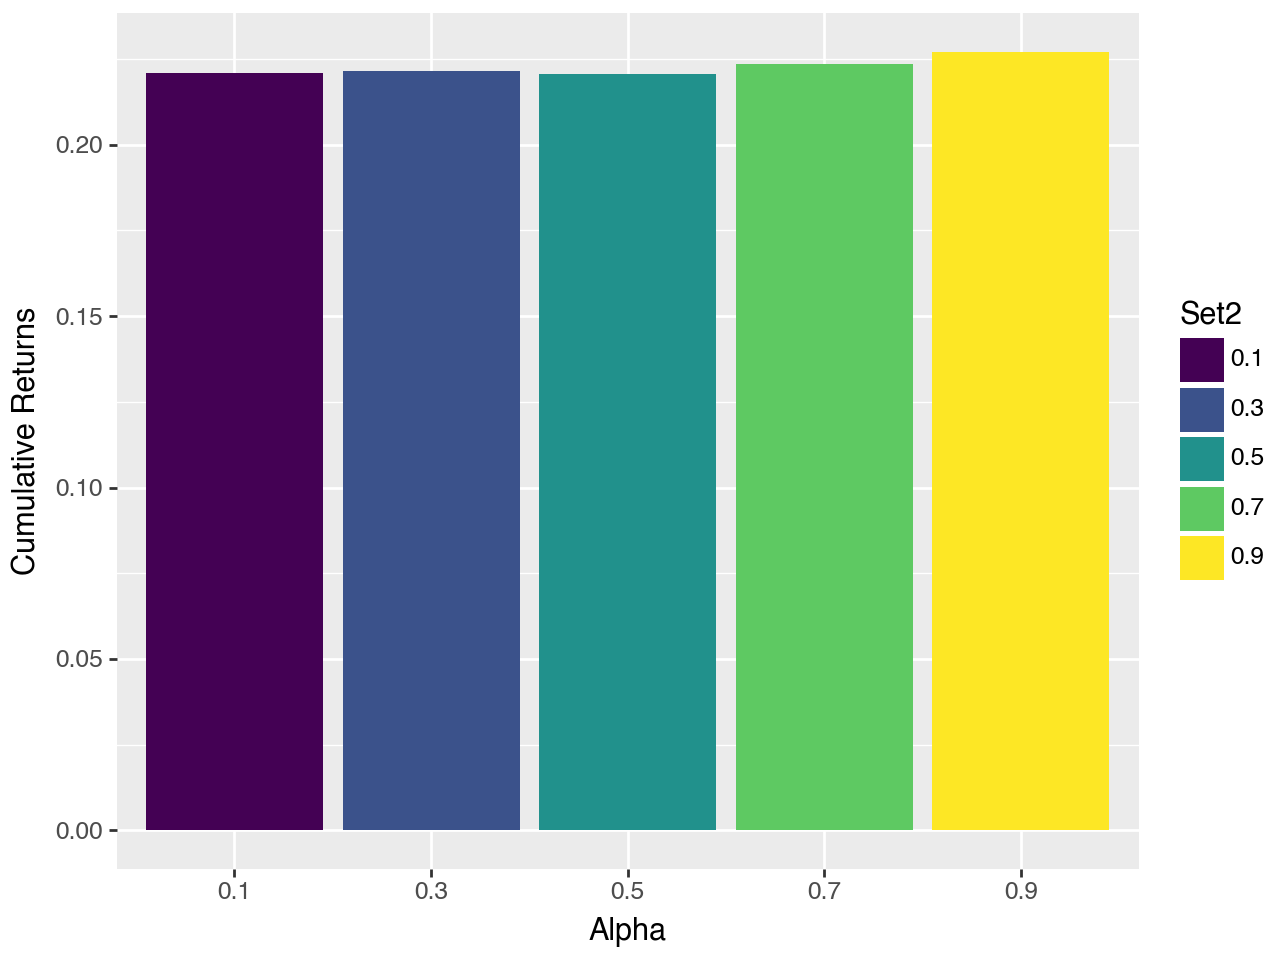

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_CVX_barplot.pdf


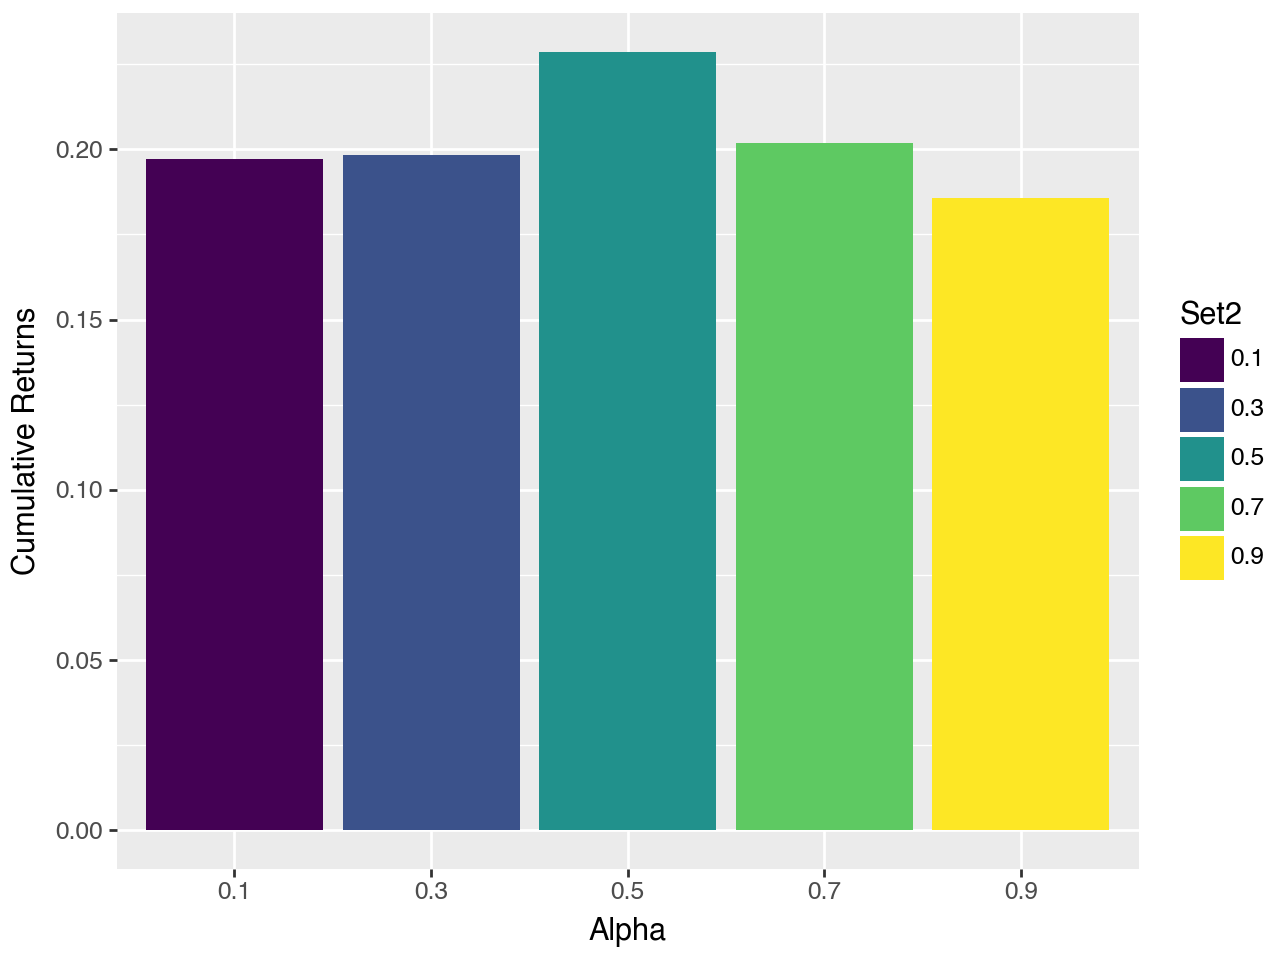

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_DE_barplot.pdf


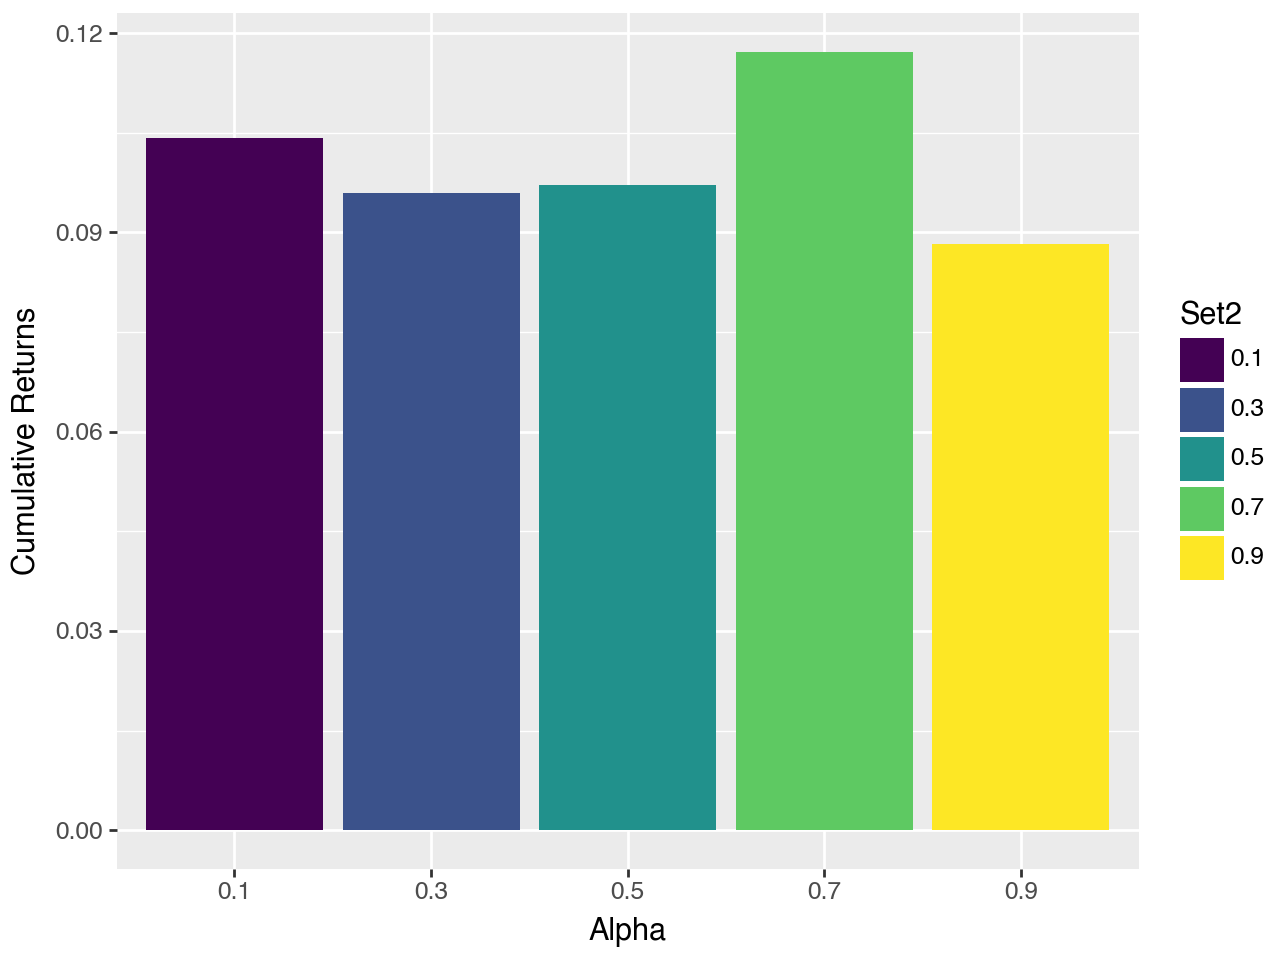

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_DEO_barplot.pdf


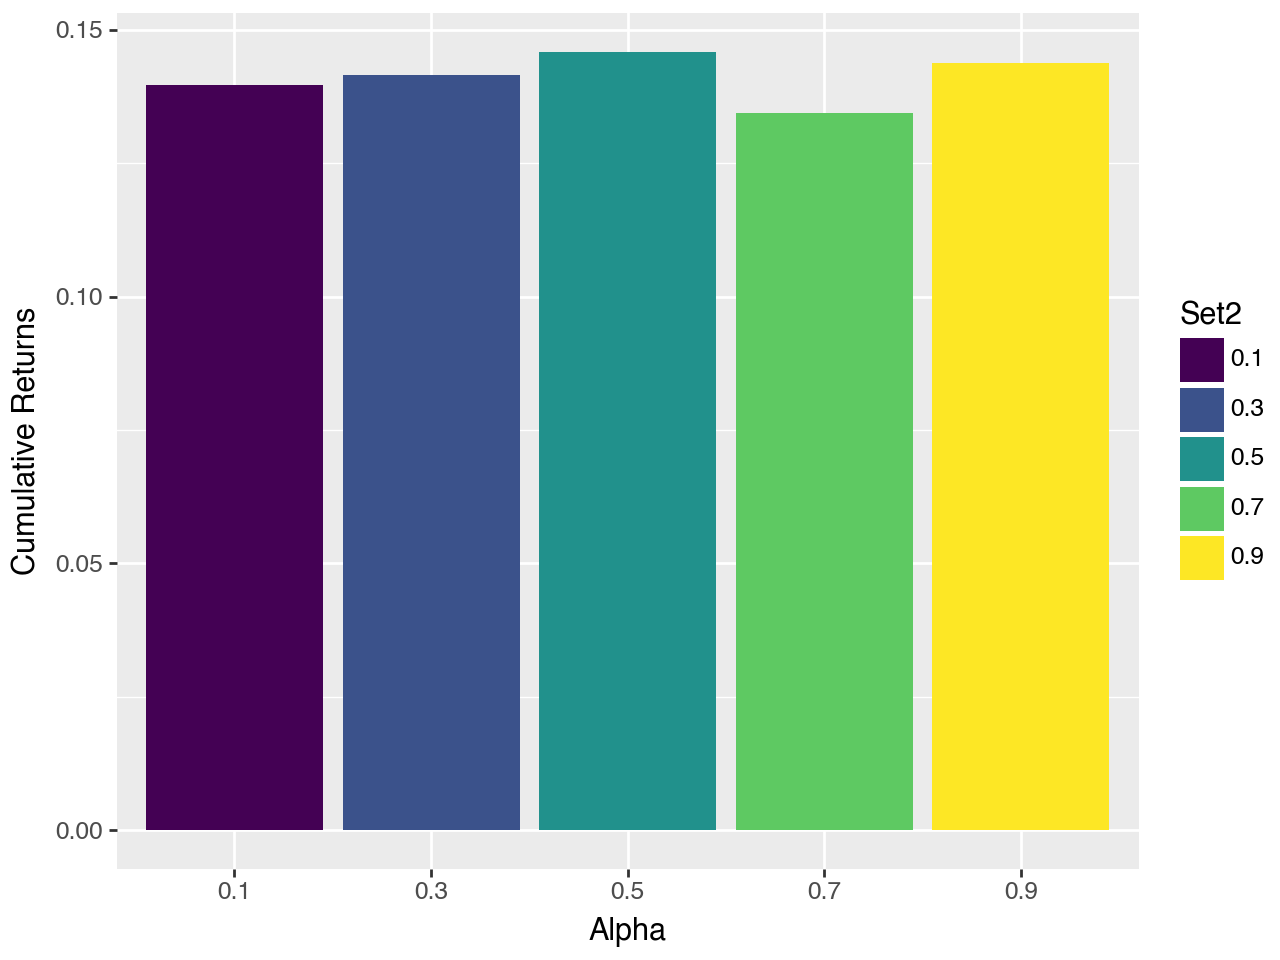

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_DHR_barplot.pdf


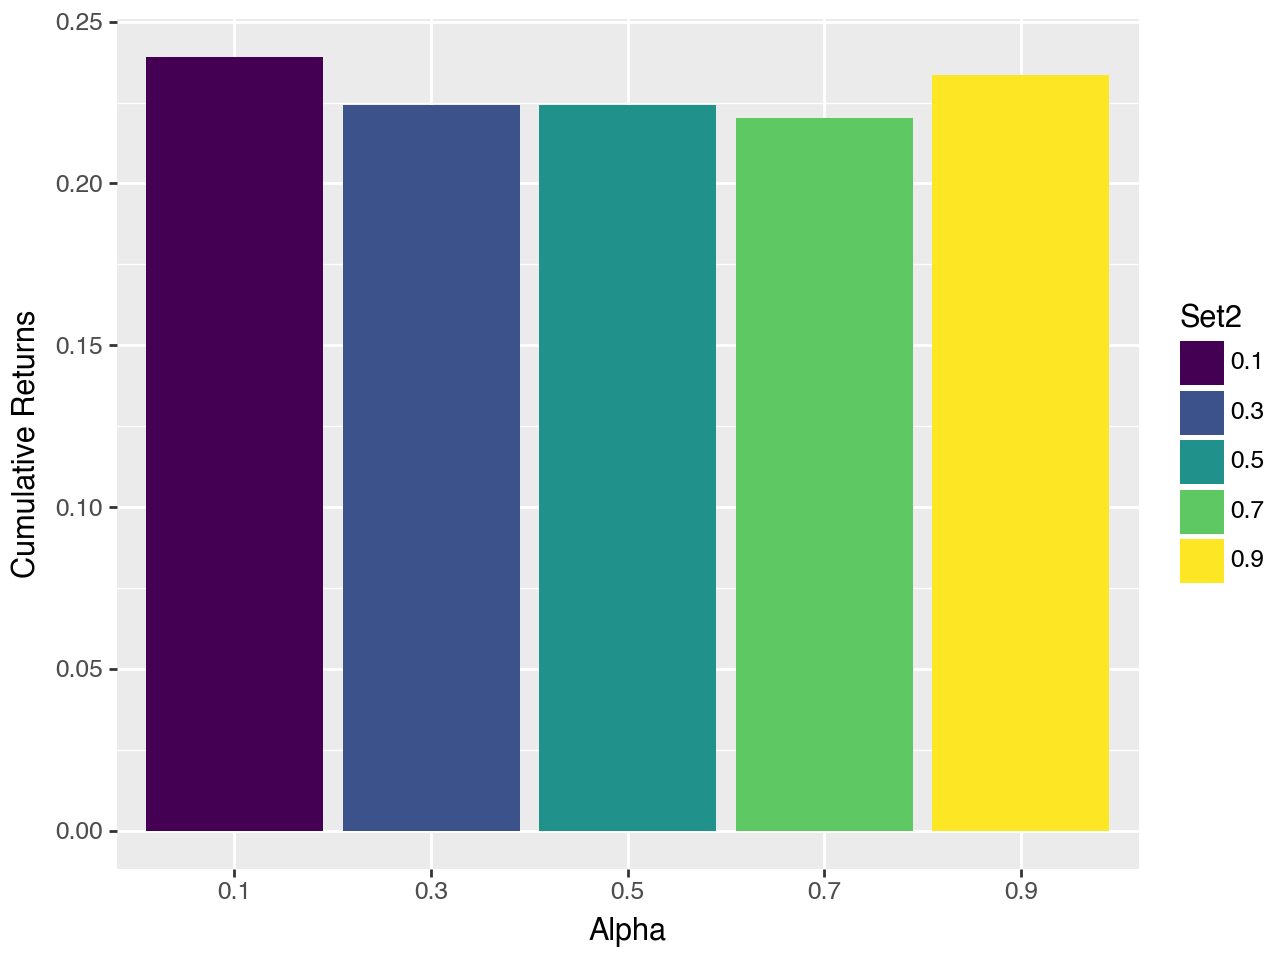

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_DLR_barplot.pdf


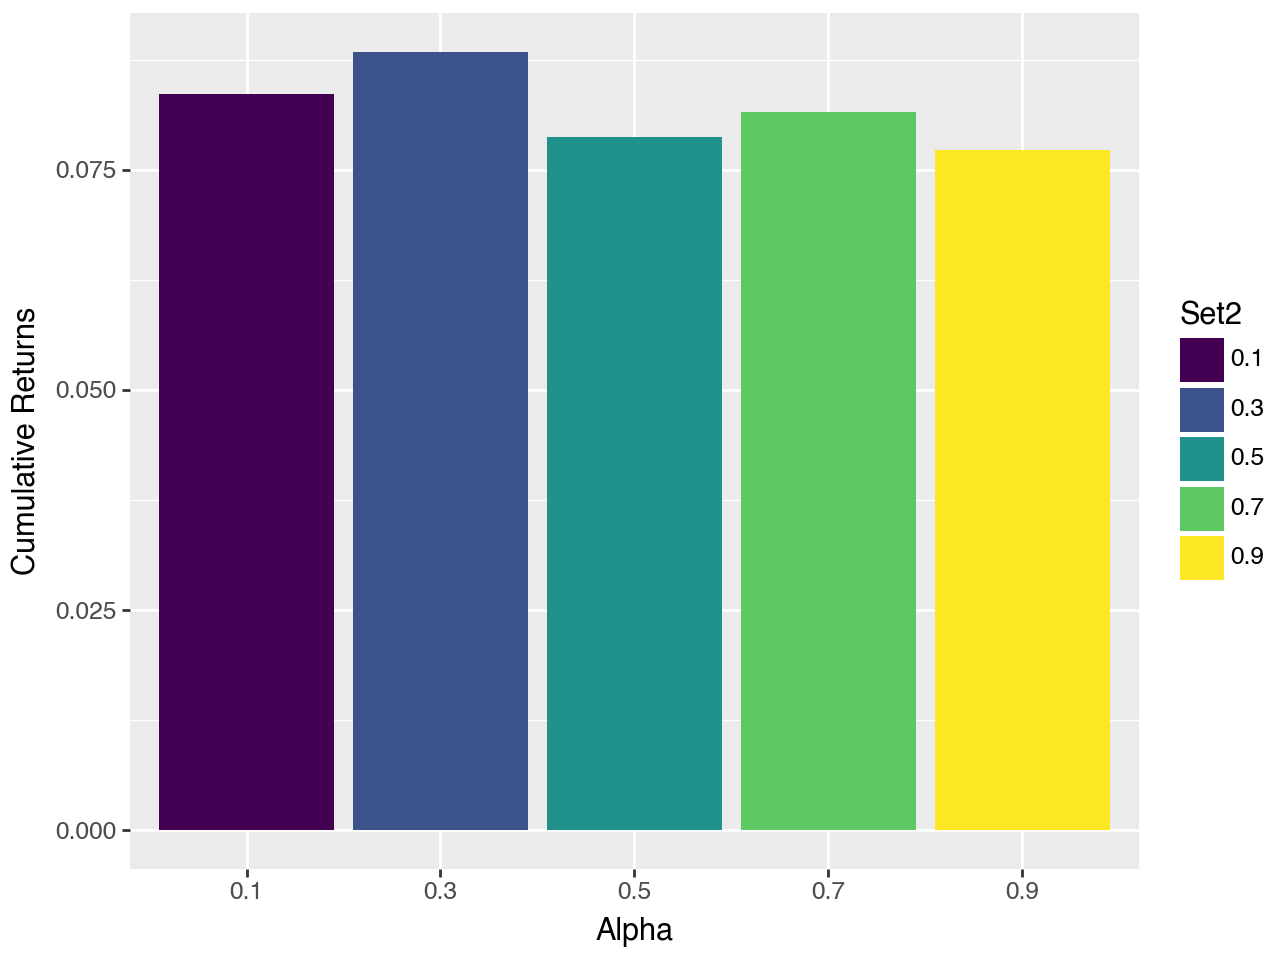

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_DUK_barplot.pdf


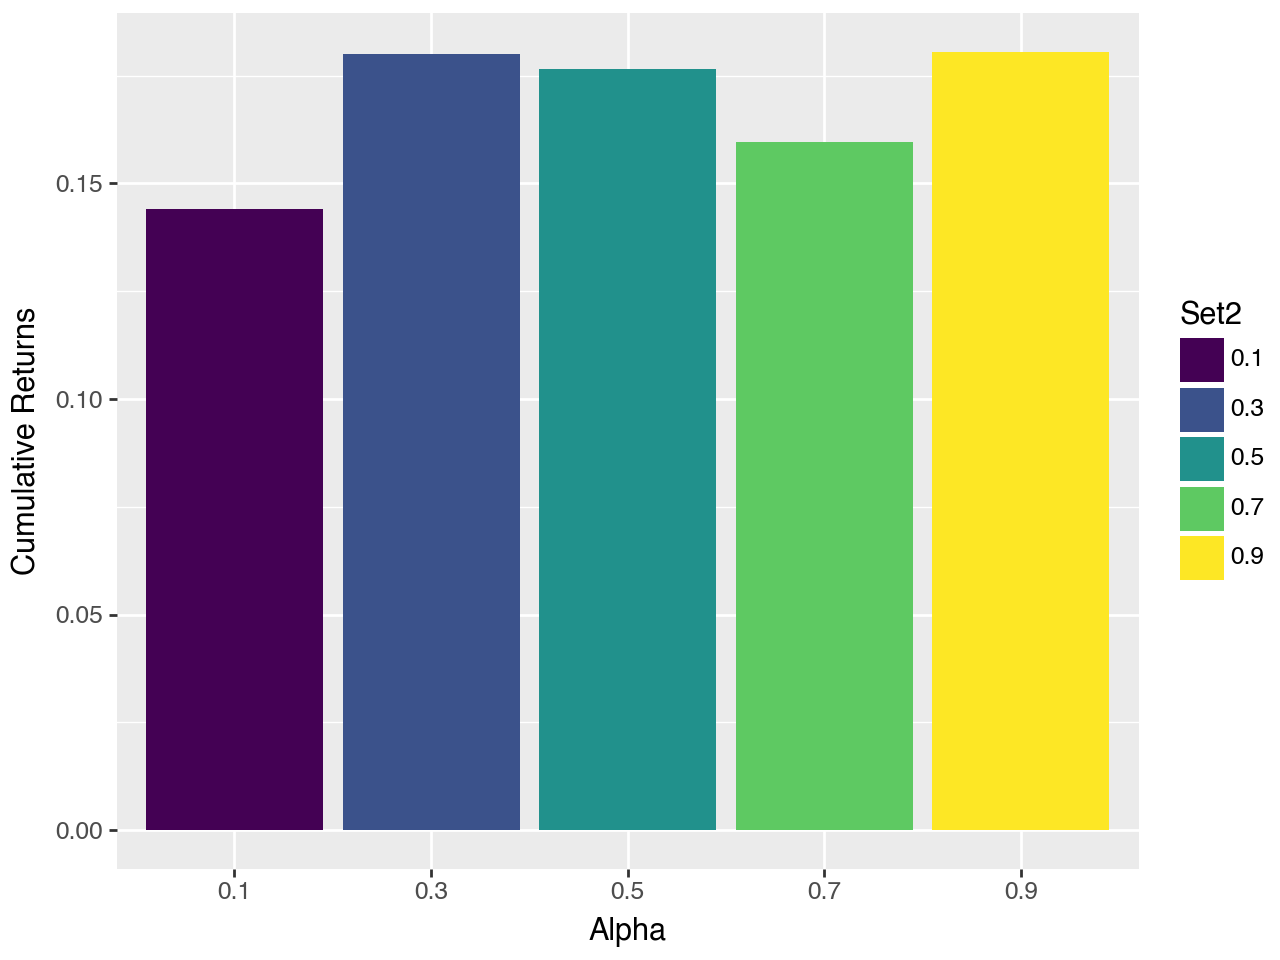

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_ECL_barplot.pdf


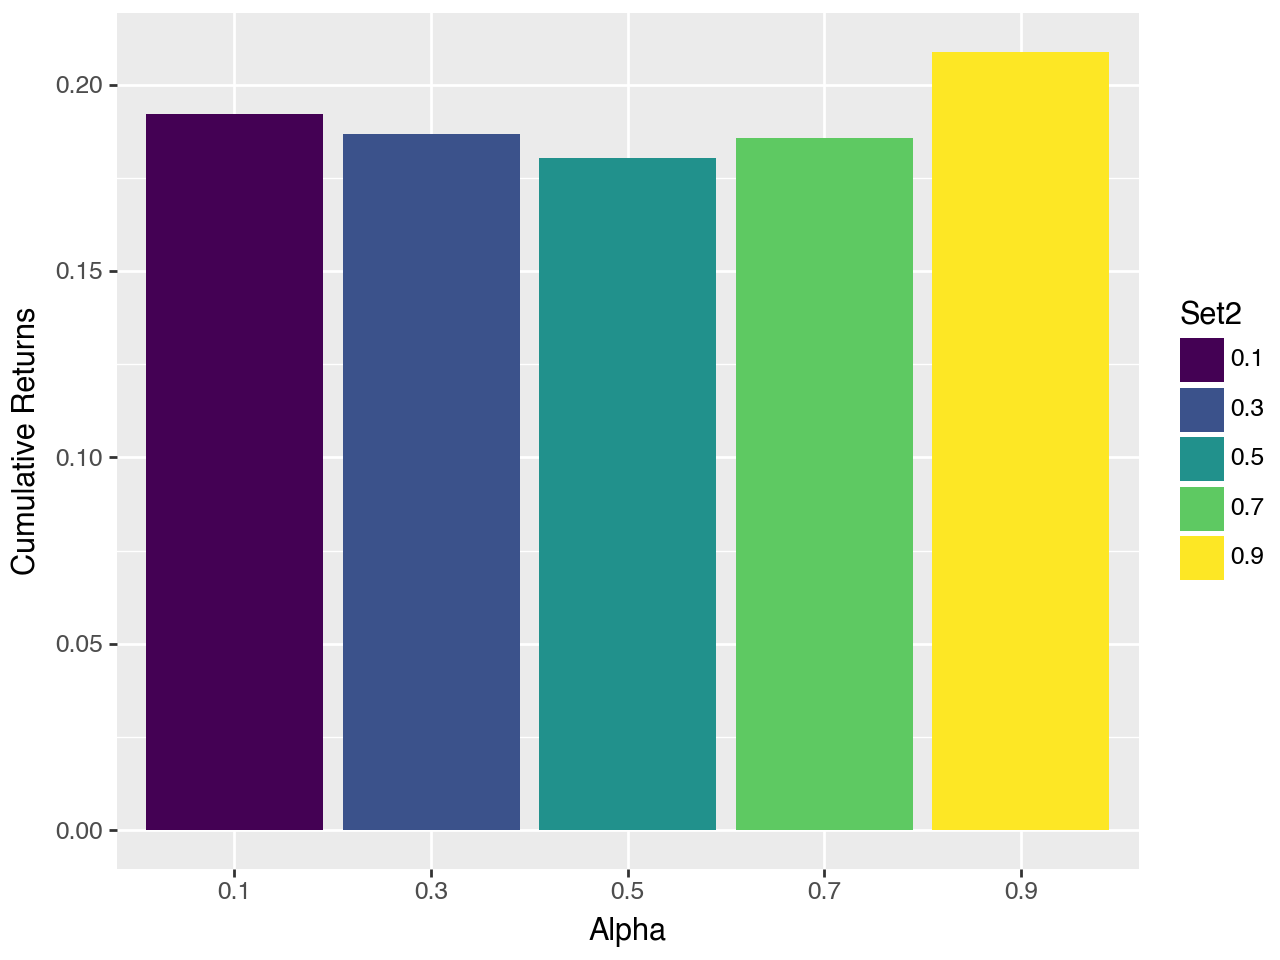

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_EL_barplot.pdf


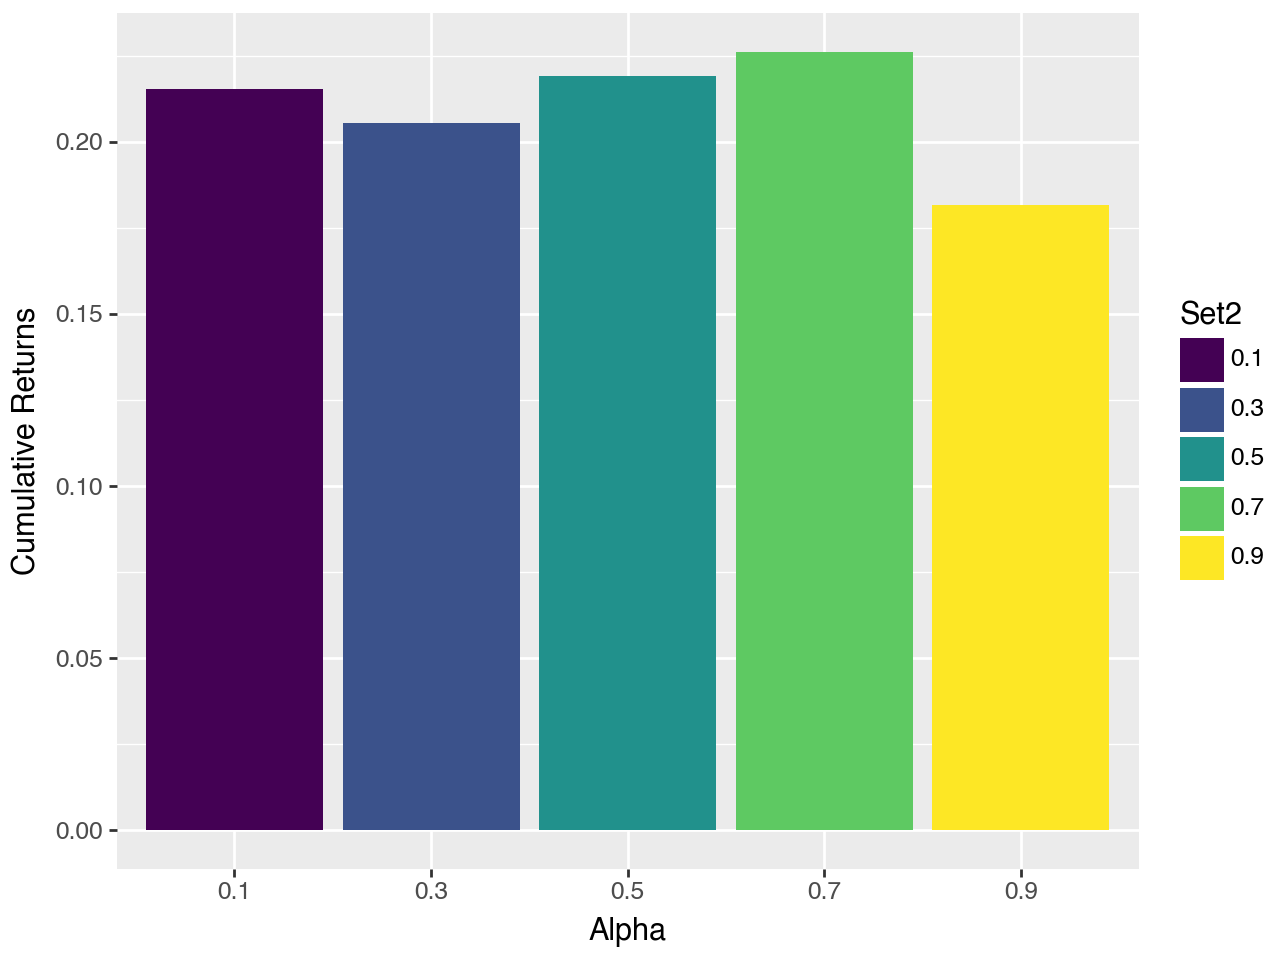

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_EQIX_barplot.pdf


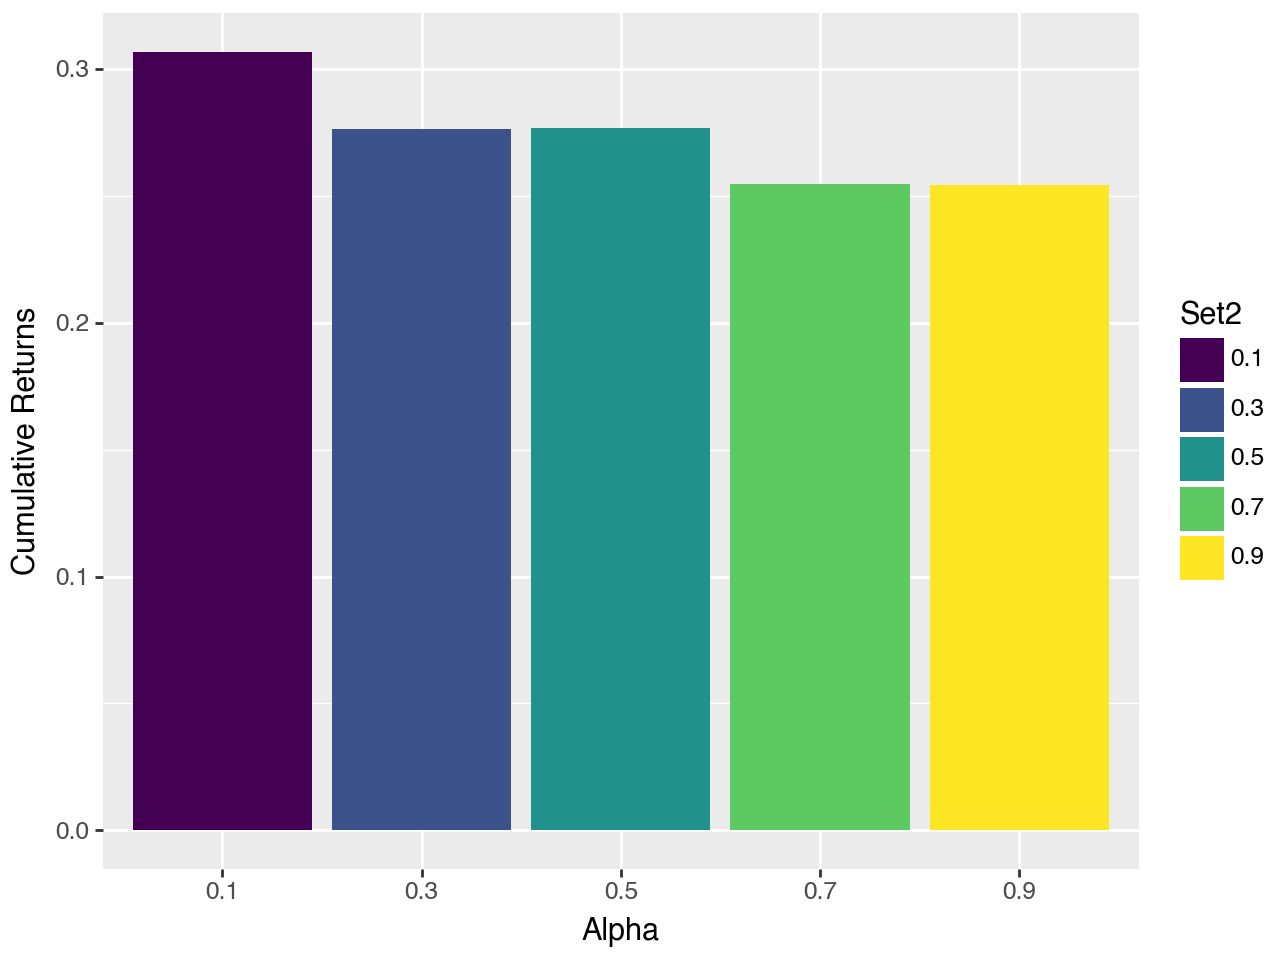

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_EQNR_barplot.pdf


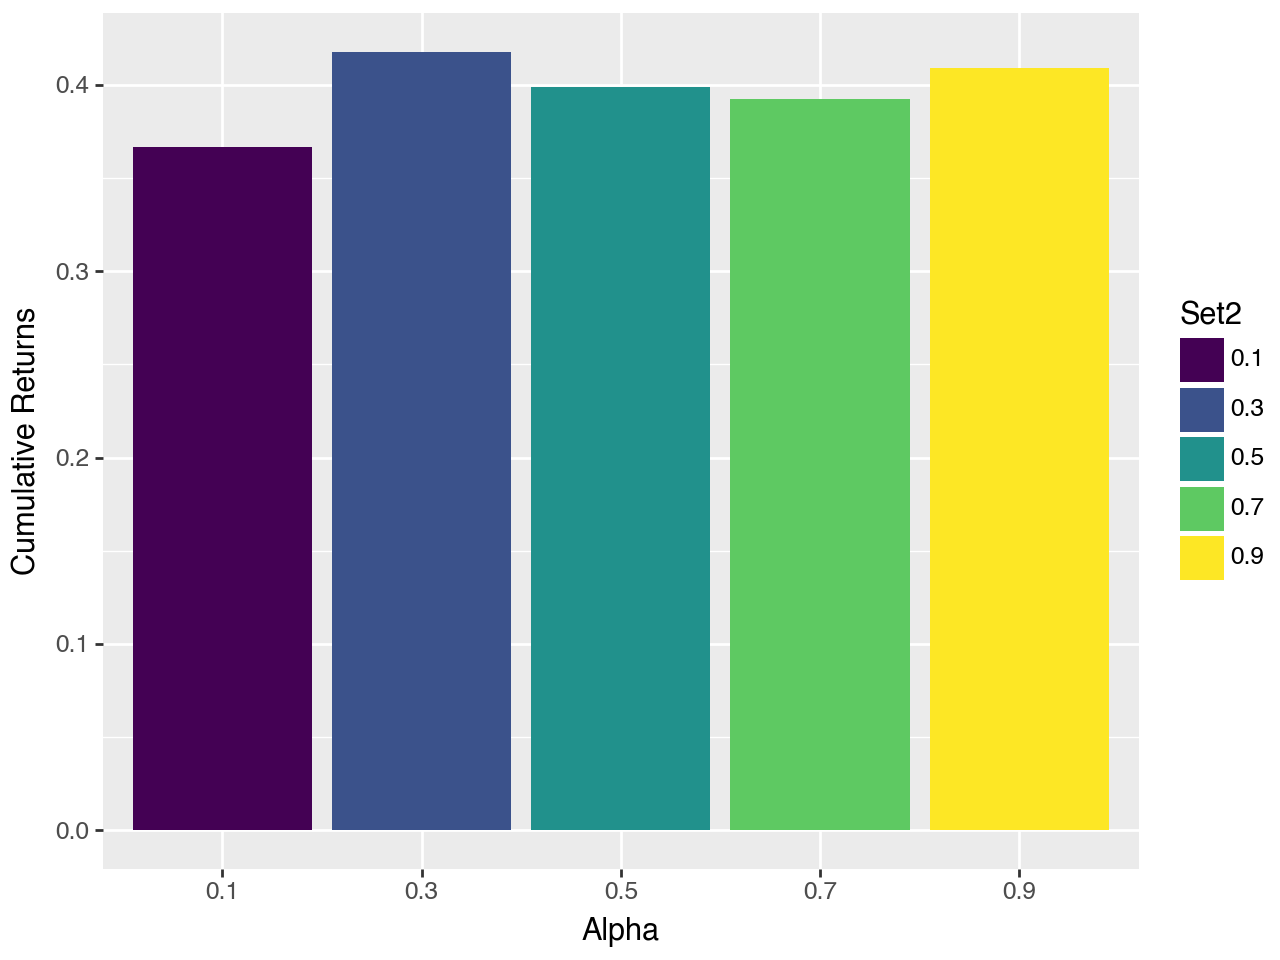

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_FCX_barplot.pdf


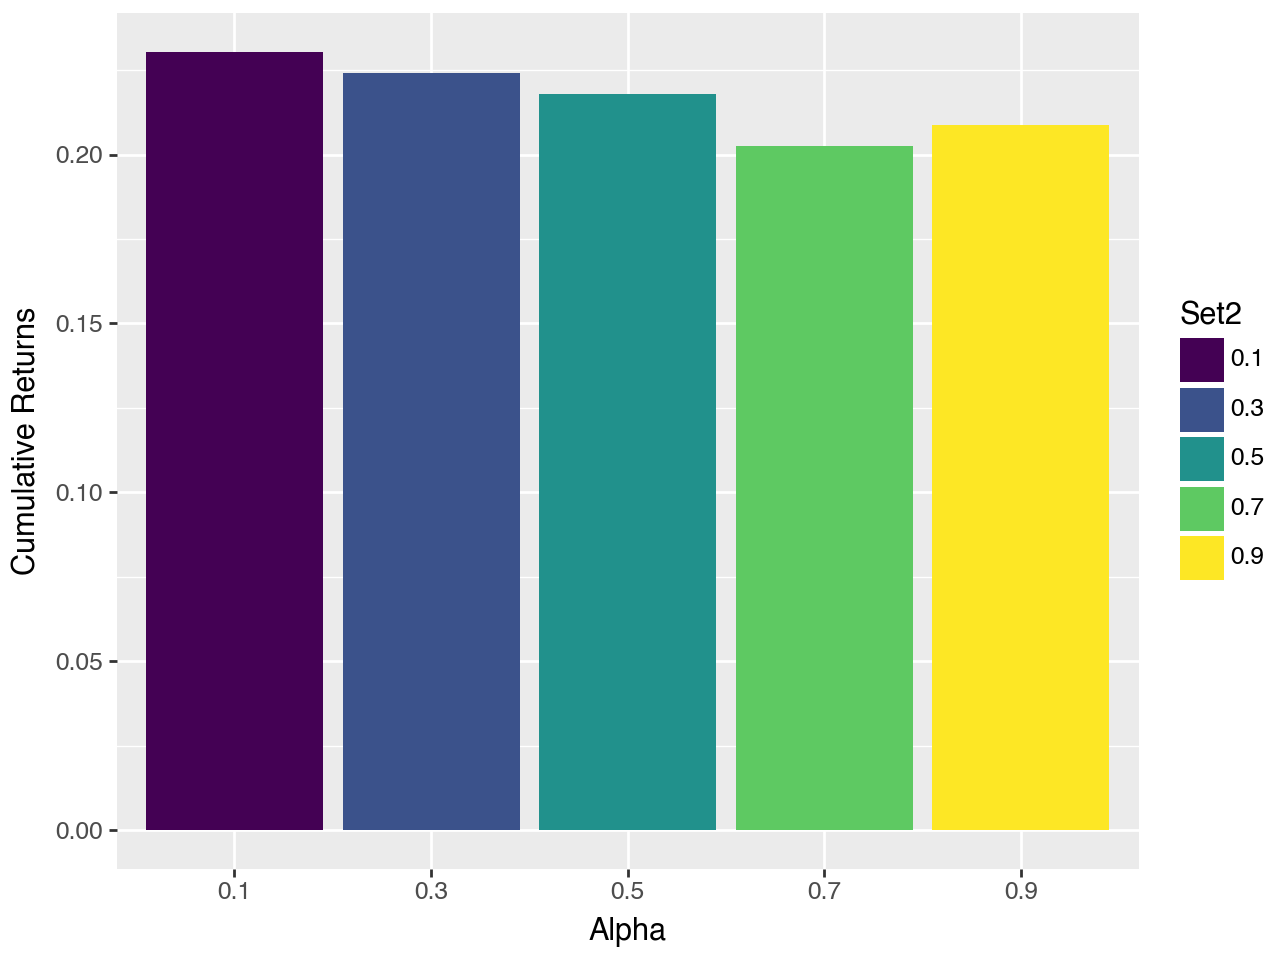

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_GE_barplot.pdf


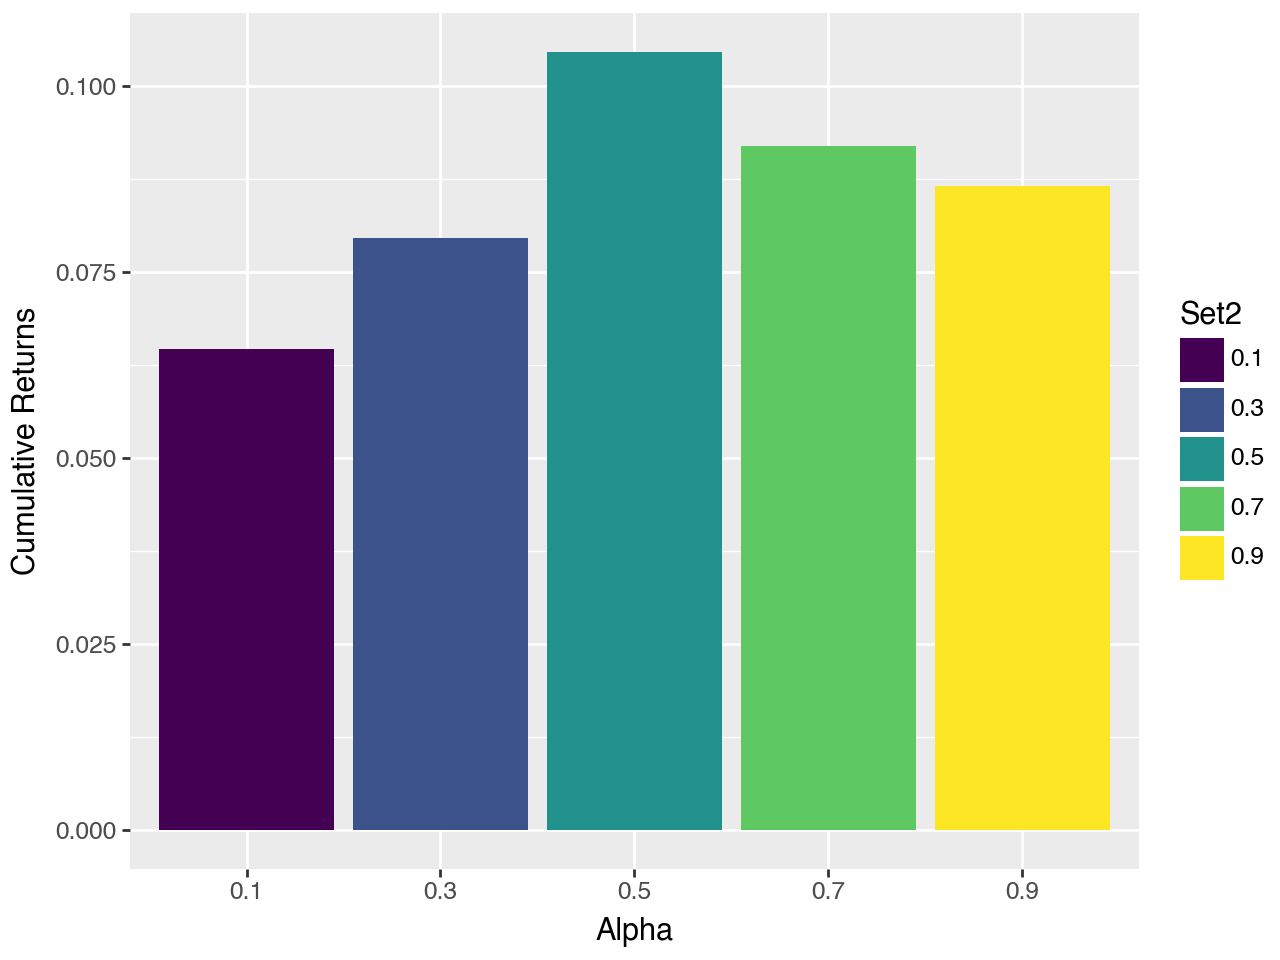

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_GOOG_barplot.pdf


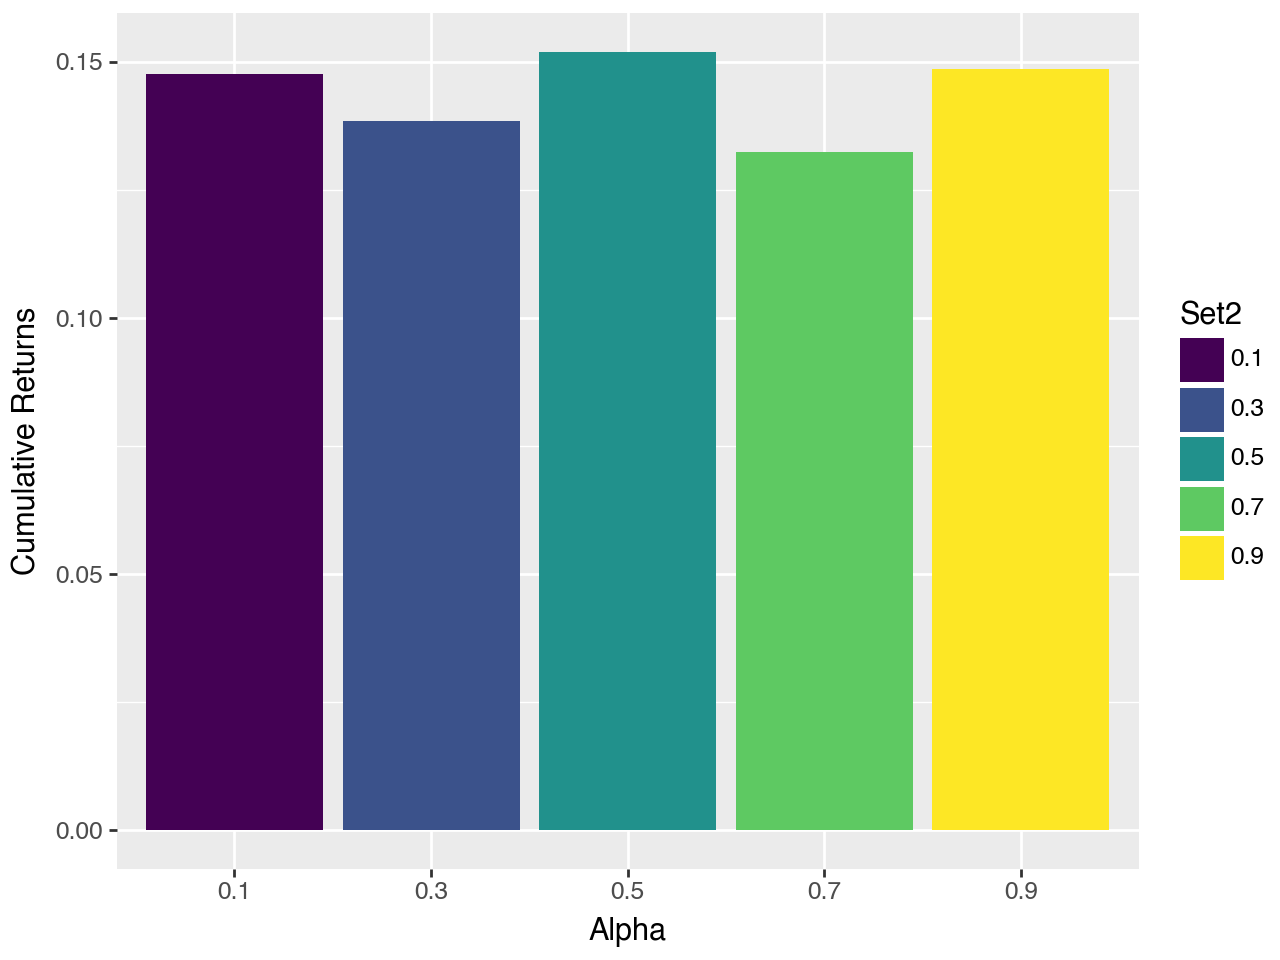

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Cumulative Returns/Alpha_O_barplot.pdf


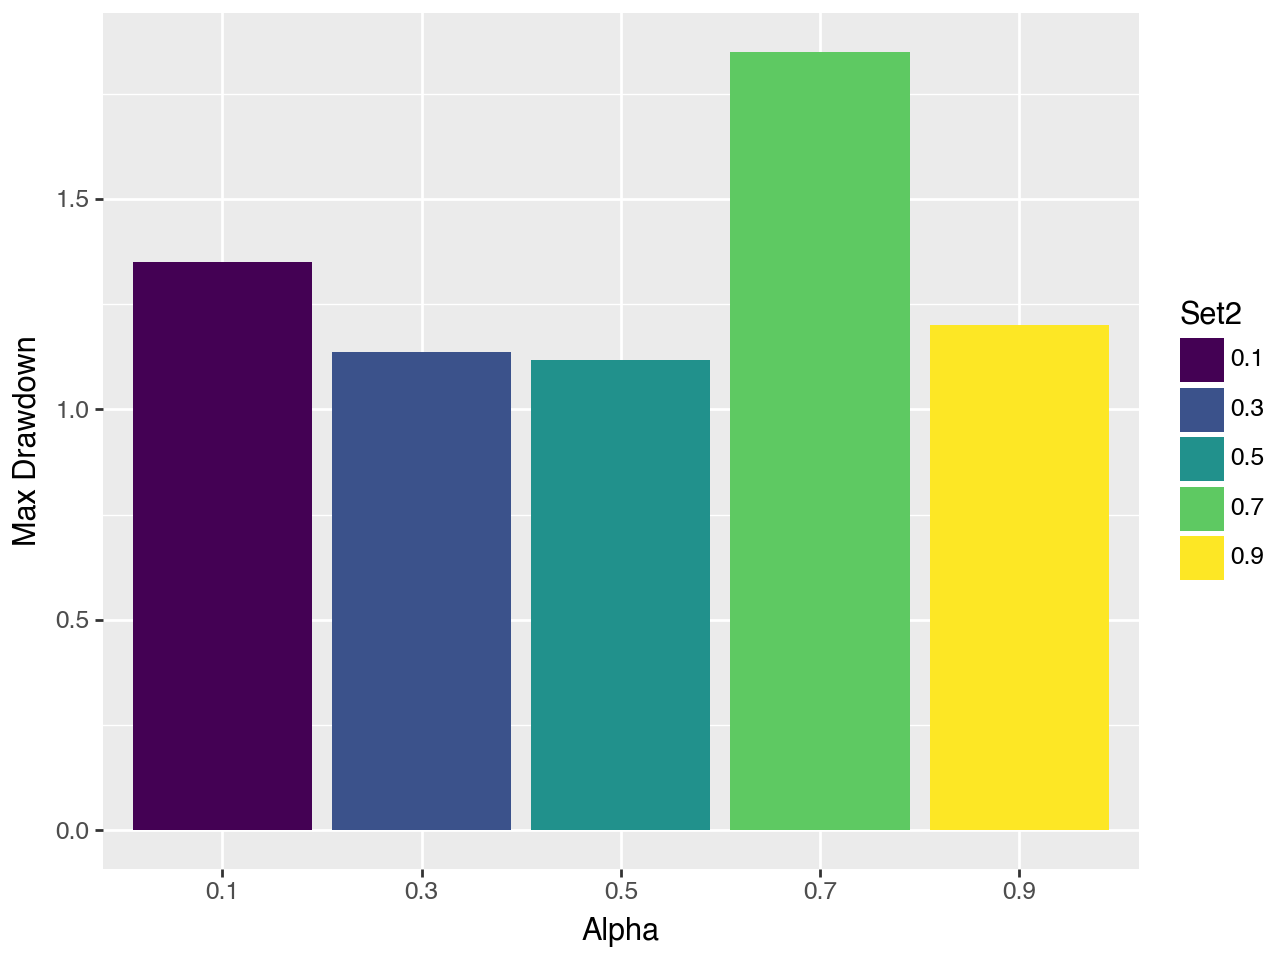

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_AAPL_barplot.pdf


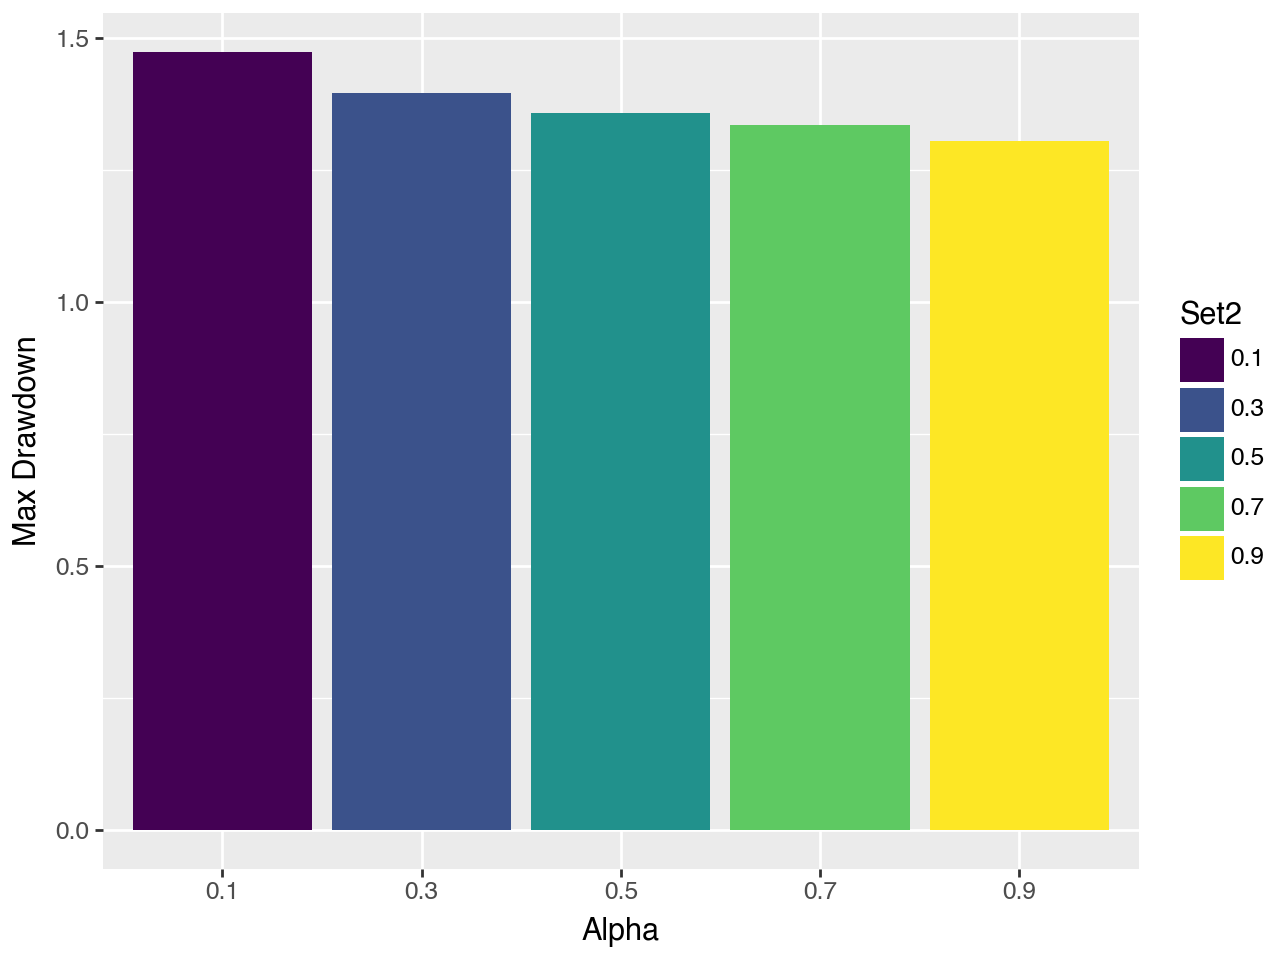

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_ABBV_barplot.pdf


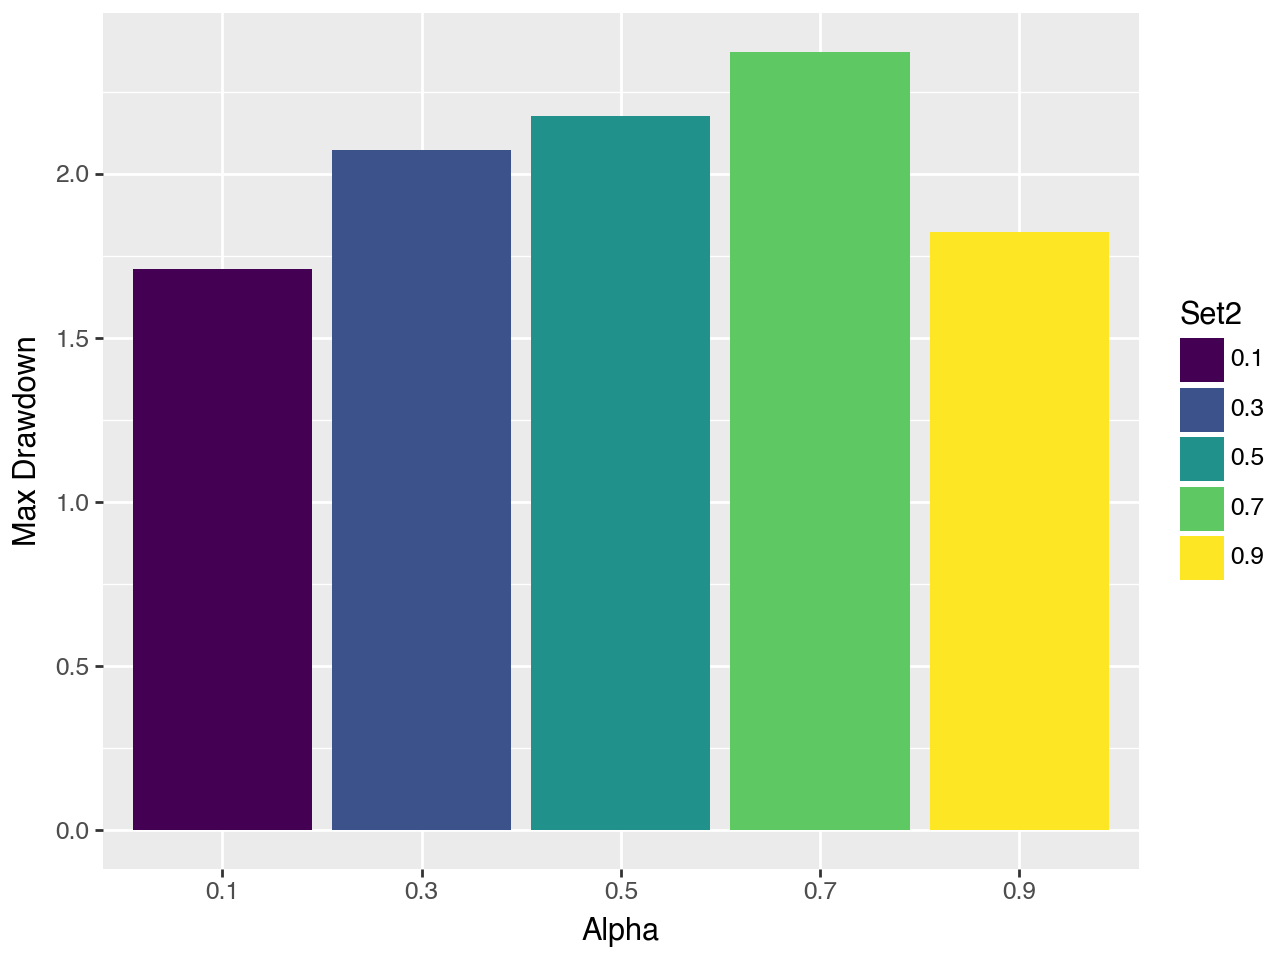

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_ACN_barplot.pdf


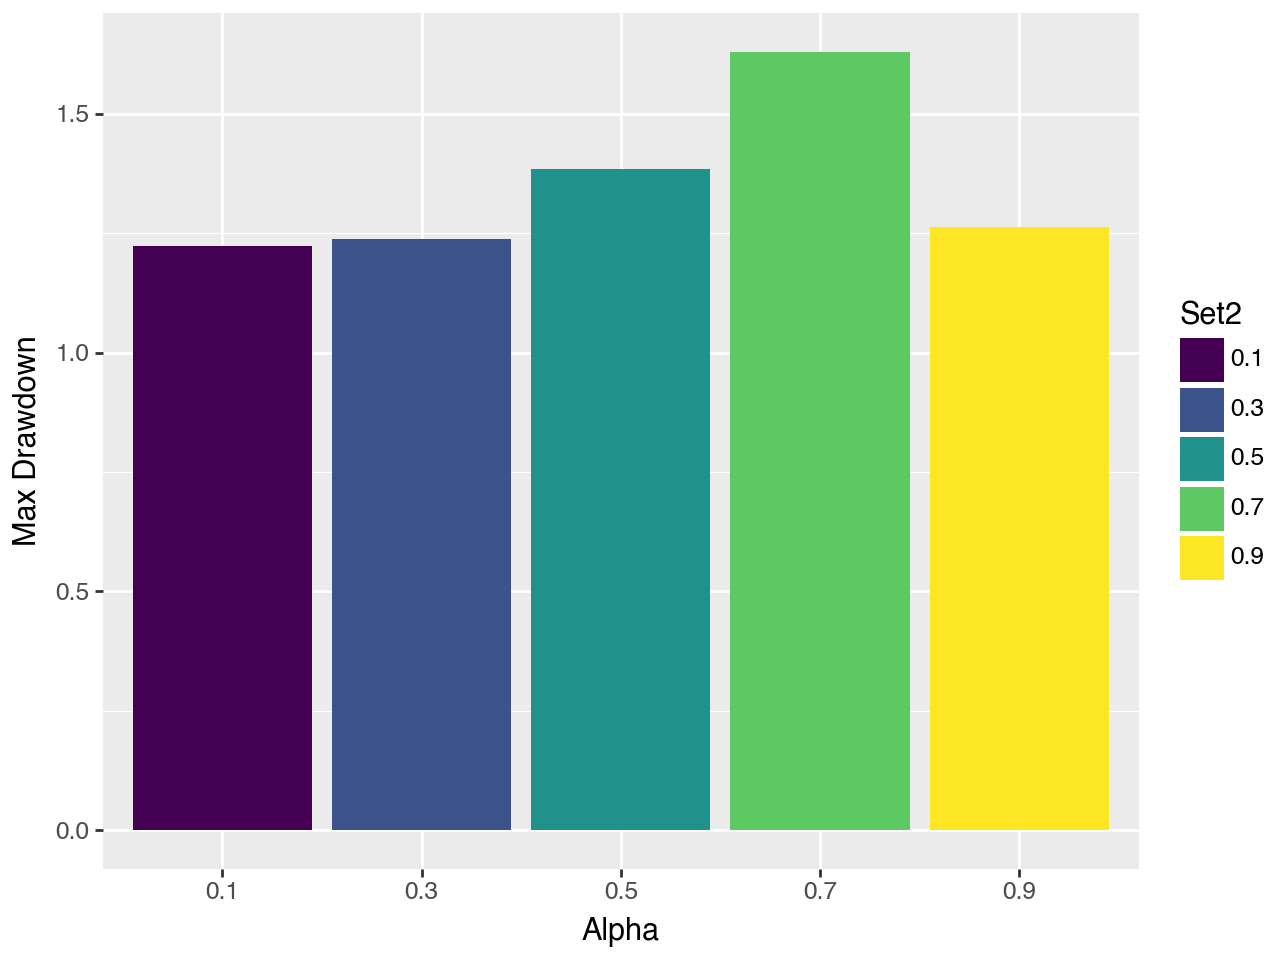

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_ADBE_barplot.pdf


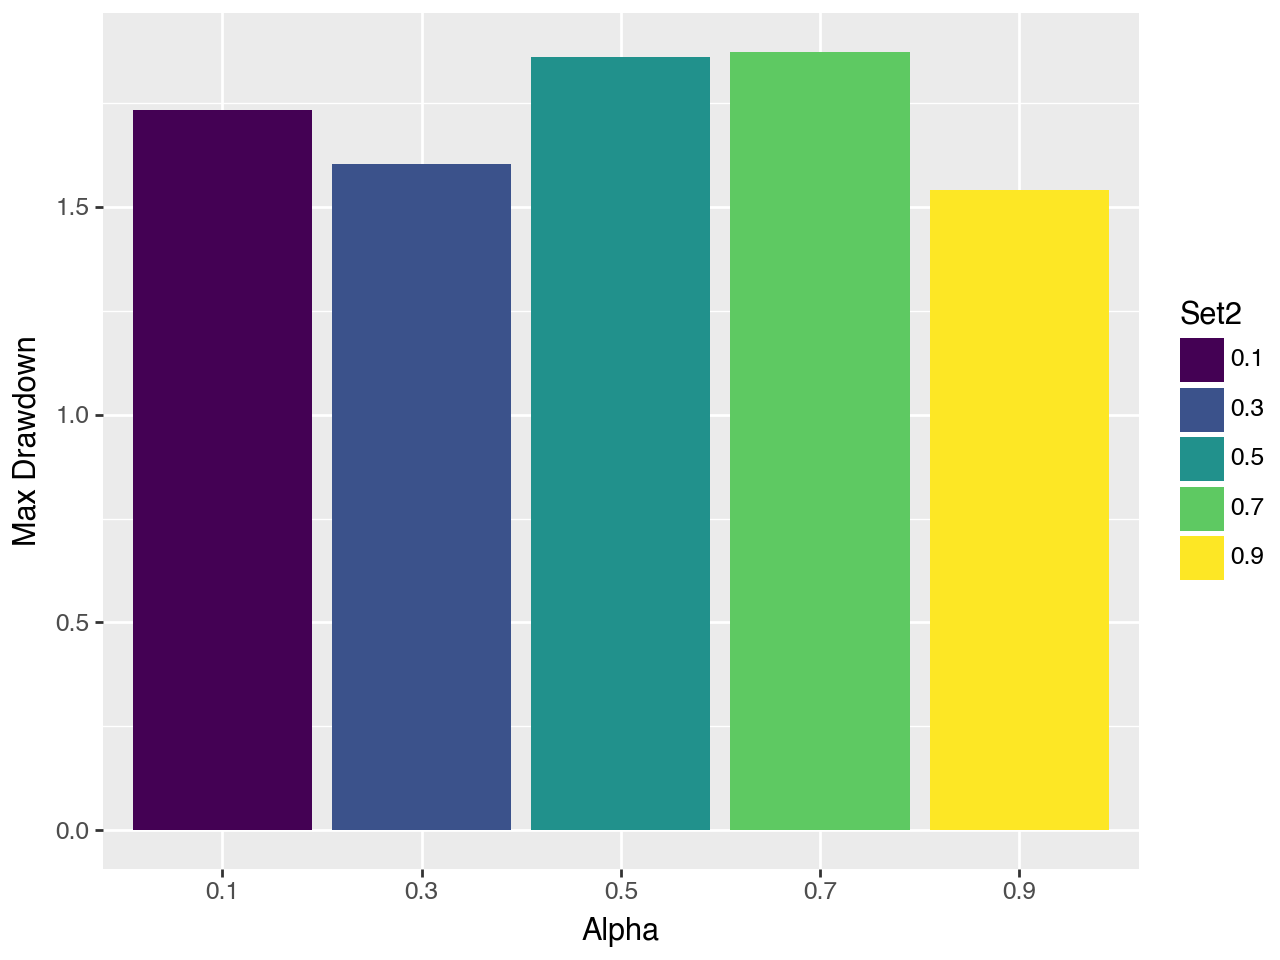

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_ADP_barplot.pdf


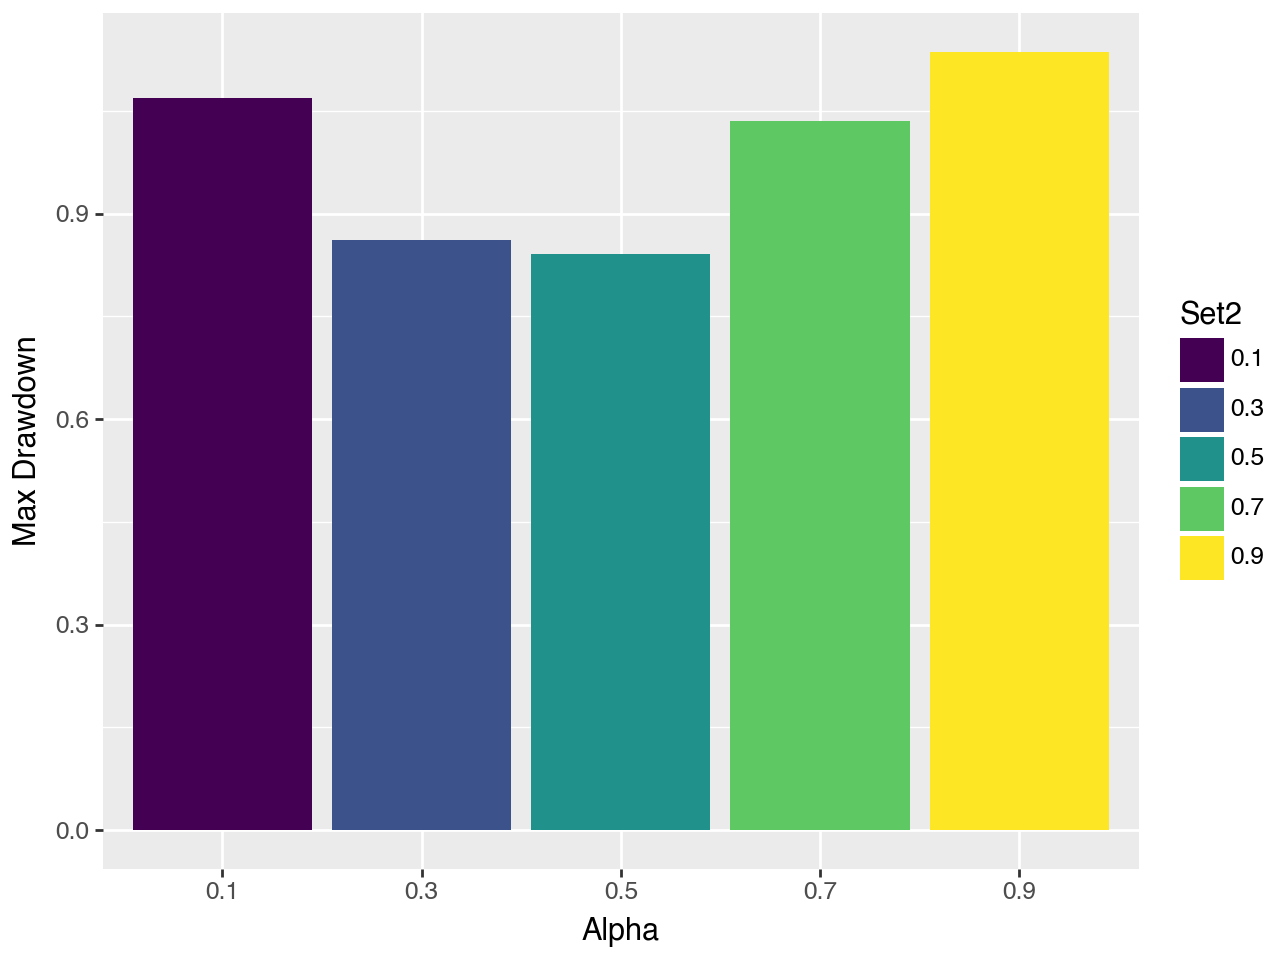

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_AMT_barplot.pdf


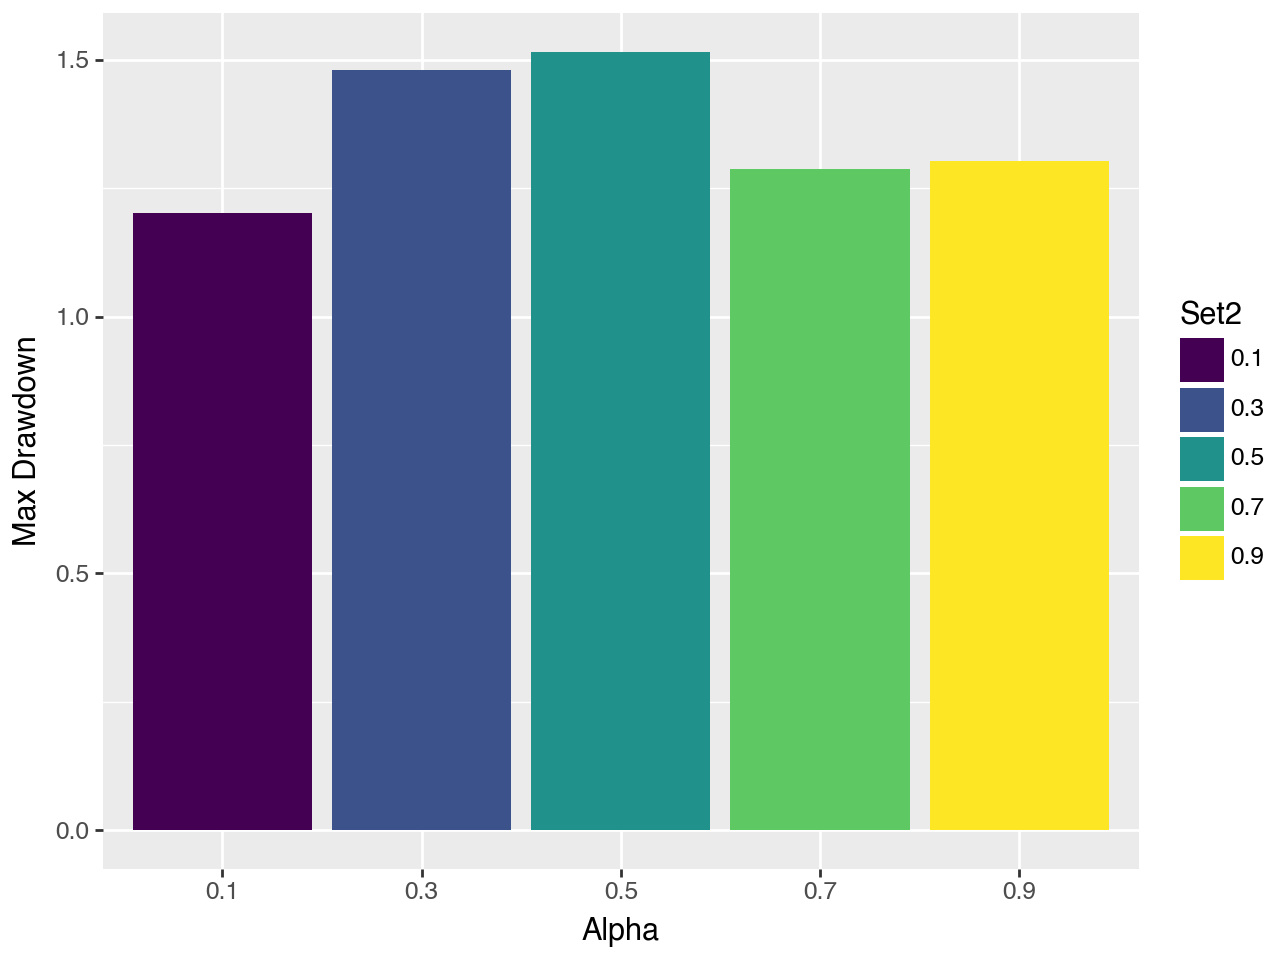

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_APD_barplot.pdf


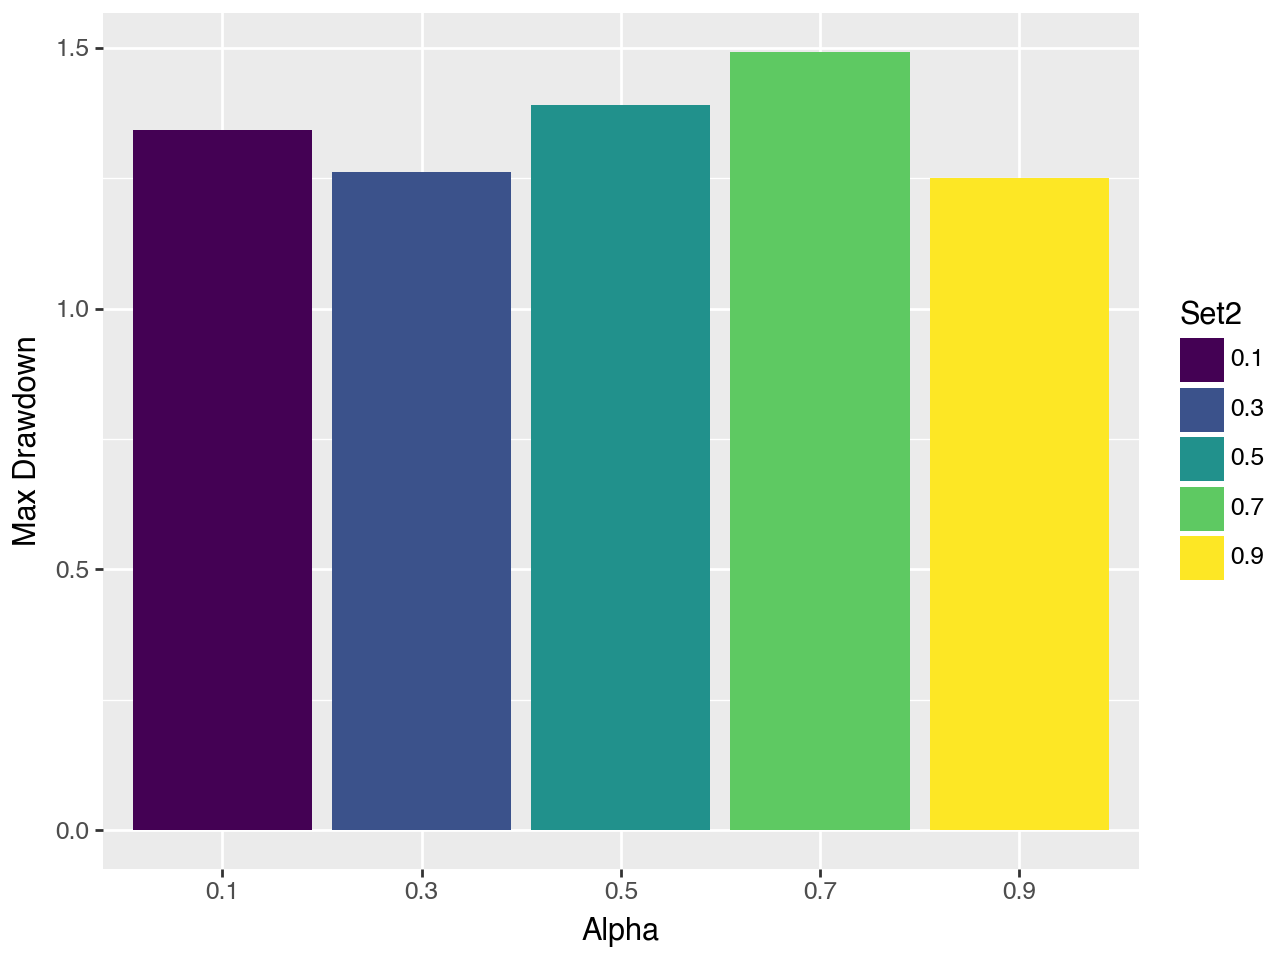

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_AVGO_barplot.pdf


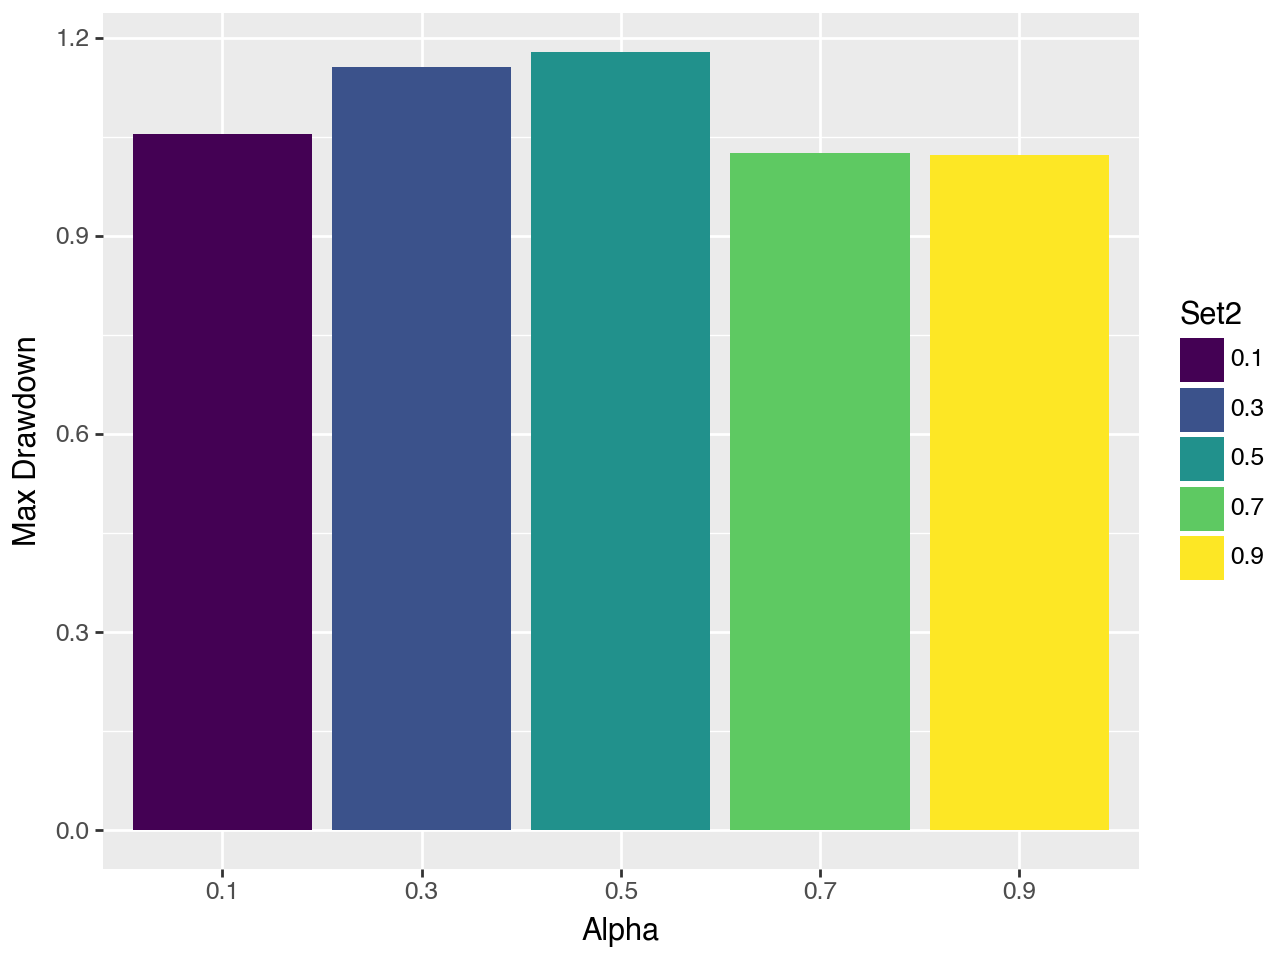

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_AWK_barplot.pdf


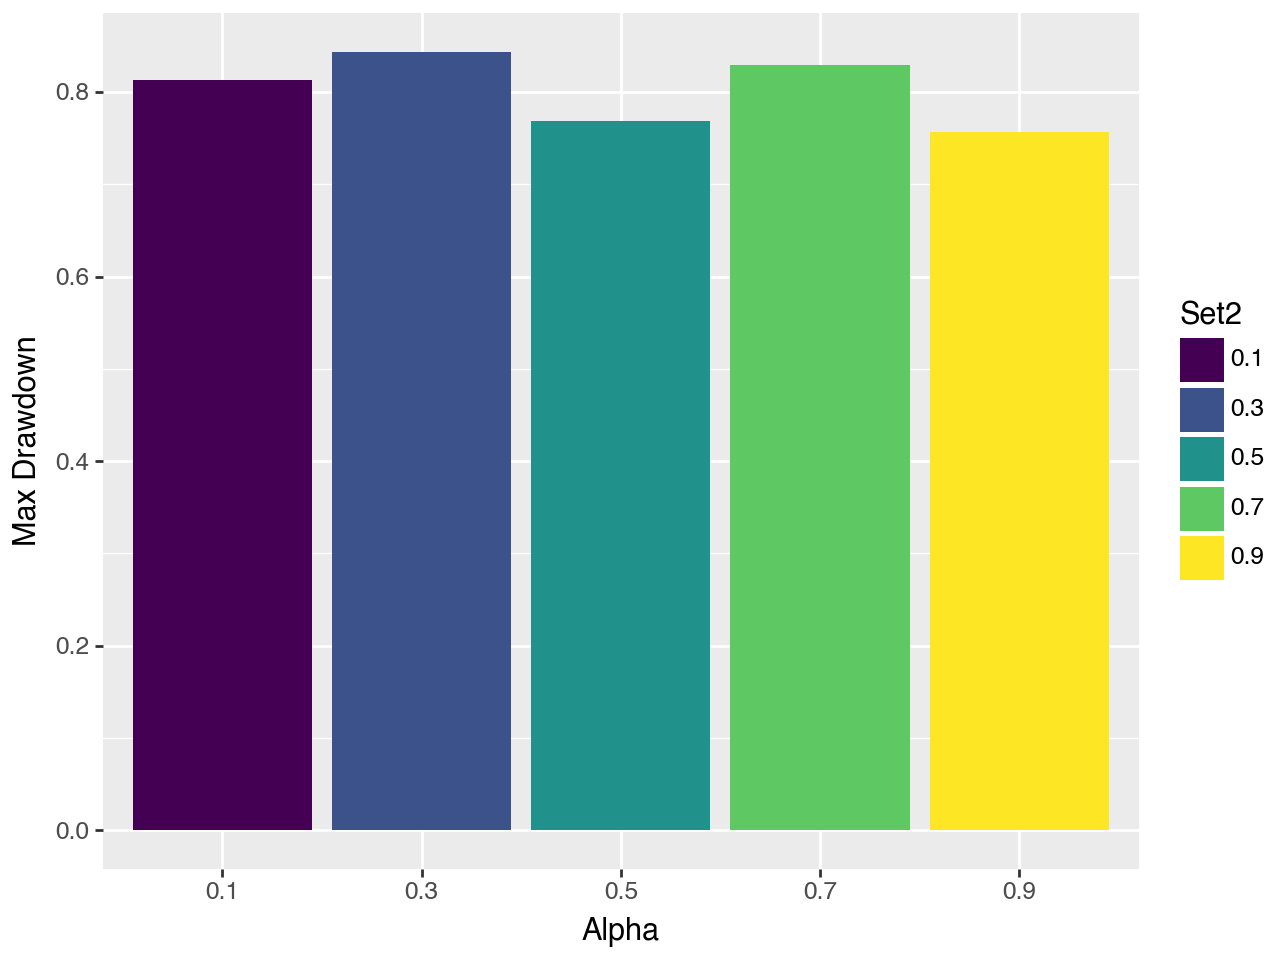

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_BA_barplot.pdf


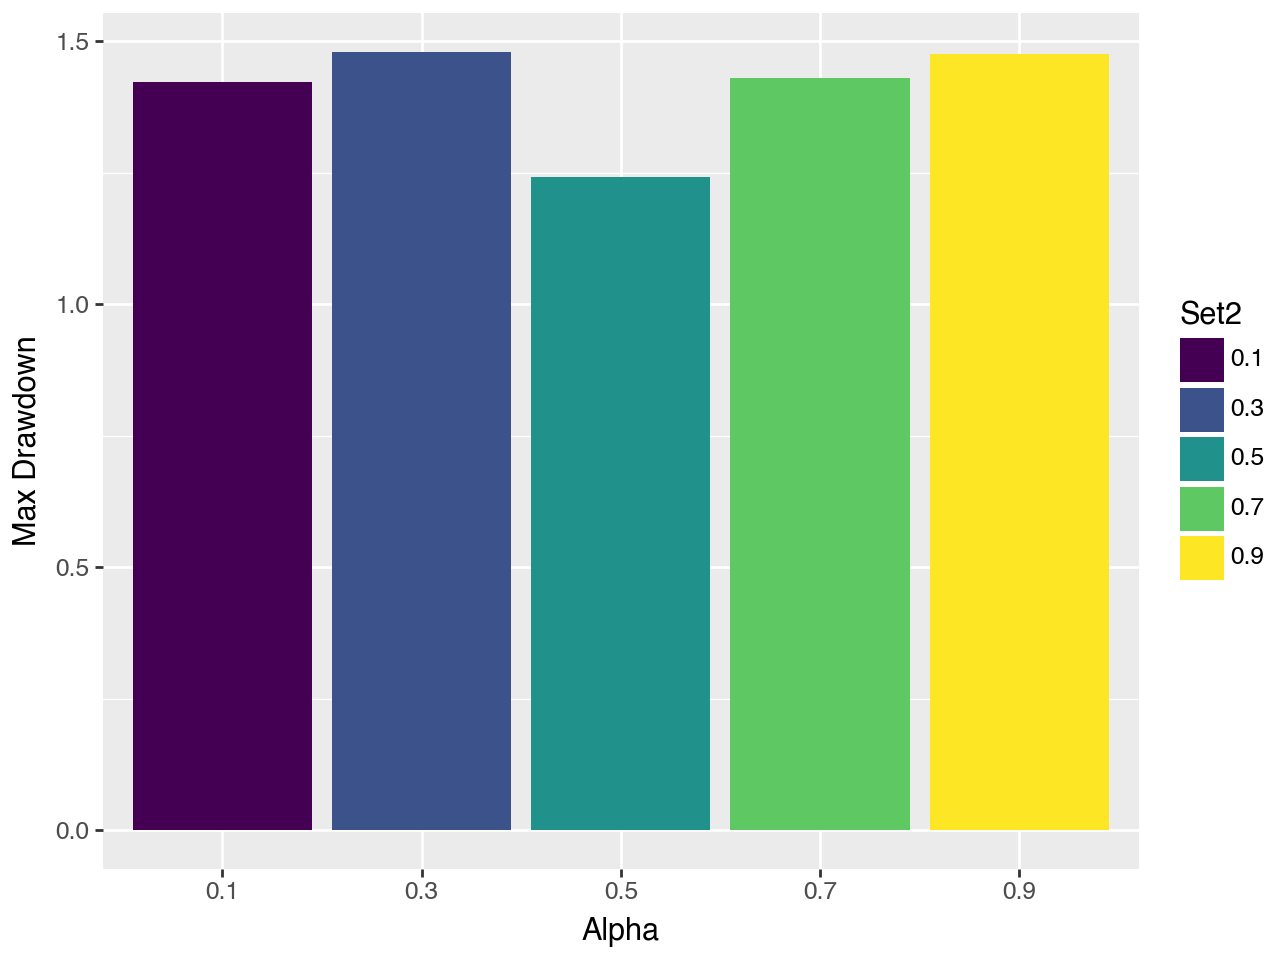

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_BAC_barplot.pdf


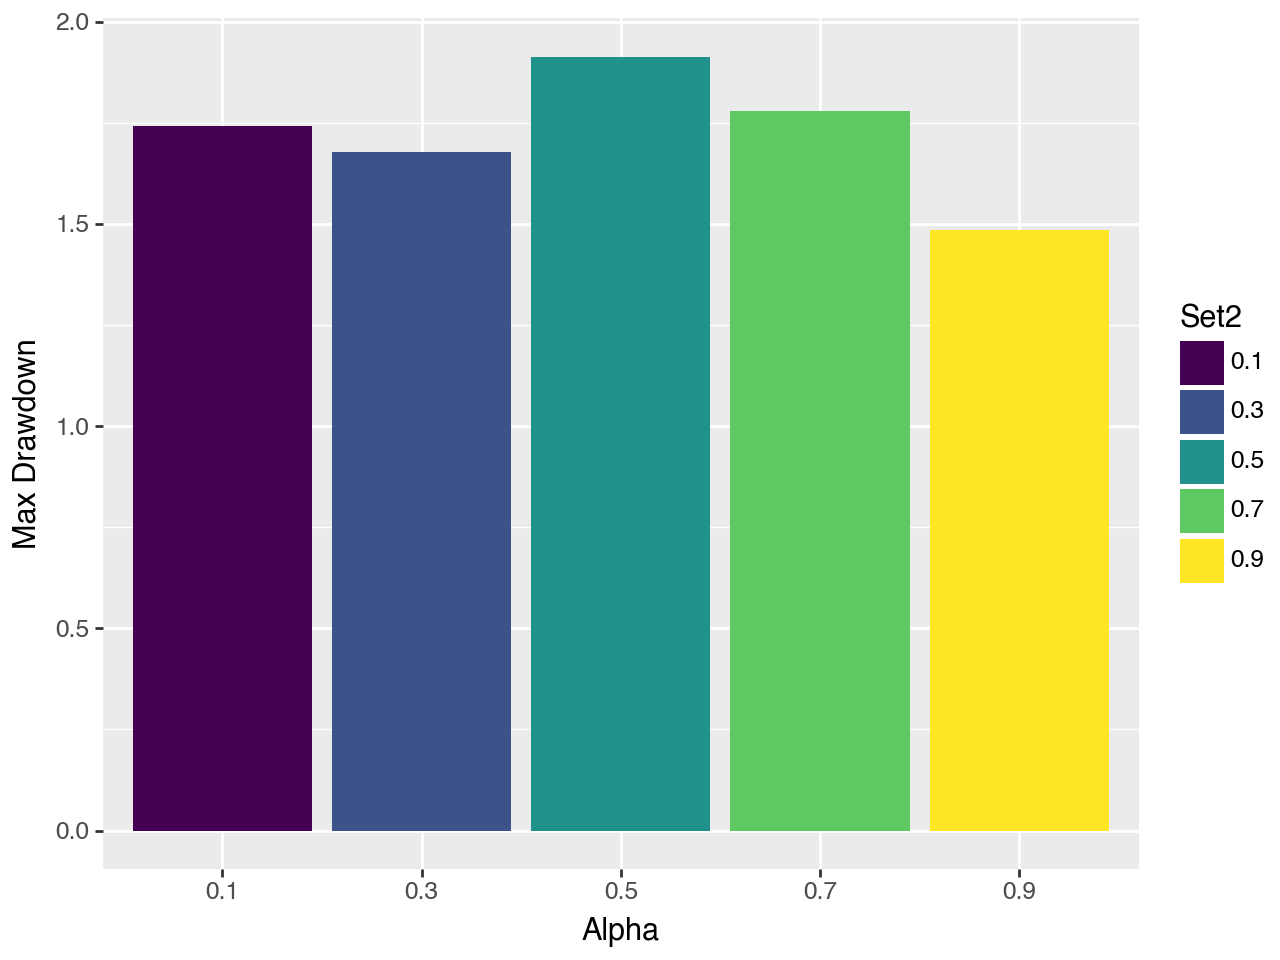

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_BBL_barplot.pdf


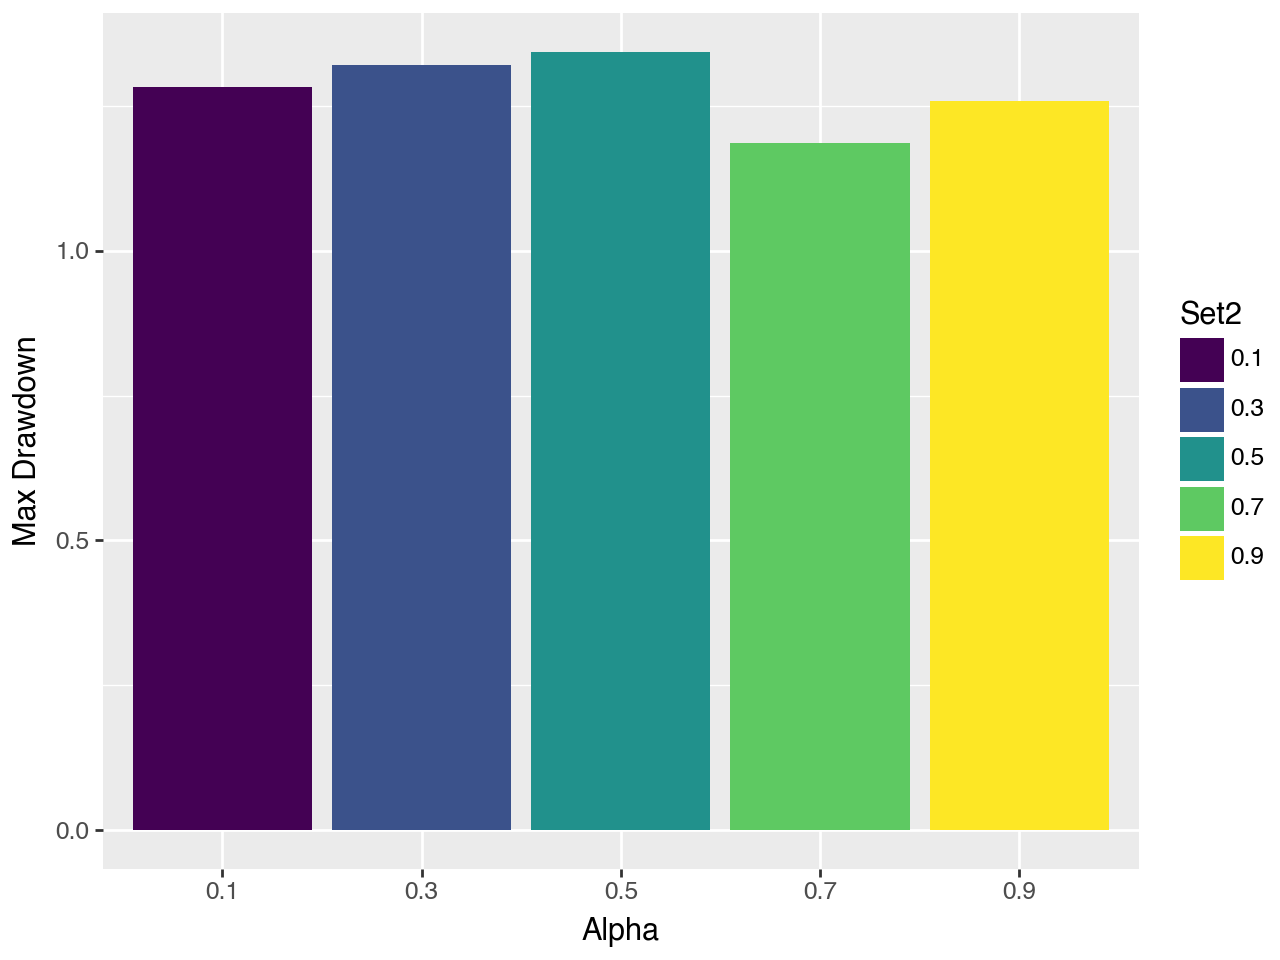

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_BHP_barplot.pdf


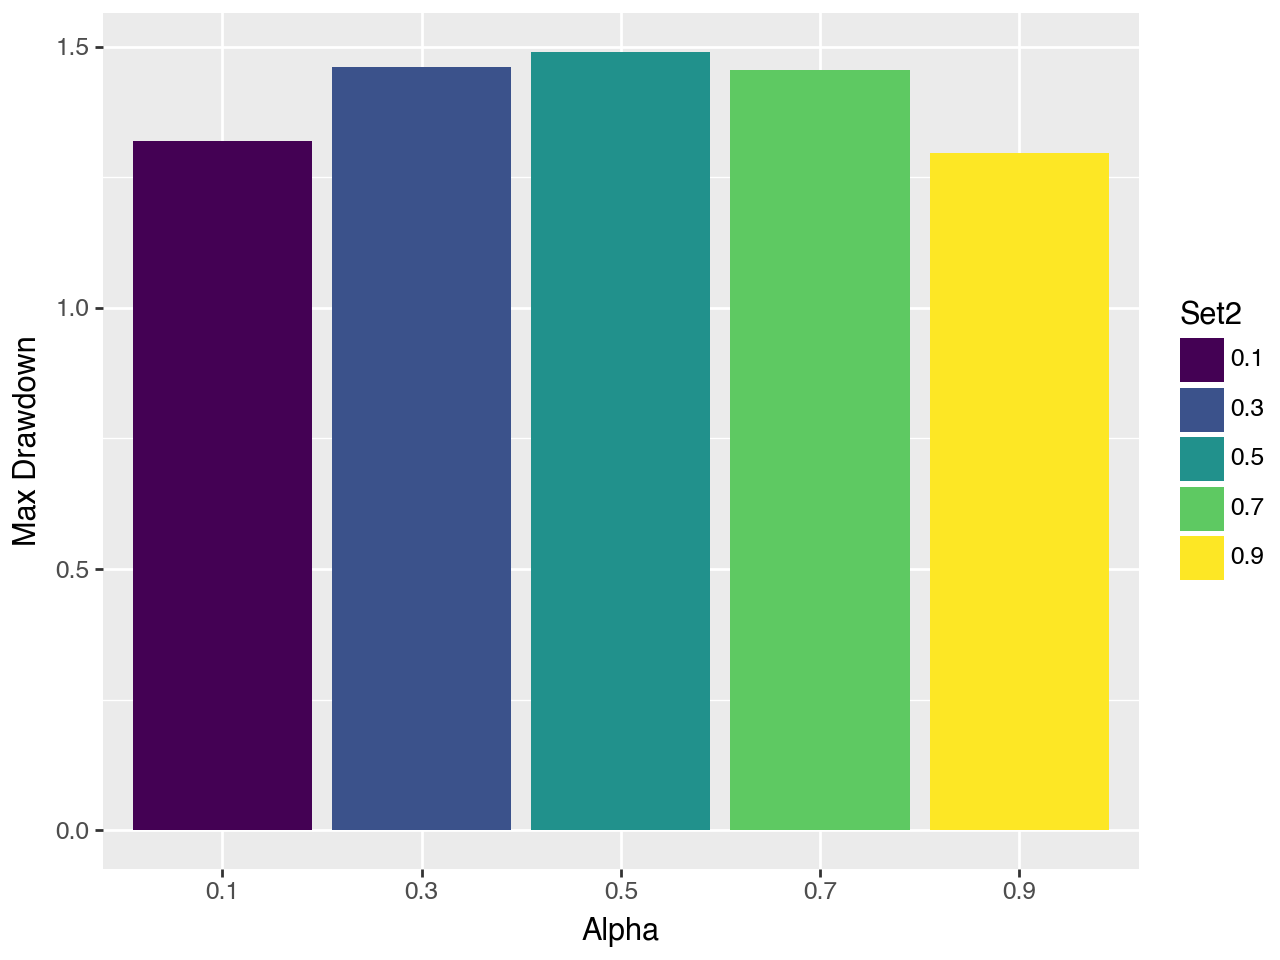

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_BP_barplot.pdf


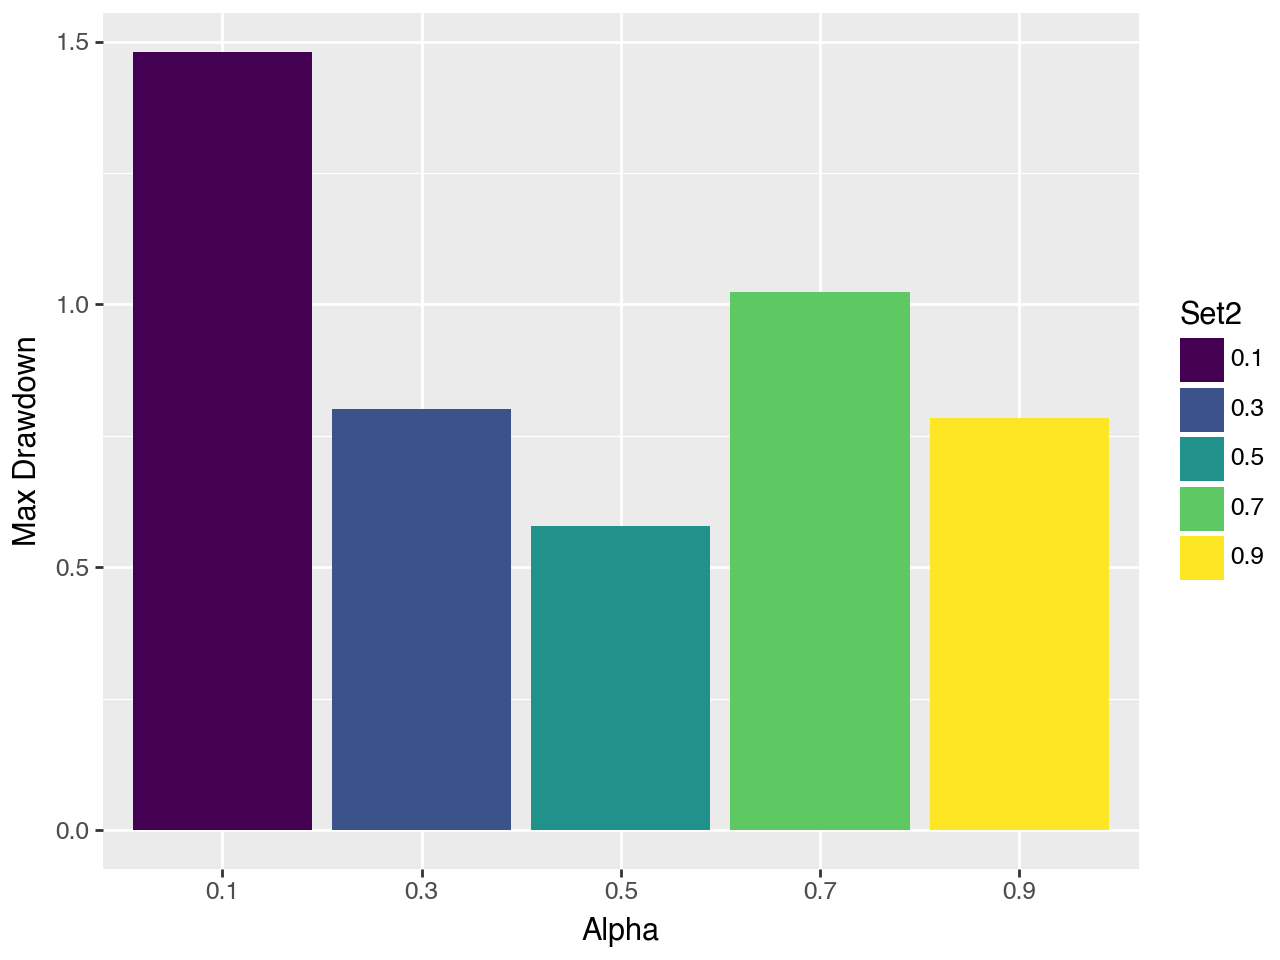

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_BRK-A_barplot.pdf


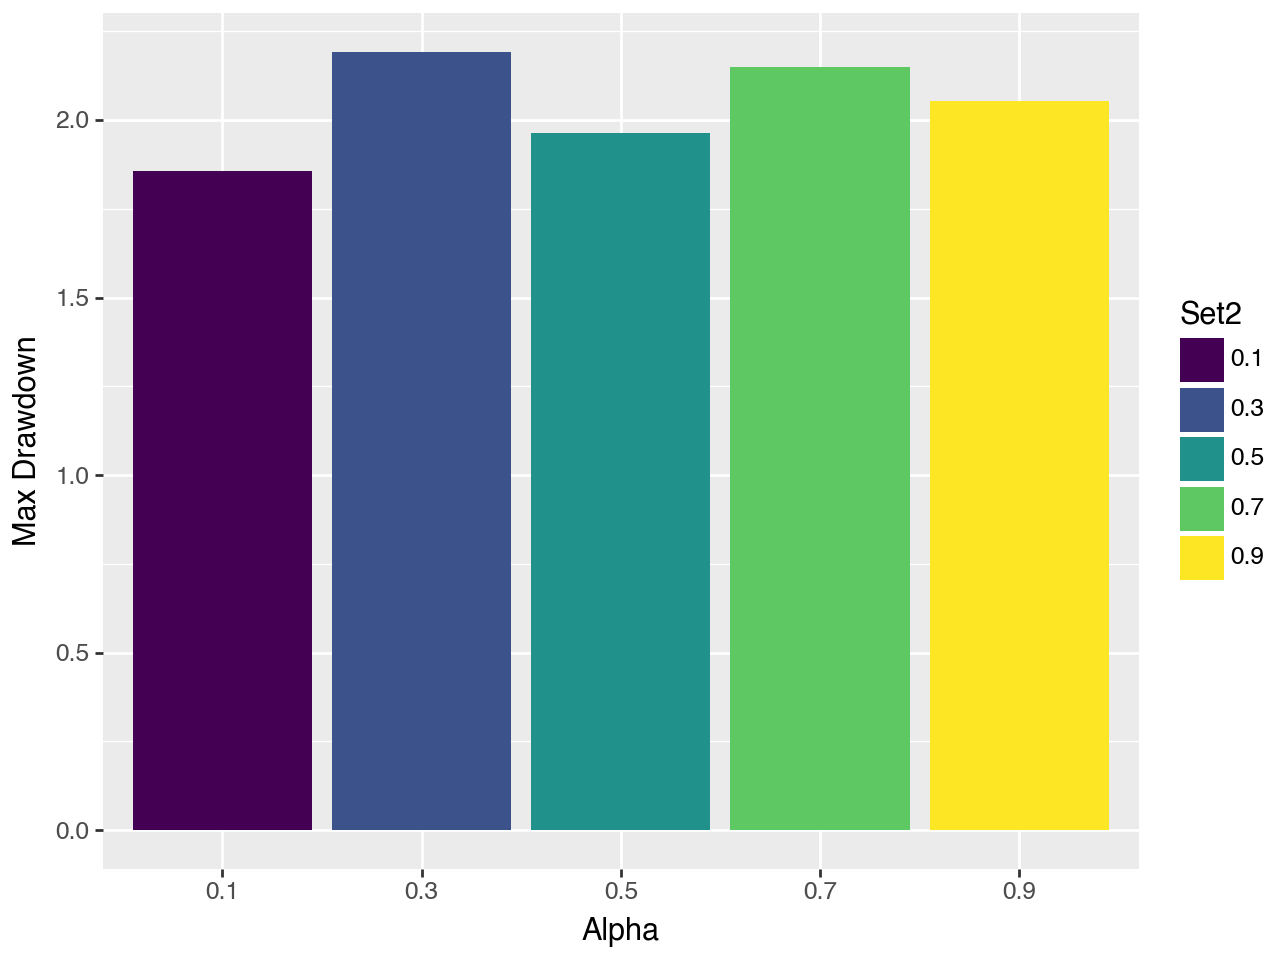

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_CCI_barplot.pdf


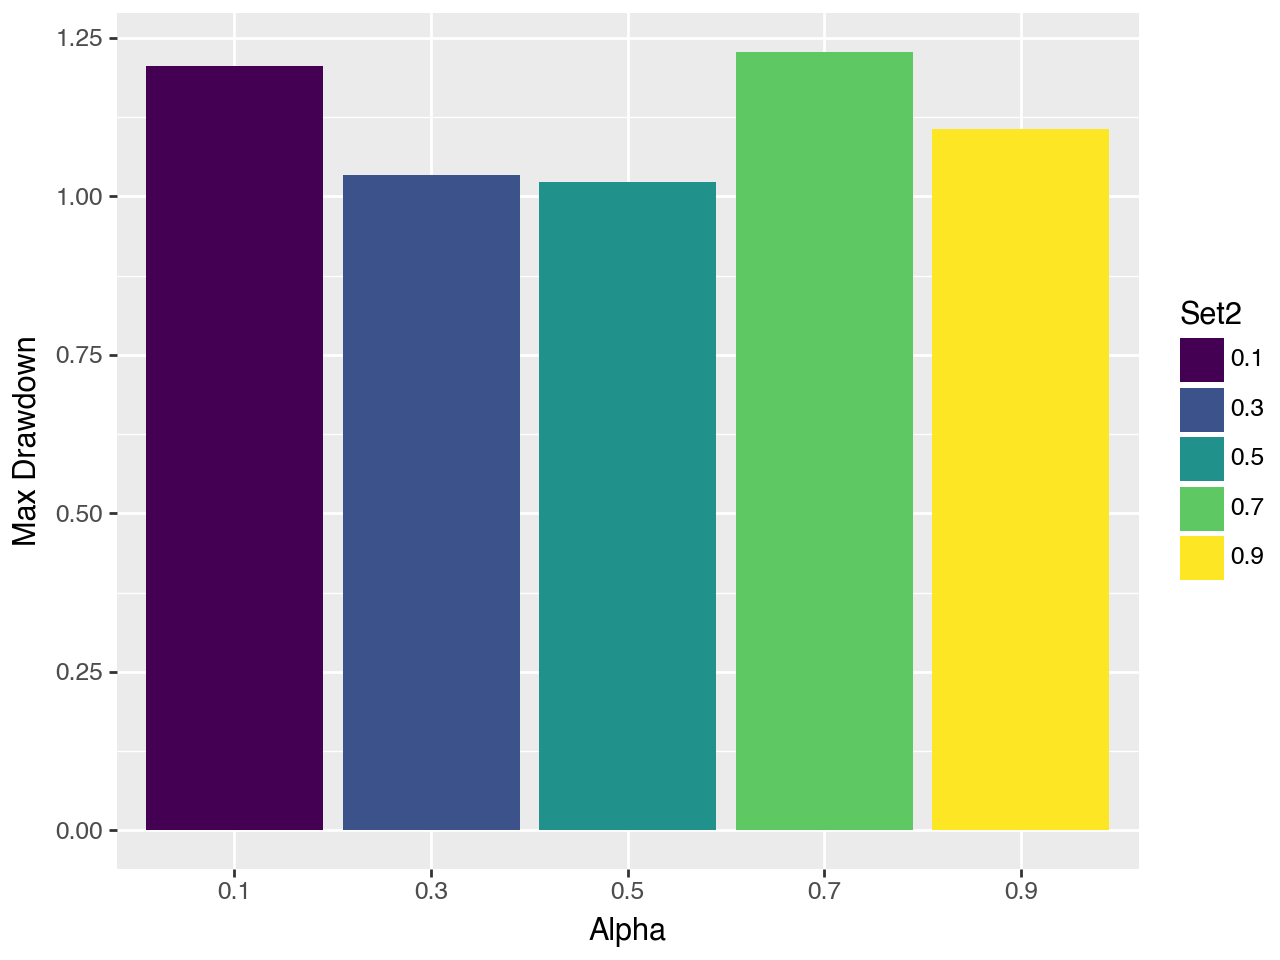

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_CHTR_barplot.pdf


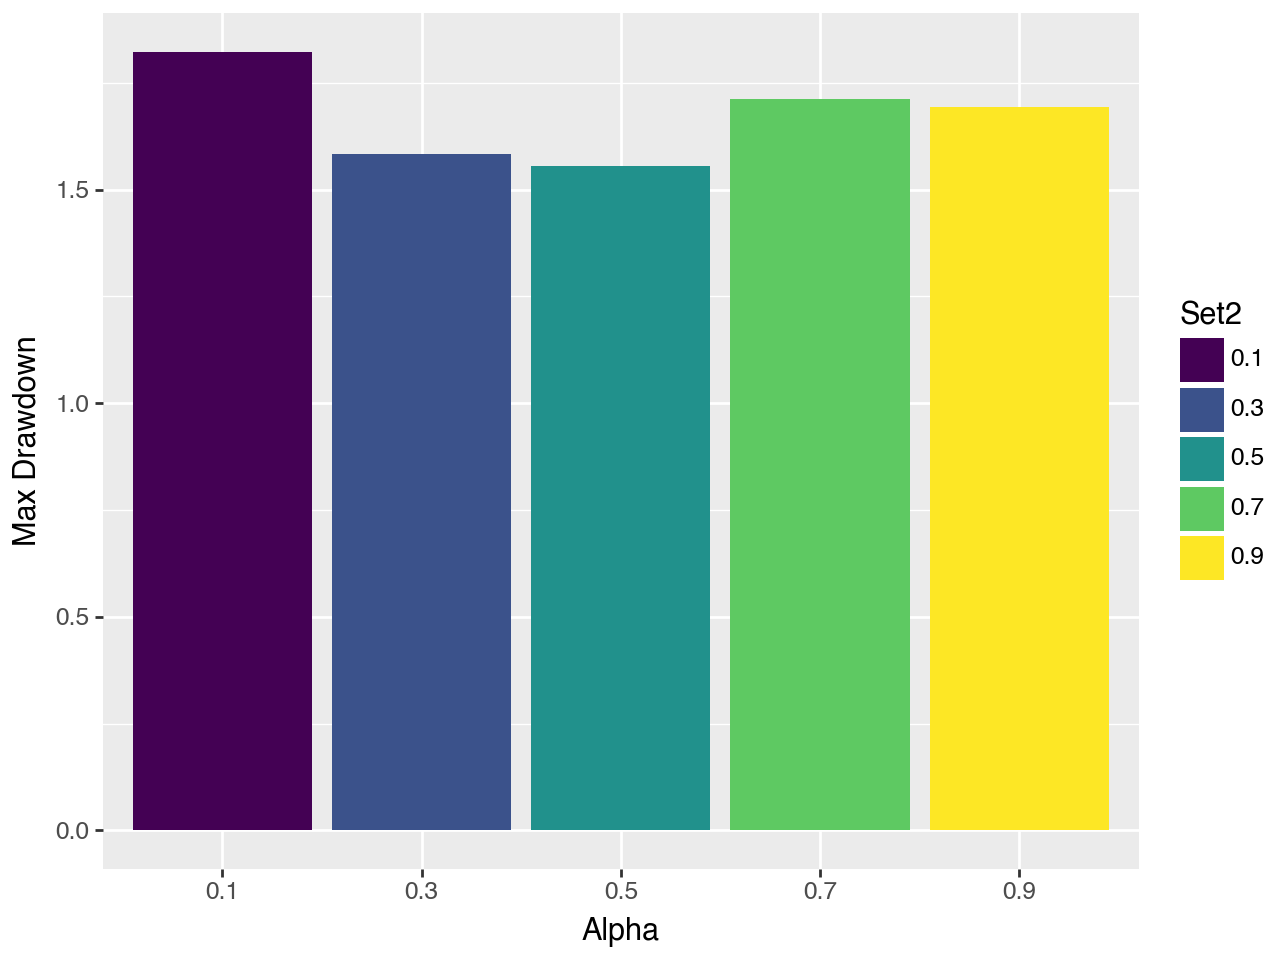

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_COP_barplot.pdf


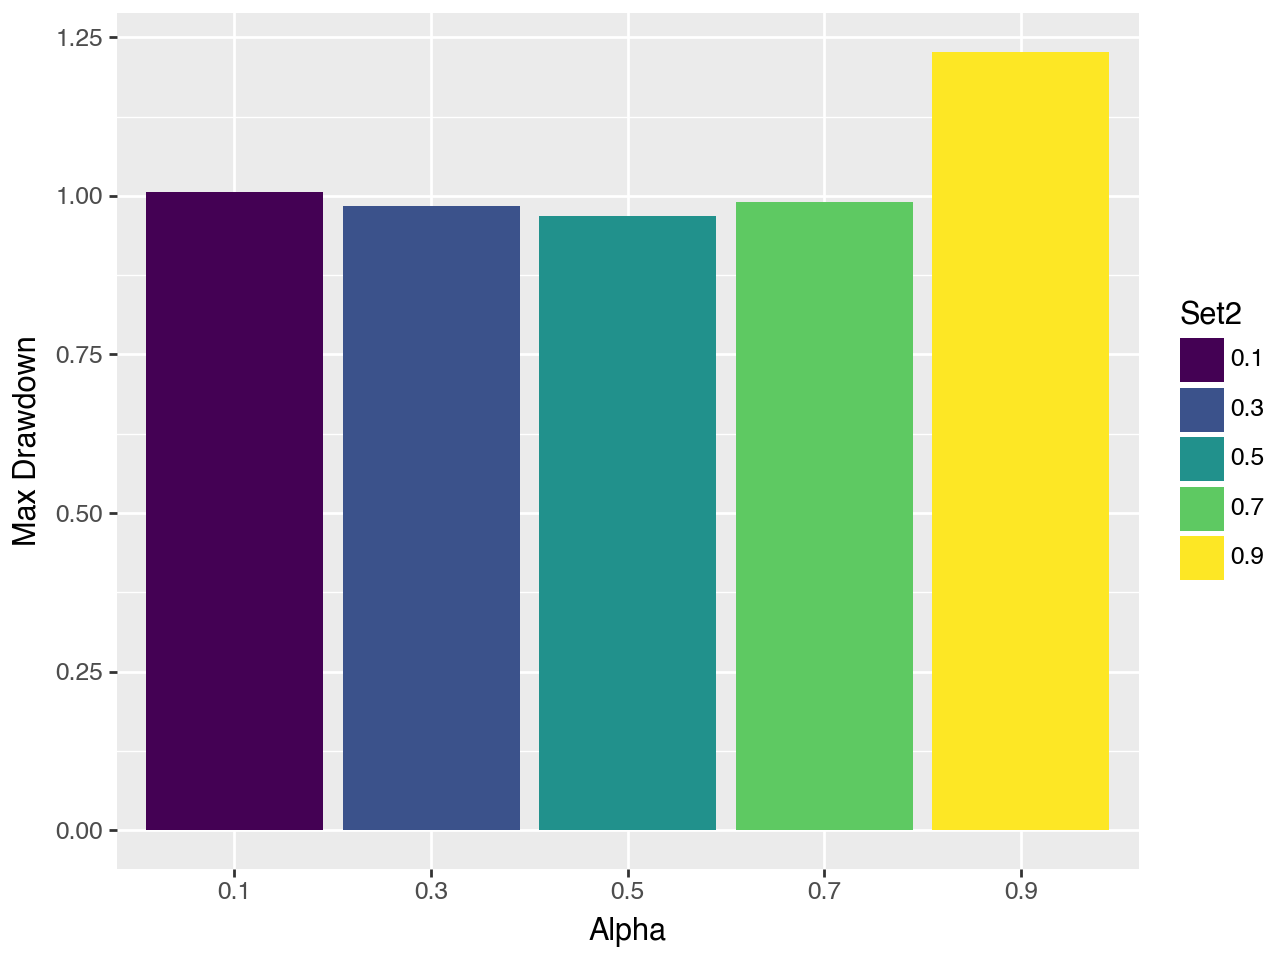

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_COST_barplot.pdf


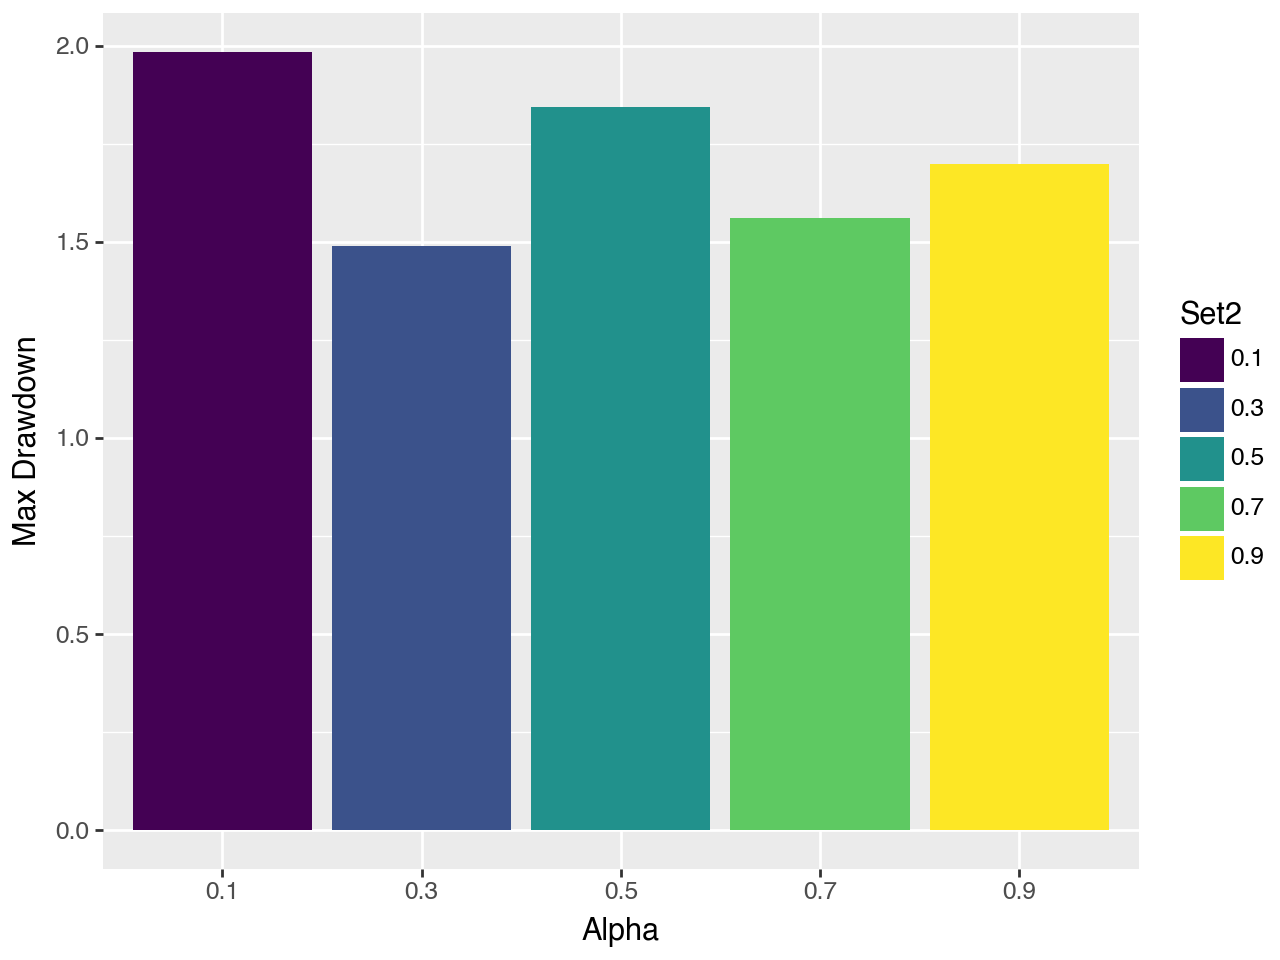

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_CSCO_barplot.pdf


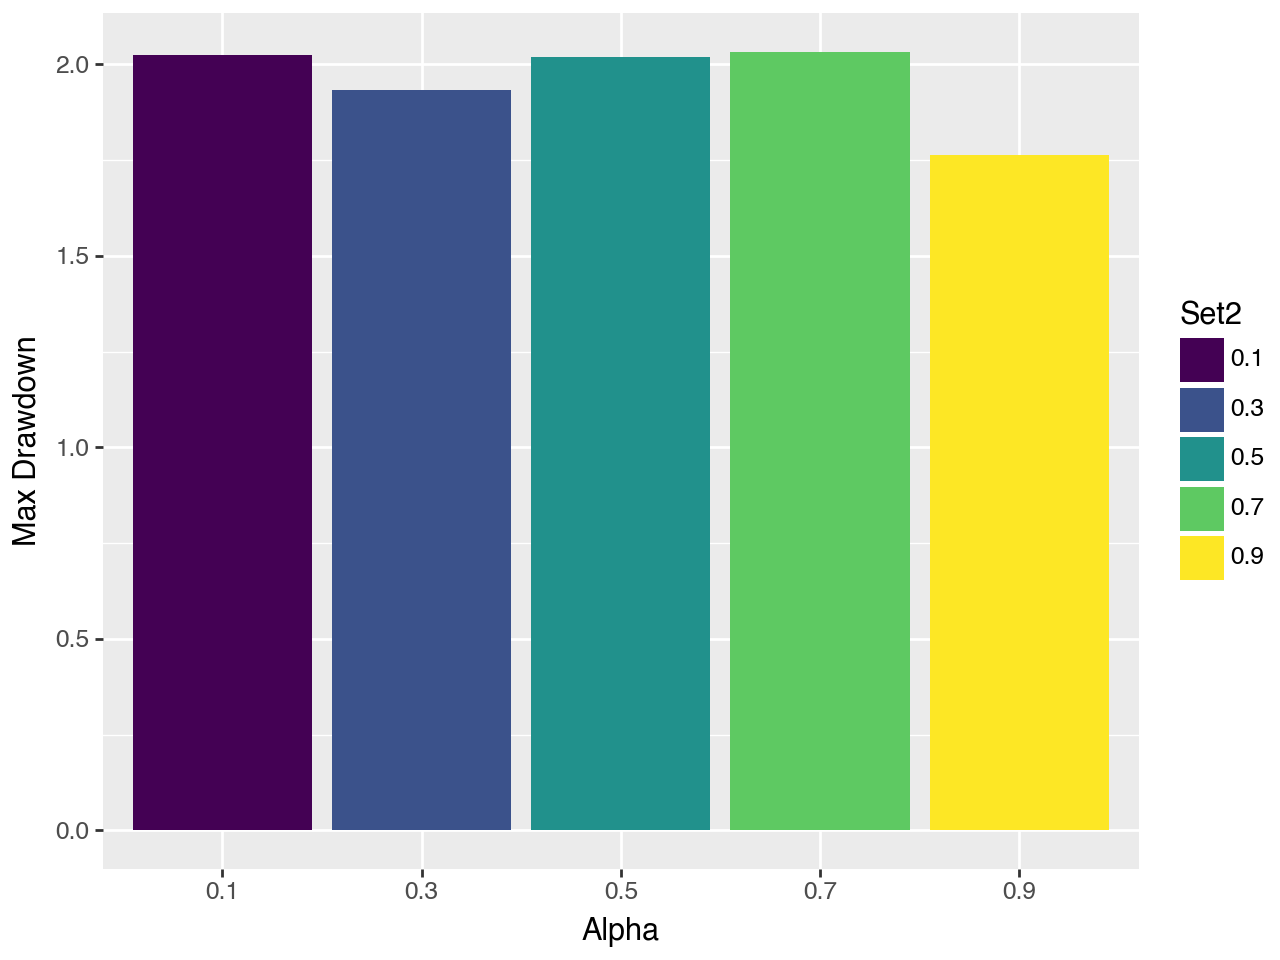

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_CVX_barplot.pdf


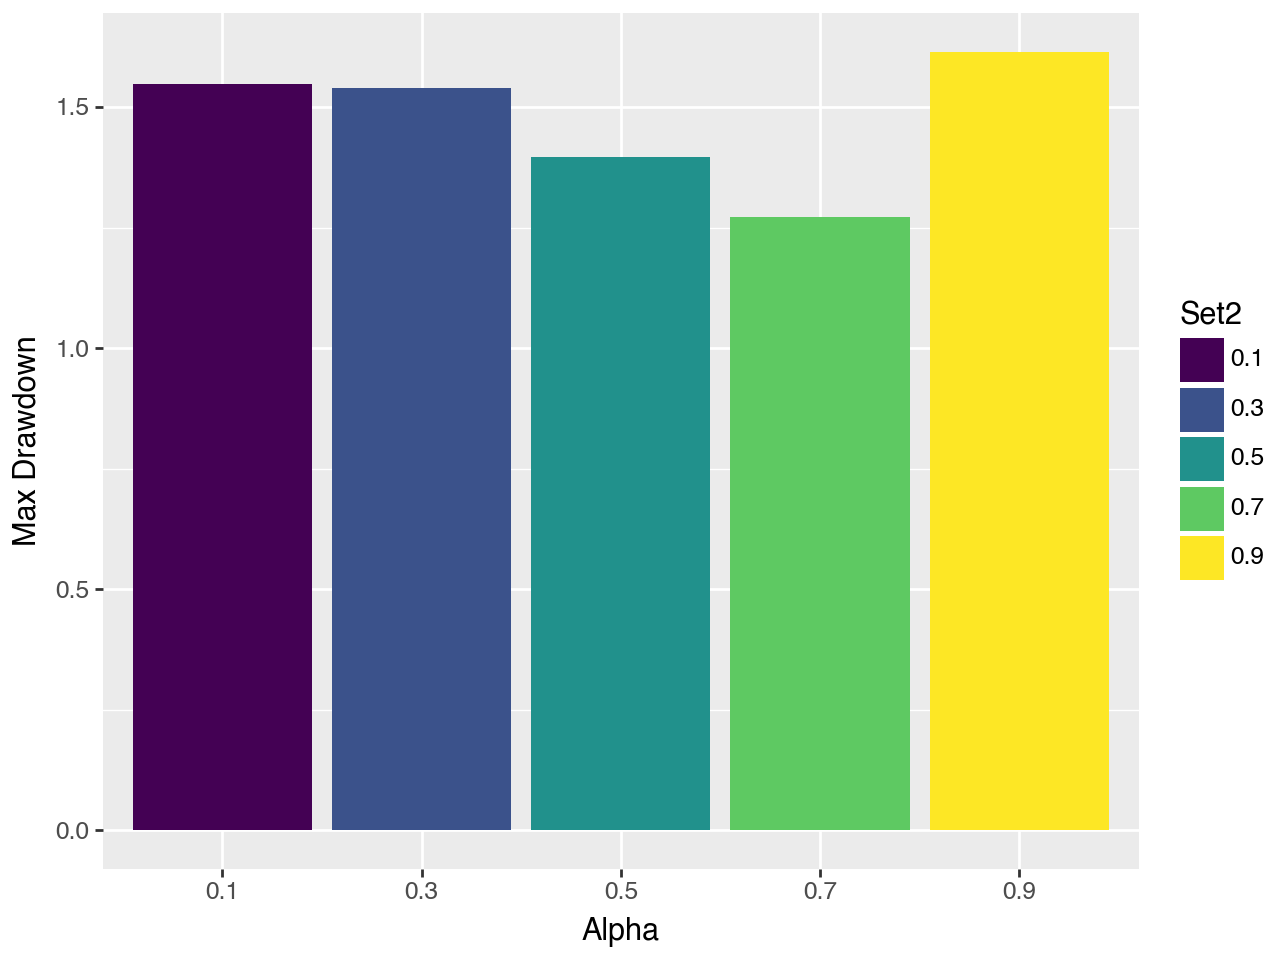

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_DE_barplot.pdf


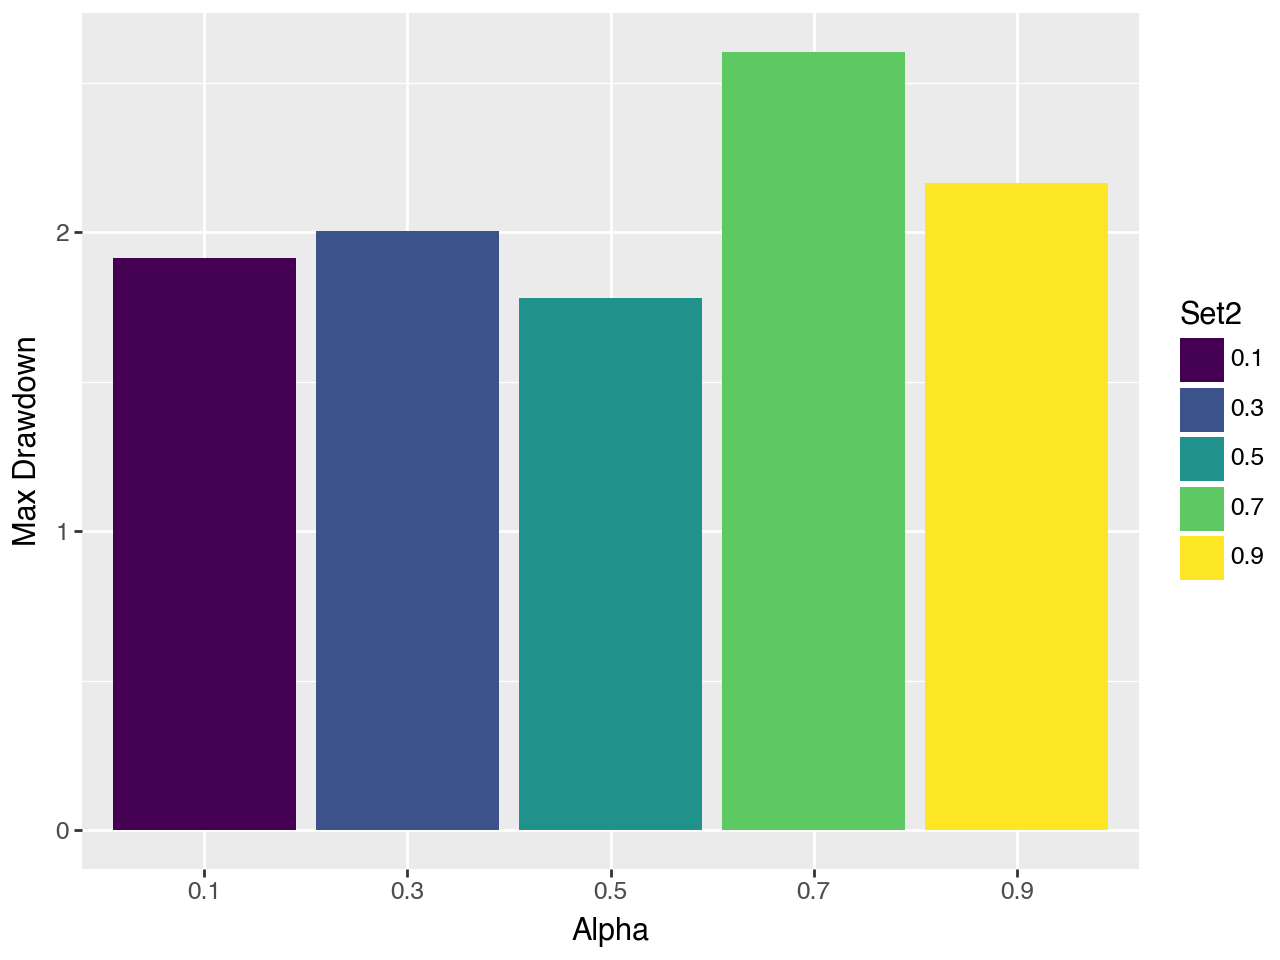

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_DEO_barplot.pdf


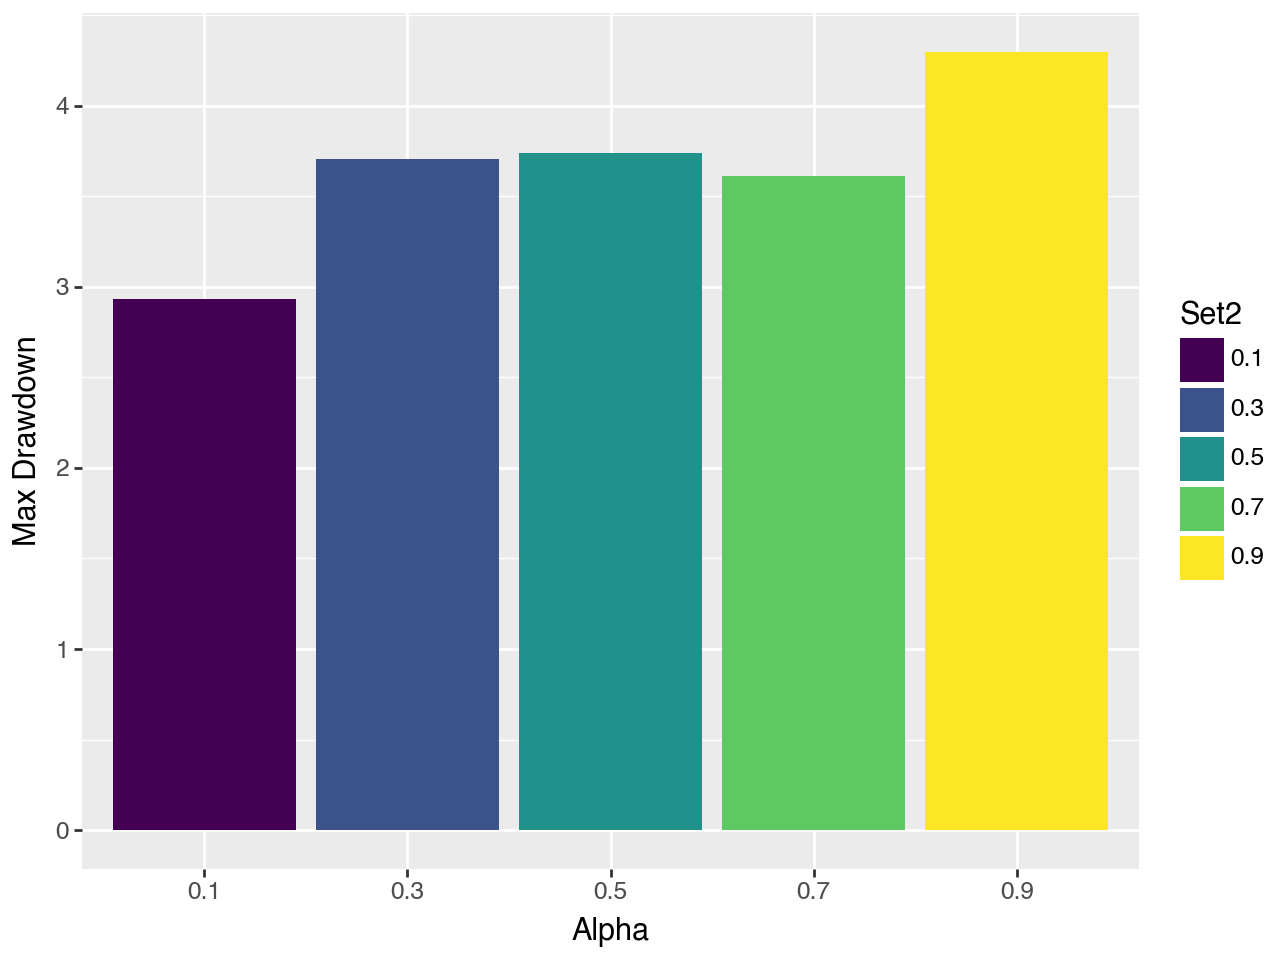

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_DHR_barplot.pdf


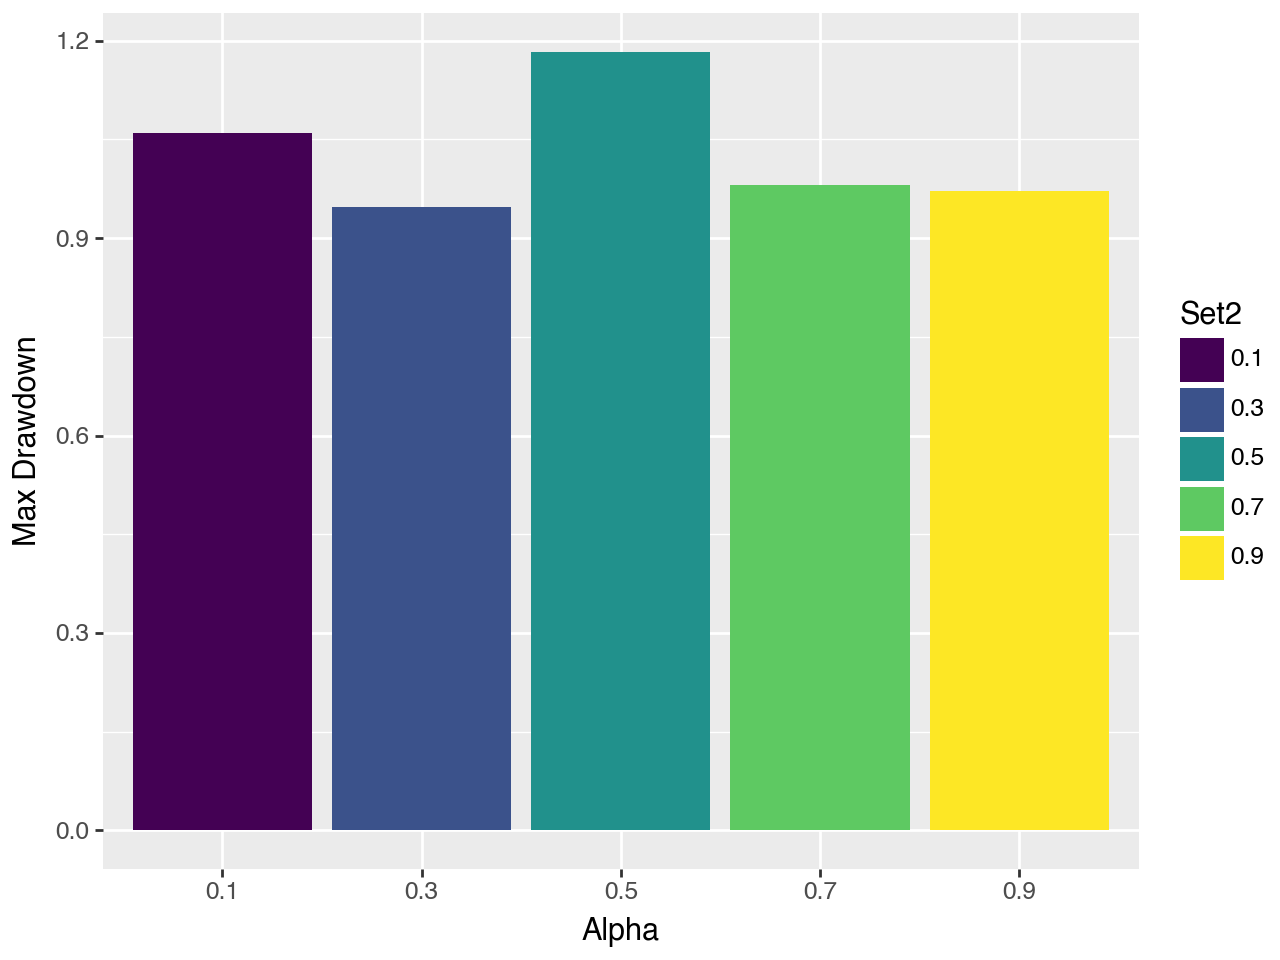

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_DLR_barplot.pdf


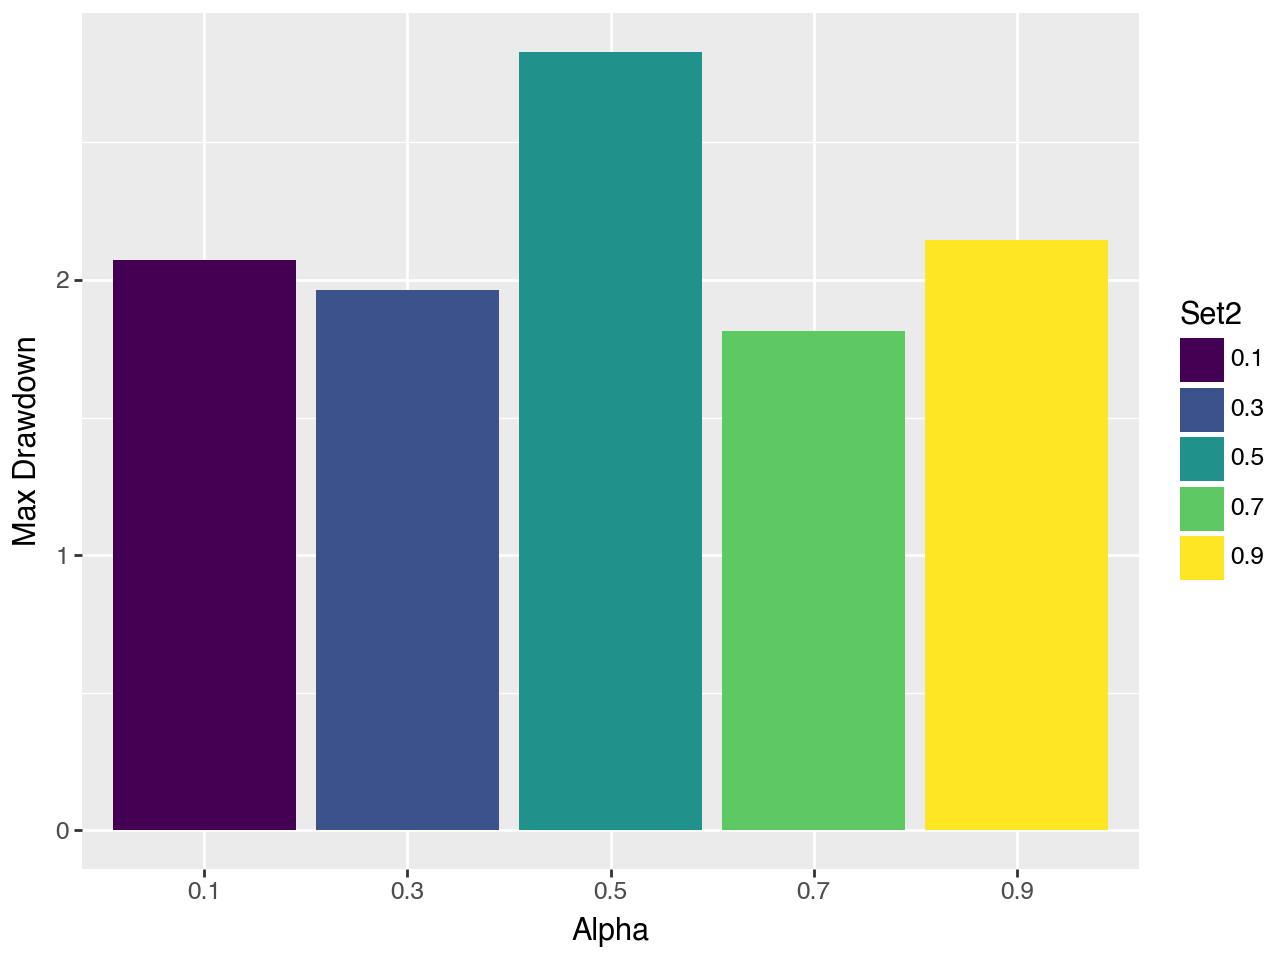

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_DUK_barplot.pdf


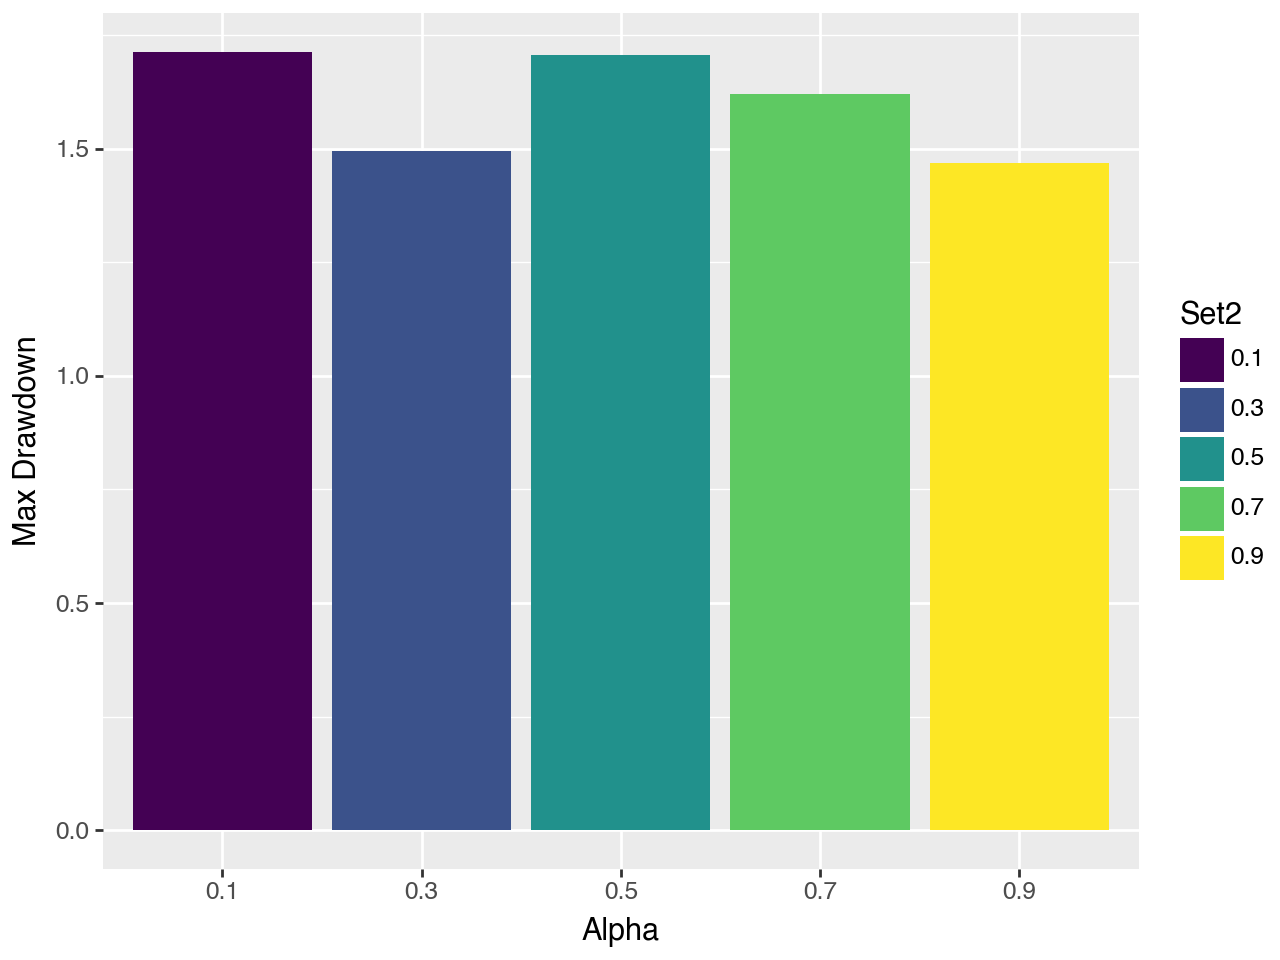

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_ECL_barplot.pdf


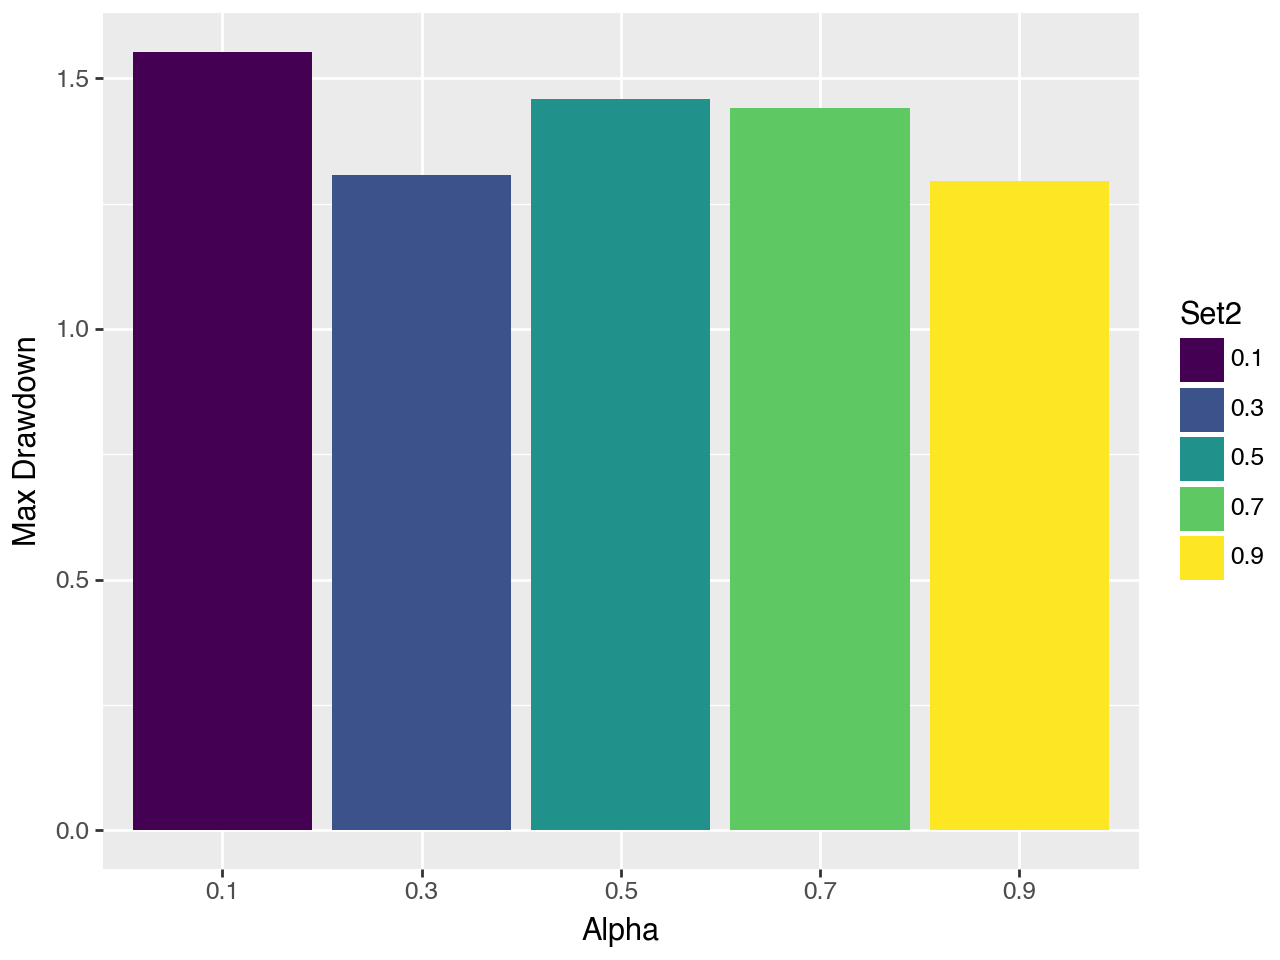

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_EL_barplot.pdf


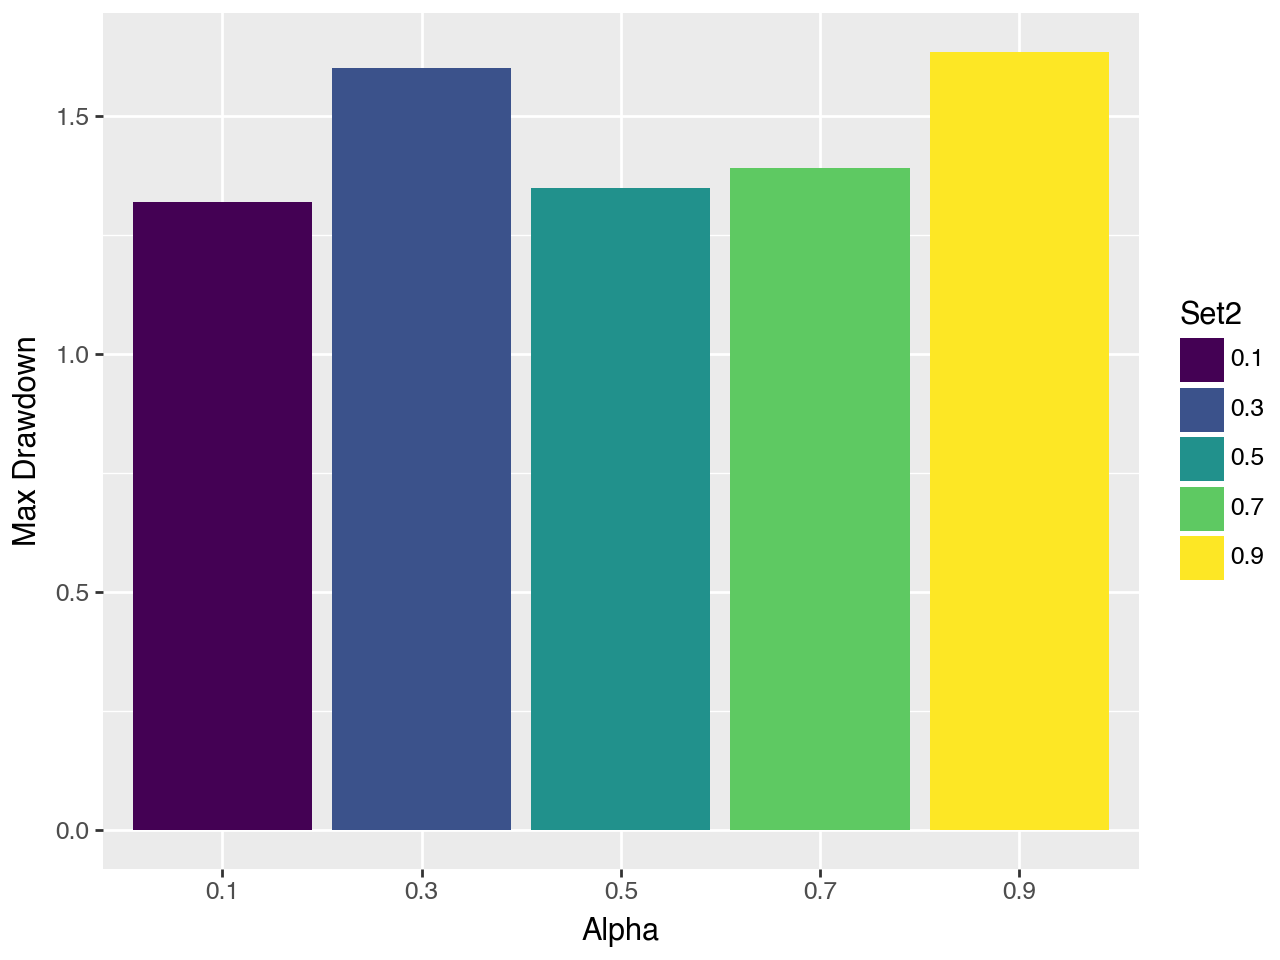

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_EQIX_barplot.pdf


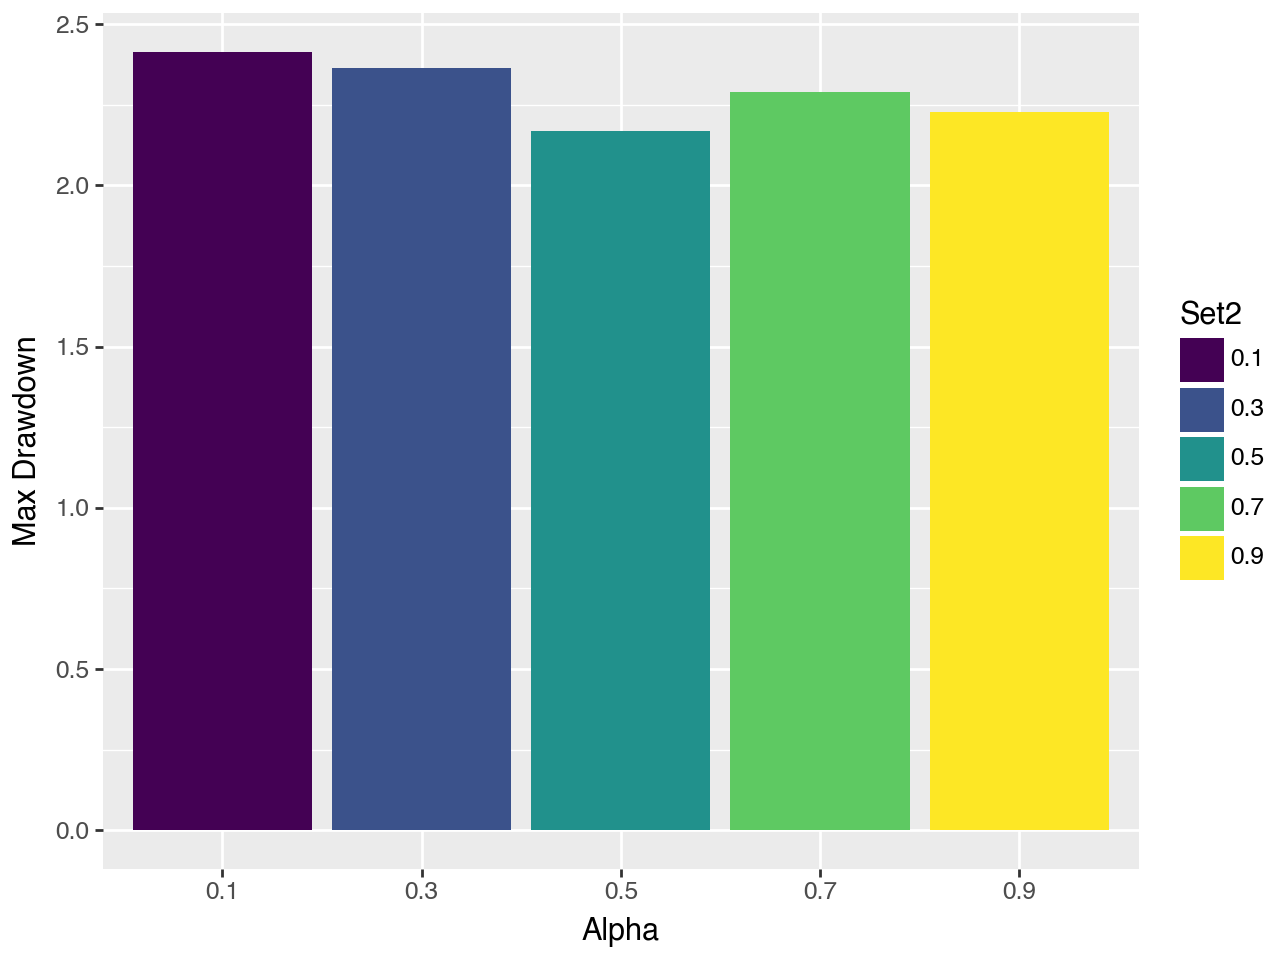

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_EQNR_barplot.pdf


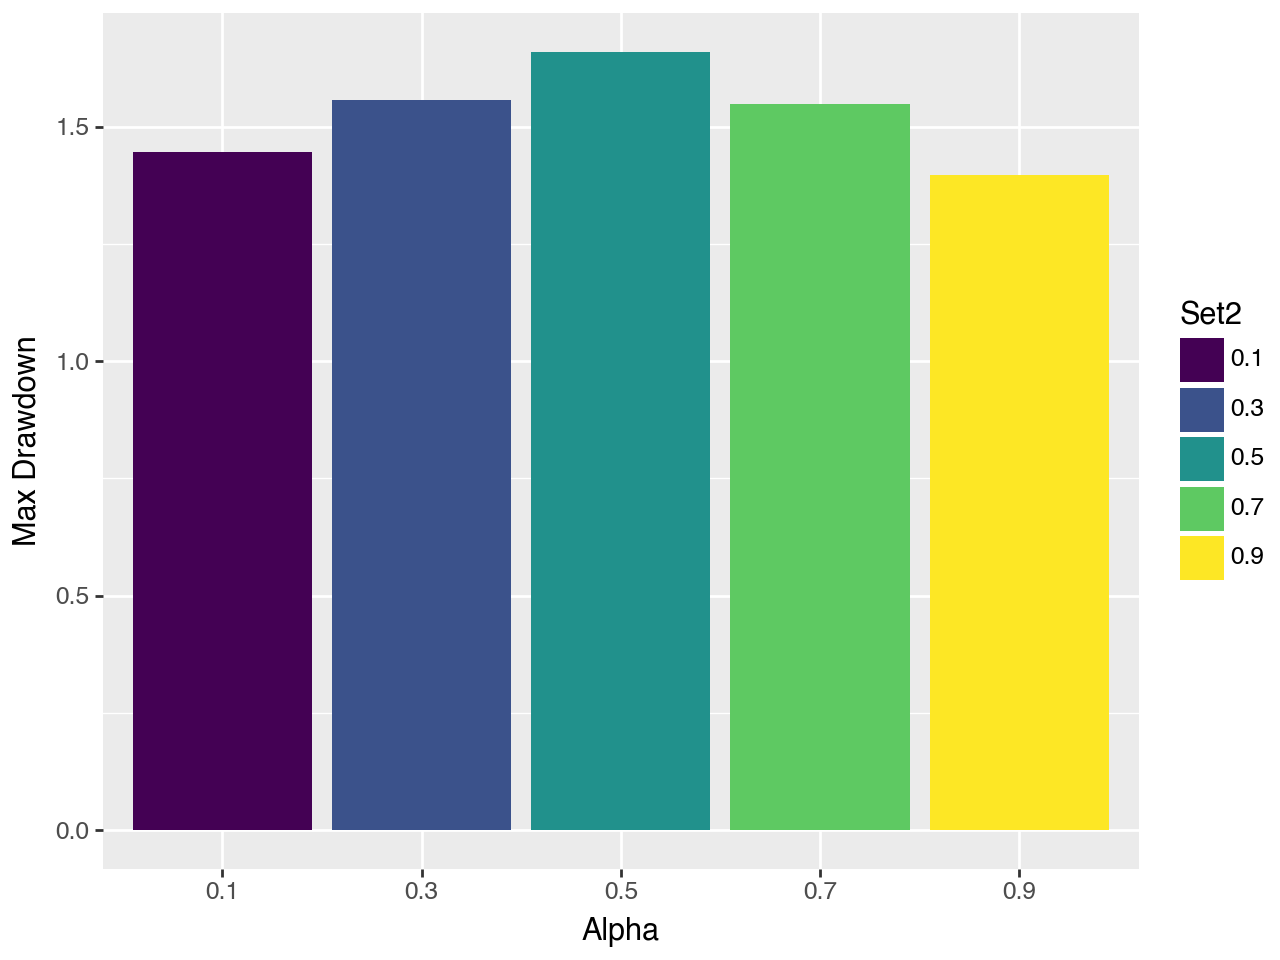

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_FCX_barplot.pdf


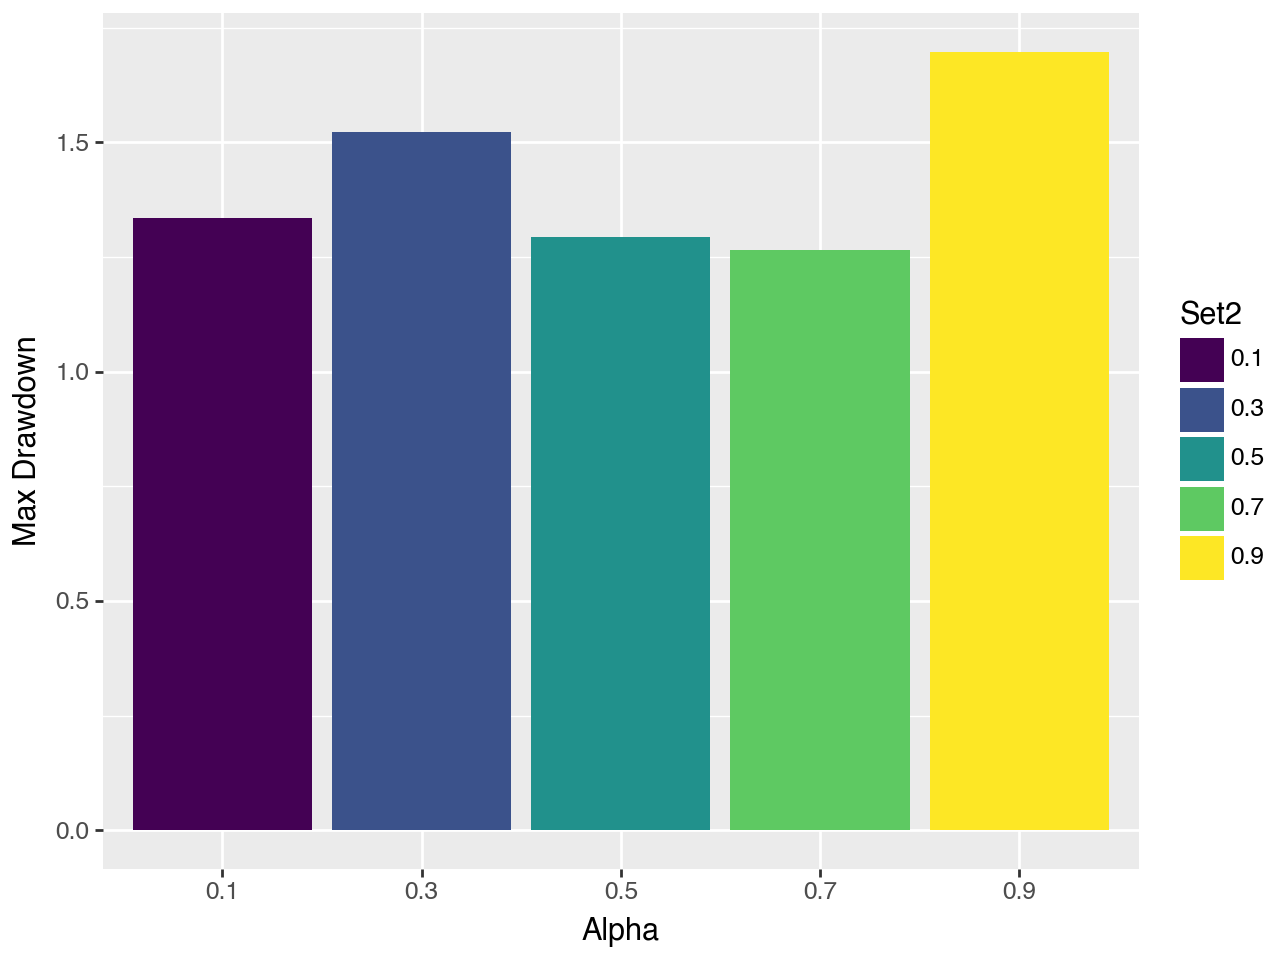

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_GE_barplot.pdf


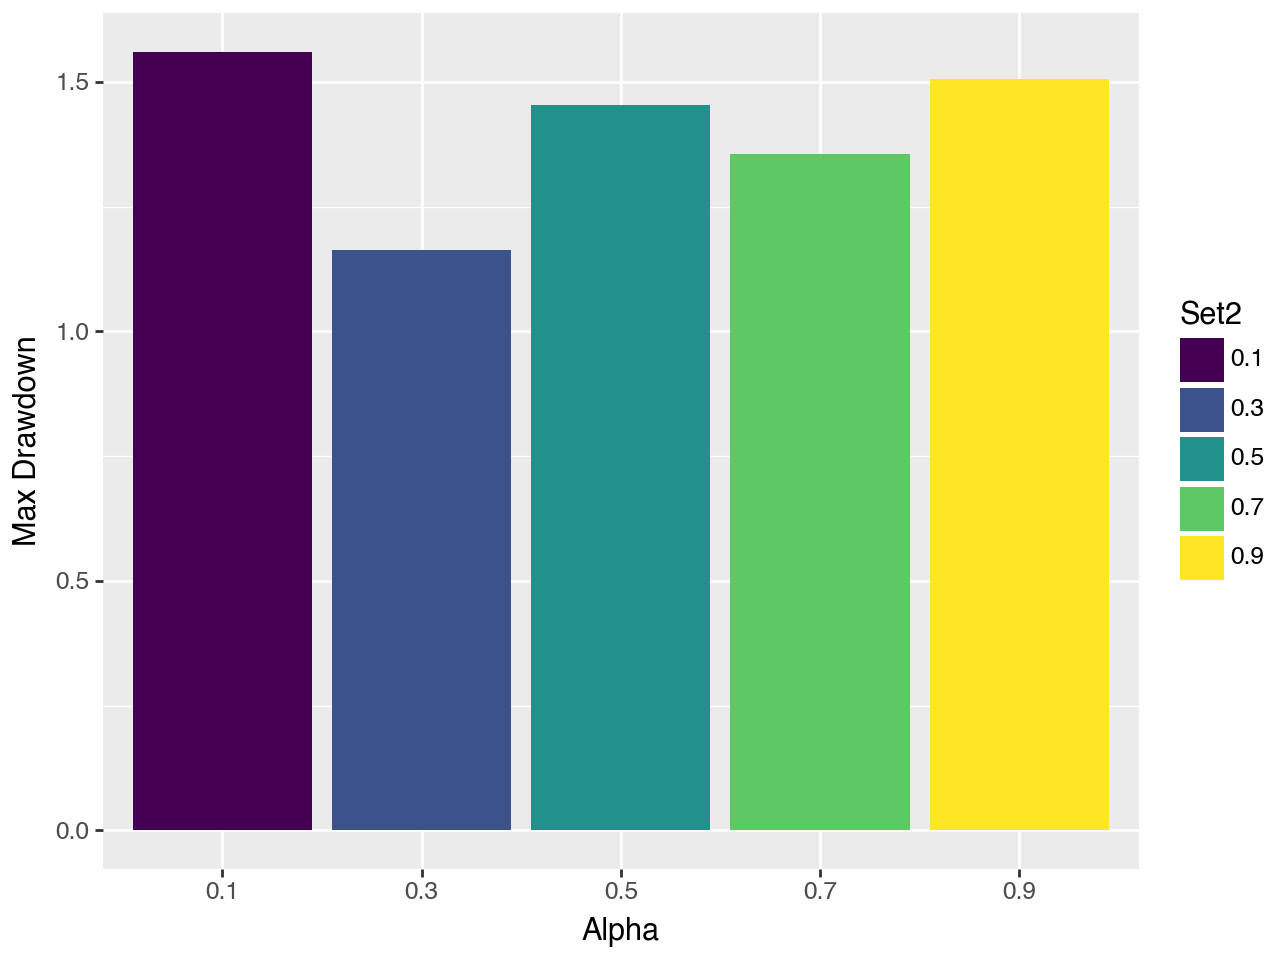

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_GOOG_barplot.pdf


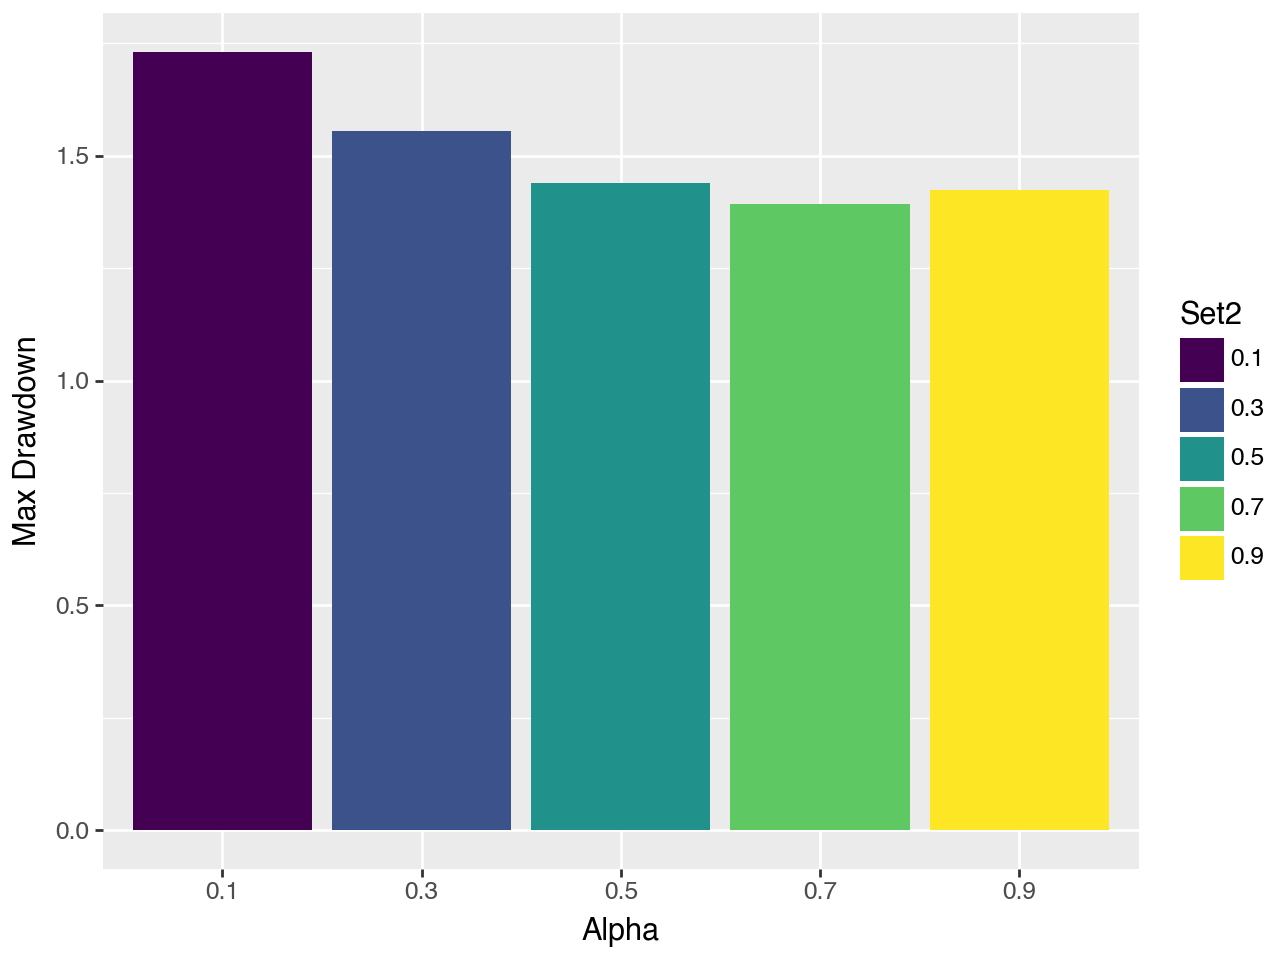

/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/shengdazhuo/anaconda3/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: parameters/barplot_eachstock/Max Drawdown/Alpha_O_barplot.pdf


In [56]:
# 柱状图
def barplot(d, metric, xtick, data_name=None, saved_it=True):
    p = (ggplot(d, aes(x = xtick, y = 'value', fill = xtick)) 
        + geom_bar(stat='identity')
        # + geom_point(size=6, color="k")    
        + scale_color_cmap_d(name= dis_pal)     # plt.cm.ListedCmap
        + scale_fill_cmap_d(name= dis_pal)     # plt.cm.ListedCmap
        # + theme_prism()
        + ylab(metric)
        
        # + theme(legend_text = element_text(size = 15))
        # + theme(axis_text_x = element_text(size=15))
        # + theme(axis_title_x = element_text(size=15))
        # + theme(axis_title_y = element_text(size=15))
        )
    all_or_each = 'all' if data_name == 'all' else 'each'
    save_path = f'parameters/barplot_{all_or_each}stock/{metric}/{xtick}_{data_name}_barplot.pdf'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    p.show()
    
    return p.save(f'parameters/barplot_{all_or_each}stock/{metric}/{xtick}_{data_name}_barplot.pdf') if saved_it else p

df = pd.read_csv('param_group.csv').rename(columns={'stock':'dataset', 'max_drawdown':'Max Drawdown',\
    'annual_return': 'Annual Return', 'sharpe_1x_no_short':'Sharpe Ratio', 'alpha_ratio':'Alpha Ratio',\
    'annual_volatility':'Annual Volatility', 'accuracy':'Accuracy', 'omega_ratio':'Omega Ratio',\
    'sortino_ratio':'Sortino Ratio', 'skew':'Skew', 'kurtosis':'Kurtosis', 'cumulative_returns':'Cumulative Returns',
    'calmar_ratio':'Calmar Ratio'})
df = wide_to_long(df)
MometumSpan_ordered = ['±1','-1','1', '0','2','-2','±2']
df['Alpha'] = df['Alpha'].astype(str)
df['MometumSpan'] = df['MometumSpan'].astype(str).astype(CategoricalDtype(MometumSpan_ordered, ordered=True))

# 这里选择超参数
# xtick = 'MometumSpan'
xtick = 'Alpha'


# all stock
for dx in df.groupby(['metric']): 
    dx1 = dx[1].groupby([xtick]).value.median().reset_index()
    barplot(dx1, metric=dx[0],xtick=xtick, data_name='all') 
    
# # each stock    
for dx in df.groupby(['metric','dataset']): 
    dx1 = dx[1].groupby([xtick]).value.median().reset_index()
    # print(dx1, dx[0][0])
    barplot(dx1, metric=dx[0][0], xtick=xtick, data_name=dx[0][1])  